In [1]:
import pandas as pd
import numpy as np

file_path = r'E:\CrashSeverityData-Sydney\CrashSeverityData-Sydney.csv'
df = pd.read_csv(file_path)

print(df.shape) 
print(df.columns)

(5980, 341)
Index(['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Degree of crash',
       'Year of crash', 'Month of crash', 'Day of week of crash',
       'Time of crash - Two-hour intervals', 'First impact type',
       ...
       'hour_04:00 - 05:59', 'hour_06:00 - 07:59', 'hour_08:00 - 09:59',
       'hour_10:00 - 11:59', 'hour_12:00 - 13:59', 'hour_14:00 - 15:59',
       'hour_16:00 - 17:59', 'hour_18:00 - 19:59', 'hour_20:00 - 21:59',
       'hour_22:00 - Midnight'],
      dtype='object', length=341)


C:\Users\HP\AppData\Local\Temp\ipykernel_24700\101029284.py:5: DtypeWarning: Columns (155) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [2]:
print(df.columns.tolist())

['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Degree of crash', 'Year of crash', 'Month of crash', 'Day of week of crash', 'Time of crash - Two-hour intervals', 'First impact type', 'Key TU type', 'Other TU type', 'Identifying feature', 'Identifying feature type', 'Type of location', 'Conurbation 1', 'Alignment', 'Primary permanent feature', 'Primary temporary feature', 'Primary hazardous feature', 'Street lighting', 'Road surface', 'Surface condition', 'Road classification (admin)', 'RUM - description', 'DCA - description', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Degree of crash_Fatal', 'Degree of crash_Injury', 'Degree of crash_Non-casualty (towaway)', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Veh

In [3]:
import numpy as np

df['severity_3class'] = np.select(
    [
        # کلاس 2: شدید
        # حداقل یک فوتی یا حداقل یک مصدوم شدید
        (df['No. killed'] > 0) |
        (df['No. seriously injured'] > 0),

        # کلاس 1: جرحی
        # حداقل یک مصدوم متوسط یا خفیف
        # ولی بدون فوتی و بدون مصدوم شدید
        (
            ((df['No. moderately injured'] > 0) |
             (df['No. minor-other injured'] > 0))
            &
            (df['No. killed'] == 0)
            &
            (df['No. seriously injured'] == 0)
        )
    ],

    [
        2,  # Severe
        1   # Injury
    ],

    default=0  # Property Damage
)

print(df['severity_3class'].value_counts().sort_index())

print("\nPercentage:")
print(
    df['severity_3class']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

severity_labels = {
    0: 'Property Damage',
    1: 'Injury',
    2: 'Severe'
}

df['severity_3class_label'] = df['severity_3class'].map(severity_labels)

print("\nClass labels:")
print(df['severity_3class_label'].value_counts())

severity_3class
0    1478
1    3362
2    1140
Name: count, dtype: int64

Percentage:
severity_3class
0    24.72
1    56.22
2    19.06
Name: proportion, dtype: float64

Class labels:
severity_3class_label
Injury             3362
Property Damage    1478
Severe             1140
Name: count, dtype: int64


In [4]:
print(df.columns.tolist())

['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Degree of crash', 'Year of crash', 'Month of crash', 'Day of week of crash', 'Time of crash - Two-hour intervals', 'First impact type', 'Key TU type', 'Other TU type', 'Identifying feature', 'Identifying feature type', 'Type of location', 'Conurbation 1', 'Alignment', 'Primary permanent feature', 'Primary temporary feature', 'Primary hazardous feature', 'Street lighting', 'Road surface', 'Surface condition', 'Road classification (admin)', 'RUM - description', 'DCA - description', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Degree of crash_Fatal', 'Degree of crash_Injury', 'Degree of crash_Non-casualty (towaway)', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Veh

In [5]:
severity_columns_to_drop = [
    'Degree of crash',
    'Degree of crash_Fatal',
    'Degree of crash_Injury',
    'Degree of crash_Non-casualty (towaway)',
    'severity_3class_label'
]

severity_columns_to_drop = [
    col for col in severity_columns_to_drop
    if col in df.columns
]

df = df.drop(columns=severity_columns_to_drop)

print("ستون‌های حذف‌شده:")
print(severity_columns_to_drop)

print("\nستون هدف باقی‌مانده:")
print('severity_3class' in df.columns)

print("\nشکل جدید DataFrame:")
print(df.shape)

ستون‌های حذف‌شده:
['Degree of crash', 'Degree of crash_Fatal', 'Degree of crash_Injury', 'Degree of crash_Non-casualty (towaway)', 'severity_3class_label']

ستون هدف باقی‌مانده:
True

شکل جدید DataFrame:
(5980, 338)


In [6]:
print(df.shape) 

(5980, 338)


In [7]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].to_string())

dist_edu_min                 94.715719
dist_edu_mean                94.715719
amenity_edu                  94.715719
amenity_Others               92.608696
dist_Others_mean             92.608696
dist_Others_min              92.608696
amenity_fin                  92.056856
dist_fin_mean                92.056856
dist_fin_min                 92.056856
amenity_PublicService        91.003344
dist_PublicService_min       91.003344
dist_PublicService_mean      91.003344
dist_helth_min               90.234114
dist_helth_mean              90.234114
amenity_helth                90.234114
dist_art_min                 90.217391
dist_art_mean                90.217391
amenity_art                  90.217391
dist_hotel_mean              89.966555
dist_hotel_min               89.966555
amenity_hotel                89.966555
dist_WasteManagement_min     83.327759
dist_WasteManagement_mean    83.327759
amenity_WasteManagement      83.327759
amenity_park                 78.762542
dist_park_mean           

In [8]:
df['dist_edu_min'].value_counts()

dist_edu_min
0.000000      45
24.848218     28
23.643339     15
36.115252     14
9.205351      12
21.689028     11
37.448374      9
86.652421      8
19.200862      8
135.687521     8
34.566628      7
110.170734     7
17.570409      7
17.661038      7
38.656944      6
78.887774      6
17.485306      6
25.912776      6
6.039418       5
25.492966      5
26.479207      5
16.099030      5
17.075240      5
133.599219     5
25.833340      5
46.379073      4
24.577771      4
18.723081      4
10.531941      4
10.387475      4
17.678529      4
25.559541      4
27.843639      3
80.023010      3
32.365591      3
25.480037      3
65.990942      3
17.821804      2
80.250719      2
68.650766      2
34.565834      2
7.617398       2
30.790568      2
18.132489      2
13.294158      1
26.746870      1
69.251303      1
27.050619      1
22.770380      1
10.575235      1
29.947662      1
9.302300       1
10.175047      1
210.390112     1
13.934666      1
16.695861      1
7.979204       1
15.087769      1
N

In [9]:
df['dist_edu_mean'].value_counts()

dist_edu_mean
0.000000      45
24.848218     28
23.643339     15
36.115252     14
9.205351      12
21.689028     11
37.448374      9
86.652421      8
19.200862      8
135.687521     8
34.566628      7
110.170734     7
17.570409      7
17.661038      7
38.656944      6
78.887774      6
17.485306      6
25.912776      6
6.039418       5
25.492966      5
26.479207      5
16.099030      5
17.075240      5
133.599219     5
25.833340      5
46.379073      4
24.577771      4
18.723081      4
10.531941      4
10.771850      4
17.678529      4
25.559541      4
27.843639      3
80.023010      3
32.365591      3
25.480037      3
65.990942      3
17.821804      2
80.250719      2
68.650766      2
34.565834      2
7.617398       2
30.790568      2
18.132489      2
13.294158      1
26.746870      1
69.251303      1
27.050619      1
22.770380      1
10.575235      1
29.947662      1
9.302300       1
10.175047      1
210.390112     1
13.934666      1
16.695861      1
7.979204       1
15.087769      1


In [10]:
df['amenity_edu'].value_counts()

amenity_edu
1.0    312
2.0      4
Name: count, dtype: int64

In [11]:
df['amenity_edu'] = df['amenity_edu'].fillna(0)

In [12]:
print(df['amenity_edu'].value_counts(dropna=False))

amenity_edu
0.0    5664
1.0     312
2.0       4
Name: count, dtype: int64


In [13]:
# ==========================================================
# مدیریت ستون‌های Amenity
# ==========================================================

# 1. تمام ستون‌هایی که با amenity_ شروع می‌شوند
amenity_cols = [
    col for col in df.columns
    if col.startswith('amenity_')
]

# 2. پر کردن Missing در ستون‌های Amenity با صفر
# صفر = عدم وجود آن نوع Amenity
df[amenity_cols] = df[amenity_cols].fillna(0)

# 3. پیدا کردن تمام ستون‌های فاصله‌ای
# dist_*_mean و dist_*_min
distance_cols = [
    col for col in df.columns
    if col.startswith('dist_') and (
        col.endswith('_mean') or col.endswith('_min')
    )
]

# 4. حذف ستون‌های فاصله
df = df.drop(columns=distance_cols)

# ==========================================================
# بررسی نتیجه
# ==========================================================

print("Amenity columns kept:")
print(amenity_cols)

print("\nDistance columns dropped:")
print(distance_cols)

print("\nRemaining missing values in Amenity columns:")
print(df[amenity_cols].isna().sum())

print("\nNew DataFrame shape:")
print(df.shape)

Amenity columns kept:
['amenity_sus', 'amenity_edu', 'amenity_trns', 'amenity_fin', 'amenity_Others', 'amenity_WasteManagement', 'amenity_Facilities', 'amenity_PublicService', 'amenity_art', 'amenity_helth', 'amenity_shop', 'amenity_park', 'amenity_hotel']

Distance columns dropped:
['dist_sus_mean', 'dist_sus_min', 'dist_edu_mean', 'dist_edu_min', 'dist_trns_mean', 'dist_trns_min', 'dist_fin_mean', 'dist_fin_min', 'dist_Others_mean', 'dist_Others_min', 'dist_WasteManagement_mean', 'dist_WasteManagement_min', 'dist_Facilities_mean', 'dist_Facilities_min', 'dist_PublicService_mean', 'dist_PublicService_min', 'dist_art_mean', 'dist_art_min', 'dist_helth_mean', 'dist_helth_min', 'dist_shop_mean', 'dist_shop_min', 'dist_park_mean', 'dist_park_min', 'dist_hotel_mean', 'dist_hotel_min']

Remaining missing values in Amenity columns:
amenity_sus                0
amenity_edu                0
amenity_trns               0
amenity_fin                0
amenity_Others             0
amenity_WasteMana

In [14]:
df.describe()

,Unnamed: 0,Crash ID,Latitude,Longitude,Year of crash,No. killed,No. seriously injured,No. moderately injured,No. minor-other injured,id,...,hour_06:00 - 07:59,hour_08:00 - 09:59,hour_10:00 - 11:59,hour_12:00 - 13:59,hour_14:00 - 15:59,hour_16:00 - 17:59,hour_18:00 - 19:59,hour_20:00 - 21:59,hour_22:00 - Midnight,severity_3class
count,5980.000000,5.980000e+03,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,...,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000,5980.000000
mean,79826.755518,1.206305e+06,-33.885172,151.204946,2019.024247,0.007525,0.190635,0.338963,0.327090,107378.967224,...,0.071070,0.124080,0.098662,0.108194,0.120736,0.144983,0.111873,0.069900,0.065552,0.943478
std,48248.493040,7.266695e+04,0.015365,0.012056,2.313145,0.093849,0.409920,0.525312,0.529796,91574.785556,...,0.256964,0.329701,0.298233,0.310651,0.325847,0.352113,0.315236,0.254999,0.247518,0.659296
min,4.000000,1.088880e+06,-33.931405,151.173990,2016.000000,0.000000,0.000000,0.000000,0.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38911.750000,1.144456e+06,-33.896237,151.197548,2017.000000,0.000000,0.000000,0.000000,0.000000,15032.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,76709.000000,1.198735e+06,-33.883471,151.205938,2019.000000,0.000000,0.000000,0.000000,0.000000,90385.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,120778.750000,1.267463e+06,-33.873968,151.213274,2021.000000,0.000000,0.000000,1.000000,1.000000,204942.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,167515.000000,1.350184e+06,-33.842021,151.232984,2023.000000,3.000000,3.000000,4.000000,4.000000,259417.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


In [15]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].to_string())

Series([], )


In [16]:
df.select_dtypes(include='object').nunique().sort_values(ascending=False)

geometry                              1716
Identifying feature                   1048
name                                   412
RUM - description                       77
DCA - description                       76
Identifying feature type                37
Other TU type                           25
Key TU type                             24
Primary permanent feature               23
Type of location                        13
Month of crash                          12
Time of crash - Two-hour intervals      12
highway                                 11
First impact type                       10
cycleway                                 8
Day of week of crash                     7
Primary temporary feature                6
traffic_calming                          6
bicycle                                  6
Primary hazardous feature                6
sidewalk                                 6
foot                                     5
surface                                  5
access     

In [17]:
print(f"تعداد کل ستون‌ها: {df.shape[1]}")
print(f"ستون‌های عددی: {df.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"ستون‌های غیرعددی: {df.select_dtypes(include='object').shape[1]}")

تعداد کل ستون‌ها: 312
ستون‌های عددی: 267
ستون‌های غیرعددی: 45


In [18]:
df['RUM - description'].value_counts()

RUM - description
Rear end                1183
Ped nearside             482
Right through            439
Cross traffic            371
Off rd left => obj       349
                        ... 
Pkd veh runaway=>veh       1
Object struck veh          1
Pulling out                1
Out of control otake       1
Cutting in                 1
Name: count, Length: 77, dtype: int64

In [19]:
df['DCA - description'].value_counts()

DCA - description
Same - Rear end               1183
Ped - Near side                482
Opp - Right-thru               439
Adj - Cross traffic            371
Left off cway into object      349
                              ... 
Boarding/alighting               1
On path - Load hit vehicle       1
Ovtak- Pulling out               1
Ovtak - Out of control           1
Ovtak - Cutting in               1
Name: count, Length: 76, dtype: int64

In [20]:
# بررسی تعداد حالات و مقادیر یکتا
for col in ['RUM - description', 'DCA - description']:
    print(f"\n--- {col} ---")
    print(f"تعداد حالات: {df[col].nunique()}")
    print(f"نان: {df[col].isnull().sum()}")
    print(df[col].value_counts())


--- RUM - description ---
تعداد حالات: 77
نان: 0
RUM - description
Rear end                1183
Ped nearside             482
Right through            439
Cross traffic            371
Off rd left => obj       349
                        ... 
Pkd veh runaway=>veh       1
Object struck veh          1
Pulling out                1
Out of control otake       1
Cutting in                 1
Name: count, Length: 77, dtype: int64

--- DCA - description ---
تعداد حالات: 76
نان: 0
DCA - description
Same - Rear end               1183
Ped - Near side                482
Opp - Right-thru               439
Adj - Cross traffic            371
Left off cway into object      349
                              ... 
Boarding/alighting               1
On path - Load hit vehicle       1
Ovtak- Pulling out               1
Ovtak - Out of control           1
Ovtak - Cutting in               1
Name: count, Length: 76, dtype: int64


In [21]:
# بررسی الگوهای کلی در RUM
print("=== الگوهای RUM ===")
rum_patterns = df['RUM - description'].str.split().str[0].value_counts()
print(rum_patterns.head(20))

print("\n=== الگوهای DCA ===")
dca_patterns = df['DCA - description'].str.split().str[0].value_counts()
print(dca_patterns.head(20))

=== الگوهای RUM ===
RUM - description
Rear         1183
Ped           955
Right         717
Off           654
Lane          468
Cross         371
Other         364
On            196
Left          195
Vehicle       133
U             107
Leaving        86
Head           82
Emerging       82
From           78
Fell           56
Out            49
Reversing      40
Parking        23
Entering       22
Name: count, dtype: int64

=== الگوهای DCA ===
DCA - description
Same                  2196
Ped                    973
Adj                    589
Opp                    589
Manov                  436
Left                   392
Out                    216
On                     195
Right                  145
Off                    145
Fell                    56
Ovtak                   30
Parked                  11
Vehicle                  3
Other                    2
Boarding/alighting       1
Ovtak-                   1
Name: count, dtype: int64


In [22]:
# تعریف 5 دسته اصلی
def categorize_rum(description):
    if pd.isna(description):
        return 'Other'
    desc_lower = description.lower()
    
    # 1. تصادفات از پشت
    if any(word in desc_lower for word in ['rear', 'rear end']):
        return 'Rear-end'
    
    # 2. حوادث عابر پیاده
    elif any(word in desc_lower for word in ['ped', 'pedestrian']):
        return 'Pedestrian'
    
    # 3. تصادفات در تقاطع (چپ، راست، عبور)
    elif any(word in desc_lower for word in ['right', 'left', 'cross', 'intersection', 'turning', 'u turn']):
        return 'Intersection'
    
    # 4. خروج از جاده / تک خودرو
    elif any(word in desc_lower for word in ['off', 'lane', 'head on', 'out of control', 'fell', 'leaving']):
        return 'Off-road/Single'
    
    # 5. سایر
    else:
        return 'Other'

def categorize_dca(description):
    if pd.isna(description):
        return 'Other'
    desc_lower = description.lower()
    
    # 1. تصادفات از پشت
    if 'rear' in desc_lower:
        return 'Rear-end'
    
    # 2. عابر پیاده
    elif 'pedestrian' in desc_lower:
        return 'Pedestrian'
    
    # 3. تقاطع
    elif any(word in desc_lower for word in ['right', 'left', 'cross', 'intersection', 'turning', 'manoeuvre']):
        return 'Intersection'
    
    # 4. خروج از جاده / تک خودرو
    elif any(word in desc_lower for word in ['off', 'path', 'head', 'control', 'lane']):
        return 'Off-road/Single'
    
    # 5. سایر
    else:
        return 'Other'

# اعمال دسته‌بندی
df['RUM_category'] = df['RUM - description'].apply(categorize_rum)
df['DCA_category'] = df['DCA - description'].apply(categorize_dca)

# بررسی توزیع دسته‌ها
print("=== توزیع دسته‌های RUM ===")
print(df['RUM_category'].value_counts())
print(f"\nدرصدها:")
print(df['RUM_category'].value_counts(normalize=True) * 100)

print("\n=== توزیع دسته‌های DCA ===")
print(df['DCA_category'].value_counts())
print(f"\nدرصدها:")
print(df['DCA_category'].value_counts(normalize=True) * 100)

# نمونه‌ای از تبدیل
print("\n=== نمونه تبدیل ===")
sample = df[['RUM - description', 'RUM_category', 'DCA - description', 'DCA_category']].head(10)
print(sample)

=== توزیع دسته‌های RUM ===
RUM_category
Intersection       2090
Rear-end           1299
Other              1074
Pedestrian          955
Off-road/Single     562
Name: count, dtype: int64

درصدها:
RUM_category
Intersection       34.949833
Rear-end           21.722408
Other              17.959866
Pedestrian         15.969900
Off-road/Single     9.397993
Name: proportion, dtype: float64

=== توزیع دسته‌های DCA ===
DCA_category
Intersection       2125
Other              1924
Rear-end           1299
Off-road/Single     632
Name: count, dtype: int64

درصدها:
DCA_category
Intersection       35.535117
Other              32.173913
Rear-end           21.722408
Off-road/Single    10.568562
Name: proportion, dtype: float64

=== نمونه تبدیل ===
      RUM - description     RUM_category           DCA - description  \
0              Rear end         Rear-end             Same - Rear end   
1  Right turn sideswipe     Intersection  Same - Rgt turn side swipe   
2             Left rear         Rear-end   

In [23]:
def categorize_rum(description):
    if pd.isna(description):
        return 5  # Other
    desc_lower = description.lower()
    
    # 1. برخورد از عقب (Rear-End)
    if 'rear' in desc_lower:
        return 1
    
    # 2. تصادفات با عابر پیاده (Pedestrian)
    elif 'ped' in desc_lower:
        return 2
    
    # 3. تصادفات زاویه‌دار و تقاطعی (Intersection/Turning)
    elif any(word in desc_lower for word in ['right', 'cross', 'left', 'u turn']):
        return 3
    
    # 4. خروج از جاده / برخورد با مانع (Run-Off-Road)
    elif any(word in desc_lower for word in ['off', ' on ', 'out of control']):
        return 4
    
    # 5. مانورها، تغییر لاین و سایر (Maneuvers & Others)
    else:
        return 5

def categorize_dca(description):
    if pd.isna(description):
        return 5  # Other
    desc_lower = description.lower()
    
    # 1. برخورد از عقب (Rear-End)
    if 'rear' in desc_lower:
        return 1
    
    # 2. عابر پیاده (Pedestrian)
    elif 'pedestrian' in desc_lower:
        return 2
    
    # 3. تقاطع و چرخش (Intersection/Turning)
    elif any(word in desc_lower for word in ['right', 'cross', 'left', 'turning', 'intersection']):
        return 3
    
    # 4. خروج از جاده (Run-Off-Road)
    elif any(word in desc_lower for word in ['off', 'path', 'head on']):
        return 4
    
    # 5. مانورها و سایر (Maneuvers & Others)
    else:
        return 5

# اعمال دسته‌بندی
df['RUM_category'] = df['RUM - description'].apply(categorize_rum)
df['DCA_category'] = df['DCA - description'].apply(categorize_dca)

# بررسی توزیع
print("=== توزیع دسته‌های RUM ===")
rum_dist = df['RUM_category'].value_counts().sort_index()
print(rum_dist)
print(f"\nدرصدها:")
print((rum_dist / len(df) * 100).round(2))

print("\n=== توزیع دسته‌های DCA ===")
dca_dist = df['DCA_category'].value_counts().sort_index()
print(dca_dist)
print(f"\nدرصدها:")
print((dca_dist / len(df) * 100).round(2))

# نمونه تبدیل
print("\n=== نمونه تبدیل (20 سطر اول) ===")
sample = df[['RUM - description', 'RUM_category', 'DCA - description', 'DCA_category']].head(20)
print(sample.to_string())

=== توزیع دسته‌های RUM ===
RUM_category
1    1299
2     955
3    2075
4     284
5    1367
Name: count, dtype: int64

درصدها:
RUM_category
1    21.72
2    15.97
3    34.70
4     4.75
5    22.86
Name: count, dtype: float64

=== توزیع دسته‌های DCA ===
DCA_category
1    1299
3    2125
4     288
5    2268
Name: count, dtype: int64

درصدها:
DCA_category
1    21.72
3    35.54
4     4.82
5    37.93
Name: count, dtype: float64

=== نمونه تبدیل (20 سطر اول) ===
       RUM - description  RUM_category           DCA - description  DCA_category
0               Rear end             1             Same - Rear end             1
1   Right turn sideswipe             3  Same - Rgt turn side swipe             5
2              Left rear             1            Same - Rear left             1
3      Other manoeuvring             5               Manov - other             5
4     Off rd left => obj             3   Left off cway into object             3
5     Off rd left => obj             3   Left off cway int

In [24]:
# بررسی اینکه چرا DCA دسته 2 نداره
ped_check = df[df['RUM_category'] == 2]['DCA - description'].value_counts().head(10)
print("=== DCA descriptions برای رکوردهایی که RUM = Pedestrian ===")
print(ped_check)

print("\n=== بررسی کلمه pedestrian در DCA ===")
has_ped = df['DCA - description'].str.lower().str.contains('ped', na=False).sum()
print(f"تعداد رکوردهای DCA حاوی 'ped': {has_ped}")

# --- ترکیب دسته 4 با 5 ---
def categorize_rum_v2(description):
    if pd.isna(description):
        return 4  # Other (شماره جدید)
    desc_lower = description.lower()
    
    if 'rear' in desc_lower:
        return 1
    elif 'ped' in desc_lower:
        return 2
    elif any(word in desc_lower for word in ['right', 'cross', 'left', 'u turn']):
        return 3
    else:
        return 4  # مانورها + خروج از جاده + سایر

def categorize_dca_v2(description):
    if pd.isna(description):
        return 4
    desc_lower = description.lower()
    
    if 'rear' in desc_lower:
        return 1
    elif 'ped' in desc_lower:
        return 2
    elif any(word in desc_lower for word in ['right', 'cross', 'left', 'turning', 'intersection']):
        return 3
    else:
        return 4  # مانورها + خروج از جاده + سایر

df['RUM_category'] = df['RUM - description'].apply(categorize_rum_v2)
df['DCA_category'] = df['DCA - description'].apply(categorize_dca_v2)

print("\n=== توزیع جدید RUM (4 دسته) ===")
rum_dist = df['RUM_category'].value_counts().sort_index()
print(rum_dist)
print(f"\nدرصدها:")
print((rum_dist / len(df) * 100).round(2))

print("\n=== توزیع جدید DCA (4 دسته) ===")
dca_dist = df['DCA_category'].value_counts().sort_index()
print(dca_dist)
print(f"\nدرصدها:")
print((dca_dist / len(df) * 100).round(2))

=== DCA descriptions برای رکوردهایی که RUM = Pedestrian ===
DCA - description
Ped - Near side               482
Ped - Far side                272
Ped - emerging                 55
Ped - On carriageway           50
Ped - On footway/median        41
Ped - other                    40
Ped - Walking with traffic     11
Ped - Facing traffic            4
Name: count, dtype: int64

=== بررسی کلمه pedestrian در DCA ===
تعداد رکوردهای DCA حاوی 'ped': 973

=== توزیع جدید RUM (4 دسته) ===
RUM_category
1    1299
2     955
3    2075
4    1651
Name: count, dtype: int64

درصدها:
RUM_category
1    21.72
2    15.97
3    34.70
4    27.61
Name: count, dtype: float64

=== توزیع جدید DCA (4 دسته) ===
DCA_category
1    1299
2     973
3    2125
4    1583
Name: count, dtype: int64

درصدها:
DCA_category
1    21.72
2    16.27
3    35.54
4    26.47
Name: count, dtype: float64


In [25]:
print(df.shape) 

(5980, 314)


In [26]:
# لیست ستون‌هایی که باید حذف بشن
columns_to_drop = [
    # ستون‌های توصیفی اصلی که دسته‌بندی شدن
    'RUM - description',
    'DCA - description',
   
    # ستون‌های شناسایی که برای مدل لازم نیستن
    'geometry',
    'name'
]

# حذف ستون‌ها
df= df.drop(columns=columns_to_drop, errors='ignore')

# بررسی شکل جدید دیتاست
print(f"شکل جدید: {df.shape}")

# بررسی مقادیر گمشده باقیمانده
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print(f"\n{'='*50}")
print("ستون‌های باقیمانده با مقدار گمشده:")
print(f"{'='*50}")
for col, count in missing_summary.items():
    percentage = (count / len(df)) * 100
    print(f"{col}: {count} ({percentage:.2f}%)")

شکل جدید: (5980, 310)

ستون‌های باقیمانده با مقدار گمشده:


In [27]:
# بررسی کامل ستون‌های با مقدار گمشده بالا
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

print(f"تعداد کل ستون‌های دارای NaN: {len(missing)}")
print(f"\n--- دسته‌بندی بر اساس درصد NaN ---")
print(f"بالای 90%: {(missing_pct > 90).sum()} ستون")
print(f"بین 80-90%: {((missing_pct > 80) & (missing_pct <= 90)).sum()} ستون")
print(f"بین 60-80%: {((missing_pct > 60) & (missing_pct <= 80)).sum()} ستون")
print(f"بین 40-60%: {((missing_pct > 40) & (missing_pct <= 60)).sum()} ستون")
print(f"زیر 40%: {(missing_pct <= 40).sum()} ستون")

# نمایش اسم ستون‌ها در هر دسته
for threshold, label in [(90, 'بالای 90%'), (80, 'بین 80-90%'), (60, 'بین 60-80%')]:
    if threshold == 90:
        cols = missing_pct[missing_pct > threshold].index.tolist()
    elif threshold == 80:
        cols = missing_pct[(missing_pct > threshold) & (missing_pct <= 90)].index.tolist()
    else:
        cols = missing_pct[(missing_pct > threshold) & (missing_pct <= 80)].index.tolist()
    
    print(f"\n{'='*50}")
    print(f"{label}: ({len(cols)} ستون)")
    print(cols)

تعداد کل ستون‌های دارای NaN: 0

--- دسته‌بندی بر اساس درصد NaN ---
بالای 90%: 0 ستون
بین 80-90%: 0 ستون
بین 60-80%: 0 ستون
بین 40-60%: 0 ستون
زیر 40%: 0 ستون

بالای 90%: (0 ستون)
[]

بین 80-90%: (0 ستون)
[]

بین 60-80%: (0 ستون)
[]


In [28]:
# بررسی تعداد رکوردهای تکراری
duplicates = df.duplicated()
print(f"تعداد رکوردهای تکراری: {duplicates.sum()}")
print(f"درصد تکراری: {(duplicates.sum() / len(df)) * 100:.2f}%")

# اگر تکراری وجود داشت، نمونه‌ای نشان بده
if duplicates.sum() > 0:
    print("\nنمونه رکوردهای تکراری:")
    print(df[duplicates].head())

تعداد رکوردهای تکراری: 0
درصد تکراری: 0.00%


In [29]:
# لیست ستون‌های عددی
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"تعداد ستون‌های عددی: {len(numeric_cols)}")
print("\nآمار توصیفی ستون‌های عددی:")
print(df[numeric_cols].describe())

تعداد ستون‌های عددی: 269

آمار توصیفی ستون‌های عددی:
          Unnamed: 0      Crash ID     Latitude    Longitude  Year of crash  \
count    5980.000000  5.980000e+03  5980.000000  5980.000000    5980.000000   
mean    79826.755518  1.206305e+06   -33.885172   151.204946    2019.024247   
std     48248.493040  7.266695e+04     0.015365     0.012056       2.313145   
min         4.000000  1.088880e+06   -33.931405   151.173990    2016.000000   
25%     38911.750000  1.144456e+06   -33.896237   151.197548    2017.000000   
50%     76709.000000  1.198735e+06   -33.883471   151.205938    2019.000000   
75%    120778.750000  1.267463e+06   -33.873968   151.213274    2021.000000   
max    167515.000000  1.350184e+06   -33.842021   151.232984    2023.000000   

        No. killed  No. seriously injured  No. moderately injured  \
count  5980.000000            5980.000000             5980.000000   
mean      0.007525               0.190635                0.338963   
std       0.093849          

In [30]:
import numpy as np

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# شناسایی ستون‌هایی با outlier شدید (IQR method)
outlier_report = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR == 0:
        continue  # ستون‌های باینری یا ثابت رو رد کن
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    
    if n_outliers > 0:
        outlier_report.append({
            'column': col,
            'n_outliers': n_outliers,
            'pct_outliers': round(pct, 2),
            'min': df[col].min(),
            'max': df[col].max(),
            'Q1': Q1,
            'Q3': Q3
        })

outlier_df = pd.DataFrame(outlier_report).sort_values('pct_outliers', ascending=False)
print(f"تعداد ستون‌های دارای outlier: {len(outlier_df)}")
print(f"\n--- ستون‌های با بیش از 5% outlier ---")
print(outlier_df[outlier_df['pct_outliers'] > 5].to_string(index=False))
print(f"\n--- ستون‌های با 1% تا 5% outlier ---")
print(outlier_df[(outlier_df['pct_outliers'] >= 1) & (outlier_df['pct_outliers'] <= 5)].to_string(index=False))

تعداد ستون‌های دارای outlier: 52

--- ستون‌های با بیش از 5% outlier ---
                         column  n_outliers  pct_outliers      min         max        Q1         Q3
             cloud_cover_PR_max         987         16.51 0.000000  100.000000 94.000000 100.000000
             amenity_Facilities         972         16.25 0.000000  102.000000  0.000000   1.000000
                   amenity_shop         972         16.25 0.000000   44.000000  0.000000   1.000000
                   amenity_trns         868         14.52 0.000000  314.000000  0.000000   1.000000
             cloud_cover_PR_min         840         14.05 0.000000  100.000000  0.000000   7.000000
                    amenity_sus         673         11.25 0.000000   36.000000  0.000000   2.000000
          precipitation_mm_mean         658         11.00 0.000000    3.500000  0.000000   0.125000
                           dist         658         11.00 0.000368  406.754215  0.575151   2.593012
                   rain_mm_m

In [31]:
# بررسی ستون‌های غیرعددی باقی‌مانده
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"تعداد ستون‌های دسته‌ای: {len(cat_cols)}")
print(f"\nلیست ستون‌ها:")
for col in cat_cols:
    nunique = df[col].nunique()
    print(f"  {col}: {nunique} مقدار یکتا")

تعداد ستون‌های دسته‌ای: 41

لیست ستون‌ها:
  Month of crash: 12 مقدار یکتا
  Day of week of crash: 7 مقدار یکتا
  Time of crash - Two-hour intervals: 12 مقدار یکتا
  First impact type: 10 مقدار یکتا
  Key TU type: 24 مقدار یکتا
  Other TU type: 25 مقدار یکتا
  Identifying feature: 1048 مقدار یکتا
  Identifying feature type: 37 مقدار یکتا
  Type of location: 13 مقدار یکتا
  Conurbation 1: 1 مقدار یکتا
  Alignment: 2 مقدار یکتا
  Primary permanent feature: 23 مقدار یکتا
  Primary temporary feature: 6 مقدار یکتا
  Primary hazardous feature: 6 مقدار یکتا
  Street lighting: 4 مقدار یکتا
  Road surface: 3 مقدار یکتا
  Surface condition: 4 مقدار یکتا
  Road classification (admin): 3 مقدار یکتا
  highway: 11 مقدار یکتا
  location: 2 مقدار یکتا
  surface: 5 مقدار یکتا
  turn: 3 مقدار یکتا
  shoulder: 4 مقدار یکتا
  sidewalk: 6 مقدار یکتا
  bridge: 3 مقدار یکتا
  bridge:name: 3 مقدار یکتا
  oneway: 4 مقدار یکتا
  access: 5 مقدار یکتا
  traffic_calming: 6 مقدار یکتا
  tunnel: 2 مقدار یکتا
  toll: 

In [32]:
# نمایش کامل همه ستون‌های دسته‌ای با تعداد مقادیر یکتا
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"تعداد کل: {len(cat_cols)}\n")

# دسته‌بندی بر اساس تعداد مقادیر یکتا
single_value = []
low_card = []      # 2-15
medium_card = []   # 16-50
high_card = []     # 50+

for col in cat_cols:
    n = df[col].nunique()
    if n == 1:
        single_value.append((col, n))
    elif n <= 15:
        low_card.append((col, n))
    elif n <= 50:
        medium_card.append((col, n))
    else:
        high_card.append((col, n))

print(f"=== تک‌مقداری (قابل حذف) === [{len(single_value)} ستون]")
for col, n in single_value:
    print(f"  {col}: {n}")

print(f"\n=== کم‌تنوع (2-15) - مناسب One-Hot === [{len(low_card)} ستون]")
for col, n in low_card:
    print(f"  {col}: {n}")

print(f"\n=== متوسط (16-50) === [{len(medium_card)} ستون]")
for col, n in medium_card:
    print(f"  {col}: {n}")

print(f"\n=== پرتنوع (50+) === [{len(high_card)} ستون]")
for col, n in high_card:
    print(f"  {col}: {n}")

تعداد کل: 41

=== تک‌مقداری (قابل حذف) === [3 ستون]
  Conurbation 1: 1
  LGA_NAME23: 1
  STE_NAME21: 1

=== کم‌تنوع (2-15) - مناسب One-Hot === [33 ستون]
  Month of crash: 12
  Day of week of crash: 7
  Time of crash - Two-hour intervals: 12
  First impact type: 10
  Type of location: 13
  Alignment: 2
  Primary temporary feature: 6
  Primary hazardous feature: 6
  Street lighting: 4
  Road surface: 3
  Surface condition: 4
  Road classification (admin): 3
  highway: 11
  location: 2
  surface: 5
  turn: 3
  shoulder: 4
  sidewalk: 6
  bridge: 3
  bridge:name: 3
  oneway: 4
  access: 5
  traffic_calming: 6
  tunnel: 2
  toll: 3
  junction: 2
  parking: 5
  network: 2
  foot: 5
  bicycle: 6
  bus: 3
  motor_vehicle: 4
  cycleway: 8

=== متوسط (16-50) === [4 ستون]
  Key TU type: 24
  Other TU type: 25
  Identifying feature type: 37
  Primary permanent feature: 23

=== پرتنوع (50+) === [1 ستون]
  Identifying feature: 1048


In [33]:
# 1. حذف ستون‌های غیرضروری
cols_to_drop = ['Conurbation 1', 'LGA_NAME23', 'STE_NAME21', 'Identifying feature']
df = df.drop(columns=cols_to_drop)

# 2. بررسی Primary permanent feature
print("=== توزیع Primary permanent feature ===")
print(df['Primary permanent feature'].value_counts())

=== توزیع Primary permanent feature ===
Primary permanent feature
0                               4605
Foot/cycle path/nature strip     262
Other bridge                     249
Underpass/tunnel                 228
Driveway/entrance                221
Steep grade                      146
Bus/transit lane                  76
Painted double centre lines       39
Bus stop                          32
Spd hump/slow pt/chc              32
Narrow roadway                    22
B'down lane/road shldr            20
Crest                             13
Freeway ramp/access                9
Climb/merge lane                   7
Mid-blk median openg               6
Pedestrian refuge                  3
Low clr o'head brdge               3
Other permanent feature            2
Railway level x                    2
Embankment/cutting                 1
Narrow/1-lane bridge               1
Ditch/drain/culvert                1
Name: count, dtype: int64


In [34]:
def categorize_permanent_feature(val):
    val = str(val).strip()
    if val == '0' or val == 'nan':
        return 0  # بدون ویژگی خاص
    elif val in ['Foot/cycle path/nature strip']:
        return 1  # مسیر پیاده/دوچرخه
    elif val in ['Other bridge', 'Underpass/tunnel', 'Narrow/1-lane bridge', 'Low clr o\'head brdge']:
        return 2  # پل/تونل
    elif val in ['Driveway/entrance', 'Freeway ramp/access', 'Mid-blk median openg']:
        return 3  # ورودی/دسترسی
    else:
        return 4  # سایر ویژگی‌های جاده‌ای (شیب، باریکی، ایستگاه، ...)

df['Primary permanent feature'] = df['Primary permanent feature'].apply(categorize_permanent_feature)

print(df['Primary permanent feature'].value_counts().sort_index())

Primary permanent feature
0    4605
1     262
2     481
3     236
4     396
Name: count, dtype: int64


In [35]:
# شناسایی ستون‌های غیرعددی باقی‌مانده
non_numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"تعداد ستون‌های غیرعددی: {len(non_numeric_cols)}")
print()

for col in non_numeric_cols:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} مقدار یکتا")

تعداد ستون‌های غیرعددی: 36

Month of crash: 12 مقدار یکتا
Day of week of crash: 7 مقدار یکتا
Time of crash - Two-hour intervals: 12 مقدار یکتا
First impact type: 10 مقدار یکتا
Key TU type: 24 مقدار یکتا
Other TU type: 25 مقدار یکتا
Identifying feature type: 37 مقدار یکتا
Type of location: 13 مقدار یکتا
Alignment: 2 مقدار یکتا
Primary temporary feature: 6 مقدار یکتا
Primary hazardous feature: 6 مقدار یکتا
Street lighting: 4 مقدار یکتا
Road surface: 3 مقدار یکتا
Surface condition: 4 مقدار یکتا
Road classification (admin): 3 مقدار یکتا
highway: 11 مقدار یکتا
location: 2 مقدار یکتا
surface: 5 مقدار یکتا
turn: 3 مقدار یکتا
shoulder: 4 مقدار یکتا
sidewalk: 6 مقدار یکتا
bridge: 3 مقدار یکتا
bridge:name: 3 مقدار یکتا
oneway: 4 مقدار یکتا
access: 5 مقدار یکتا
traffic_calming: 6 مقدار یکتا
tunnel: 2 مقدار یکتا
toll: 3 مقدار یکتا
junction: 2 مقدار یکتا
parking: 5 مقدار یکتا
network: 2 مقدار یکتا
foot: 5 مقدار یکتا
bicycle: 6 مقدار یکتا
bus: 3 مقدار یکتا
motor_vehicle: 4 مقدار یکتا
cycleway: 8 مقد

In [36]:
# دسته‌بندی بر اساس تعداد مقادیر یکتا
low_card = []    # 2-15: مناسب One-Hot
mid_card = []    # 16-30: نیاز به بررسی
high_card = []   # 30+: احتمالاً حذف یا گروه‌بندی

for col in non_numeric_cols:
    n = df[col].nunique()
    if n <= 15:
        low_card.append((col, n))
    elif n <= 30:
        mid_card.append((col, n))
    else:
        high_card.append((col, n))

print(f"=== کم‌تنوع (2-15) → One-Hot Encoding: {len(low_card)} ستون ===")
for col, n in low_card:
    print(f"  {col}: {n}")

print(f"\n=== متوسط (16-30) → بررسی بیشتر: {len(mid_card)} ستون ===")
for col, n in mid_card:
    print(f"  {col}: {n}")

print(f"\n=== پرتنوع (30+) → حذف یا گروه‌بندی: {len(high_card)} ستون ===")
for col, n in high_card:
    print(f"  {col}: {n}")

# بررسی ستون‌های تک‌مقداری
single_val = [col for col in non_numeric_cols if df[col].nunique() == 1]
print(f"\n=== تک‌مقداری (حذف): {single_val} ===")

=== کم‌تنوع (2-15) → One-Hot Encoding: 33 ستون ===
  Month of crash: 12
  Day of week of crash: 7
  Time of crash - Two-hour intervals: 12
  First impact type: 10
  Type of location: 13
  Alignment: 2
  Primary temporary feature: 6
  Primary hazardous feature: 6
  Street lighting: 4
  Road surface: 3
  Surface condition: 4
  Road classification (admin): 3
  highway: 11
  location: 2
  surface: 5
  turn: 3
  shoulder: 4
  sidewalk: 6
  bridge: 3
  bridge:name: 3
  oneway: 4
  access: 5
  traffic_calming: 6
  tunnel: 2
  toll: 3
  junction: 2
  parking: 5
  network: 2
  foot: 5
  bicycle: 6
  bus: 3
  motor_vehicle: 4
  cycleway: 8

=== متوسط (16-30) → بررسی بیشتر: 2 ستون ===
  Key TU type: 24
  Other TU type: 25

=== پرتنوع (30+) → حذف یا گروه‌بندی: 1 ستون ===
  Identifying feature type: 37

=== تک‌مقداری (حذف): [] ===


In [37]:
# بررسی توزیع مقادیر
print(df['Identifying feature type'].value_counts())
print(f"\nدرصد هر مقدار:")
print(df['Identifying feature type'].value_counts(normalize=True).mul(100).round(2))

Identifying feature type
ST      3562
RD       656
HN       384
AVE      319
TO       288
OP       124
ENT      110
BDGE      97
LANE      83
HWY       57
PL        53
OT        43
PDE       36
TU        22
UK        21
CRES      20
MS        16
DSTR      12
DR        12
EXP       12
GR        11
GTE        6
WALK       5
SQ         5
PU         4
SN         4
WAY        3
HO         3
GDNS       3
PARK       2
BVD        1
TN         1
ROW        1
CCT        1
TCE        1
ACCS       1
CB         1
Name: count, dtype: int64

درصد هر مقدار:
Identifying feature type
ST      59.57
RD      10.97
HN       6.42
AVE      5.33
TO       4.82
OP       2.07
ENT      1.84
BDGE     1.62
LANE     1.39
HWY      0.95
PL       0.89
OT       0.72
PDE      0.60
TU       0.37
UK       0.35
CRES     0.33
MS       0.27
DSTR     0.20
DR       0.20
EXP      0.20
GR       0.18
GTE      0.10
WALK     0.08
SQ       0.08
PU       0.07
SN       0.07
WAY      0.05
HO       0.05
GDNS     0.05
PARK     0.03
BVD    

In [38]:
print(f"=== متوسط (16-30): {len(mid_card)} ستون ===")
for col, n in mid_card:
    print(f"  {col}: {n}")
    print(f"    Top 5: {df[col].value_counts().head().to_dict()}")
    print()

=== متوسط (16-30): 2 ستون ===
  Key TU type: 24
    Top 5: {'Car (sedan/hatch)': 2766, '4 wheel drive': 719, 'Light truck': 404, 'Pedal cycle': 379, 'Motorcycle': 339}

  Other TU type: 25
    Top 5: {'Car (sedan/hatch)': 1981, 'Pedestrian': 949, '0': 708, '4 wheel drive': 522, 'Motorcycle': 410}



In [39]:
def group_feature_type(val):
    if pd.isna(val):
        return 'Unknown'
    if val == 'ST':
        return 'Street'
    elif val in ['RD', 'HWY', 'EXP', 'LANE']:
        return 'Road/Highway'
    elif val in ['HN', 'AVE', 'PL', 'DR', 'CRES', 'PDE', 'TCE', 'WALK', 'SQ', 'GR']:
        return 'Residential'
    elif val in ['TO', 'OP', 'ENT', 'BDGE', 'GTE', 'ACCS', 'TU']:
        return 'Junction/Access'
    else:
        return 'Other'

df['feature_type_group'] = df['Identifying feature type'].apply(group_feature_type)
df.drop(columns=['Identifying feature type'], inplace=True)
print(df['feature_type_group'].value_counts())

feature_type_group
Street             3562
Residential         846
Road/Highway        808
Junction/Access     648
Other               116
Name: count, dtype: int64


In [40]:
def group_vehicle_type(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val)
    if val in ['0', '']:
        return 'None'
    elif val in ['Car (sedan/hatch)', '4 wheel drive']:
        return 'Car'
    elif val in ['Light truck', 'Heavy truck', 'Truck (type unknown)', 'Bus']:
        return 'Heavy'
    elif val in ['Motorcycle', 'Moped', 'Pedal cycle', 'Motorised scooter']:
        return 'Two-wheel'
    elif val in ['Pedestrian']:
        return 'Pedestrian'
    else:
        return 'Other'

for col in ['Key TU type', 'Other TU type']:
    new_col = col.lower().replace(' ', '_') + '_group'
    df[new_col] = df[col].apply(group_vehicle_type)
    df.drop(columns=[col], inplace=True)
    print(f"\n{new_col}:")
    print(df[new_col].value_counts())


key_tu_type_group:
key_tu_type_group
Car          3485
Other        1372
Two-wheel     719
Heavy         404
Name: count, dtype: int64

other_tu_type_group:
other_tu_type_group
Car           2503
Pedestrian     949
Other          838
Two-wheel      785
None           708
Heavy          197
Name: count, dtype: int64


In [41]:
# لیست تمام ستون‌های کتگوریکال
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"تعداد ستون‌های کتگوریکال: {len(categorical_cols)}")
print(categorical_cols[:20])  # نمایش 20 تای اول

تعداد ستون‌های کتگوریکال: 36
['Month of crash', 'Day of week of crash', 'Time of crash - Two-hour intervals', 'First impact type', 'Type of location', 'Alignment', 'Primary temporary feature', 'Primary hazardous feature', 'Street lighting', 'Road surface', 'Surface condition', 'Road classification (admin)', 'highway', 'location', 'surface', 'turn', 'shoulder', 'sidewalk', 'bridge', 'bridge:name']


In [42]:
# بررسی cardinality برای تصمیم‌گیری encoding
cardinality = {}
for col in categorical_cols:
    n_unique = df[col].nunique()
    cardinality[col] = n_unique

# دسته‌بندی
low_card = [(col, n) for col, n in cardinality.items() if n <= 10]
mid_card = [(col, n) for col, n in cardinality.items() if 10 < n <= 15]

print(f"\n=== کم (≤10): {len(low_card)} ستون ===")
for col, n in sorted(low_card, key=lambda x: x[1], reverse=True):
    print(f"  {col}: {n}")

print(f"\n=== متوسط (11-15): {len(mid_card)} ستون ===")
for col, n in sorted(mid_card, key=lambda x: x[1], reverse=True):
    print(f"  {col}: {n}")


=== کم (≤10): 32 ستون ===
  First impact type: 10
  cycleway: 8
  Day of week of crash: 7
  Primary temporary feature: 6
  Primary hazardous feature: 6
  sidewalk: 6
  traffic_calming: 6
  bicycle: 6
  other_tu_type_group: 6
  surface: 5
  access: 5
  parking: 5
  foot: 5
  feature_type_group: 5
  Street lighting: 4
  Surface condition: 4
  shoulder: 4
  oneway: 4
  motor_vehicle: 4
  key_tu_type_group: 4
  Road surface: 3
  Road classification (admin): 3
  turn: 3
  bridge: 3
  bridge:name: 3
  toll: 3
  bus: 3
  Alignment: 2
  location: 2
  tunnel: 2
  junction: 2
  network: 2

=== متوسط (11-15): 4 ستون ===
  Type of location: 13
  Month of crash: 12
  Time of crash - Two-hour intervals: 12
  highway: 11


In [43]:
from sklearn.preprocessing import LabelEncoder

# جدا کردن ستون‌ها
low_card_cols = [col for col, n in cardinality.items() if n <= 10]
mid_card_cols = [col for col, n in cardinality.items() if 10 < n <= 15]

print(f"One-Hot: {len(low_card_cols)} ستون")
print(f"Label: {len(mid_card_cols)} ستون")

One-Hot: 32 ستون
Label: 4 ستون


In [44]:
# Label Encoding برای متوسط‌ها
le_dict = {}
for col in mid_card_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Label encoding انجام شد")
print(df[mid_card_cols].head())

Label encoding انجام شد
   Month of crash  Time of crash - Two-hour intervals  Type of location  \
0               4                                   8                11   
1               4                                  11                11   
2               4                                   7                 9   
3               4                                   6                 1   
4               4                                   9                 3   

   highway  
0        5  
1        5  
2        5  
3        7  
4        1  


In [45]:
print(df.columns.tolist())

['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Day of week of crash', 'Time of crash - Two-hour intervals', 'First impact type', 'Type of location', 'Alignment', 'Primary permanent feature', 'Primary temporary feature', 'Primary hazardous feature', 'Street lighting', 'Road surface', 'Surface condition', 'Road classification (admin)', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_

In [46]:
# One-Hot Encoding برای کم‌ها
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

print(f"\nشکل نهایی: {df.shape}")


شکل نهایی: (5980, 383)


In [47]:
print(df.dtypes.value_counts())

float64    165
int64      109
bool       109
Name: count, dtype: int64


In [48]:
# ببینیم ستون‌های مربوط به target چیا هستن
target_cols = [c for c in df.columns if 'Degree of crash' in c]
print(target_cols)

[]


In [49]:
print(df.columns[df.columns.duplicated()])

Index([], dtype='object')


In [50]:
# حذف ستون‌های دمای خاک و رطوبت خاک
soil_cols = [
    'soil_temperature_0_to_7cm_C_mean', 'soil_temperature_0_to_7cm_C_max', 'soil_temperature_0_to_7cm_C_min',
    'soil_temperature_7_to_28cm_C_mean', 'soil_temperature_7_to_28cm_C_max', 'soil_temperature_7_to_28cm_C_min',
    'soil_temperature_28_to_100cm_C_mean', 'soil_temperature_28_to_100cm_C_max', 'soil_temperature_28_to_100cm_C_min',
    'soil_temperature_100_to_255cm_C_mean', 'soil_temperature_100_to_255cm_C_max', 'soil_temperature_100_to_255cm_C_min',
    'soil_moisture_0_to_7cm_m³ONm³_mean', 'soil_moisture_0_to_7cm_m³ONm³_max', 'soil_moisture_0_to_7cm_m³ONm³_min',
    'soil_moisture_7_to_28cm_m³ONm³_mean', 'soil_moisture_7_to_28cm_m³ONm³_max', 'soil_moisture_7_to_28cm_m³ONm³_min',
    'soil_moisture_28_to_100cm_m³ONm³_mean', 'soil_moisture_28_to_100cm_m³ONm³_max', 'soil_moisture_28_to_100cm_m³ONm³_min',
    'soil_moisture_100_to_255cm_m³ONm³_mean', 'soil_moisture_100_to_255cm_m³ONm³_max', 'soil_moisture_100_to_255cm_m³ONm³_min'
]

# بررسی کدوم ستون‌ها واقعاً توی دیتاست هستن
existing_soil_cols = [col for col in soil_cols if col in df.columns]

print(f"تعداد ستون‌های خاک برای حذف: {len(existing_soil_cols)}")
df.drop(columns=existing_soil_cols, inplace=True)

print(f"✅ {len(existing_soil_cols)} ستون خاک حذف شد")
print(f"ابعاد جدید: {df.shape}")

تعداد ستون‌های خاک برای حذف: 24
✅ 24 ستون خاک حذف شد
ابعاد جدید: (5980, 359)


In [51]:
# حذف ستون‌های تبخیر و فشار بخار
evap_cols = [
    'et0_fao_evapotranspiration_mm_mean', 
    'et0_fao_evapotranspiration_mm_max', 
    'et0_fao_evapotranspiration_mm_min',
    'vapour_pressure_deficit_kPa_mean', 
    'vapour_pressure_deficit_kPa_max', 
    'vapour_pressure_deficit_kPa_min'
]

# بررسی وجود ستون‌ها
existing_evap_cols = [col for col in evap_cols if col in df.columns]

print(f"تعداد ستون‌های تبخیر/فشار بخار برای حذف: {len(existing_evap_cols)}")
df.drop(columns=existing_evap_cols, inplace=True)

print(f"✅ {len(existing_evap_cols)} ستون تبخیر/فشار بخار حذف شد")
print(f"ابعاد جدید: {df.shape}")

تعداد ستون‌های تبخیر/فشار بخار برای حذف: 6
✅ 6 ستون تبخیر/فشار بخار حذف شد
ابعاد جدید: (5980, 353)


In [52]:
# حذف ستون‌های فشار هوا
pressure_cols = [
    'pressure_msl_hPa_mean', 
    'pressure_msl_hPa_max', 
    'pressure_msl_hPa_min',
    'surface_pressure_hPa_mean', 
    'surface_pressure_hPa_max', 
    'surface_pressure_hPa_min'
]

# بررسی وجود ستون‌ها
existing_pressure_cols = [col for col in pressure_cols if col in df.columns]

print(f"تعداد ستون‌های فشار هوا برای حذف: {len(existing_pressure_cols)}")
df.drop(columns=existing_pressure_cols, inplace=True)

print(f"✅ {len(existing_pressure_cols)} ستون فشار هوا حذف شد")
print(f"ابعاد جدید: {df.shape}")

تعداد ستون‌های فشار هوا برای حذف: 6
✅ 6 ستون فشار هوا حذف شد
ابعاد جدید: (5980, 347)


In [53]:
# حذف ستون‌های min/max، فقط mean نگه‌داری
temp_humidity_to_drop = [
    'temperature_2m_C_max', 'temperature_2m_C_min',
    'relative_humidity_2m_PR_max', 'relative_humidity_2m_PR_min',
    'dew_point_2m_C_max', 'dew_point_2m_C_min',
    'apparent_temperature_C_max', 'apparent_temperature_C_min'
]

df.drop(columns=temp_humidity_to_drop, inplace=True)
print(f"✅ {len(temp_humidity_to_drop)} ستون حذف شد (فقط mean نگه‌داری شد)")
print(f"ابعاد جدید: {df.shape}")

✅ 8 ستون حذف شد (فقط mean نگه‌داری شد)
ابعاد جدید: (5980, 339)


In [54]:
print(df.columns.tolist())

['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Time of crash - Two-hour intervals', 'Type of location', 'Primary permanent feature', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'KeyTUtype_Min

In [55]:
print(df.shape)

(5980, 339)


In [56]:
df['Month of crash'].value_counts()

Month of crash
7     565
8     561
3     534
10    492
11    491
4     484
9     483
6     483
1     479
0     475
2     470
5     463
Name: count, dtype: int64

In [57]:
# ===== بخش 3.1.1: فصل =====
# تبدیل نام ماه به عدد
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['month_num'] = df['Month of crash'].map(month_map)

def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Summer (تابستان - نیمکره جنوبی)
    elif month in [3, 4, 5]:
        return 1  # Autumn (پاییز)
    elif month in [6, 7, 8]:
        return 2  # Winter (زمستان)
    else:
        return 3  # Spring (بهار)

df['season'] = df['month_num'].apply(get_season)
print(f"✅ season ساخته شد\nتوزیع:\n{df['season'].value_counts().sort_index()}")

✅ season ساخته شد
توزیع:
season
3    5980
Name: count, dtype: int64


In [58]:
df['Year of crash'].value_counts()

Year of crash
2016    1008
2017     991
2018     828
2019     782
2023     627
2020     604
2022     587
2021     553
Name: count, dtype: int64

In [59]:
df['is_weekend'] = (
    (df['Day of week of crash_Saturday'] == 1) |
    (df['Day of week of crash_Sunday'] == 1)
).astype(int)

print(f"✅ is_weekend ساخته شد")
print(f"\nتوزیع:")
print(df['is_weekend'].value_counts())

✅ is_weekend ساخته شد

توزیع:
is_weekend
0    4521
1    1459
Name: count, dtype: int64


In [60]:
import numpy as np
import pandas as pd

# ==========================================================
# 1. استخراج ساعت شروع از بازه زمانی
# ==========================================================

def extract_hour(time_val):
    # Missing
    if pd.isna(time_val):
        return np.nan

    # تبدیل به string
    time_str = str(time_val).strip()

    # بازه Midnight
    if 'Midnight' in time_str:
        return 22

    # استخراج ساعت از ابتدای رشته
    try:
        return int(time_str.split(':')[0])
    except:
        return np.nan


df['hour'] = df['Time of crash - Two-hour intervals'].apply(extract_hour)


# ==========================================================
# 2. تبدیل ساعت به ویژگی‌های چرخه‌ای
# ==========================================================

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)

df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


# ==========================================================
# 3. Rush Hour
# ==========================================================

df['is_rush_hour'] = (
    ((df['hour'] >= 7) & (df['hour'] <= 9)) |
    ((df['hour'] >= 17) & (df['hour'] <= 19))
).astype(int)


# ==========================================================
# 4. بررسی
# ==========================================================

print("✅ ویژگی‌های زمانی ساخته شدند.")

print("\nتوزیع Rush Hour:")
print(df['is_rush_hour'].value_counts())

print("\nتوزیع Hour:")
print(df['hour'].value_counts().sort_index())

print("\nنمونه:")
print(
    df[
        [
            'Time of crash - Two-hour intervals',
            'hour',
            'hour_sin',
            'hour_cos',
            'is_rush_hour'
        ]
    ].head(10)
)

✅ ویژگی‌های زمانی ساخته شدند.

توزیع Rush Hour:
is_rush_hour
0    3722
1    2258
Name: count, dtype: int64

توزیع Hour:
hour
0     229
1     140
2     139
3     425
4     742
5     590
6     647
7     722
8     867
9     669
10    418
11    392
Name: count, dtype: int64

نمونه:
   Time of crash - Two-hour intervals  hour  hour_sin      hour_cos  \
0                                   8     8  0.866025 -5.000000e-01   
1                                  11    11  0.258819 -9.659258e-01   
2                                   7     7  0.965926 -2.588190e-01   
3                                   6     6  1.000000  6.123234e-17   
4                                   9     9  0.707107 -7.071068e-01   
5                                   0     0  0.000000  1.000000e+00   
6                                   2     2  0.500000  8.660254e-01   
7                                  11    11  0.258819 -9.659258e-01   
8                                   4     4  0.866025  5.000000e-01   
9          

In [61]:
print(df['Time of crash - Two-hour intervals'].unique())

[ 8 11  7  6  9  0  2  4  3  5 10  1]


In [62]:
# تقسیم‌بندی به 4 بخش روز بر اساس ساعت استخراج‌شده
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 1  # Morning
    elif 12 <= hour < 18:
        return 2  # Afternoon
    elif 18 <= hour < 22:
        return 3  # Evening
    else:
        return 0  # Night (22-6)

df['time_of_day'] = df['hour'].apply(categorize_time_of_day)

print("توزیع time_of_day:")
print(df['time_of_day'].value_counts().sort_index())
print("\nنمونه:")
print(df[['Time of crash - Two-hour intervals', 'hour', 'time_of_day']].head(10))

توزیع time_of_day:
time_of_day
0    2265
1    3715
Name: count, dtype: int64

نمونه:
   Time of crash - Two-hour intervals  hour  time_of_day
0                                   8     8            1
1                                  11    11            1
2                                   7     7            1
3                                   6     6            1
4                                   9     9            1
5                                   0     0            0
6                                   2     2            0
7                                  11    11            1
8                                   4     4            0
9                                   8     8            1


In [63]:
import numpy as np

# ===== بخش 3.1.5: تبدیل چرخه‌ای ماه =====
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
print(f"✅ month_sin و month_cos ساخته شد")

✅ month_sin و month_cos ساخته شد


In [64]:
# 6. تبدیل چرخه‌ای ماه (Cyclical Encoding for Month)
# ابتدا Month of crash را به عدد 1-12 تبدیل می‌کنیم
month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df['month_numeric'] = df['Month of crash'].map(month_mapping)

# تبدیل چرخه‌ای
df['month_sin'] = np.sin(2 * np.pi * df['month_numeric'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_numeric'] / 12)

# حذف ستون موقتdf_cleaned2
df.drop('month_numeric', axis=1, inplace=True)

print("نمونه تبدیل چرخه‌ای ماه:")
print(df[['Month of crash', 'month_sin', 'month_cos']].head(15))

نمونه تبدیل چرخه‌ای ماه:
    Month of crash  month_sin  month_cos
0                4        NaN        NaN
1                4        NaN        NaN
2                4        NaN        NaN
3                4        NaN        NaN
4                4        NaN        NaN
5                4        NaN        NaN
6                4        NaN        NaN
7                4        NaN        NaN
8                4        NaN        NaN
9                4        NaN        NaN
10               4        NaN        NaN
11               4        NaN        NaN
12               4        NaN        NaN
13               4        NaN        NaN
14               4        NaN        NaN


In [65]:
df['month_sin'].value_counts()

Series([], Name: count, dtype: int64)

In [66]:
print(df.shape)
print(df.columns.tolist())

(5980, 349)
['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Time of crash - Two-hour intervals', 'Type of location', 'Primary permanent feature', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'K

In [67]:
# ==========================================================
# ویژگی‌های جاده‌ای موجود در دیتاست
# ==========================================================

road_report_cols = [
    # Crash Report
    'Type of location',
    'Primary permanent feature',

    # Alignment
    'Alignment_Straight',

    # Temporary features
    'Primary temporary feature_Drag racing',
    'Primary temporary feature_Other temporary feature',
    'Primary temporary feature_Police pursuit',
    'Primary temporary feature_Previous crash',
    'Primary temporary feature_Roadwks/Detour/Diverson',

    # Hazardous features
    'Primary hazardous feature_Flooded/submerged',
    'Primary hazardous feature_Loose gravel, sealed',
    'Primary hazardous feature_Other hazardous feature',
    'Primary hazardous feature_Potholes/corrugations/rough',
    'Primary hazardous feature_Slippery surface',

    # Street lighting
    'Street lighting_Off',
    'Street lighting_On',
    'Street lighting_Unknown / not stated',

    # Road surface
    'Road surface_Unknown',
    'Road surface_Unsealed',

    # Surface condition
    'Surface condition_Snow or ice',
    'Surface condition_Unknown',
    'Surface condition_Wet',

    # Road classification
    'Road classification (admin)_Regional',
    'Road classification (admin)_State'
]


# ==========================================================
# ویژگی‌های جاده‌ای GIS / OSM
# ==========================================================

road_gis_cols = [
    # Basic road information
    'highway',
    'expressway',
    'direction',
    'side',
    'lanes',
    'maxspeed',
    'length',

    # Shoulder
    'shoulder:surface',
    'shoulder:width',
    'shoulder_both',
    'shoulder_no',
    'shoulder_yes',

    # Surface
    'surface_concrete',
    'surface_paved',
    'surface_paving_stones',
    'surface_sett',

    # Turn
    'turn_left',
    'turn_slight_left',

    # Sidewalk
    'sidewalk_both',
    'sidewalk_left',
    'sidewalk_no',
    'sidewalk_right',
    'sidewalk_separate',

    # Bridge
    'bridge_viaduct',
    'bridge_yes',

    # One-way
    'oneway_no',
    'oneway_reversible',
    'oneway_yes',

    # Access
    'access_destination',
    'access_no',
    'access_permit',
    'access_yes',

    # Traffic calming
    'traffic_calming_choker',
    'traffic_calming_island',
    'traffic_calming_no',
    'traffic_calming_rumble_strip',
    'traffic_calming_surface',

    # Tunnel
    'tunnel_yes',

    # Toll
    'toll_no',
    'toll_yes',

    # Junction
    'junction_roundabout',

    # Parking
    'parking_lane',
    'parking_no',
    'parking_no-stopping',
    'parking_on_street',

    # Network
    'network_AU:NSW',

    # Pedestrian
    'foot_designated',
    'foot_no',
    'foot_use_sidepath',
    'foot_yes',

    # Bicycle
    'bicycle_designated',
    'bicycle_discouraged',
    'bicycle_no',
    'bicycle_use_sidepath',
    'bicycle_yes',

    # Bus
    'bus_0',
    'bus_yes',

    # Motor vehicle
    'motor_vehicle_no',
    'motor_vehicle_permissive',
    'motor_vehicle_yes',

    # Cycleway
    'cycleway_doorzone',
    'cycleway_lane',
    'cycleway_no',
    'cycleway_separate',
    'cycleway_share_busway',
    'cycleway_shared_lane',
    'cycleway_shoulder',

    # Railway
    'railway'
]


# ==========================================================
# گروه‌بندی نوع عارضه جاده‌ای / GIS
# ==========================================================

road_feature_group_cols = [
    'feature_type_group_Other',
    'feature_type_group_Residential',
    'feature_type_group_Road/Highway',
    'feature_type_group_Street'
]


# ==========================================================
# بررسی ستون‌های موجود
# ==========================================================

print("=" * 70)
print("ROAD FEATURES - CRASH REPORT")
print("=" * 70)

report_existing = []

for col in road_report_cols:
    if col in df.columns:
        print(f"✅ {col}")
        report_existing.append(col)

print(f"\nتعداد ستون‌های موجود: {len(report_existing)}")


print("\n" + "=" * 70)
print("ROAD FEATURES - GIS / OSM")
print("=" * 70)

gis_existing = []

for col in road_gis_cols:
    if col in df.columns:
        print(f"✅ {col}")
        gis_existing.append(col)

print(f"\nتعداد ستون‌های موجود: {len(gis_existing)}")


print("\n" + "=" * 70)
print("ROAD FEATURE GROUPS")
print("=" * 70)

group_existing = []

for col in road_feature_group_cols:
    if col in df.columns:
        print(f"✅ {col}")
        group_existing.append(col)

print(f"\nتعداد ستون‌های موجود: {len(group_existing)}")


# ==========================================================
# لیست نهایی تمام ستون‌های جاده‌ای موجود
# ==========================================================

road_cols = (
    report_existing +
    gis_existing +
    group_existing
)

# حذف احتمالی تکراری‌ها
road_cols = list(dict.fromkeys(road_cols))


print("\n" + "=" * 70)
print("FINAL ROAD FEATURES")
print("=" * 70)

print(f"تعداد کل ویژگی‌های جاده‌ای: {len(road_cols)}")

for i, col in enumerate(road_cols, 1):
    print(f"{i:3}. {col}")

ROAD FEATURES - CRASH REPORT
✅ Type of location
✅ Primary permanent feature
✅ Alignment_Straight
✅ Primary temporary feature_Drag racing
✅ Primary temporary feature_Other temporary feature
✅ Primary temporary feature_Police pursuit
✅ Primary temporary feature_Previous crash
✅ Primary temporary feature_Roadwks/Detour/Diverson
✅ Primary hazardous feature_Flooded/submerged
✅ Primary hazardous feature_Loose gravel, sealed
✅ Primary hazardous feature_Other hazardous feature
✅ Primary hazardous feature_Potholes/corrugations/rough
✅ Primary hazardous feature_Slippery surface
✅ Street lighting_Off
✅ Street lighting_On
✅ Street lighting_Unknown / not stated
✅ Road surface_Unknown
✅ Road surface_Unsealed
✅ Surface condition_Snow or ice
✅ Surface condition_Unknown
✅ Surface condition_Wet
✅ Road classification (admin)_Regional
✅ Road classification (admin)_State

تعداد ستون‌های موجود: 23

ROAD FEATURES - GIS / OSM
✅ highway
✅ expressway
✅ direction
✅ side
✅ lanes
✅ maxspeed
✅ length
✅ shoulder:sur

In [68]:
# ==========================================================
# Missing Values + Percentage
# ==========================================================

all_road_cols = [c for c in road_cols if c in df.columns]

road_missing = pd.DataFrame({
    'Missing_Count': df[all_road_cols].isnull().sum(),
    'Missing_Percentage': (
        df[all_road_cols].isnull().mean() * 100
    )
})

# مرتب‌سازی از بیشترین Missing به کمترین
road_missing = road_missing.sort_values(
    'Missing_Percentage',
    ascending=False
)

print(f"تعداد ستون‌های جاده‌ای موجود: {len(all_road_cols)}\n")

print("=== Missing Values در ویژگی‌های جاده‌ای ===")
print(road_missing.to_string())

تعداد ستون‌های جاده‌ای موجود: 95

=== Missing Values در ویژگی‌های جاده‌ای ===
                                                       Missing_Count  Missing_Percentage
Type of location                                                   0                 0.0
Primary permanent feature                                          0                 0.0
Alignment_Straight                                                 0                 0.0
Primary temporary feature_Drag racing                              0                 0.0
Primary temporary feature_Other temporary feature                  0                 0.0
Primary temporary feature_Police pursuit                           0                 0.0
Primary temporary feature_Previous crash                           0                 0.0
Primary temporary feature_Roadwks/Detour/Diverson                  0                 0.0
Primary hazardous feature_Flooded/submerged                        0                 0.0
Primary hazardous feature_Loose 

In [69]:
road_df = df[all_road_cols]

numeric_road = road_df.select_dtypes(include='number').columns.tolist()
categorical_road = road_df.select_dtypes(exclude='number').columns.tolist()

print(f"عددی ({len(numeric_road)}): {numeric_road}")
print(f"دسته‌ای ({len(categorical_road)}): {categorical_road}")

عددی (12): ['Type of location', 'Primary permanent feature', 'highway', 'expressway', 'direction', 'side', 'lanes', 'maxspeed', 'length', 'shoulder:surface', 'shoulder:width', 'railway']
دسته‌ای (83): ['Alignment_Straight', 'Primary temporary feature_Drag racing', 'Primary temporary feature_Other temporary feature', 'Primary temporary feature_Police pursuit', 'Primary temporary feature_Previous crash', 'Primary temporary feature_Roadwks/Detour/Diverson', 'Primary hazardous feature_Flooded/submerged', 'Primary hazardous feature_Loose gravel, sealed', 'Primary hazardous feature_Other hazardous feature', 'Primary hazardous feature_Potholes/corrugations/rough', 'Primary hazardous feature_Slippery surface', 'Street lighting_Off', 'Street lighting_On', 'Street lighting_Unknown / not stated', 'Road surface_Unknown', 'Road surface_Unsealed', 'Surface condition_Snow or ice', 'Surface condition_Unknown', 'Surface condition_Wet', 'Road classification (admin)_Regional', 'Road classification (admin

In [70]:
print("=== Cardinality ===")
for c in categorical_road:
    n = road_df[c].nunique()
    print(f"  {c}: {n} unique")
    if n <= 10:
        print(f"    → {road_df[c].value_counts().to_dict()}")

=== Cardinality ===
  Alignment_Straight: 2 unique
    → {True: 5540, False: 440}
  Primary temporary feature_Drag racing: 2 unique
    → {False: 5979, True: 1}
  Primary temporary feature_Other temporary feature: 2 unique
    → {False: 5978, True: 2}
  Primary temporary feature_Police pursuit: 2 unique
    → {False: 5973, True: 7}
  Primary temporary feature_Previous crash: 2 unique
    → {False: 5975, True: 5}
  Primary temporary feature_Roadwks/Detour/Diverson: 2 unique
    → {False: 5915, True: 65}
  Primary hazardous feature_Flooded/submerged: 2 unique
    → {False: 5973, True: 7}
  Primary hazardous feature_Loose gravel, sealed: 2 unique
    → {False: 5979, True: 1}
  Primary hazardous feature_Other hazardous feature: 2 unique
    → {False: 5977, True: 3}
  Primary hazardous feature_Potholes/corrugations/rough: 2 unique
    → {False: 5967, True: 13}
  Primary hazardous feature_Slippery surface: 2 unique
    → {False: 5970, True: 10}
  Street lighting_Off: 2 unique
    → {False: 4

In [71]:
# پیدا کردن ستون‌های با کمتر از 5 مقدار True
low_frequency_cols = [
    c for c in road_df.columns
    if road_df[c].eq(True).sum() < 5
]

print("ستون‌های حذف‌شونده:")
for c in low_frequency_cols:
    print(f"❌ {c}: {road_df[c].eq(True).sum()} True")

# حذف
road_df.drop(columns=low_frequency_cols, inplace=True)

print(f"\nتعداد ستون‌های باقی‌مانده: {road_df.shape[1]}")

ستون‌های حذف‌شونده:
❌ Primary temporary feature_Drag racing: 1 True
❌ Primary temporary feature_Other temporary feature: 2 True
❌ Primary hazardous feature_Loose gravel, sealed: 1 True
❌ Primary hazardous feature_Other hazardous feature: 3 True
❌ Road surface_Unknown: 4 True
❌ Surface condition_Snow or ice: 1 True
❌ expressway: 0 True
❌ direction: 0 True
❌ side: 0 True
❌ maxspeed: 0 True
❌ length: 0 True
❌ shoulder:surface: 0 True
❌ shoulder:width: 0 True
❌ shoulder_both: 1 True
❌ shoulder_yes: 3 True
❌ turn_left: 1 True
❌ turn_slight_left: 3 True
❌ oneway_reversible: 4 True
❌ access_no: 4 True
❌ access_permit: 3 True
❌ traffic_calming_choker: 1 True
❌ traffic_calming_rumble_strip: 2 True
❌ parking_no: 2 True
❌ parking_no-stopping: 1 True
❌ parking_on_street: 1 True
❌ foot_use_sidepath: 2 True
❌ bicycle_discouraged: 3 True
❌ motor_vehicle_permissive: 3 True
❌ motor_vehicle_yes: 1 True
❌ cycleway_doorzone: 4 True
❌ railway: 0 True

تعداد ستون‌های باقی‌مانده: 64


C:\Users\HP\AppData\Local\Temp\ipykernel_24700\1254387808.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  road_df.drop(columns=low_frequency_cols, inplace=True)


In [72]:
print(df.shape)
print(df.columns.tolist())

(5980, 349)
['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Time of crash - Two-hour intervals', 'Type of location', 'Primary permanent feature', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'K

In [73]:
# حذف همان ستون‌های کم‌فراوانی از دیتاست اصلی
cols_to_drop_from_df = [
    c for c in low_frequency_cols
    if c in df.columns
]

df.drop(columns=cols_to_drop_from_df, inplace=True)

print("ستون‌های حذف‌شده از df اصلی:")
for c in cols_to_drop_from_df:
    print(f"❌ {c}")

print(f"\nتعداد ستون‌های حذف‌شده: {len(cols_to_drop_from_df)}")
print(f"تعداد ستون‌های باقی‌مانده در df: {df.shape[1]}")

ستون‌های حذف‌شده از df اصلی:
❌ Primary temporary feature_Drag racing
❌ Primary temporary feature_Other temporary feature
❌ Primary hazardous feature_Loose gravel, sealed
❌ Primary hazardous feature_Other hazardous feature
❌ Road surface_Unknown
❌ Surface condition_Snow or ice
❌ expressway
❌ direction
❌ side
❌ maxspeed
❌ length
❌ shoulder:surface
❌ shoulder:width
❌ shoulder_both
❌ shoulder_yes
❌ turn_left
❌ turn_slight_left
❌ oneway_reversible
❌ access_no
❌ access_permit
❌ traffic_calming_choker
❌ traffic_calming_rumble_strip
❌ parking_no
❌ parking_no-stopping
❌ parking_on_street
❌ foot_use_sidepath
❌ bicycle_discouraged
❌ motor_vehicle_permissive
❌ motor_vehicle_yes
❌ cycleway_doorzone
❌ railway

تعداد ستون‌های حذف‌شده: 31
تعداد ستون‌های باقی‌مانده در df: 318


In [74]:
print(df.shape)
print(df.columns.tolist())

(5980, 318)
['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Time of crash - Two-hour intervals', 'Type of location', 'Primary permanent feature', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'K

In [75]:
# لیست کامل ستون‌های کاندید حذف
candidates_to_check = [
    # عددی مشکوک (احتمال تک‌مقداری یا categorical)
    'expressway', 'direction', 'footway', 'railway', 'side', 'shoulder:surface',
    
    # دسته‌ای با غالب صفر
    'Primary temporary feature', 'Primary hazardous feature', 'shoulder', 
    'turn', 'toll', 'traffic_calming', 'junction', 'bridge', 'tunnel', 
    'parking', 'sidewalk', 'cycleway', 'network',
    
    # Cardinality بالا (نیاز به بررسی)
    'Type of location', 'Primary permanent feature', 'highway'
]

print("=" * 80)
print("VALUE COUNTS - CANDIDATE COLUMNS FOR REMOVAL")
print("=" * 80)

for col in candidates_to_check:
    if col in df.columns:
        total = len(df)
        unique = df[col].nunique()
        print(f"\n{'='*80}")
        print(f"Column: {col}")
        print(f"Type: {df[col].dtype} | Unique: {unique} | Total: {total}")
        print(f"{'-'*80}")
        vc = df[col].value_counts()
        for val, count in vc.items():
            pct = (count/total)*100
            print(f"  {val:<40} {count:>6} ({pct:>5.1f}%)")
        print(f"{'='*80}")
    else:
        print(f"\n[SKIP] {col} - not in dataframe")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

VALUE COUNTS - CANDIDATE COLUMNS FOR REMOVAL

[SKIP] expressway - not in dataframe

[SKIP] direction - not in dataframe

Column: footway
Type: float64 | Unique: 1 | Total: 5980
--------------------------------------------------------------------------------
  0.0                                        5980 (100.0%)

[SKIP] railway - not in dataframe

[SKIP] side - not in dataframe

[SKIP] shoulder:surface - not in dataframe

[SKIP] Primary temporary feature - not in dataframe

[SKIP] Primary hazardous feature - not in dataframe

[SKIP] shoulder - not in dataframe

[SKIP] turn - not in dataframe

[SKIP] toll - not in dataframe

[SKIP] traffic_calming - not in dataframe

[SKIP] junction - not in dataframe

[SKIP] bridge - not in dataframe

[SKIP] tunnel - not in dataframe

[SKIP] parking - not in dataframe

[SKIP] sidewalk - not in dataframe

[SKIP] cycleway - not in dataframe

[SKIP] network - not in dataframe

Column: Type of location
Type: int64 | Unique: 13 | Total: 5980
------------

In [76]:
# ==========================================================
# مقایسه ستون‌های حذف‌شده با candidates_to_check
# ==========================================================

# ستون‌هایی که از df حذف شده‌اند
deleted_cols = [
    'Primary temporary feature_Drag racing',
    'Primary temporary feature_Other temporary feature',
    'Primary hazardous feature_Loose gravel, sealed',
    'Primary hazardous feature_Other hazardous feature',
    'Road surface_Unknown',
    'Surface condition_Snow or ice',
    'expressway',
    'direction',
    'side',
    'maxspeed',
    'length',
    'shoulder:surface',
    'shoulder:width',
    'shoulder_both',
    'shoulder_yes',
    'turn_left',
    'turn_slight_left',
    'oneway_reversible',
    'access_no',
    'access_permit',
    'traffic_calming_choker',
    'traffic_calming_rumble_strip',
    'parking_no',
    'parking_no-stopping',
    'parking_on_street',
    'foot_use_sidepath',
    'bicycle_discouraged',
    'motor_vehicle_permissive',
    'motor_vehicle_yes',
    'cycleway_doorzone',
    'railway'
]

# ----------------------------------------------------------
# 1. ستون‌های حذف‌شده که جزو candidates_to_check هستند
# ----------------------------------------------------------

deleted_and_candidate = [
    c for c in deleted_cols
    if c in candidates_to_check
]

# ----------------------------------------------------------
# 2. ستون‌های حذف‌شده که جزو candidates_to_check نیستند
# ----------------------------------------------------------

deleted_not_candidate = [
    c for c in deleted_cols
    if c not in candidates_to_check
]

# ----------------------------------------------------------
# 3. ستون‌های candidates_to_check که هنوز در df وجود دارند
# ----------------------------------------------------------

candidate_still_exists = [
    c for c in candidates_to_check
    if c in df.columns
]

# ----------------------------------------------------------
# نمایش نتایج
# ----------------------------------------------------------

print("=" * 80)
print("1) حذف شده و جزو candidates_to_check بوده")
print("=" * 80)

for c in deleted_and_candidate:
    print(f"✅ {c}")

print(f"\nتعداد: {len(deleted_and_candidate)}")


print("\n" + "=" * 80)
print("2) حذف شده ولی جزو candidates_to_check نبوده")
print("=" * 80)

for c in deleted_not_candidate:
    print(f"⚠️ {c}")

print(f"\nتعداد: {len(deleted_not_candidate)}")


print("\n" + "=" * 80)
print("3) جزو candidates_to_check بوده ولی هنوز در df وجود دارد")
print("=" * 80)

for c in candidate_still_exists:
    print(f"🔵 {c}")

print(f"\nتعداد: {len(candidate_still_exists)}")

1) حذف شده و جزو candidates_to_check بوده
✅ expressway
✅ direction
✅ side
✅ shoulder:surface
✅ railway

تعداد: 5

2) حذف شده ولی جزو candidates_to_check نبوده
⚠️ Primary temporary feature_Drag racing
⚠️ Primary temporary feature_Other temporary feature
⚠️ Primary hazardous feature_Loose gravel, sealed
⚠️ Primary hazardous feature_Other hazardous feature
⚠️ Road surface_Unknown
⚠️ Surface condition_Snow or ice
⚠️ maxspeed
⚠️ length
⚠️ shoulder:width
⚠️ shoulder_both
⚠️ shoulder_yes
⚠️ turn_left
⚠️ turn_slight_left
⚠️ oneway_reversible
⚠️ access_no
⚠️ access_permit
⚠️ traffic_calming_choker
⚠️ traffic_calming_rumble_strip
⚠️ parking_no
⚠️ parking_no-stopping
⚠️ parking_on_street
⚠️ foot_use_sidepath
⚠️ bicycle_discouraged
⚠️ motor_vehicle_permissive
⚠️ motor_vehicle_yes
⚠️ cycleway_doorzone

تعداد: 26

3) جزو candidates_to_check بوده ولی هنوز در df وجود دارد
🔵 footway
🔵 Type of location
🔵 Primary permanent feature
🔵 highway

تعداد: 4


In [77]:
# خلاصه سریع
print("SUMMARY - Candidate Columns for Removal\n")
print(f"{'Column':<35} {'Unique':>8} {'Top Value %':>12} {'Decision'}")
print("="*70)

for col in candidates_to_check:
    if col in df.columns:
        unique = df[col].nunique()
        top_pct = (df[col].value_counts().iloc[0] / len(df)) * 100
        
        # تصمیم‌گیری خودکار
        if unique == 1:
            decision = "❌ DROP (single value)"
        elif top_pct > 95:
            decision = "❌ DROP (>95% same)"
        elif unique > 50:
            decision = "⚠️  REVIEW (high card)"
        else:
            decision = "✓ KEEP/ENCODE"
        
        print(f"{col:<35} {unique:>8} {top_pct:>11.1f}% {decision}")

print("\nShow full value_counts for specific columns? (y/n)")

SUMMARY - Candidate Columns for Removal

Column                                Unique  Top Value % Decision
footway                                    1       100.0% ❌ DROP (single value)
Type of location                          13        31.2% ✓ KEEP/ENCODE
Primary permanent feature                  5        77.0% ✓ KEEP/ENCODE
highway                                   11        26.7% ✓ KEEP/ENCODE

Show full value_counts for specific columns? (y/n)


In [78]:
# ==========================================================
# حذف footway و نگه‌داشتن سایر ستون‌های جاده‌ای
# ==========================================================

# ستون‌هایی که باید حذف شوند
road_cols_to_drop = [
    'footway'
]

# فقط ستون‌هایی که واقعاً در df وجود دارند
road_cols_to_drop = [
    c for c in road_cols_to_drop
    if c in df.columns
]

# حذف از دیتاست اصلی
df.drop(columns=road_cols_to_drop, inplace=True)

print("ستون‌های حذف‌شده:")
for c in road_cols_to_drop:
    print(f"❌ {c}")

print(f"\nتعداد ستون‌های حذف‌شده: {len(road_cols_to_drop)}")

# بررسی ستون‌های باقی‌مانده
road_cols_to_keep = [
    'Type of location',
    'Primary permanent feature',
    'highway'
]

print("\nستون‌های جاده‌ای باقی‌مانده:")
for c in road_cols_to_keep:
    if c in df.columns:
        print(f"✅ {c}")
    else:
        print(f"❌ {c} در دیتاست وجود ندارد")

print(f"\nتعداد کل ستون‌های df: {df.shape[1]}")

ستون‌های حذف‌شده:
❌ footway

تعداد ستون‌های حذف‌شده: 1

ستون‌های جاده‌ای باقی‌مانده:
✅ Type of location
✅ Primary permanent feature
✅ highway

تعداد کل ستون‌های df: 317


In [79]:
print(df.shape)
print(df.columns.tolist())

(5980, 317)
['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Time of crash - Two-hour intervals', 'Type of location', 'Primary permanent feature', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'K

In [80]:
# ============================================================
# ستون‌های categorical خام که هنوز Encoding نشده‌اند
# ============================================================

categorical_cols = [
    'Type of location',
    'Primary permanent feature',
    'highway'
]

# فقط ستون‌هایی که واقعاً در دیتاست وجود دارند
existing = [c for c in categorical_cols if c in df.columns]

print(f"تعداد ستون‌های categorical برای Encoding: {len(existing)}")
print("ستون‌ها:")
for c in existing:
    print(f"  ✓ {c}")

# ============================================================
# بررسی Cardinality قبل از Encoding
# ============================================================

print("\n=== Cardinality قبل از Encoding ===")

for c in existing:
    print(f"\n{c}:")
    print(f"  Unique values: {df[c].nunique()}")
    print(df[c].value_counts().to_string())

# ============================================================
# One-Hot Encoding
# ============================================================

df_encoded = pd.get_dummies(
    df,
    columns=existing,
    drop_first=False,
    dtype=int
)

# ============================================================
# نتیجه
# ============================================================

print("\n" + "=" * 60)
print("نتیجه Encoding")
print("=" * 60)

print(f"Shape قبل از Encoding: {df.shape}")
print(f"Shape بعد از Encoding: {df_encoded.shape}")
print(f"تعداد ستون‌های جدید: {df_encoded.shape[1] - df.shape[1]}")

تعداد ستون‌های categorical برای Encoding: 3
ستون‌ها:
  ✓ Type of location
  ✓ Primary permanent feature
  ✓ highway

=== Cardinality قبل از Encoding ===

Type of location:
  Unique values: 13
Type of location
11    1866
9     1437
1     1161
2      570
3      309
0      295
8      108
7       88
5       64
6       56
4       14
12      11
10       1

Primary permanent feature:
  Unique values: 5
Primary permanent feature
0    4605
2     481
4     396
1     262
3     236

highway:
  Unique values: 11
highway
2     1595
7     1138
4     1013
5     1002
0      609
9      360
1      192
3       35
6       17
8       12
10       7

نتیجه Encoding
Shape قبل از Encoding: (5980, 317)
Shape بعد از Encoding: (5980, 343)
تعداد ستون‌های جدید: 26


In [81]:
df = df_encoded.copy()

print(f"Shape نهایی df: {df.shape}")

Shape نهایی df: (5980, 343)


In [82]:
# بررسی ستون‌های باقی‌مانده که هنوز object هستن
remaining_objects = df.select_dtypes(include='object').columns.tolist()

print(f"Remaining object columns: {len(remaining_objects)}")
for col in remaining_objects:
    print(f"  - {col}: {df[col].nunique()} unique values")

Remaining object columns: 0


In [83]:
print(df.shape)
print(df.columns.tolist())

(5980, 343)
['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'Time of crash - Two-hour intervals', 'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'KeyTUtype_Mini-bike', 'KeyTUtype_Moped', 'KeyTUtyp

In [84]:
df = df.drop(columns=[
    'Conurbation 1', 'LGA_NAME23', 'STE_NAME21',
    'Degree of crash', 'geometry',
    'Time of crash - Two-hour intervals',
    'name', 'Identifying feature',
    'RUM - description', 'DCA - description'
], errors='ignore')

print(f"بعد: {df.shape}")

بعد: (5980, 342)


In [85]:
df = df.drop(columns=[
    'No. killed', 'No. seriously injured', 'No. moderately injured', 'No. minor-other injured'
], errors='ignore')

print(f"بعد: {df.shape}")

بعد: (5980, 338)


In [86]:
print(f"شکل دیتاست: {df.shape}")
print(f"\nستون‌های موجود ({len(df.columns)}):")
print(df.columns.tolist()[:20])  # 20 ستون اول
print("...")

# بررسی وجود ستون target یا Degree of crash
if 'target' in df.columns:
    print("\n✓ ستون target موجود است")
    print(df['target'].value_counts())
elif 'severity_3class' in df.columns:
    print("\n! ستون severity_3class موجود است، باید به target تبدیل شود")
    print(df['severity_3class'].value_counts())
else:
    print("\n✗ هیچ‌کدام از ستون‌های target یا severity_3class موجود نیست")

شکل دیتاست: (5980, 338)

ستون‌های موجود (338):
['Unnamed: 0', 'Crash ID', 'Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'id', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive']
...

! ستون severity_3class موجود است، باید به target تبدیل شود
severity_3class
1    3362
0    1478
2    1140
Name: count, dtype: int64


In [87]:
# تبدیل severity_3class به target
df['target'] = df['severity_3class']

# بررسی
print("توزیع Target:")
print(df['target'].value_counts().sort_index())

print(f"\nتعداد ستون‌های دیتاست: {df.shape[1]}")

توزیع Target:
target
0    1478
1    3362
2    1140
Name: count, dtype: int64

تعداد ستون‌های دیتاست: 339


In [88]:
import pandas as pd

# ============================================================
# 1. بررسی اولیه دیتاست
# ============================================================

print(f"شکل اولیه دیتاست: {df.shape}")

# ============================================================
# 2. ساخت target از severity_3class
# ============================================================

if 'severity_3class' in df.columns:

    # کپی برای جلوگیری از تغییر ناخواسته
    df['target'] = df['severity_3class']

    print("\n✅ ستون target ساخته شد")
    print("توزیع target:")
    print(df['target'].value_counts().sort_index())

else:
    print("\n❌ ستون severity_3class در دیتاست وجود ندارد.")


# ============================================================
# 3. ستون‌های غیرضروری که در دیتاست فعلی وجود دارند
# ============================================================

cols_to_drop = [
    # ستون‌های شناسه‌ای
    'Unnamed: 0',
    'Crash ID',
    'id',

    # ستون‌های متنی/خام که دیگر استفاده نمی‌شوند
    'Time of crash - Two-hour intervals',

    # ستون هدف اولیه؛ چون target ساخته شده
    'severity_3class',

    # ستون‌های شناسایی/مکانی که برای مدل لازم نیستند
    'index_right',
    'LGA_CODE23',
    'STE_CODE21',

    # ستون‌های شناسایی ایستگاه هواشناسی
    'WeatherStation',

    # ستون‌های مستقیم مربوط به پیامد تصادف
    # این‌ها نباید به عنوان predictor وارد مدل شدت شوند
    'No. killed',
    'No. seriously injured',
    'No. moderately injured',
    'No. minor-other injured'
]

# فقط ستون‌هایی که واقعاً وجود دارند
existing_cols = [col for col in cols_to_drop if col in df.columns]

print("\nستون‌هایی که حذف می‌شوند:")
for col in existing_cols:
    print(f"❌ {col}")

# حذف
df = df.drop(columns=existing_cols)

print(f"\nشکل دیتاست بعد از حذف: {df.shape}")


# ============================================================
# 4. بررسی اینکه آیا هنوز ستون‌های categorical خام باقی مانده‌اند
# ============================================================

raw_categorical_cols = [
    'Type of location',
    'Primary permanent feature',
    'highway',
    'Street lighting',
    'Road surface',
    'Surface condition',
    'Road classification (admin)',
    'surface',
    'oneway',
    'toll',
    'sidewalk',
    'cycleway',
    'network',
    'access',
    'foot',
    'bicycle',
    'bus',
    'motor_vehicle',
    'bridge',
    'bridge:name',
    'location',
    'traffic_calming',
    'junction',
    'tunnel',
    'parking',
    'shoulder',
    'turn',
    'direction',
    'side',
    'railway',
    'footway'
]

existing_cats = [
    col for col in raw_categorical_cols
    if col in df.columns
]

print(f"\nتعداد categorical خام باقی‌مانده: {len(existing_cats)}")

if existing_cats:
    print("ستون‌های categorical خام:")
    for col in existing_cats:
        print(f"  - {col}")

    # One-Hot فقط برای ستون‌هایی که هنوز خام هستند
    df = pd.get_dummies(
        df,
        columns=existing_cats,
        drop_first=False,
        dtype=int
    )

    print(f"\n✅ One-Hot Encoding انجام شد")
else:
    print("✅ هیچ categorical خامی برای Encoding باقی نمانده است.")


# ============================================================
# 5. اطمینان از وجود target
# ============================================================

if 'target' not in df.columns:
    raise ValueError("❌ ستون target در دیتاست وجود ندارد!")

print("\n" + "=" * 60)
print("FINAL DATASET")
print("=" * 60)

print(f"Shape نهایی: {df.shape}")
print(f"تعداد ستون‌ها: {len(df.columns)}")

print("\nتوزیع target:")
print(df['target'].value_counts().sort_index())

print("\nنوع داده target:")
print(df['target'].dtype)

print("\nکلاس‌های target:")
print(sorted(df['target'].unique()))


# ============================================================
# 6. ذخیره دیتاست نهایی
# ============================================================

df.to_csv('processed_data4.csv', index=False)

print("\n✅ دیتاست نهایی در processed_data4.csv ذخیره شد.")

شکل اولیه دیتاست: (5980, 339)

✅ ستون target ساخته شد
توزیع target:
target
0    1478
1    3362
2    1140
Name: count, dtype: int64

ستون‌هایی که حذف می‌شوند:
❌ Unnamed: 0
❌ Crash ID
❌ id
❌ severity_3class
❌ index_right
❌ LGA_CODE23
❌ STE_CODE21
❌ WeatherStation

شکل دیتاست بعد از حذف: (5980, 331)

تعداد categorical خام باقی‌مانده: 0
✅ هیچ categorical خامی برای Encoding باقی نمانده است.

FINAL DATASET
Shape نهایی: (5980, 331)
تعداد ستون‌ها: 331

توزیع target:
target
0    1478
1    3362
2    1140
Name: count, dtype: int64

نوع داده target:
int64

کلاس‌های target:
[np.int64(0), np.int64(1), np.int64(2)]

✅ دیتاست نهایی در processed_data4.csv ذخیره شد.


In [89]:
import os

print("مسیر کامل فایل:")
print(os.path.abspath('processed_data4.csv'))

مسیر کامل فایل:
e:\sydney osoli\clustering only\processed_data4.csv


In [90]:
import pandas as pd
import numpy as np

file_path = r'E:\sydney osoli\maghale aval\baseline model\processed_data4.csv'
df = pd.read_csv(file_path)

print("=" * 60)
print("بررسی نهایی دیتاست")
print("=" * 60)

# 1. اطلاعات کلی
print(f"\n1. شکل دیتاست: {df.shape}")
print(f"   - تعداد نمونه‌ها: {df.shape[0]:,}")
print(f"   - تعداد ویژگی‌ها: {df.shape[1]:,}")

# 2. توزیع target
print(f"\n2. توزیع کلاس‌های هدف:")
target_dist = df['target'].value_counts()
for cls, count in target_dist.items():
    pct = (count / len(df)) * 100
    print(f"   - {cls}: {count:,} ({pct:.2f}%)")

# محاسبه Imbalance Ratio
max_class = target_dist.max()
min_class = target_dist.min()
print(f"\n   Imbalance Ratio: {max_class / min_class:.1f}:1")

# 3. Missing values
print(f"\n3. مقادیر گمشده:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ هیچ مقدار گمشده‌ای وجود ندارد")
else:
    missing_cols = missing[missing > 0].sort_values(ascending=False)
    print(f"   تعداد ستون‌های دارای missing: {len(missing_cols)}")
    for col, count in missing_cols.head(10).items():
        pct = (count / len(df)) * 100
        print(f"   - {col}: {count} ({pct:.2f}%)")

# 4. نوع داده‌ها
print(f"\n4. نوع داده‌ها:")
dtypes = df.dtypes.value_counts()
for dtype, count in dtypes.items():
    print(f"   - {dtype}: {count} ستون")

# 5. ستون‌های عددی
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')
print(f"\n5. ویژگی‌های عددی: {len(numeric_cols)}")

# 6. ستون‌های شناسایی که باید حذف شوند
id_cols = ['Unnamed: 0', 'Crash ID', 'id']
existing_id_cols = [col for col in id_cols if col in df.columns]
print(f"\n6. ستون‌های شناسایی برای حذف: {existing_id_cols}")

print("\n" + "=" * 60)
print("آماده برای مدل‌سازی؟")
print("=" * 60)

بررسی نهایی دیتاست

1. شکل دیتاست: (5980, 331)
   - تعداد نمونه‌ها: 5,980
   - تعداد ویژگی‌ها: 331

2. توزیع کلاس‌های هدف:
   - 1: 3,362 (56.22%)
   - 0: 1,478 (24.72%)
   - 2: 1,140 (19.06%)

   Imbalance Ratio: 2.9:1

3. مقادیر گمشده:
   تعداد ستون‌های دارای missing: 3
   - month_num: 5980 (100.00%)
   - month_sin: 5980 (100.00%)
   - month_cos: 5980 (100.00%)

4. نوع داده‌ها:
   - int64: 131 ستون
   - float64: 114 ستون
   - bool: 86 ستون

5. ویژگی‌های عددی: 244

6. ستون‌های شناسایی برای حذف: []

آماده برای مدل‌سازی؟


In [91]:
# ============================================================
# حذف ستون‌های کاملاً Missing
# ============================================================

cols_all_missing = [
    col for col in df.columns
    if df[col].isna().all()
]

print("ستون‌هایی که 100% Missing هستند:")
for col in cols_all_missing:
    print(f"❌ {col}")

# حذف
df = df.drop(columns=cols_all_missing)

print(f"\nشکل دیتاست بعد از حذف: {df.shape}")

# بررسی مجدد Missing
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("\n✅ هیچ Missing Value باقی نمانده است.")
else:
    print("\n⚠️ هنوز Missing Value وجود دارد:")
    print(missing)

ستون‌هایی که 100% Missing هستند:
❌ month_num
❌ month_sin
❌ month_cos

شکل دیتاست بعد از حذف: (5980, 328)

✅ هیچ Missing Value باقی نمانده است.


In [92]:
# بررسی missing values باقیمانده
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print(f"تعداد ستون‌های با missing: {len(missing_summary)}")
print(f"تعداد کل missing values: {missing_summary.sum()}")

if len(missing_summary) > 0:
    print("\nستون‌های با missing:")
    print(missing_summary.head(20))
    print(f"\nدرصد missing به ازای هر ستون:")
    print((missing_summary / len(df) * 100).head(20))

تعداد ستون‌های با missing: 0
تعداد کل missing values: 0


In [93]:
print(df.shape)
print(df.columns.tolist())

(5980, 328)
['Latitude', 'Longitude', 'Year of crash', 'Month of crash', 'dist', 'Firstimpacttype_Head-on', 'Firstimpacttype_Other angle', 'Firstimpacttype_Person - Object', 'Firstimpacttype_Rear end', 'Firstimpacttype_Right angle', 'Firstimpacttype_Rollover', 'Firstimpacttype_Unknown', 'Firstimpacttype_Vehicle - Animal', 'Firstimpacttype_Vehicle - Object', 'Firstimpacttype_Vehicle - Pedestrian', 'Firstimpacttype_Vehicle - Train', 'KeyTUtype_4 wheel drive', 'KeyTUtype_Animal drawn veh', 'KeyTUtype_Artic tanker', 'KeyTUtype_B-double (road train prior 98)', 'KeyTUtype_Box trailer', 'KeyTUtype_Car (sedan/hatch)', 'KeyTUtype_Coach', 'KeyTUtype_Detached trailer', 'KeyTUtype_Large rigid', 'KeyTUtype_Light truck', 'KeyTUtype_Light truck utility(from 2018)', 'KeyTUtype_MC & sidecar', 'KeyTUtype_Mini-bike', 'KeyTUtype_Moped', 'KeyTUtype_Mot. wheelchair', 'KeyTUtype_Motor scooter', 'KeyTUtype_Motorcycle', 'KeyTUtype_Motorised push scooters', 'KeyTUtype_Motorised scooter (mob. aid)', 'KeyTUtype_O

In [94]:
# ============================================================
# جدا کردن X و y
# ============================================================

# متغیر هدف
y = df['target'].copy()

# ویژگی‌ها: همه ستون‌ها به جز target
X = df.drop(columns=['target']).copy()

print("=" * 60)
print("X و y")
print("=" * 60)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print(f"\nتعداد ویژگی‌ها: {X.shape[1]}")
print(f"تعداد نمونه‌ها: {X.shape[0]}")

print("\nتوزیع target:")
print(y.value_counts().sort_index())

X و y
X shape: (5980, 327)
y shape: (5980,)

تعداد ویژگی‌ها: 327
تعداد نمونه‌ها: 5980

توزیع target:
target
0    1478
1    3362
2    1140
Name: count, dtype: int64


In [95]:
from sklearn.model_selection import train_test_split

# تقسیم train/test با داده‌های تمیز
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4784, 327), Test: (1196, 327)


In [96]:
# تبدیل bool به 0 و 1
bool_cols = X_train.select_dtypes(include=['bool']).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

print(f"تعداد ستون‌های Boolean تبدیل‌شده: {len(bool_cols)}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

تعداد ستون‌های Boolean تبدیل‌شده: 86
X_train: (4784, 327)
X_test: (1196, 327)


In [97]:
# حذف ستون‌های غیرعددی
non_numeric_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
print(f"ستون‌های غیرعددی: {non_numeric_cols}")

X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

print(f"ابعاد بعد از حذف: {X_train.shape}")

ستون‌های غیرعددی: []
ابعاد بعد از حذف: (4784, 327)


In [98]:
# ============================================================
# حذف ویژگی‌های با همبستگی بالا (> 0.95)
# ============================================================

import numpy as np
import pandas as pd

THRESHOLD = 0.95

# ------------------------------------------------------------
# 1. محاسبه ماتریس همبستگی
# ------------------------------------------------------------

corr_matrix = X_train.corr().abs()

# فقط نیمه بالایی ماتریس
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# ------------------------------------------------------------
# 2. پیدا کردن تمام جفت‌های با همبستگی بالا
# ------------------------------------------------------------

high_corr_pairs = []

for col in upper_tri.columns:
    for row in upper_tri.index:
        corr_value = upper_tri.loc[row, col]

        if pd.notna(corr_value) and corr_value > THRESHOLD:
            high_corr_pairs.append(
                (row, col, corr_value)
            )

# ------------------------------------------------------------
# 3. نمایش جفت‌های با همبستگی بالا
# ------------------------------------------------------------

print("=" * 100)
print(f"FEATURE PAIRS WITH CORRELATION > {THRESHOLD}")
print("=" * 100)

if len(high_corr_pairs) == 0:

    print("هیچ جفت ویژگی با همبستگی بالاتر از آستانه پیدا نشد.")

else:

    for col1, col2, corr_value in high_corr_pairs:

        print(
            f"\n{col1}"
            f"\n    ↔ {col2}"
            f"\n    Correlation = {corr_value:.4f}"
        )

    print(f"\nتعداد جفت‌های با همبستگی بالا: {len(high_corr_pairs)}")


# ------------------------------------------------------------
# 4. تعیین ستون‌هایی که حذف خواهند شد
# ------------------------------------------------------------

to_drop = [
    column
    for column in upper_tri.columns
    if any(upper_tri[column] > THRESHOLD)
]


# ------------------------------------------------------------
# 5. نمایش ستون‌های حذف‌شونده
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COLUMNS TO DROP")
print("=" * 100)

if len(to_drop) == 0:

    print("هیچ ستونی حذف نمی‌شود.")

else:

    for i, col in enumerate(to_drop, 1):
        print(f"{i:3}. ❌ {col}")

print(f"\nتعداد ستون‌های حذف‌شونده: {len(to_drop)}")


# ------------------------------------------------------------
# 6. مشخص کردن ستون‌هایی که باقی می‌مانند
# ------------------------------------------------------------

remaining_cols = [
    col for col in X_train.columns
    if col not in to_drop
]

print("\n" + "=" * 100)
print("COLUMNS THAT REMAIN")
print("=" * 100)

print(f"تعداد ستون‌های باقی‌مانده: {len(remaining_cols)}")

for i, col in enumerate(remaining_cols, 1):
    print(f"{i:3}. ✓ {col}")


# ------------------------------------------------------------
# 7. اعمال حذف روی Train و Test
# ------------------------------------------------------------

X_train_corr = X_train.drop(columns=to_drop)
X_test_corr = X_test.drop(columns=to_drop)


# ------------------------------------------------------------
# 8. نتیجه نهایی
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL RESULT")
print("=" * 100)

print(f"Train قبل از حذف: {X_train.shape}")
print(f"Train بعد از حذف: {X_train_corr.shape}")

print(f"\nTest قبل از حذف:  {X_test.shape}")
print(f"Test بعد از حذف:  {X_test_corr.shape}")

print(f"\nتعداد ستون‌های حذف‌شده: {len(to_drop)}")
print(f"تعداد ستون‌های باقی‌مانده: {X_train_corr.shape[1]}")

FEATURE PAIRS WITH CORRELATION > 0.95

Firstimpacttype_Vehicle - Pedestrian
    ↔ OtherTUtype_Pedestrian
    Correlation = 0.9848

temperature_2m_C_mean
    ↔ apparent_temperature_C_mean
    Correlation = 0.9796

precipitation_mm_mean
    ↔ precipitation_mm_max
    Correlation = 0.9525

precipitation_mm_mean
    ↔ rain_mm_mean
    Correlation = 1.0000

precipitation_mm_max
    ↔ rain_mm_mean
    Correlation = 0.9525

precipitation_mm_mean
    ↔ rain_mm_max
    Correlation = 0.9525

precipitation_mm_max
    ↔ rain_mm_max
    Correlation = 1.0000

rain_mm_mean
    ↔ rain_mm_max
    Correlation = 0.9525

precipitation_mm_min
    ↔ rain_mm_min
    Correlation = 1.0000

wind_direction_10m_D_mean
    ↔ wind_direction_100m_D_mean
    Correlation = 0.9606

hour_first
    ↔ hour_last
    Correlation = 0.9995

RUM_category
    ↔ DCA_category
    Correlation = 0.9655

weekday_Monday
    ↔ Day of week of crash_Monday
    Correlation = 1.0000

weekday_Saturday
    ↔ Day of week of crash_Saturday
  

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd

# ============================================================
# 1. آموزش Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ============================================================
# 2. محاسبه Permutation Importance
# ============================================================

perm_importance = permutation_importance(
    rf,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 3. ساخت DataFrame اهمیت ویژگی‌ها
# ============================================================

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': perm_importance.importances_mean
})

# مرتب‌سازی نزولی
importance_df = importance_df.sort_values(
    'importance',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 4. حذف ویژگی‌هایی که اهمیت آن‌ها دقیقاً صفر است
# ============================================================

importance_nonzero = importance_df[
    importance_df['importance'] > 0
].copy()


# ============================================================
# 5. انتخاب حداکثر 100 ویژگی برتر
# ============================================================

top_100_features = (
    importance_nonzero
    .head(100)['feature']
    .tolist()
)


# ============================================================
# 6. نمایش نتایج
# ============================================================

print("=" * 80)
print("PERMUTATION IMPORTANCE - TOP FEATURES")
print("=" * 80)

print(f"\nتعداد کل ویژگی‌ها: {len(importance_df)}")

print(
    f"تعداد ویژگی‌های با اهمیت دقیقاً صفر: "
    f"{(importance_df['importance'] == 0).sum()}"
)

print(
    f"تعداد ویژگی‌های با اهمیت بیشتر از صفر: "
    f"{len(importance_nonzero)}"
)

print(
    f"تعداد ویژگی‌های انتخاب‌شده: "
    f"{len(top_100_features)}"
)


print("\n" + "=" * 80)
print("TOP 100 NON-ZERO FEATURES")
print("=" * 80)

print(
    importance_nonzero.head(100).to_string(index=False)
)


# ============================================================
# 7. ساخت دیتاست جدید فقط با ویژگی‌های انتخاب‌شده
# ============================================================

X_train_top100 = X_train[top_100_features].copy()
X_test_top100 = X_test[top_100_features].copy()

print("\n" + "=" * 80)
print("FINAL SHAPE")
print("=" * 80)

print(f"X_train قبل:     {X_train.shape}")
print(f"X_train Top100:  {X_train_top100.shape}")

print(f"\nX_test قبل:      {X_test.shape}")
print(f"X_test Top100:   {X_test_top100.shape}")

PERMUTATION IMPORTANCE - TOP FEATURES

تعداد کل ویژگی‌ها: 327
تعداد ویژگی‌های با اهمیت دقیقاً صفر: 311
تعداد ویژگی‌های با اهمیت بیشتر از صفر: 16
تعداد ویژگی‌های انتخاب‌شده: 16

TOP 100 NON-ZERO FEATURES
                             feature  importance
Street lighting_Unknown / not stated    0.042893
         key_tu_type_group_Two-wheel    0.000627
       OtherTUtype_Car (sedan/hatch)    0.000502
             OtherTUtype_Pedal cycle    0.000334
                 Street lighting_Off    0.000272
                         sidewalk_no    0.000209
                KeyTUtype_Motorcycle    0.000209
               temperature_2m_C_mean    0.000188
       other_tu_type_group_Two-wheel    0.000188
                        RUM_category    0.000146
                               lanes    0.000105
                            Latitude    0.000084
        relative_humidity_2m_PR_mean    0.000063
                        DCA_category    0.000021
          First impact type_Rear end    0.000021
             

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# ============================================================
# 1. آموزش Random Forest فقط روی Train
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)


# ============================================================
# 2. Permutation Importance روی TEST
# ============================================================

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)


# ============================================================
# 3. ساخت جدول اهمیت
# ============================================================

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
})

importance_df = importance_df.sort_values(
    'importance_mean',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 4. نمایش تمام ویژگی‌ها
# ============================================================

print("=" * 100)
print("PERMUTATION IMPORTANCE ON UNSEEN TEST DATA")
print("=" * 100)

print(importance_df.head(50).to_string(index=False))


# ============================================================
# 5. تعداد ویژگی‌های مثبت و صفر
# ============================================================

positive = importance_df[
    importance_df['importance_mean'] > 0
]

zero = importance_df[
    importance_df['importance_mean'] == 0
]

negative = importance_df[
    importance_df['importance_mean'] < 0
]

print("\n" + "=" * 100)

print(f"کل ویژگی‌ها: {len(importance_df)}")
print(f"اهمیت مثبت: {len(positive)}")
print(f"اهمیت صفر: {len(zero)}")
print(f"اهمیت منفی: {len(negative)}")

PERMUTATION IMPORTANCE ON UNSEEN TEST DATA
                               feature  importance_mean  importance_std
  Street lighting_Unknown / not stated         0.040902        0.008510
                          DCA_category         0.031907        0.005732
                          RUM_category         0.018338        0.008348
                   Street lighting_Off         0.017845        0.003893
           key_tu_type_group_Two-wheel         0.017536        0.004881
First impact type_Vehicle - Pedestrian         0.017317        0.006191
         other_tu_type_group_Two-wheel         0.014949        0.005367
  Firstimpacttype_Vehicle - Pedestrian         0.013979        0.004812
           Firstimpacttype_Other angle         0.013059        0.002541
        other_tu_type_group_Pedestrian         0.012980        0.003833
         OtherTUtype_Car (sedan/hatch)         0.011875        0.003497
                    cloud_cover_PR_max         0.011740        0.002621
         First impact

In [101]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

# ============================================================
# 1. محاسبه Permutation Importance روی TEST
# ============================================================

perm_result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
})


# ============================================================
# 2. تعیین نوع ویژگی
# ============================================================

def classify_feature(feature):

    # ویژگی‌های محیطی / آب‌وهوا
    environmental_keywords = [
        'temperature',
        'humidity',
        'dew_point',
        'apparent_temperature',
        'precipitation',
        'rain_',
        'snowfall',
        'snow_depth',
        'cloud_cover',
        'wind_speed',
        'wind_direction',
        'wind_gusts',
        'Clear_sky',
        'Mainly_clear',
        'Partly_cloudy',
        'Overcast',
        'Drizzle',
        'Rain_',
        'Snowfall'
    ]

    # ویژگی‌های هندسی / مکانی مسیر
    geometric_keywords = [
        'Latitude',
        'Longitude',
        'dist',
        'lanes',
        'Alignment',
        'highway',
        'Road surface',
        'surface',
        'shoulder',
        'sidewalk',
        'cycleway',
        'bridge',
        'tunnel',
        'junction',
        'turn',
        'oneway',
        'road',
        'location'
    ]

    # زمانی
    temporal_keywords = [
        'Year',
        'Month',
        'hour',
        'weekday',
        'weekend',
        'season',
        'day',
        'time',
        'is_day'
    ]

    # نوع وسیله / تصادف
    crash_vehicle_keywords = [
        'Firstimpacttype',
        'First impact type',
        'KeyTUtype',
        'Key TU type',
        'OtherTUtype',
        'other_tu_type',
        'Pedestrian',
        'Motorcycle',
        'Pedal cycle'
    ]

    # بررسی
    if any(k.lower() in feature.lower() for k in environmental_keywords):
        return 'Environmental'

    elif any(k.lower() in feature.lower() for k in geometric_keywords):
        return 'Road/Geometric'

    elif any(k.lower() in feature.lower() for k in temporal_keywords):
        return 'Temporal'

    elif any(k.lower() in feature.lower() for k in crash_vehicle_keywords):
        return 'Crash/Vehicle'

    elif feature in ['RUM_category', 'DCA_category']:
        return 'Crash Classification'

    else:
        return 'Other'


importance_df['feature_type'] = importance_df['feature'].apply(
    classify_feature
)


# ============================================================
# 3. تعیین وضعیت اهمیت
# ============================================================

def importance_status(x):

    if x > 0:
        return 'Positive'

    elif x < 0:
        return 'Negative'

    else:
        return 'Zero'


importance_df['status'] = importance_df['importance_mean'].apply(
    importance_status
)


# ============================================================
# 4. مرتب‌سازی بر اساس اهمیت
# ============================================================

importance_df = importance_df.sort_values(
    'importance_mean',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 5. نمایش کل 327 ویژگی
# ============================================================

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("=" * 120)
print("FULL PERMUTATION IMPORTANCE")
print("=" * 120)

print(f"\nتعداد کل ویژگی‌ها: {len(importance_df)}")

print("\nکل ویژگی‌ها به همراه اهمیت:")
print(
    importance_df[
        [
            'feature',
            'feature_type',
            'importance_mean',
            'importance_std',
            'status'
        ]
    ].to_string(index=False)
)


# ============================================================
# 6. ویژگی‌های مثبت
# ============================================================

positive_df = importance_df[
    importance_df['importance_mean'] > 0
].copy()

print("\n" + "=" * 120)
print("POSITIVE IMPORTANCE FEATURES")
print("=" * 120)

print(f"تعداد ویژگی‌های مثبت: {len(positive_df)}")

print(
    positive_df[
        [
            'feature',
            'feature_type',
            'importance_mean',
            'importance_std'
        ]
    ].to_string(index=False)
)


# ============================================================
# 7. ویژگی‌های منفی
# ============================================================

negative_df = importance_df[
    importance_df['importance_mean'] < 0
].copy()

print("\n" + "=" * 120)
print("NEGATIVE IMPORTANCE FEATURES")
print("=" * 120)

print(f"تعداد ویژگی‌های منفی: {len(negative_df)}")

if len(negative_df) > 0:
    print(
        negative_df[
            [
                'feature',
                'feature_type',
                'importance_mean',
                'importance_std'
            ]
        ].to_string(index=False)
    )
else:
    print("هیچ ویژگی با اهمیت منفی وجود ندارد.")


# ============================================================
# 8. ویژگی‌های با اهمیت صفر
# ============================================================

zero_df = importance_df[
    importance_df['importance_mean'] == 0
].copy()

print("\n" + "=" * 120)
print("ZERO IMPORTANCE FEATURES")
print("=" * 120)

print(f"تعداد ویژگی‌های با اهمیت صفر: {len(zero_df)}")

if len(zero_df) > 0:
    print(
        zero_df[
            [
                'feature',
                'feature_type',
                'importance_mean',
                'importance_std'
            ]
        ].to_string(index=False)
    )


# ============================================================
# 9. بررسی ویژگی‌های محیطی
# ============================================================

environmental_df = importance_df[
    importance_df['feature_type'] == 'Environmental'
].copy()

print("\n" + "=" * 120)
print("ENVIRONMENTAL FEATURES")
print("=" * 120)

print(f"تعداد ویژگی‌های محیطی: {len(environmental_df)}")

print(
    environmental_df[
        [
            'feature',
            'importance_mean',
            'importance_std',
            'status'
        ]
    ].to_string(index=False)
)


# ============================================================
# 10. بررسی ویژگی‌های هندسی / مسیر
# ============================================================

road_df = importance_df[
    importance_df['feature_type'] == 'Road/Geometric'
].copy()

print("\n" + "=" * 120)
print("ROAD / GEOMETRIC FEATURES")
print("=" * 120)

print(f"تعداد ویژگی‌های هندسی/مسیر: {len(road_df)}")

print(
    road_df[
        [
            'feature',
            'importance_mean',
            'importance_std',
            'status'
        ]
    ].to_string(index=False)
)


# ============================================================
# 11. خلاصه نهایی
# ============================================================

print("\n" + "=" * 120)
print("SUMMARY")
print("=" * 120)

print(f"کل ویژگی‌ها:              {len(importance_df)}")
print(f"اهمیت مثبت:               {len(positive_df)}")
print(f"اهمیت صفر:                {len(zero_df)}")
print(f"اهمیت منفی:               {len(negative_df)}")
print(f"ویژگی‌های محیطی:          {len(environmental_df)}")
print(f"ویژگی‌های هندسی/مسیر:     {len(road_df)}")


# ============================================================
# 12. ذخیره نتایج در CSV
# ============================================================

importance_df.to_csv(
    'permutation_importance_all_features.csv',
    index=False
)

positive_df.to_csv(
    'permutation_importance_positive.csv',
    index=False
)

negative_df.to_csv(
    'permutation_importance_negative.csv',
    index=False
)

zero_df.to_csv(
    'permutation_importance_zero.csv',
    index=False
)

environmental_df.to_csv(
    'permutation_importance_environmental.csv',
    index=False
)

road_df.to_csv(
    'permutation_importance_road_geometric.csv',
    index=False
)

print("\n✅ تمام نتایج در فایل‌های CSV ذخیره شدند.")

FULL PERMUTATION IMPORTANCE

تعداد کل ویژگی‌ها: 327

کل ویژگی‌ها به همراه اهمیت:
                                              feature         feature_type  importance_mean  importance_std   status
                 Street lighting_Unknown / not stated                Other     1.254181e-02        0.004670 Positive
                                         DCA_category Crash Classification     7.107023e-03        0.003473 Positive
                                   cloud_cover_PR_max        Environmental     5.852843e-03        0.001240 Positive
                        other_tu_type_group_Two-wheel        Crash/Vehicle     5.769231e-03        0.004035 Positive
                          Firstimpacttype_Other angle        Crash/Vehicle     4.933110e-03        0.001886 Positive
                        OtherTUtype_Car (sedan/hatch)        Crash/Vehicle     4.933110e-03        0.002130 Positive
                             wind_speed_100m_kmh_mean        Environmental     4.515050e-03        0

In [102]:
# ============================================================
# DECISION TREE - BASELINE MODEL
# Train / Validation / Test
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. بررسی اولیه داده‌ها
# ============================================================

print("=" * 80)
print("INITIAL DATA")
print("=" * 80)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

print("\nTarget distribution - Training:")
print(y_train.value_counts().sort_index())

print("\nTarget distribution - Test:")
print(y_test.value_counts().sort_index())


# ============================================================
# 2. جدا کردن Validation از Training
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


# ============================================================
# 3. بررسی ابعاد نهایی داده‌ها
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATA SPLIT")
print("=" * 80)

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")


# ============================================================
# 4. بررسی توزیع کلاس‌ها در هر مجموعه
# ============================================================

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print("\nTrain:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 5. ساخت Decision Tree ساده
# ============================================================

dt = DecisionTreeClassifier(
    random_state=42
)


# ============================================================
# 6. آموزش مدل روی Training
# ============================================================

dt.fit(X_train, y_train)


# ============================================================
# 7. پیش‌بینی روی هر سه مجموعه
# ============================================================

y_train_pred = dt.predict(X_train)
y_val_pred = dt.predict(X_val)
y_test_pred = dt.predict(X_test)


# ============================================================
# 8. محاسبه معیارهای Training
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_precision = precision_score(
    y_train,
    y_train_pred,
    average='macro',
    zero_division=0
)

train_recall = recall_score(
    y_train,
    y_train_pred,
    average='macro',
    zero_division=0
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    average='macro',
    zero_division=0
)


# ============================================================
# 9. محاسبه معیارهای Validation
# ============================================================

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

val_precision = precision_score(
    y_val,
    y_val_pred,
    average='macro',
    zero_division=0
)

val_recall = recall_score(
    y_val,
    y_val_pred,
    average='macro',
    zero_division=0
)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    average='macro',
    zero_division=0
)


# ============================================================
# 10. محاسبه معیارهای Test
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)


# ============================================================
# 11. نمایش نتایج کلی
# ============================================================

print("\n" + "=" * 80)
print("DECISION TREE - BASELINE RESULTS")
print("=" * 80)

print("\nTRAIN")
print("-" * 40)
print(f"Accuracy  : {train_accuracy:.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall:.4f}")
print(f"Macro F1  : {train_f1:.4f}")


print("\nVALIDATION")
print("-" * 40)
print(f"Accuracy  : {val_accuracy:.4f}")
print(f"Precision : {val_precision:.4f}")
print(f"Recall    : {val_recall:.4f}")
print(f"Macro F1  : {val_f1:.4f}")


print("\nTEST")
print("-" * 40)
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"Macro F1  : {test_f1:.4f}")


# ============================================================
# 12. بررسی Overfitting
# ============================================================

print("\n" + "=" * 80)
print("OVERFITTING CHECK")
print("=" * 80)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Difference : {train_accuracy - val_accuracy:.4f}")

print()

print(f"Train Macro F1 : {train_f1:.4f}")
print(f"Validation Macro F1 : {val_f1:.4f}")
print(f"Difference : {train_f1 - val_f1:.4f}")


# ============================================================
# 13. Classification Report - Validation
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 80)

print(
    classification_report(
        y_val,
        y_val_pred,
        zero_division=0
    )
)


# ============================================================
# 14. Classification Report - Test
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT - TEST")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)


# ============================================================
# 15. Confusion Matrix - Validation
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 80)

print(cm_val)


# ============================================================
# 16. Confusion Matrix - Test
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX - TEST")
print("=" * 80)

print(cm_test)


# ============================================================
# 17. اطلاعات خود درخت
# ============================================================

print("\n" + "=" * 80)
print("DECISION TREE INFORMATION")
print("=" * 80)

print(f"Number of features : {X_train.shape[1]}")
print(f"Tree depth         : {dt.get_depth()}")
print(f"Number of leaves   : {dt.get_n_leaves()}")
print(f"Number of nodes    : {dt.tree_.node_count}")

INITIAL DATA
X_train: (4784, 327)
y_train: (4784,)
X_test : (1196, 327)
y_test : (1196,)

Target distribution - Training:
target
0    1182
1    2690
2     912
Name: count, dtype: int64

Target distribution - Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

FINAL DATA SPLIT
Train      : (3827, 327)
Validation : (957, 327)
Test       : (1196, 327)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

DECISION TREE - BASELINE RESULTS

TRAIN
----------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000

VALIDATION
----------------------------------------
Accuracy  : 0.5078
Precision : 0.4684
Recall    : 0.4783
Macro F1  : 0.4717

TEST
----------------------------------------
Accuracy  : 0.5309
Precision : 0.4841
Recall    : 0.4867
Macro F1  :

In [103]:
# ============================================================
# DECISION TREE - HYPERPARAMETER OPTIMIZATION
# Train / Validation / Test
# ============================================================

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import randint


# ============================================================
# 1. بررسی داده‌های ورودی
# ============================================================

print("=" * 100)
print("INITIAL DATA")
print("=" * 100)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")


# ============================================================
# 2. بررسی توزیع Target
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())


# ============================================================
# 3. مدل پایه برای مقایسه
# ============================================================

baseline_dt = DecisionTreeClassifier(
    random_state=42
)

baseline_dt.fit(X_train, y_train)

y_train_pred_base = baseline_dt.predict(X_train)
y_val_pred_base = baseline_dt.predict(X_val)
y_test_pred_base = baseline_dt.predict(X_test)


# ============================================================
# 4. تابع ارزیابی
# ============================================================

def evaluate_model(y_true, y_pred, dataset_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    print("\n" + "-" * 80)
    print(dataset_name)
    print("-" * 80)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    return {
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Macro_F1': macro_f1
    }


# ============================================================
# 5. نتایج مدل پایه
# ============================================================

print("\n" + "=" * 100)
print("BASELINE DECISION TREE")
print("=" * 100)

baseline_results = []

baseline_results.append(
    evaluate_model(
        y_train,
        y_train_pred_base,
        "BASELINE - TRAIN"
    )
)

baseline_results.append(
    evaluate_model(
        y_val,
        y_val_pred_base,
        "BASELINE - VALIDATION"
    )
)

baseline_results.append(
    evaluate_model(
        y_test,
        y_test_pred_base,
        "BASELINE - TEST"
    )
)


# ============================================================
# 6. تعریف Cross Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 7. محدوده هایپرپارامترها
# ============================================================

param_distributions = {

    # عمق درخت
    'max_depth': randint(3, 21),

    # حداقل تعداد نمونه برای Split
    'min_samples_split': randint(2, 31),

    # حداقل تعداد نمونه در Leaf
    'min_samples_leaf': randint(1, 21),

    # حداکثر تعداد Leaf
    'max_leaf_nodes': randint(10, 201),

    # معیار تقسیم
    'criterion': [
        'gini',
        'entropy',
        'log_loss'
    ],

    # تعداد ویژگی‌های مورد استفاده در هر Split
    'max_features': [
        None,
        'sqrt',
        'log2'
    ],

    # وزن کلاس‌ها
    'class_weight': [
        None,
        'balanced'
    ]
}


# ============================================================
# 8. مدل Decision Tree
# ============================================================

dt = DecisionTreeClassifier(
    random_state=42
)


# ============================================================
# 9. Randomized Search
# ============================================================

print("\n" + "=" * 100)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("=" * 100)

random_search = RandomizedSearchCV(

    estimator=dt,

    param_distributions=param_distributions,

    n_iter=50,

    scoring='f1_macro',

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)


# ============================================================
# 10. آموزش فقط روی TRAIN
# ============================================================

random_search.fit(
    X_train,
    y_train
)


# ============================================================
# 11. بهترین پارامترها
# ============================================================

print("\n" + "=" * 100)
print("BEST HYPERPARAMETERS")
print("=" * 100)

best_params = random_search.best_params_

for parameter, value in best_params.items():
    print(f"{parameter:25s}: {value}")

print(
    f"\nBest 5-Fold CV Macro F1: "
    f"{random_search.best_score_:.4f}"
)


# ============================================================
# 12. بهترین مدل
# ============================================================

best_dt = random_search.best_estimator_


print("\n" + "=" * 100)
print("BEST DECISION TREE INFORMATION")
print("=" * 100)

print(f"Number of features : {best_dt.n_features_in_}")
print(f"Tree depth         : {best_dt.get_depth()}")
print(f"Number of leaves   : {best_dt.get_n_leaves()}")
print(f"Number of nodes    : {best_dt.tree_.node_count}")


# ============================================================
# 13. پیش‌بینی روی Train / Validation / Test
# ============================================================

y_train_pred = best_dt.predict(X_train)
y_val_pred = best_dt.predict(X_val)
y_test_pred = best_dt.predict(X_test)


# ============================================================
# 14. ارزیابی بهترین مدل
# ============================================================

print("\n" + "=" * 100)
print("OPTIMIZED DECISION TREE RESULTS")
print("=" * 100)

optimized_results = []

optimized_results.append(
    evaluate_model(
        y_train,
        y_train_pred,
        "OPTIMIZED - TRAIN"
    )
)

optimized_results.append(
    evaluate_model(
        y_val,
        y_val_pred,
        "OPTIMIZED - VALIDATION"
    )
)

optimized_results.append(
    evaluate_model(
        y_test,
        y_test_pred,
        "OPTIMIZED - TEST"
    )
)


# ============================================================
# 15. جدول مقایسه Baseline و Optimized
# ============================================================

results_df = pd.DataFrame(
    baseline_results + optimized_results
)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 16. بررسی Overfitting
# ============================================================

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    average='macro',
    zero_division=0
)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    average='macro',
    zero_division=0
)


print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(f"Train Accuracy      : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Difference          : {train_accuracy - val_accuracy:.4f}")

print()

print(f"Train Macro F1      : {train_f1:.4f}")
print(f"Validation Macro F1 : {val_f1:.4f}")
print(f"Difference          : {train_f1 - val_f1:.4f}")


# ============================================================
# 17. Classification Report - Validation
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 18. Classification Report - Test
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 19. Confusion Matrix - Validation
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 100)

print(cm_val)


# ============================================================
# 20. Confusion Matrix - Test
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - TEST")
print("=" * 100)

print(cm_test)


# ============================================================
# 21. Feature Importance
# ============================================================

feature_importance_df = pd.DataFrame({

    'feature': X_train.columns,

    'importance': best_dt.feature_importances_

}).sort_values(
    'importance',
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("DECISION TREE FEATURE IMPORTANCE")
print("=" * 100)

print(
    feature_importance_df.to_string(index=False)
)


# ============================================================
# 22. تعداد ویژگی‌های با اهمیت صفر
# ============================================================

zero_importance = feature_importance_df[
    feature_importance_df['importance'] == 0
]

nonzero_importance = feature_importance_df[
    feature_importance_df['importance'] > 0
]

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total features       : {len(feature_importance_df)}")
print(f"Non-zero importance  : {len(nonzero_importance)}")
print(f"Zero importance      : {len(zero_importance)}")


# ============================================================
# 23. ذخیره نتایج
# ============================================================

results_df.to_csv(
    "DecisionTree_Model_Results.csv",
    index=False
)

feature_importance_df.to_csv(
    "DecisionTree_Feature_Importance.csv",
    index=False
)

print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print("DecisionTree_Model_Results.csv")
print("DecisionTree_Feature_Importance.csv")

INITIAL DATA
X_train : (3827, 327)
y_train : (3827,)
X_val   : (957, 327)
y_val   : (957,)
X_test  : (1196, 327)
y_test  : (1196,)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

BASELINE DECISION TREE

--------------------------------------------------------------------------------
BASELINE - TRAIN
--------------------------------------------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000

--------------------------------------------------------------------------------
BASELINE - VALIDATION
--------------------------------------------------------------------------------
Accuracy  : 0.5078
Precision : 0.4684
Recall    : 0.4783
Macro F1  : 0.4717

--------------------------------------------------------------------------------
BASELINE - TES

d:\Program Files\Python311\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



BEST HYPERPARAMETERS
class_weight             : balanced
criterion                : log_loss
max_depth                : 11
max_features             : None
max_leaf_nodes           : 71
min_samples_leaf         : 17
min_samples_split        : 27

Best 5-Fold CV Macro F1: 0.4982

BEST DECISION TREE INFORMATION
Number of features : 327
Tree depth         : 11
Number of leaves   : 71
Number of nodes    : 141

OPTIMIZED DECISION TREE RESULTS

--------------------------------------------------------------------------------
OPTIMIZED - TRAIN
--------------------------------------------------------------------------------
Accuracy  : 0.5696
Precision : 0.5939
Recall    : 0.6693
Macro F1  : 0.5757

--------------------------------------------------------------------------------
OPTIMIZED - VALIDATION
--------------------------------------------------------------------------------
Accuracy  : 0.4817
Precision : 0.5064
Recall    : 0.5792
Macro F1  : 0.4885

--------------------------------------

In [104]:
import pandas as pd
import numpy as np

# ============================================================
# FEATURE CLEANING
# ============================================================

print("=" * 100)
print("STARTING FEATURE CLEANING")
print("=" * 100)

# ------------------------------------------------------------
# 1. کپی داده‌ها
# ------------------------------------------------------------

X_train_clean = X_train.copy()
X_val_clean   = X_val.copy()
X_test_clean  = X_test.copy()

print("\nInitial number of features:", X_train_clean.shape[1])


# ============================================================
# 2. REMOVE CONSTANT FEATURES
# ============================================================

print("\n" + "=" * 100)
print("1. CONSTANT FEATURES")
print("=" * 100)

# ستون‌هایی که در TRAIN فقط یک مقدار دارند
constant_features = [
    col for col in X_train_clean.columns
    if X_train_clean[col].nunique(dropna=False) <= 1
]

print("Number of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("\nConstant features:")
    for col in constant_features:
        print(" -", col)

    X_train_clean = X_train_clean.drop(columns=constant_features)
    X_val_clean   = X_val_clean.drop(columns=constant_features)
    X_test_clean  = X_test_clean.drop(columns=constant_features)

print("\nFeatures after removing constants:",
      X_train_clean.shape[1])


# ============================================================
# 3. FIND EXACT DUPLICATE FEATURES
# ============================================================

print("\n" + "=" * 100)
print("2. EXACT DUPLICATE FEATURES")
print("=" * 100)

# فقط روی TRAIN بررسی می‌کنیم
duplicate_features = []

columns = X_train_clean.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        col1 = columns[i]
        col2 = columns[j]

        if X_train_clean[col1].equals(X_train_clean[col2]):
            duplicate_features.append((col1, col2))

print("Number of duplicate feature pairs:",
      len(duplicate_features))

if duplicate_features:

    print("\nDuplicate pairs:")

    for col1, col2 in duplicate_features:
        print(f" - {col1}  <==>  {col2}")


# ============================================================
# 4. REMOVE DUPLICATE FEATURES
# ============================================================

features_to_remove_duplicate = []

for col1, col2 in duplicate_features:
    features_to_remove_duplicate.append(col2)

features_to_remove_duplicate = list(
    dict.fromkeys(features_to_remove_duplicate)
)

if features_to_remove_duplicate:

    X_train_clean = X_train_clean.drop(
        columns=features_to_remove_duplicate
    )

    X_val_clean = X_val_clean.drop(
        columns=features_to_remove_duplicate
    )

    X_test_clean = X_test_clean.drop(
        columns=features_to_remove_duplicate
    )

print("\nFeatures after removing exact duplicates:",
      X_train_clean.shape[1])


# ============================================================
# 5. FIND HIGHLY CORRELATED NUMERIC FEATURES
# ============================================================

print("\n" + "=" * 100)
print("3. HIGH CORRELATION CHECK")
print("=" * 100)

numeric_features = X_train_clean.select_dtypes(
    include=[np.number]
).columns

corr_matrix = X_train_clean[numeric_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = []

for col in upper_triangle.columns:

    for row in upper_triangle.index:

        value = upper_triangle.loc[row, col]

        if pd.notna(value) and value >= 0.95:
            high_corr_pairs.append(
                (row, col, value)
            )

print("Number of highly correlated pairs (>= 0.95):",
      len(high_corr_pairs))

if high_corr_pairs:

    print("\nHighly correlated pairs:")

    for col1, col2, corr_value in high_corr_pairs[:100]:

        print(
            f" - {col1} <==> {col2} "
            f"(corr = {corr_value:.4f})"
        )


# ============================================================
# 6. CHECK SUSPICIOUS DUPLICATE NAMING PATTERNS
# ============================================================

print("\n" + "=" * 100)
print("4. SUSPICIOUS FEATURE NAMING")
print("=" * 100)

patterns = [
    ("First impact type", "Firstimpacttype"),
    ("KeyTUtype", "key_tu_type"),
    ("OtherTUtype", "other_tu_type")
]

for pattern1, pattern2 in patterns:

    group1 = [
        col for col in X_train_clean.columns
        if pattern1.lower() in col.lower()
    ]

    group2 = [
        col for col in X_train_clean.columns
        if pattern2.lower() in col.lower()
    ]

    print(f"\nPattern pair:")
    print(f"  {pattern1}")
    print(f"  {pattern2}")

    print("Group 1:", len(group1))
    print("Group 2:", len(group2))

    if group1:
        print("\nGroup 1 features:")
        for col in group1:
            print(" -", col)

    if group2:
        print("\nGroup 2 features:")
        for col in group2:
            print(" -", col)


# ============================================================
# 7. CHECK UNKNOWN / NOT STATED FEATURES
# ============================================================

print("\n" + "=" * 100)
print("5. UNKNOWN / NOT STATED FEATURES")
print("=" * 100)

unknown_features = [
    col for col in X_train_clean.columns
    if (
        "unknown" in col.lower()
        or "not stated" in col.lower()
        or "not known" in col.lower()
    )
]

print("Number of unknown-related features:",
      len(unknown_features))

if unknown_features:

    print("\nUnknown-related features:")

    for col in unknown_features:

        unique_values = X_train_clean[col].nunique(
            dropna=False
        )

        print(
            f" - {col} "
            f"(unique values = {unique_values})"
        )


# ============================================================
# 8. CHECK FEATURE VARIANCE
# ============================================================

print("\n" + "=" * 100)
print("6. LOW VARIANCE FEATURES")
print("=" * 100)

numeric_features = X_train_clean.select_dtypes(
    include=[np.number]
).columns

variance = X_train_clean[numeric_features].var()

low_variance_features = variance[
    variance < 1e-6
].index.tolist()

print("Number of very-low-variance features:",
      len(low_variance_features))

if low_variance_features:

    print("\nLow variance features:")

    for col in low_variance_features:
        print(
            f" - {col} "
            f"(variance = {variance[col]:.8f})"
        )


# ============================================================
# 9. FINAL FEATURE LIST
# ============================================================

print("\n" + "=" * 100)
print("FINAL CLEANED DATA")
print("=" * 100)

print("X_train_clean:", X_train_clean.shape)
print("X_val_clean  :", X_val_clean.shape)
print("X_test_clean :", X_test_clean.shape)

print(
    "\nNumber of removed features:",
    X_train.shape[1] - X_train_clean.shape[1]
)

print(
    "Number of remaining features:",
    X_train_clean.shape[1]
)


# ============================================================
# 10. SAVE FEATURE AUDIT
# ============================================================

feature_audit = pd.DataFrame({
    "feature": X_train_clean.columns,
    "dtype": [
        X_train_clean[col].dtype
        for col in X_train_clean.columns
    ],
    "n_unique": [
        X_train_clean[col].nunique(dropna=False)
        for col in X_train_clean.columns
    ]
})

feature_audit.to_csv(
    "DecisionTree_Cleaned_Feature_Audit.csv",
    index=False
)

print("\nFeature audit saved:")
print("DecisionTree_Cleaned_Feature_Audit.csv")

print("\n" + "=" * 100)
print("FEATURE CLEANING COMPLETED")
print("=" * 100)

STARTING FEATURE CLEANING

Initial number of features: 327

1. CONSTANT FEATURES
Number of constant features: 48

Constant features:
 - Firstimpacttype_Vehicle - Train
 - KeyTUtype_Animal drawn veh
 - KeyTUtype_Artic tanker
 - KeyTUtype_Box trailer
 - KeyTUtype_Detached trailer
 - KeyTUtype_MC & sidecar
 - KeyTUtype_Mini-bike
 - KeyTUtype_Mot. wheelchair
 - KeyTUtype_Other small trailer
 - KeyTUtype_Panel van
 - KeyTUtype_Quad bike
 - KeyTUtype_Ridden animal
 - KeyTUtype_Road train
 - KeyTUtype_Self prop plant
 - KeyTUtype_Tractor
 - OtherTUtype_Ag implement
 - OtherTUtype_Artic tanker
 - OtherTUtype_B-double (road train prior 98)
 - OtherTUtype_Boat trailer
 - OtherTUtype_Box trailer
 - OtherTUtype_Caravan
 - OtherTUtype_Coach
 - OtherTUtype_Detached trailer
 - OtherTUtype_Horse float
 - OtherTUtype_Large trailer
 - OtherTUtype_MC & sidecar
 - OtherTUtype_Mini-bike
 - OtherTUtype_Moped
 - OtherTUtype_Mot. wheelchair
 - OtherTUtype_Panel van
 - OtherTUtype_Quad bike
 - OtherTUtype_Ridd

In [105]:
# ============================================================
# DECISION TREE — CLEANED FEATURES + HYPERPARAMETER OPTIMIZATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CHECK DATA
# ============================================================

print("=" * 100)
print("DECISION TREE — CLEANED FEATURES")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 2. BASELINE DECISION TREE
# ============================================================

print("\n" + "=" * 100)
print("BASELINE DECISION TREE")
print("=" * 100)

baseline_dt = DecisionTreeClassifier(
    random_state=42
)

baseline_dt.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 3. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X, y, dataset_name):

    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)

    precision = precision_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "-" * 80)
    print(f"{dataset_name}")
    print("-" * 80)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro_F1": macro_f1
    }


# ============================================================
# 4. BASELINE RESULTS
# ============================================================

baseline_results = []

baseline_results.append(
    evaluate_model(
        baseline_dt,
        X_train_clean,
        y_train,
        "BASELINE - TRAIN"
    )
)

baseline_results.append(
    evaluate_model(
        baseline_dt,
        X_val_clean,
        y_val,
        "BASELINE - VALIDATION"
    )
)

baseline_results.append(
    evaluate_model(
        baseline_dt,
        X_test_clean,
        y_test,
        "BASELINE - TEST"
    )
)


# ============================================================
# 5. HYPERPARAMETER SEARCH SPACE
# ============================================================

print("\n" + "=" * 100)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 100)

param_distributions = {

    # Criterion
    "criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    # Tree depth
    "max_depth": [
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        14,
        16,
        18,
        20
    ],

    # Minimum observations required to split
    "min_samples_split": [
        2,
        5,
        10,
        15,
        20,
        25,
        30,
        40,
        50
    ],

    # Minimum observations in leaf
    "min_samples_leaf": [
        1,
        2,
        5,
        10,
        15,
        20,
        25,
        30
    ],

    # Maximum number of leaves
    "max_leaf_nodes": [
        None,
        20,
        30,
        40,
        50,
        60,
        70,
        80,
        100,
        120
    ],

    # Number of features considered at split
    "max_features": [
        None,
        "sqrt",
        "log2"
    ],

    # Class weighting
    "class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# 6. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 7. RANDOMIZED SEARCH
# ============================================================

print("\n" + "=" * 100)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("=" * 100)

print("\nOptimization metric: Macro F1")
print("Cross-validation: Stratified 5-Fold")
print("Number of candidates: 100")

base_model = DecisionTreeClassifier(
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,

    n_iter=100,

    scoring="f1_macro",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

random_search.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 8. BEST PARAMETERS
# ============================================================

print("\n" + "=" * 100)
print("BEST HYPERPARAMETERS")
print("=" * 100)

best_params = random_search.best_params_

for parameter, value in sorted(best_params.items()):
    print(f"{parameter:25s}: {value}")

print(
    f"\nBest 5-Fold CV Macro F1: "
    f"{random_search.best_score_:.4f}"
)


# ============================================================
# 9. CREATE BEST DECISION TREE
# ============================================================

# IMPORTANT:
# Explicitly convert integer parameters to int
# to avoid np.float64 parameter errors.

best_params_clean = best_params.copy()

integer_parameters = [
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_leaf_nodes"
]

for parameter in integer_parameters:

    value = best_params_clean.get(parameter)

    if value is not None:
        best_params_clean[parameter] = int(value)


best_dt = DecisionTreeClassifier(
    random_state=42,
    **best_params_clean
)


# ============================================================
# 10. TRAIN BEST MODEL
# ============================================================

print("\n" + "=" * 100)
print("TRAINING BEST DECISION TREE")
print("=" * 100)

best_dt.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 11. TREE INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("BEST DECISION TREE INFORMATION")
print("=" * 100)

print(
    f"Number of features : "
    f"{best_dt.n_features_in_}"
)

print(
    f"Tree depth         : "
    f"{best_dt.get_depth()}"
)

print(
    f"Number of leaves   : "
    f"{best_dt.get_n_leaves()}"
)

print(
    f"Number of nodes    : "
    f"{best_dt.tree_.node_count}"
)


# ============================================================
# 12. OPTIMIZED MODEL RESULTS
# ============================================================

optimized_results = []

optimized_results.append(
    evaluate_model(
        best_dt,
        X_train_clean,
        y_train,
        "OPTIMIZED - TRAIN"
    )
)

optimized_results.append(
    evaluate_model(
        best_dt,
        X_val_clean,
        y_val,
        "OPTIMIZED - VALIDATION"
    )
)

optimized_results.append(
    evaluate_model(
        best_dt,
        X_test_clean,
        y_test,
        "OPTIMIZED - TEST"
    )
)


# ============================================================
# 13. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

all_results = pd.DataFrame(
    baseline_results + optimized_results
)

print(all_results.to_string(index=False))


# ============================================================
# 14. OVERFITTING CHECK
# ============================================================

train_result = optimized_results[0]
val_result = optimized_results[1]

accuracy_gap = (
    train_result["Accuracy"]
    -
    val_result["Accuracy"]
)

f1_gap = (
    train_result["Macro_F1"]
    -
    val_result["Macro_F1"]
)

print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(
    f"Train Accuracy      : "
    f"{train_result['Accuracy']:.4f}"
)

print(
    f"Validation Accuracy : "
    f"{val_result['Accuracy']:.4f}"
)

print(
    f"Difference          : "
    f"{accuracy_gap:.4f}"
)

print()

print(
    f"Train Macro F1      : "
    f"{train_result['Macro_F1']:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{val_result['Macro_F1']:.4f}"
)

print(
    f"Difference          : "
    f"{f1_gap:.4f}"
)


# ============================================================
# 15. VALIDATION CLASSIFICATION REPORT
# ============================================================

y_val_pred = best_dt.predict(X_val_clean)

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. TEST CLASSIFICATION REPORT
# ============================================================

y_test_pred = best_dt.predict(X_test_clean)

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 17. CONFUSION MATRIX — VALIDATION
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 100)

print(cm_val)


# ============================================================
# 18. CONFUSION MATRIX — TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - TEST")
print("=" * 100)

print(cm_test)


# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "feature": X_train_clean.columns,

    "importance": best_dt.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("DECISION TREE FEATURE IMPORTANCE")
print("=" * 100)

print(
    feature_importance.head(50).to_string(
        index=False
    )
)


# ============================================================
# 20. FEATURE IMPORTANCE SUMMARY
# ============================================================

non_zero_features = (
    feature_importance["importance"] > 0
).sum()

zero_features = (
    feature_importance["importance"] == 0
).sum()

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(
    f"Total features       : "
    f"{len(feature_importance)}"
)

print(
    f"Non-zero importance  : "
    f"{non_zero_features}"
)

print(
    f"Zero importance      : "
    f"{zero_features}"
)


# ============================================================
# 21. SAVE MODEL RESULTS
# ============================================================

results_path = "DecisionTree_Cleaned_Model_Results.csv"

all_results.to_csv(
    results_path,
    index=False
)


# ============================================================
# 22. SAVE FEATURE IMPORTANCE
# ============================================================

importance_path = (
    "DecisionTree_Cleaned_Feature_Importance.csv"
)

feature_importance.to_csv(
    importance_path,
    index=False
)


# ============================================================
# 23. SAVE BEST PARAMETERS
# ============================================================

params_df = pd.DataFrame(
    [
        {
            "parameter": key,
            "value": value
        }
        for key, value in best_params_clean.items()
    ]
)

params_df["CV_Macro_F1"] = random_search.best_score_

params_df.to_csv(
    "DecisionTree_Cleaned_Best_Hyperparameters.csv",
    index=False
)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "DecisionTree_Cleaned_Model_Results.csv"
)

print(
    "DecisionTree_Cleaned_Feature_Importance.csv"
)

print(
    "DecisionTree_Cleaned_Best_Hyperparameters.csv"
)

print("\n" + "=" * 100)
print("DECISION TREE CLEANED + OPTIMIZED COMPLETED")
print("=" * 100)

DECISION TREE — CLEANED FEATURES
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

BASELINE DECISION TREE

--------------------------------------------------------------------------------
BASELINE - TRAIN
--------------------------------------------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000

--------------------------------------------------------------------------------
BASELINE - VALIDATION
--------------------------------------------------------------------------------
Accuracy  : 0.4974
Precision : 0.4575
Recall    : 0.4644
Macro F1  : 0.4600

--------------------------------------------------------------------------------
BASELINE - TEST
-------------

d:\Program Files\Python311\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



BEST HYPERPARAMETERS
class_weight             : None
criterion                : entropy
max_depth                : 8
max_features             : None
max_leaf_nodes           : None
min_samples_leaf         : 20
min_samples_split        : 25

Best 5-Fold CV Macro F1: 0.5150

TRAINING BEST DECISION TREE

BEST DECISION TREE INFORMATION
Number of features : 263
Tree depth         : 8
Number of leaves   : 85
Number of nodes    : 169

--------------------------------------------------------------------------------
OPTIMIZED - TRAIN
--------------------------------------------------------------------------------
Accuracy  : 0.6749
Precision : 0.6579
Recall    : 0.6162
Macro F1  : 0.6269

--------------------------------------------------------------------------------
OPTIMIZED - VALIDATION
--------------------------------------------------------------------------------
Accuracy  : 0.5716
Precision : 0.5130
Recall    : 0.4993
Macro F1  : 0.5014

-----------------------------------------------

DECISION TREE — FEATURE SELECTION
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

BASE DECISION TREE HYPERPARAMETERS
criterion                : entropy
max_depth                : 8
max_features             : None
max_leaf_nodes           : None
min_samples_leaf         : 20
min_samples_split        : 25
class_weight             : None

FEATURE IMPORTANCE RANKING
                             feature  importance
Street lighting_Unknown / not stated    0.320357
                        DCA_category    0.079847
Firstimpacttype_Vehicle - Pedestrian    0.076299
         key_tu_type_group_Two-wheel    0.066989
       other_tu_type_group_Two-wheel    0.061340
           OtherTUtype_Motor scooter    0.030942
             KeyTUtype_M

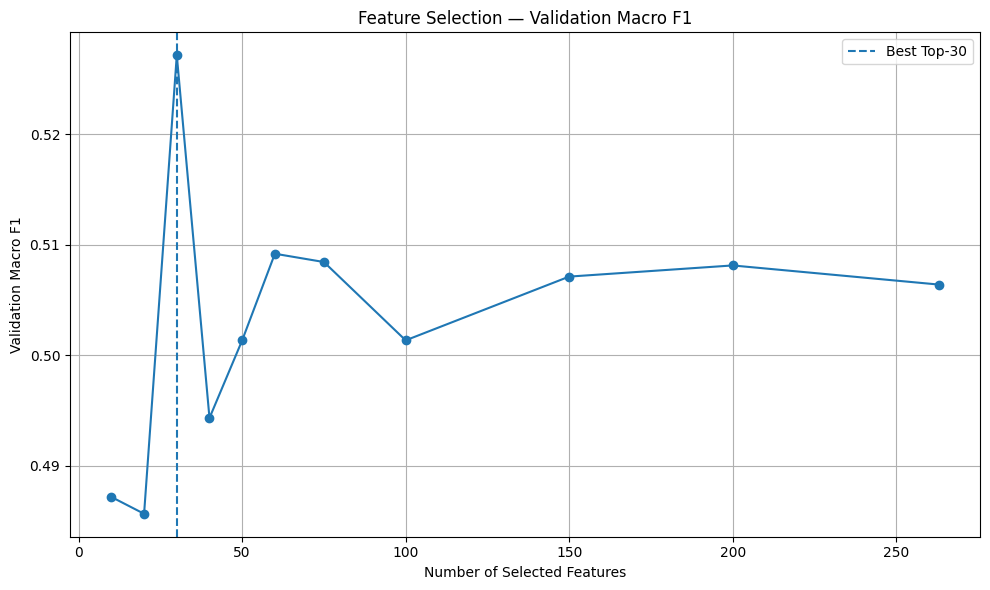


FEATURE SELECTION COMPLETED
Best Top-K             : 30
Validation Macro F1    : 0.5272
Test Macro F1          : 0.4903
Test Accuracy          : 0.5661

Files saved:
 - DecisionTree_Feature_Selection_Results.csv
 - DecisionTree_Selected_Features.csv
 - DecisionTree_FeatureSelected_Model_Results.csv
 - X_train_DecisionTree_Selected.csv
 - X_val_DecisionTree_Selected.csv
 - X_test_DecisionTree_Selected.csv
 - DecisionTree_Feature_Selection_Curve.png


In [106]:
# ============================================================
# DECISION TREE — FEATURE SELECTION USING FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt


# ============================================================
# 1. INITIAL DATA
# ============================================================

print("=" * 100)
print("DECISION TREE — FEATURE SELECTION")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 2. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 3. BEST HYPERPARAMETERS FROM PREVIOUS STEP
# ============================================================

best_params = {
    "criterion": "entropy",
    "max_depth": 8,
    "max_features": None,
    "max_leaf_nodes": None,
    "min_samples_leaf": 20,
    "min_samples_split": 25,
    "class_weight": None
}

print("\n" + "=" * 100)
print("BASE DECISION TREE HYPERPARAMETERS")
print("=" * 100)

for key, value in best_params.items():
    print(f"{key:25s}: {value}")


# ============================================================
# 4. TRAIN REFERENCE DECISION TREE
#    ONLY ON TRAINING DATA
# ============================================================

reference_tree = DecisionTreeClassifier(
    random_state=42,
    **best_params
)

reference_tree.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 5. EXTRACT FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": X_train_clean.columns,
    "importance": reference_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("FEATURE IMPORTANCE RANKING")
print("=" * 100)

print(feature_importance.head(50).to_string(index=False))


# ============================================================
# 6. NON-ZERO FEATURES
# ============================================================

nonzero_features = feature_importance[
    feature_importance["importance"] > 0
].copy()

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total features       : {len(feature_importance)}")
print(f"Non-zero importance  : {len(nonzero_features)}")
print(f"Zero importance      : {len(feature_importance) - len(nonzero_features)}")


# ============================================================
# 7. DEFINE TOP-K FEATURE SETS
# ============================================================

# We test several feature subset sizes.
# 263 = all cleaned features.

candidate_k = [
    10,
    20,
    30,
    40,
    50,
    60,
    75,
    100,
    150,
    200,
    263
]

# Keep only valid values
candidate_k = [
    k for k in candidate_k
    if k <= X_train_clean.shape[1]
]

print("\n" + "=" * 100)
print("FEATURE SELECTION SEARCH SPACE")
print("=" * 100)

print("Candidate Top-K values:")
print(candidate_k)


# ============================================================
# 8. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X, y):

    y_pred = model.predict(X)

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro_F1": f1_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        )
    }


# ============================================================
# 9. FEATURE SELECTION LOOP
# ============================================================

results = []

models = {}

print("\n" + "=" * 100)
print("STARTING FEATURE SELECTION")
print("=" * 100)

for k in candidate_k:

    print(f"\nTesting Top-{k} features...")

    # --------------------------------------------------------
    # Select top-k features
    # --------------------------------------------------------

    selected_features = feature_importance.head(k)["feature"].tolist()

    X_train_k = X_train_clean[selected_features]
    X_val_k = X_val_clean[selected_features]

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model = DecisionTreeClassifier(
        random_state=42,
        **best_params
    )

    model.fit(
        X_train_k,
        y_train
    )

    # --------------------------------------------------------
    # Evaluate Train
    # --------------------------------------------------------

    train_metrics = evaluate_model(
        model,
        X_train_k,
        y_train
    )

    # --------------------------------------------------------
    # Evaluate Validation
    # --------------------------------------------------------

    val_metrics = evaluate_model(
        model,
        X_val_k,
        y_val
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results.append({
        "Top_K": k,
        "Train_Accuracy": train_metrics["Accuracy"],
        "Train_Precision": train_metrics["Precision"],
        "Train_Recall": train_metrics["Recall"],
        "Train_Macro_F1": train_metrics["Macro_F1"],
        "Validation_Accuracy": val_metrics["Accuracy"],
        "Validation_Precision": val_metrics["Precision"],
        "Validation_Recall": val_metrics["Recall"],
        "Validation_Macro_F1": val_metrics["Macro_F1"]
    })

    models[k] = model

    print(
        f"Top-{k:3d} | "
        f"Train F1 = {train_metrics['Macro_F1']:.4f} | "
        f"Validation F1 = {val_metrics['Macro_F1']:.4f}"
    )


# ============================================================
# 10. RESULTS TABLE
# ============================================================

selection_results = pd.DataFrame(results)

selection_results = selection_results.sort_values(
    by="Validation_Macro_F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("FEATURE SELECTION RESULTS")
print("=" * 100)

print(
    selection_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 11. FIND BEST NUMBER OF FEATURES
# ============================================================

best_row = selection_results.iloc[0]

best_k = int(best_row["Top_K"])

print("\n" + "=" * 100)
print("BEST FEATURE SET")
print("=" * 100)

print(f"Best number of features : {best_k}")
print(
    f"Best Validation Macro F1 : "
    f"{best_row['Validation_Macro_F1']:.4f}"
)


# ============================================================
# 12. SELECT BEST FEATURES
# ============================================================

selected_features = feature_importance.head(best_k)["feature"].tolist()

X_train_selected = X_train_clean[selected_features]
X_val_selected = X_val_clean[selected_features]
X_test_selected = X_test_clean[selected_features]


print("\n" + "=" * 100)
print("FINAL SELECTED DATA")
print("=" * 100)

print(f"X_train_selected : {X_train_selected.shape}")
print(f"X_val_selected   : {X_val_selected.shape}")
print(f"X_test_selected  : {X_test_selected.shape}")


# ============================================================
# 13. SHOW SELECTED FEATURES
# ============================================================

selected_feature_table = feature_importance[
    feature_importance["feature"].isin(selected_features)
].copy()

selected_feature_table = selected_feature_table.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

selected_feature_table.insert(
    0,
    "Rank",
    range(1, len(selected_feature_table) + 1)
)

print("\n" + "=" * 100)
print("SELECTED FEATURES")
print("=" * 100)

print(
    selected_feature_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 14. TRAIN FINAL MODEL ON SELECTED FEATURES
# ============================================================

final_dt = DecisionTreeClassifier(
    random_state=42,
    **best_params
)

final_dt.fit(
    X_train_selected,
    y_train
)


# ============================================================
# 15. PREDICTIONS
# ============================================================

y_train_pred = final_dt.predict(X_train_selected)
y_val_pred = final_dt.predict(X_val_selected)
y_test_pred = final_dt.predict(X_test_selected)


# ============================================================
# 16. METRICS FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }


train_metrics = calculate_metrics(
    y_train,
    y_train_pred
)

val_metrics = calculate_metrics(
    y_val,
    y_val_pred
)

test_metrics = calculate_metrics(
    y_test,
    y_test_pred
)


# ============================================================
# 17. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEATURE-SELECTED DECISION TREE RESULTS")
print("=" * 100)


print("\n" + "-" * 80)
print("TRAIN")
print("-" * 80)

print(f"Accuracy  : {train_metrics['Accuracy']:.4f}")
print(f"Precision : {train_metrics['Precision']:.4f}")
print(f"Recall    : {train_metrics['Recall']:.4f}")
print(f"Macro F1  : {train_metrics['Macro_F1']:.4f}")


print("\n" + "-" * 80)
print("VALIDATION")
print("-" * 80)

print(f"Accuracy  : {val_metrics['Accuracy']:.4f}")
print(f"Precision : {val_metrics['Precision']:.4f}")
print(f"Recall    : {val_metrics['Recall']:.4f}")
print(f"Macro F1  : {val_metrics['Macro_F1']:.4f}")


print("\n" + "-" * 80)
print("TEST")
print("-" * 80)

print(f"Accuracy  : {test_metrics['Accuracy']:.4f}")
print(f"Precision : {test_metrics['Precision']:.4f}")
print(f"Recall    : {test_metrics['Recall']:.4f}")
print(f"Macro F1  : {test_metrics['Macro_F1']:.4f}")


# ============================================================
# 18. OVERFITTING CHECK
# ============================================================

print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

accuracy_gap = (
    train_metrics["Accuracy"]
    - val_metrics["Accuracy"]
)

f1_gap = (
    train_metrics["Macro_F1"]
    - val_metrics["Macro_F1"]
)

print(f"Train Accuracy      : {train_metrics['Accuracy']:.4f}")
print(f"Validation Accuracy : {val_metrics['Accuracy']:.4f}")
print(f"Difference          : {accuracy_gap:.4f}")

print()

print(f"Train Macro F1      : {train_metrics['Macro_F1']:.4f}")
print(f"Validation Macro F1 : {val_metrics['Macro_F1']:.4f}")
print(f"Difference          : {f1_gap:.4f}")


# ============================================================
# 19. CLASSIFICATION REPORT — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 20. CLASSIFICATION REPORT — TEST
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 21. CONFUSION MATRIX — VALIDATION
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 100)

print(cm_val)


# ============================================================
# 22. CONFUSION MATRIX — TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - TEST")
print("=" * 100)

print(cm_test)


# ============================================================
# 23. FINAL MODEL INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL DECISION TREE INFORMATION")
print("=" * 100)

print(f"Original features     : {X_train_clean.shape[1]}")
print(f"Selected features     : {best_k}")
print(f"Removed by selection  : {X_train_clean.shape[1] - best_k}")

print(f"Tree depth            : {final_dt.get_depth()}")
print(f"Number of leaves      : {final_dt.get_n_leaves()}")
print(f"Number of nodes       : {final_dt.tree_.node_count}")


# ============================================================
# 24. FEATURE REDUCTION RATIO
# ============================================================

reduction_ratio = (
    1 - (best_k / X_train_clean.shape[1])
) * 100

print(
    f"Feature reduction     : "
    f"{reduction_ratio:.2f}%"
)


# ============================================================
# 25. FINAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Dataset": [
        "TRAIN",
        "VALIDATION",
        "TEST"
    ],

    "Accuracy": [
        train_metrics["Accuracy"],
        val_metrics["Accuracy"],
        test_metrics["Accuracy"]
    ],

    "Precision": [
        train_metrics["Precision"],
        val_metrics["Precision"],
        test_metrics["Precision"]
    ],

    "Recall": [
        train_metrics["Recall"],
        val_metrics["Recall"],
        test_metrics["Recall"]
    ],

    "Macro_F1": [
        train_metrics["Macro_F1"],
        val_metrics["Macro_F1"],
        test_metrics["Macro_F1"]
    ]
})


print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 26. SAVE FEATURE SELECTION RESULTS
# ============================================================

selection_results.to_csv(
    "DecisionTree_Feature_Selection_Results.csv",
    index=False
)


# ============================================================
# 27. SAVE SELECTED FEATURES
# ============================================================

selected_feature_table.to_csv(
    "DecisionTree_Selected_Features.csv",
    index=False
)


# ============================================================
# 28. SAVE FINAL MODEL RESULTS
# ============================================================

final_model_results = pd.DataFrame({

    "Dataset": [
        "TRAIN",
        "VALIDATION",
        "TEST"
    ],

    "Accuracy": [
        train_metrics["Accuracy"],
        val_metrics["Accuracy"],
        test_metrics["Accuracy"]
    ],

    "Precision": [
        train_metrics["Precision"],
        val_metrics["Precision"],
        test_metrics["Precision"]
    ],

    "Recall": [
        train_metrics["Recall"],
        val_metrics["Recall"],
        test_metrics["Recall"]
    ],

    "Macro_F1": [
        train_metrics["Macro_F1"],
        val_metrics["Macro_F1"],
        test_metrics["Macro_F1"]
    ],

    "Number_of_Features": [
        best_k,
        best_k,
        best_k
    ]
})


final_model_results.to_csv(
    "DecisionTree_FeatureSelected_Model_Results.csv",
    index=False
)


# ============================================================
# 29. SAVE SELECTED DATASETS
# ============================================================

X_train_selected.to_csv(
    "X_train_DecisionTree_Selected.csv",
    index=False
)

X_val_selected.to_csv(
    "X_val_DecisionTree_Selected.csv",
    index=False
)

X_test_selected.to_csv(
    "X_test_DecisionTree_Selected.csv",
    index=False
)


# ============================================================
# 30. PLOT VALIDATION MACRO F1 VS NUMBER OF FEATURES
# ============================================================

plot_data = selection_results.sort_values(
    by="Top_K"
)

plt.figure(figsize=(10, 6))

plt.plot(
    plot_data["Top_K"],
    plot_data["Validation_Macro_F1"],
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best Top-{best_k}"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Validation Macro F1")
plt.title("Feature Selection — Validation Macro F1")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "DecisionTree_Feature_Selection_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 31. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 100)
print("FEATURE SELECTION COMPLETED")
print("=" * 100)

print(f"Best Top-K             : {best_k}")
print(f"Validation Macro F1    : {val_metrics['Macro_F1']:.4f}")
print(f"Test Macro F1          : {test_metrics['Macro_F1']:.4f}")
print(f"Test Accuracy          : {test_metrics['Accuracy']:.4f}")

print("\nFiles saved:")
print(" - DecisionTree_Feature_Selection_Results.csv")
print(" - DecisionTree_Selected_Features.csv")
print(" - DecisionTree_FeatureSelected_Model_Results.csv")
print(" - X_train_DecisionTree_Selected.csv")
print(" - X_val_DecisionTree_Selected.csv")
print(" - X_test_DecisionTree_Selected.csv")
print(" - DecisionTree_Feature_Selection_Curve.png")

print("=" * 100)

In [107]:
# ============================================================
# DECISION TREE — HYPERPARAMETER OPTIMIZATION
# AFTER FEATURE SELECTION (TOP-30)
# ============================================================

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. CHECK INPUT DATA
# ============================================================

print("=" * 100)
print("DECISION TREE — HYPERPARAMETER OPTIMIZATION")
print("AFTER FEATURE SELECTION")
print("=" * 100)

print(f"X_train_selected : {X_train_selected.shape}")
print(f"X_val_selected   : {X_val_selected.shape}")
print(f"X_test_selected  : {X_test_selected.shape}")

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 2. BASELINE MODEL ON SELECTED FEATURES
# ============================================================

baseline_dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_leaf=20,
    min_samples_split=25,
    max_features=None,
    max_leaf_nodes=None,
    class_weight=None,
    random_state=42
)

baseline_dt.fit(
    X_train_selected,
    y_train
)

y_train_pred_base = baseline_dt.predict(X_train_selected)
y_val_pred_base = baseline_dt.predict(X_val_selected)
y_test_pred_base = baseline_dt.predict(X_test_selected)


def calculate_metrics(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }


baseline_train_metrics = calculate_metrics(
    y_train,
    y_train_pred_base
)

baseline_val_metrics = calculate_metrics(
    y_val,
    y_val_pred_base
)

baseline_test_metrics = calculate_metrics(
    y_test,
    y_test_pred_base
)


print("\n" + "=" * 100)
print("BASELINE — SELECTED 30 FEATURES")
print("=" * 100)

for name, metrics in [
    ("TRAIN", baseline_train_metrics),
    ("VALIDATION", baseline_val_metrics),
    ("TEST", baseline_test_metrics)
]:

    print("\n" + "-" * 80)
    print(f"BASELINE - {name}")
    print("-" * 80)

    print(f"Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"Precision : {metrics['Precision']:.4f}")
    print(f"Recall    : {metrics['Recall']:.4f}")
    print(f"Macro F1  : {metrics['Macro_F1']:.4f}")


# ============================================================
# 3. HYPERPARAMETER SEARCH SPACE
# ============================================================

print("\n" + "=" * 100)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 100)

param_dist = {

    # Tree splitting criterion
    "criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    # Maximum tree depth
    "max_depth": [
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        14,
        16,
        18,
        None
    ],

    # Minimum number of samples required at a leaf
    "min_samples_leaf": [
        1,
        2,
        3,
        5,
        8,
        10,
        12,
        15,
        20,
        25,
        30,
        40,
        50
    ],

    # Minimum number of samples required to split
    "min_samples_split": [
        2,
        5,
        10,
        15,
        20,
        25,
        30,
        40,
        50,
        60
    ],

    # Number of features considered for split
    "max_features": [
        None,
        "sqrt",
        "log2",
        0.5,
        0.7,
        0.8,
        1.0
    ],

    # Maximum number of leaves
    "max_leaf_nodes": [
        None,
        10,
        20,
        30,
        40,
        50,
        60,
        75,
        100,
        150
    ],

    # Class weighting
    "class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# 4. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. BASE ESTIMATOR
# ============================================================

dt = DecisionTreeClassifier(
    random_state=42
)


# ============================================================
# 6. RANDOMIZED SEARCH
# ============================================================

print("\n" + "=" * 100)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("=" * 100)

print("\nOptimization metric: Macro F1")
print("Cross-validation: Stratified 5-Fold")
print("Number of candidates: 150")
print("Total CV fits: 750")


random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,

    n_iter=150,

    scoring="f1_macro",

    cv=cv_strategy,

    random_state=42,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)


# ============================================================
# 7. FIT SEARCH — ONLY ON TRAIN
# ============================================================

random_search.fit(
    X_train_selected,
    y_train
)


# ============================================================
# 8. BEST PARAMETERS
# ============================================================

best_params = random_search.best_params_
best_cv_score = random_search.best_score_

print("\n" + "=" * 100)
print("BEST HYPERPARAMETERS")
print("=" * 100)

for param, value in best_params.items():
    print(f"{param:25s}: {value}")

print(f"\nBest 5-Fold CV Macro F1: {best_cv_score:.4f}")


# ============================================================
# 9. TRAIN BEST MODEL
# ============================================================

best_dt = DecisionTreeClassifier(
    random_state=42,
    **best_params
)

best_dt.fit(
    X_train_selected,
    y_train
)


# ============================================================
# 10. TREE INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("BEST DECISION TREE INFORMATION")
print("=" * 100)

print(f"Number of features : {best_dt.n_features_in_}")
print(f"Tree depth         : {best_dt.get_depth()}")
print(f"Number of leaves   : {best_dt.get_n_leaves()}")
print(f"Number of nodes    : {best_dt.tree_.node_count}")


# ============================================================
# 11. PREDICTIONS
# ============================================================

y_train_pred = best_dt.predict(X_train_selected)
y_val_pred = best_dt.predict(X_val_selected)
y_test_pred = best_dt.predict(X_test_selected)


# ============================================================
# 12. CALCULATE FINAL METRICS
# ============================================================

train_metrics = calculate_metrics(
    y_train,
    y_train_pred
)

val_metrics = calculate_metrics(
    y_val,
    y_val_pred
)

test_metrics = calculate_metrics(
    y_test,
    y_test_pred
)


# ============================================================
# 13. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("OPTIMIZED DECISION TREE RESULTS")
print("=" * 100)


for name, metrics in [
    ("TRAIN", train_metrics),
    ("VALIDATION", val_metrics),
    ("TEST", test_metrics)
]:

    print("\n" + "-" * 80)
    print(f"OPTIMIZED - {name}")
    print("-" * 80)

    print(f"Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"Precision : {metrics['Precision']:.4f}")
    print(f"Recall    : {metrics['Recall']:.4f}")
    print(f"Macro F1  : {metrics['Macro_F1']:.4f}")


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame([

    {
        "Dataset": "BASELINE - TRAIN",
        **baseline_train_metrics
    },

    {
        "Dataset": "BASELINE - VALIDATION",
        **baseline_val_metrics
    },

    {
        "Dataset": "BASELINE - TEST",
        **baseline_test_metrics
    },

    {
        "Dataset": "OPTIMIZED - TRAIN",
        **train_metrics
    },

    {
        "Dataset": "OPTIMIZED - VALIDATION",
        **val_metrics
    },

    {
        "Dataset": "OPTIMIZED - TEST",
        **test_metrics
    }

])


print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 15. OVERFITTING CHECK
# ============================================================

accuracy_gap = (
    train_metrics["Accuracy"]
    -
    val_metrics["Accuracy"]
)

f1_gap = (
    train_metrics["Macro_F1"]
    -
    val_metrics["Macro_F1"]
)

print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(f"Train Accuracy      : {train_metrics['Accuracy']:.4f}")
print(f"Validation Accuracy : {val_metrics['Accuracy']:.4f}")
print(f"Difference          : {accuracy_gap:.4f}")

print()

print(f"Train Macro F1      : {train_metrics['Macro_F1']:.4f}")
print(f"Validation Macro F1 : {val_metrics['Macro_F1']:.4f}")
print(f"Difference          : {f1_gap:.4f}")


# ============================================================
# 16. CLASSIFICATION REPORT — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 17. CLASSIFICATION REPORT — TEST
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 18. CONFUSION MATRIX — VALIDATION
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 100)

print(cm_val)


# ============================================================
# 19. CONFUSION MATRIX — TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - TEST")
print("=" * 100)

print(cm_test)


# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "feature": X_train_selected.columns,

    "importance": best_dt.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("FINAL FEATURE IMPORTANCE")
print("=" * 100)

print(
    feature_importance.to_string(
        index=False
    )
)


# ============================================================
# 21. FEATURE IMPORTANCE SUMMARY
# ============================================================

non_zero_features = (
    feature_importance["importance"] > 0
).sum()

zero_features = (
    feature_importance["importance"] == 0
).sum()

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total selected features : {len(feature_importance)}")
print(f"Non-zero importance     : {non_zero_features}")
print(f"Zero importance         : {zero_features}")


# ============================================================
# 22. SAVE RESULTS
# ============================================================

comparison.to_csv(
    "DecisionTree_Selected30_Optimized_Model_Results.csv",
    index=False
)

feature_importance.to_csv(
    "DecisionTree_Selected30_Optimized_Feature_Importance.csv",
    index=False
)

best_params_df = pd.DataFrame(
    [
        {
            "parameter": key,
            "value": str(value)
        }
        for key, value in best_params.items()
    ]
)

best_params_df.to_csv(
    "DecisionTree_Selected30_Best_Hyperparameters.csv",
    index=False
)


# ============================================================
# 23. SAVE SELECTED FEATURE LIST
# ============================================================

selected_features_df = pd.DataFrame({

    "rank": range(
        1,
        len(X_train_selected.columns) + 1
    ),

    "feature": X_train_selected.columns

})

selected_features_df.to_csv(
    "DecisionTree_Selected30_Features.csv",
    index=False
)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(f"Selected features : {X_train_selected.shape[1]}")

print(
    f"Best CV Macro F1 : {best_cv_score:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{val_metrics['Macro_F1']:.4f}"
)

print(
    f"Test Macro F1 : "
    f"{test_metrics['Macro_F1']:.4f}"
)

print(
    f"Validation Accuracy : "
    f"{val_metrics['Accuracy']:.4f}"
)

print(
    f"Test Accuracy : "
    f"{test_metrics['Accuracy']:.4f}"
)

print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print("DecisionTree_Selected30_Optimized_Model_Results.csv")
print("DecisionTree_Selected30_Optimized_Feature_Importance.csv")
print("DecisionTree_Selected30_Best_Hyperparameters.csv")
print("DecisionTree_Selected30_Features.csv")

print("\n" + "=" * 100)
print("DECISION TREE — FEATURE SELECTION + HYPERPARAMETER OPTIMIZATION COMPLETED")
print("=" * 100)

DECISION TREE — HYPERPARAMETER OPTIMIZATION
AFTER FEATURE SELECTION
X_train_selected : (3827, 30)
X_val_selected   : (957, 30)
X_test_selected  : (1196, 30)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

BASELINE — SELECTED 30 FEATURES

--------------------------------------------------------------------------------
BASELINE - TRAIN
--------------------------------------------------------------------------------
Accuracy  : 0.6671
Precision : 0.6557
Recall    : 0.5960
Macro F1  : 0.6046

--------------------------------------------------------------------------------
BASELINE - VALIDATION
--------------------------------------------------------------------------------
Accuracy  : 0.5977
Precision : 0.5477
Recall    : 0.5243
Macro F1  : 0.5272

------------------------------------------------------------

In [108]:
# ============================================================
# DECISION TREE
# FEATURE SELECTION + ADASYN
# ============================================================

import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import ADASYN


# ============================================================
# 1. INITIAL INFORMATION
# ============================================================

print("=" * 100)
print("DECISION TREE — FEATURE SELECTION + ADASYN")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 2. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 3. BASE DECISION TREE FOR FEATURE IMPORTANCE
# ============================================================
# IMPORTANT:
# Feature selection is performed ONLY using original training data.
# No ADASYN is applied at this stage.
# ============================================================

print("\n" + "=" * 100)
print("STEP 1 — FEATURE IMPORTANCE FOR FEATURE SELECTION")
print("=" * 100)

feature_selector_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_leaf=20,
    min_samples_split=25,
    class_weight=None,
    random_state=42
)

feature_selector_tree.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 4. FEATURE IMPORTANCE RANKING
# ============================================================

feature_importance = pd.DataFrame({
    "feature": X_train_clean.columns,
    "importance": feature_selector_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

feature_importance["rank"] = (
    np.arange(len(feature_importance)) + 1
)

feature_importance = feature_importance[
    ["rank", "feature", "importance"]
]

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE RANKING")
print("=" * 100)

print(
    feature_importance[
        feature_importance["importance"] > 0
    ].to_string(index=False)
)

print("\nTotal features:",
      len(feature_importance))

print(
    "Non-zero features:",
    (feature_importance["importance"] > 0).sum()
)


# ============================================================
# 5. FEATURE SELECTION SEARCH
# ============================================================
# We test different Top-K values.
# Selection criterion = Validation Macro F1.
#
# NOTE:
# Validation is used here ONLY to choose K.
# ADASYN is NOT used during feature selection.
# ============================================================

TOP_K_VALUES = [
    10,
    20,
    30,
    40,
    50,
    60,
    75,
    100,
    150,
    200,
    len(feature_importance)
]

TOP_K_VALUES = sorted(
    list(set(
        k for k in TOP_K_VALUES
        if k <= len(feature_importance)
    ))
)

print("\n" + "=" * 100)
print("FEATURE SELECTION SEARCH")
print("=" * 100)

print("Candidate Top-K values:")
print(TOP_K_VALUES)


feature_selection_results = []


for k in TOP_K_VALUES:

    print(f"\nTesting Top-{k} features...")

    selected_features = feature_importance.head(k)["feature"].tolist()

    X_train_k = X_train_clean[selected_features]
    X_val_k = X_val_clean[selected_features]

    model_k = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=20,
        min_samples_split=25,
        class_weight=None,
        random_state=42
    )

    model_k.fit(
        X_train_k,
        y_train
    )

    train_pred = model_k.predict(X_train_k)
    val_pred = model_k.predict(X_val_k)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    train_precision = precision_score(
        y_train,
        train_pred,
        average="macro",
        zero_division=0
    )

    train_recall = recall_score(
        y_train,
        train_pred,
        average="macro",
        zero_division=0
    )

    train_f1 = f1_score(
        y_train,
        train_pred,
        average="macro",
        zero_division=0
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    val_precision = precision_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    feature_selection_results.append({
        "Top_K": k,

        "Train_Accuracy": train_accuracy,
        "Train_Precision": train_precision,
        "Train_Recall": train_recall,
        "Train_Macro_F1": train_f1,

        "Validation_Accuracy": val_accuracy,
        "Validation_Precision": val_precision,
        "Validation_Recall": val_recall,
        "Validation_Macro_F1": val_f1
    })

    print(
        f"Top-{k:3d} | "
        f"Train F1 = {train_f1:.4f} | "
        f"Validation F1 = {val_f1:.4f}"
    )


# ============================================================
# 6. FEATURE SELECTION RESULTS
# ============================================================

feature_selection_results_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_results_df = (
    feature_selection_results_df
    .sort_values(
        by="Validation_Macro_F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FEATURE SELECTION RESULTS")
print("=" * 100)

print(
    feature_selection_results_df.to_string(
        index=False
    )
)


# ============================================================
# 7. SELECT BEST K
# ============================================================

best_k = int(
    feature_selection_results_df.iloc[0]["Top_K"]
)

best_validation_f1 = (
    feature_selection_results_df.iloc[0]
    ["Validation_Macro_F1"]
)

selected_features = (
    feature_importance
    .head(best_k)
    ["feature"]
    .tolist()
)

print("\n" + "=" * 100)
print("BEST FEATURE SET")
print("=" * 100)

print(
    f"Best number of features : {best_k}"
)

print(
    f"Best Validation Macro F1 : "
    f"{best_validation_f1:.4f}"
)


# ============================================================
# 8. CREATE SELECTED DATA
# ============================================================

X_train_selected = X_train_clean[
    selected_features
].copy()

X_val_selected = X_val_clean[
    selected_features
].copy()

X_test_selected = X_test_clean[
    selected_features
].copy()


print("\n" + "=" * 100)
print("SELECTED DATA")
print("=" * 100)

print(
    "X_train_selected :",
    X_train_selected.shape
)

print(
    "X_val_selected   :",
    X_val_selected.shape
)

print(
    "X_test_selected  :",
    X_test_selected.shape
)


# ============================================================
# 9. SELECTED FEATURES
# ============================================================

selected_feature_table = (
    feature_importance
    .head(best_k)
    .copy()
)

print("\n" + "=" * 100)
print("SELECTED FEATURES")
print("=" * 100)

print(
    selected_feature_table.to_string(
        index=False
    )
)


# ============================================================
# 10. APPLY ADASYN
# ============================================================
# VERY IMPORTANT:
# ADASYN is applied ONLY to TRAINING data.
#
# Validation and Test remain completely untouched.
# ============================================================

print("\n" + "=" * 100)
print("STEP 2 — ADASYN")
print("=" * 100)

print("\nOriginal Training Distribution:")

print(
    y_train.value_counts()
    .sort_index()
)


adasyn = ADASYN(
    sampling_strategy="auto",
    random_state=42,
    n_neighbors=5
)


X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train_selected,
    y_train
)


print("\nADASYN Training Distribution:")

print(
    pd.Series(y_train_adasyn)
    .value_counts()
    .sort_index()
)

print("\nOriginal training shape:")
print(X_train_selected.shape)

print("\nADASYN training shape:")
print(X_train_adasyn.shape)


# ============================================================
# 11. TRAIN SELECTED DECISION TREE ON ADASYN DATA
# ============================================================

print("\n" + "=" * 100)
print("STEP 3 — TRAIN DECISION TREE AFTER ADASYN")
print("=" * 100)

adasyn_dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_leaf=20,
    min_samples_split=25,
    class_weight=None,
    random_state=42
)

adasyn_dt.fit(
    X_train_adasyn,
    y_train_adasyn
)


# ============================================================
# 12. PREDICTIONS
# ============================================================

y_train_pred = adasyn_dt.predict(
    X_train_adasyn
)

y_val_pred = adasyn_dt.predict(
    X_val_selected
)

y_test_pred = adasyn_dt.predict(
    X_test_selected
)


# ============================================================
# 13. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    y_true,
    y_pred,
    dataset_name
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "-" * 80)
    print(dataset_name)
    print("-" * 80)

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"Macro F1  : {macro_f1:.4f}"
    )

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro_F1": macro_f1
    }


# ============================================================
# 14. MODEL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("ADASYN DECISION TREE RESULTS")
print("=" * 100)

results = []

results.append(
    evaluate_model(
        y_train_adasyn,
        y_train_pred,
        "ADASYN - TRAIN"
    )
)

results.append(
    evaluate_model(
        y_val,
        y_val_pred,
        "ADASYN - VALIDATION"
    )
)

results.append(
    evaluate_model(
        y_test,
        y_test_pred,
        "ADASYN - TEST"
    )
)


results_df = pd.DataFrame(results)


# ============================================================
# 15. CLASSIFICATION REPORT — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. CLASSIFICATION REPORT — TEST
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 17. CONFUSION MATRIX — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — VALIDATION")
print("=" * 100)

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print(cm_val)


# ============================================================
# 18. CONFUSION MATRIX — TEST
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — TEST")
print("=" * 100)

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm_test)


# ============================================================
# 19. OVERFITTING CHECK
# ============================================================

train_f1 = f1_score(
    y_train_adasyn,
    y_train_pred,
    average="macro",
    zero_division=0
)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    average="macro",
    zero_division=0
)

train_accuracy = accuracy_score(
    y_train_adasyn,
    y_train_pred
)

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(
    f"Train Accuracy      : "
    f"{train_accuracy:.4f}"
)

print(
    f"Validation Accuracy : "
    f"{val_accuracy:.4f}"
)

print(
    f"Difference          : "
    f"{train_accuracy - val_accuracy:.4f}"
)

print()

print(
    f"Train Macro F1      : "
    f"{train_f1:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{val_f1:.4f}"
)

print(
    f"Difference          : "
    f"{train_f1 - val_f1:.4f}"
)


# ============================================================
# 20. FEATURE IMPORTANCE AFTER ADASYN
# ============================================================

adasyn_feature_importance = pd.DataFrame({
    "feature": X_train_selected.columns,
    "importance": adasyn_dt.feature_importances_
})

adasyn_feature_importance = (
    adasyn_feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE — ADASYN MODEL")
print("=" * 100)

print(
    adasyn_feature_importance[
        adasyn_feature_importance["importance"] > 0
    ].to_string(index=False)
)

print("\nTotal selected features:",
      len(adasyn_feature_importance))

print(
    "Non-zero importance:",
    (
        adasyn_feature_importance["importance"] > 0
    ).sum()
)

print(
    "Zero importance:",
    (
        adasyn_feature_importance["importance"] == 0
    ).sum()
)


# ============================================================
# 21. DECISION TREE INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("ADASYN DECISION TREE INFORMATION")
print("=" * 100)

print(
    "Number of features :",
    X_train_selected.shape[1]
)

print(
    "Tree depth         :",
    adasyn_dt.get_depth()
)

print(
    "Number of leaves   :",
    adasyn_dt.get_n_leaves()
)

print(
    "Number of nodes    :",
    adasyn_dt.tree_.node_count
)


# ============================================================
# 22. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "DecisionTree_Selected_ADASYN_Model_Results.csv",
    index=False
)

feature_selection_results_df.to_csv(
    "DecisionTree_ADASYN_Feature_Selection_Results.csv",
    index=False
)

selected_feature_table.to_csv(
    "DecisionTree_ADASYN_Selected_Features.csv",
    index=False
)

adasyn_feature_importance.to_csv(
    "DecisionTree_Selected_ADASYN_Feature_Importance.csv",
    index=False
)


# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(
    f"Original cleaned features : "
    f"{X_train_clean.shape[1]}"
)

print(
    f"Selected features         : "
    f"{best_k}"
)

print(
    f"Feature reduction         : "
    f"{(1 - best_k / X_train_clean.shape[1]) * 100:.2f}%"
)

print(
    f"Feature Selection Val F1  : "
    f"{best_validation_f1:.4f}"
)

print(
    f"ADASYN Validation F1      : "
    f"{val_f1:.4f}"
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

print(
    f"ADASYN Test F1            : "
    f"{test_f1:.4f}"
)

print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "DecisionTree_Selected_ADASYN_Model_Results.csv"
)

print(
    "DecisionTree_ADASYN_Feature_Selection_Results.csv"
)

print(
    "DecisionTree_ADASYN_Selected_Features.csv"
)

print(
    "DecisionTree_Selected_ADASYN_Feature_Importance.csv"
)

print("\n" + "=" * 100)
print("FEATURE SELECTION + ADASYN COMPLETED")
print("=" * 100)

DECISION TREE — FEATURE SELECTION + ADASYN
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

STEP 1 — FEATURE IMPORTANCE FOR FEATURE SELECTION

FEATURE IMPORTANCE RANKING
 rank                              feature  importance
    1 Street lighting_Unknown / not stated    0.320357
    2                         DCA_category    0.079847
    3 Firstimpacttype_Vehicle - Pedestrian    0.076299
    4          key_tu_type_group_Two-wheel    0.066989
    5        other_tu_type_group_Two-wheel    0.061340
    6            OtherTUtype_Motor scooter    0.030942
    7              KeyTUtype_Motor scooter    0.028976
    8                  dew_point_2m_C_mean    0.024015
    9              OtherTUtype_Pedal cycle    0.023796
   10        

In [109]:
# ============================================================
# XGBOOST — BASELINE MODEL ON ALL CLEANED FEATURES
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. DATA CHECK
# ============================================================

print("=" * 100)
print("XGBOOST — BASELINE WITH ALL CLEANED FEATURES")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())


# ============================================================
# 2. MAKE SURE DATA ARE NUMERIC
# ============================================================

X_train_xgb = X_train_clean.copy()
X_val_xgb   = X_val_clean.copy()
X_test_xgb  = X_test_clean.copy()

# تبدیل نام ستون‌ها به string
X_train_xgb.columns = X_train_xgb.columns.astype(str)
X_val_xgb.columns   = X_val_xgb.columns.astype(str)
X_test_xgb.columns  = X_test_xgb.columns.astype(str)

# بررسی NaN
print("\n" + "=" * 100)
print("MISSING VALUE CHECK")
print("=" * 100)

print("Train NaN :", X_train_xgb.isna().sum().sum())
print("Val NaN   :", X_val_xgb.isna().sum().sum())
print("Test NaN  :", X_test_xgb.isna().sum().sum())


# اگر NaN وجود داشته باشد، XGBoost می‌تواند آن را مدیریت کند.
# بنابراین فعلاً imputation انجام نمی‌دهیم.


# ============================================================
# 3. BASELINE XGBOOST
# ============================================================

print("\n" + "=" * 100)
print("TRAINING BASELINE XGBOOST")
print("=" * 100)

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,

    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0,
    reg_alpha=0,
    reg_lambda=1,

    random_state=42,
    eval_metric="mlogloss",

    n_jobs=-1,
    tree_method="hist"
)


# ============================================================
# 4. TRAIN
# ============================================================

xgb_model.fit(
    X_train_xgb,
    y_train
)


# ============================================================
# 5. PREDICTIONS
# ============================================================

y_train_pred = xgb_model.predict(X_train_xgb)
y_val_pred   = xgb_model.predict(X_val_xgb)
y_test_pred  = xgb_model.predict(X_test_xgb)


# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_model(y_true, y_pred, dataset_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "-" * 80)
    print(f"XGBOOST - {dataset_name}")
    print("-" * 80)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro_F1": macro_f1
    }


# ============================================================
# 7. EVALUATE TRAIN / VALIDATION / TEST
# ============================================================

results = []

results.append(
    evaluate_model(
        y_train,
        y_train_pred,
        "TRAIN"
    )
)

results.append(
    evaluate_model(
        y_val,
        y_val_pred,
        "VALIDATION"
    )
)

results.append(
    evaluate_model(
        y_test,
        y_test_pred,
        "TEST"
    )
)


# ============================================================
# 8. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

print(results_df.to_string(index=False))


# ============================================================
# 9. OVERFITTING CHECK
# ============================================================

train_accuracy = results_df.loc[
    results_df["Dataset"] == "TRAIN",
    "Accuracy"
].values[0]

val_accuracy = results_df.loc[
    results_df["Dataset"] == "VALIDATION",
    "Accuracy"
].values[0]

train_f1 = results_df.loc[
    results_df["Dataset"] == "TRAIN",
    "Macro_F1"
].values[0]

val_f1 = results_df.loc[
    results_df["Dataset"] == "VALIDATION",
    "Macro_F1"
].values[0]


print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(f"Train Accuracy      : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Difference          : {train_accuracy - val_accuracy:.4f}")

print()

print(f"Train Macro F1      : {train_f1:.4f}")
print(f"Validation Macro F1 : {val_f1:.4f}")
print(f"Difference          : {train_f1 - val_f1:.4f}")


# ============================================================
# 10. CLASSIFICATION REPORT — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 11. CLASSIFICATION REPORT — TEST
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 12. CONFUSION MATRIX — VALIDATION
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 100)

print(cm_val)


# ============================================================
# 13. CONFUSION MATRIX — TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print("\n" + "=" * 100)
print("CONFUSION MATRIX - TEST")
print("=" * 100)

print(cm_test)


# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": X_train_xgb.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 100)

print(
    feature_importance.head(50).to_string(index=False)
)


# ============================================================
# 15. FEATURE IMPORTANCE SUMMARY
# ============================================================

non_zero = (
    feature_importance["importance"] > 0
).sum()

zero = (
    feature_importance["importance"] == 0
).sum()

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total features       : {len(feature_importance)}")
print(f"Non-zero importance  : {non_zero}")
print(f"Zero importance      : {zero}")


# ============================================================
# 16. MODEL INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("XGBOOST MODEL INFORMATION")
print("=" * 100)

print(f"Number of features : {X_train_xgb.shape[1]}")
print(f"Number of trees   : {xgb_model.n_estimators}")
print(f"Max depth         : {xgb_model.max_depth}")
print(f"Learning rate     : {xgb_model.learning_rate}")


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "XGBoost_AllCleanedFeatures_Model_Results.csv",
    index=False
)

feature_importance.to_csv(
    "XGBoost_AllCleanedFeatures_Feature_Importance.csv",
    index=False
)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(f"Features used              : {X_train_xgb.shape[1]}")
print(f"Train Macro F1             : {train_f1:.4f}")
print(f"Validation Macro F1        : {val_f1:.4f}")

test_f1 = results_df.loc[
    results_df["Dataset"] == "TEST",
    "Macro_F1"
].values[0]

test_accuracy = results_df.loc[
    results_df["Dataset"] == "TEST",
    "Accuracy"
].values[0]

print(f"Test Macro F1              : {test_f1:.4f}")
print(f"Test Accuracy              : {test_accuracy:.4f}")

print("\n" + "=" * 100)
print("XGBOOST BASELINE COMPLETED")
print("=" * 100)

XGBOOST — BASELINE WITH ALL CLEANED FEATURES
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

MISSING VALUE CHECK
Train NaN : 0
Val NaN   : 0
Test NaN  : 0

TRAINING BASELINE XGBOOST

--------------------------------------------------------------------------------
XGBOOST - TRAIN
--------------------------------------------------------------------------------
Accuracy  : 0.9527
Precision : 0.9633
Recall    : 0.9347
Macro F1  : 0.9477

--------------------------------------------------------------------------------
XGBOOST - VALIDATION
--------------------------------------------------------------------------------
Accuracy  : 0.5935
Precision : 0.5257
Recall    : 0.4846
Macro F1  : 0.4849

----------------------------------

In [110]:
# ============================================================
# XGBOOST — HYPERPARAMETER OPTIMIZATION
# ALL 263 CLEANED FEATURES
# ============================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 1. DATA
# ============================================================

print("=" * 100)
print("XGBOOST — HYPERPARAMETER OPTIMIZATION")
print("ALL CLEANED FEATURES")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 2. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())


# ============================================================
# 3. BASE XGBOOST MODEL
# ============================================================

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1,

    tree_method="hist",

    verbosity=0
)


# ============================================================
# 4. HYPERPARAMETER SEARCH SPACE
# ============================================================

param_dist = {

    # Number of boosting rounds
    "n_estimators": [
        100,
        150,
        200,
        250,
        300,
        400,
        500,
        600
    ],

    # Learning rate
    "learning_rate": [
        0.01,
        0.02,
        0.03,
        0.05,
        0.07,
        0.10,
        0.15
    ],

    # Tree complexity
    "max_depth": [
        2,
        3,
        4,
        5,
        6,
        7,
        8
    ],

    # Minimum child weight
    "min_child_weight": [
        1,
        3,
        5,
        7,
        10,
        15,
        20
    ],

    # Minimum loss reduction
    "gamma": [
        0,
        0.1,
        0.3,
        0.5,
        1,
        1.5,
        2,
        3
    ],

    # Row subsampling
    "subsample": [
        0.60,
        0.70,
        0.80,
        0.90,
        1.00
    ],

    # Feature subsampling
    "colsample_bytree": [
        0.60,
        0.70,
        0.80,
        0.90,
        1.00
    ],

    # L1 regularization
    "reg_alpha": [
        0,
        0.01,
        0.1,
        0.3,
        0.5,
        1,
        2
    ],

    # L2 regularization
    "reg_lambda": [
        0.5,
        1,
        1.5,
        2,
        3,
        5,
        10
    ]
}


# ============================================================
# 5. STRATIFIED 5-FOLD CV
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 6. RANDOMIZED SEARCH
# ============================================================

print("\n" + "=" * 100)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("=" * 100)

print("\nOptimization metric : Macro F1")
print("Cross-validation    : Stratified 5-Fold")
print("Number of candidates: 150")
print("Total CV fits       : 750")


random_search = RandomizedSearchCV(
    estimator=xgb_base,

    param_distributions=param_dist,

    n_iter=150,

    scoring="f1_macro",

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=True
)


# ============================================================
# 7. FIT SEARCH — TRAIN ONLY
# ============================================================

random_search.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 8. BEST PARAMETERS
# ============================================================

print("\n" + "=" * 100)
print("BEST HYPERPARAMETERS")
print("=" * 100)

best_params = random_search.best_params_

for param, value in best_params.items():
    print(f"{param:25s}: {value}")

print("\nBest 5-Fold CV Macro F1:",
      f"{random_search.best_score_:.4f}")


# ============================================================
# 9. BEST MODEL
# ============================================================

best_xgb = random_search.best_estimator_


print("\n" + "=" * 100)
print("BEST XGBOOST MODEL INFORMATION")
print("=" * 100)

print(f"Number of features : {X_train_clean.shape[1]}")
print(f"Number of trees    : {best_xgb.n_estimators}")
print(f"Max depth          : {best_xgb.max_depth}")
print(f"Learning rate      : {best_xgb.learning_rate}")


# ============================================================
# 10. PREDICTION FUNCTION
# ============================================================

def evaluate_model(model, X, y, dataset_name):

    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)

    precision = precision_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "-" * 80)
    print(f"{dataset_name}")
    print("-" * 80)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro_F1": macro_f1
    }


# ============================================================
# 11. FINAL EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("OPTIMIZED XGBOOST RESULTS")
print("=" * 100)

results = []

results.append(
    evaluate_model(
        best_xgb,
        X_train_clean,
        y_train,
        "OPTIMIZED - TRAIN"
    )
)

results.append(
    evaluate_model(
        best_xgb,
        X_val_clean,
        y_val,
        "OPTIMIZED - VALIDATION"
    )
)

results.append(
    evaluate_model(
        best_xgb,
        X_test_clean,
        y_test,
        "OPTIMIZED - TEST"
    )
)


# ============================================================
# 12. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 13. OVERFITTING CHECK
# ============================================================

train_f1 = results_df.loc[
    results_df["Dataset"] == "OPTIMIZED - TRAIN",
    "Macro_F1"
].iloc[0]

val_f1 = results_df.loc[
    results_df["Dataset"] == "OPTIMIZED - VALIDATION",
    "Macro_F1"
].iloc[0]

train_acc = results_df.loc[
    results_df["Dataset"] == "OPTIMIZED - TRAIN",
    "Accuracy"
].iloc[0]

val_acc = results_df.loc[
    results_df["Dataset"] == "OPTIMIZED - VALIDATION",
    "Accuracy"
].iloc[0]


print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Difference          : {train_acc - val_acc:.4f}")

print()

print(f"Train Macro F1      : {train_f1:.4f}")
print(f"Validation Macro F1 : {val_f1:.4f}")
print(f"Difference          : {train_f1 - val_f1:.4f}")


# ============================================================
# 14. CLASSIFICATION REPORT — VALIDATION
# ============================================================

y_val_pred = best_xgb.predict(X_val_clean)

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 15. CLASSIFICATION REPORT — TEST
# ============================================================

y_test_pred = best_xgb.predict(X_test_clean)

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT - TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. CONFUSION MATRIX — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX - VALIDATION")
print("=" * 100)

print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)


# ============================================================
# 17. CONFUSION MATRIX — TEST
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX - TEST")
print("=" * 100)

print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)


# ============================================================
# 18. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": X_train_clean.columns,
    "importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 100)

print(
    feature_importance.head(50).to_string(
        index=False
    )
)


# ============================================================
# 19. FEATURE IMPORTANCE SUMMARY
# ============================================================

nonzero_features = (
    feature_importance["importance"] > 0
).sum()

zero_features = (
    feature_importance["importance"] == 0
).sum()

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total features       : {len(feature_importance)}")
print(f"Non-zero importance  : {nonzero_features}")
print(f"Zero importance      : {zero_features}")


# ============================================================
# 20. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "XGBoost_AllFeatures_Optimized_Model_Results.csv",
    index=False
)

feature_importance.to_csv(
    "XGBoost_AllFeatures_Optimized_Feature_Importance.csv",
    index=False
)

pd.DataFrame(
    [best_params]
).to_csv(
    "XGBoost_AllFeatures_Best_Hyperparameters.csv",
    index=False
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(f"Features used          : {X_train_clean.shape[1]}")
print(f"Best CV Macro F1       : {random_search.best_score_:.4f}")
print(f"Validation Macro F1    : {val_f1:.4f}")
print(
    f"Test Macro F1          : "
    f"{results_df.loc[results_df['Dataset'] == 'OPTIMIZED - TEST', 'Macro_F1'].iloc[0]:.4f}"
)
print(
    f"Test Accuracy          : "
    f"{results_df.loc[results_df['Dataset'] == 'OPTIMIZED - TEST', 'Accuracy'].iloc[0]:.4f}"
)

print("\n")
print("=" * 100)
print("XGBOOST HYPERPARAMETER OPTIMIZATION COMPLETED")
print("=" * 100)

XGBOOST — HYPERPARAMETER OPTIMIZATION
ALL CLEANED FEATURES
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

STARTING HYPERPARAMETER OPTIMIZATION

Optimization metric : Macro F1
Cross-validation    : Stratified 5-Fold
Number of candidates: 150
Total CV fits       : 750
Fitting 5 folds for each of 150 candidates, totalling 750 fits

BEST HYPERPARAMETERS
subsample                : 0.6
reg_lambda               : 5
reg_alpha                : 0.1
n_estimators             : 600
min_child_weight         : 3
max_depth                : 2
learning_rate            : 0.15
gamma                    : 0.5
colsample_bytree         : 0.9

Best 5-Fold CV Macro F1: 0.5080

BEST XGBOOST MODEL INFORMATION
Number of features : 263
Number of trees

In [111]:
# ============================================================
# XGBOOST — FEATURE SELECTION
# ALL CLEANED FEATURES
# ============================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 0. INPUT DATA
# ============================================================

# انتظار می‌رود این متغیرها از مراحل قبلی موجود باشند:
#
# X_train_clean
# X_val_clean
# X_test_clean
# y_train
# y_val
# y_test


print("=" * 100)
print("XGBOOST — FEATURE SELECTION")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 1. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())


# ============================================================
# 2. MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 100)
print("MISSING VALUE CHECK")
print("=" * 100)

print(f"Train NaN : {X_train_clean.isna().sum().sum()}")
print(f"Val NaN   : {X_val_clean.isna().sum().sum()}")
print(f"Test NaN  : {X_test_clean.isna().sum().sum()}")


# ============================================================
# 3. BASELINE XGBOOST FOR FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 100)
print("STEP 1 — BASELINE XGBOOST FOR FEATURE IMPORTANCE")
print("=" * 100)


baseline_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

    subsample=1.0,
    colsample_bytree=1.0,

    random_state=42,
    eval_metric="mlogloss",

    n_jobs=-1
)


baseline_model.fit(
    X_train_clean,
    y_train
)


# ============================================================
# 4. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "feature": X_train_clean.columns,
    "importance": baseline_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df["rank"] = np.arange(1, len(importance_df) + 1)

importance_df = importance_df[
    ["rank", "feature", "importance"]
]


print("\n" + "=" * 100)
print("XGBOOST FEATURE IMPORTANCE RANKING")
print("=" * 100)

print(
    importance_df.head(50).to_string(index=False)
)


print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total features       : {len(importance_df)}")
print(
    f"Non-zero importance  : "
    f"{(importance_df['importance'] > 0).sum()}"
)
print(
    f"Zero importance      : "
    f"{(importance_df['importance'] == 0).sum()}"
)


# ============================================================
# 5. FEATURE SELECTION SEARCH SPACE
# ============================================================

candidate_k = [
    10,
    20,
    30,
    40,
    50,
    60,
    75,
    100,
    150,
    200,
    263
]

# فقط Kهایی که از تعداد واقعی ویژگی‌ها بیشتر نباشند
candidate_k = [
    k for k in candidate_k
    if k <= X_train_clean.shape[1]
]


print("\n" + "=" * 100)
print("FEATURE SELECTION SEARCH")
print("=" * 100)

print("Candidate Top-K values:")
print(candidate_k)


# ============================================================
# 6. FEATURE SELECTION
# ============================================================

results = []

selected_features_dict = {}

print("\n" + "=" * 100)
print("STARTING FEATURE SELECTION")
print("=" * 100)


for k in candidate_k:

    print(f"\nTesting Top-{k} features...")

    # --------------------------------------------------------
    # Select top K features
    # --------------------------------------------------------

    selected_features = importance_df.head(k)["feature"].tolist()

    selected_features_dict[k] = selected_features

    X_train_k = X_train_clean[selected_features]
    X_val_k = X_val_clean[selected_features]

    # --------------------------------------------------------
    # Train XGBoost
    # Same baseline hyperparameters
    # --------------------------------------------------------

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,

        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,

        subsample=1.0,
        colsample_bytree=1.0,

        random_state=42,
        eval_metric="mlogloss",

        n_jobs=-1
    )

    model.fit(
        X_train_k,
        y_train
    )

    # --------------------------------------------------------
    # Train prediction
    # --------------------------------------------------------

    y_train_pred = model.predict(X_train_k)

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    train_precision = precision_score(
        y_train,
        y_train_pred,
        average="macro",
        zero_division=0
    )

    train_recall = recall_score(
        y_train,
        y_train_pred,
        average="macro",
        zero_division=0
    )

    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------

    y_val_pred = model.predict(X_val_k)

    val_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    val_precision = precision_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results.append({
        "Top_K": k,

        "Train_Accuracy": train_accuracy,
        "Train_Precision": train_precision,
        "Train_Recall": train_recall,
        "Train_Macro_F1": train_f1,

        "Validation_Accuracy": val_accuracy,
        "Validation_Precision": val_precision,
        "Validation_Recall": val_recall,
        "Validation_Macro_F1": val_f1
    })

    print(
        f"Top-{k:3d} | "
        f"Train F1 = {train_f1:.4f} | "
        f"Validation F1 = {val_f1:.4f}"
    )


# ============================================================
# 7. FEATURE SELECTION RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Validation_Macro_F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("FEATURE SELECTION RESULTS")
print("=" * 100)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 8. BEST FEATURE SET
# ============================================================

best_k = int(
    results_df.iloc[0]["Top_K"]
)

best_val_f1 = results_df.iloc[0]["Validation_Macro_F1"]

best_features = selected_features_dict[best_k]


print("\n" + "=" * 100)
print("BEST FEATURE SET")
print("=" * 100)

print(f"Best number of features : {best_k}")
print(f"Best Validation Macro F1 : {best_val_f1:.4f}")


# ============================================================
# 9. SELECTED DATA
# ============================================================

X_train_selected = X_train_clean[best_features].copy()
X_val_selected = X_val_clean[best_features].copy()
X_test_selected = X_test_clean[best_features].copy()


print("\n" + "=" * 100)
print("SELECTED DATA")
print("=" * 100)

print(
    f"X_train_selected : {X_train_selected.shape}"
)

print(
    f"X_val_selected   : {X_val_selected.shape}"
)

print(
    f"X_test_selected  : {X_test_selected.shape}"
)


# ============================================================
# 10. SELECTED FEATURES
# ============================================================

selected_features_df = importance_df[
    importance_df["feature"].isin(best_features)
].copy()

selected_features_df = selected_features_df.sort_values(
    by="rank"
).reset_index(drop=True)


print("\n" + "=" * 100)
print("SELECTED FEATURES")
print("=" * 100)

print(
    selected_features_df.to_string(index=False)
)


# ============================================================
# 11. FINAL XGBOOST USING SELECTED FEATURES
# ============================================================

print("\n" + "=" * 100)
print("STEP 2 — FINAL XGBOOST WITH SELECTED FEATURES")
print("=" * 100)


final_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,

    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

    subsample=1.0,
    colsample_bytree=1.0,

    random_state=42,
    eval_metric="mlogloss",

    n_jobs=-1
)


final_model.fit(
    X_train_selected,
    y_train
)


# ============================================================
# 12. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X,
    y,
    dataset_name
):

    y_pred = model.predict(X)

    accuracy = accuracy_score(
        y,
        y_pred
    )

    precision = precision_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    print("\n" + "-" * 80)
    print(dataset_name)
    print("-" * 80)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro_F1": macro_f1,
        "y_pred": y_pred
    }


# ============================================================
# 13. FINAL EVALUATION
# ============================================================

train_result = evaluate_model(
    final_model,
    X_train_selected,
    y_train,
    "XGBOOST FEATURE-SELECTED - TRAIN"
)

val_result = evaluate_model(
    final_model,
    X_val_selected,
    y_val,
    "XGBOOST FEATURE-SELECTED - VALIDATION"
)

test_result = evaluate_model(
    final_model,
    X_test_selected,
    y_test,
    "XGBOOST FEATURE-SELECTED - TEST"
)


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

final_results_df = pd.DataFrame([
    {
        "Dataset": train_result["Dataset"],
        "Accuracy": train_result["Accuracy"],
        "Precision": train_result["Precision"],
        "Recall": train_result["Recall"],
        "Macro_F1": train_result["Macro_F1"]
    },
    {
        "Dataset": val_result["Dataset"],
        "Accuracy": val_result["Accuracy"],
        "Precision": val_result["Precision"],
        "Recall": val_result["Recall"],
        "Macro_F1": val_result["Macro_F1"]
    },
    {
        "Dataset": test_result["Dataset"],
        "Accuracy": test_result["Accuracy"],
        "Precision": test_result["Precision"],
        "Recall": test_result["Recall"],
        "Macro_F1": test_result["Macro_F1"]
    }
])


print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

print(
    final_results_df.to_string(index=False)
)


# ============================================================
# 15. OVERFITTING CHECK
# ============================================================

train_acc = train_result["Accuracy"]
val_acc = val_result["Accuracy"]

train_f1 = train_result["Macro_F1"]
val_f1 = val_result["Macro_F1"]


print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Difference          : {train_acc - val_acc:.4f}")

print()

print(f"Train Macro F1      : {train_f1:.4f}")
print(f"Validation Macro F1 : {val_f1:.4f}")
print(f"Difference          : {train_f1 - val_f1:.4f}")


# ============================================================
# 16. CLASSIFICATION REPORT — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        val_result["y_pred"],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 17. CLASSIFICATION REPORT — TEST
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_result["y_pred"],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 18. CONFUSION MATRIX — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — VALIDATION")
print("=" * 100)

cm_val = confusion_matrix(
    y_val,
    val_result["y_pred"]
)

print(cm_val)


# ============================================================
# 19. CONFUSION MATRIX — TEST
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — TEST")
print("=" * 100)

cm_test = confusion_matrix(
    y_test,
    test_result["y_pred"]
)

print(cm_test)


# ============================================================
# 20. FINAL FEATURE IMPORTANCE
# ============================================================

final_importance_df = pd.DataFrame({
    "feature": X_train_selected.columns,
    "importance": final_model.feature_importances_
})

final_importance_df = final_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("FINAL XGBOOST FEATURE IMPORTANCE")
print("=" * 100)

print(
    final_importance_df.head(50).to_string(index=False)
)


print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(
    f"Total selected features : "
    f"{len(final_importance_df)}"
)

print(
    f"Non-zero importance     : "
    f"{(final_importance_df['importance'] > 0).sum()}"
)

print(
    f"Zero importance         : "
    f"{(final_importance_df['importance'] == 0).sum()}"
)


# ============================================================
# 21. MODEL INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL XGBOOST MODEL INFORMATION")
print("=" * 100)

print(
    f"Original features       : "
    f"{X_train_clean.shape[1]}"
)

print(
    f"Selected features       : "
    f"{X_train_selected.shape[1]}"
)

print(
    f"Feature reduction       : "
    f"{(1 - best_k / X_train_clean.shape[1]) * 100:.2f}%"
)

print(
    f"Number of trees         : "
    f"{final_model.n_estimators}"
)

print(
    f"Max depth               : "
    f"{final_model.max_depth}"
)

print(
    f"Learning rate           : "
    f"{final_model.learning_rate}"
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(f"Original features          : {X_train_clean.shape[1]}")
print(f"Selected features          : {best_k}")
print(f"Feature reduction          : {(1 - best_k / X_train_clean.shape[1]) * 100:.2f}%")

print(
    f"Feature Selection Val F1  : "
    f"{best_val_f1:.4f}"
)

print(
    f"Final Validation Macro F1 : "
    f"{val_result['Macro_F1']:.4f}"
)

print(
    f"Final Test Macro F1       : "
    f"{test_result['Macro_F1']:.4f}"
)

print(
    f"Final Test Accuracy       : "
    f"{test_result['Accuracy']:.4f}"
)


# ============================================================
# 23. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "XGBoost_Feature_Selection_Results.csv",
    index=False
)

importance_df.to_csv(
    "XGBoost_All_Feature_Importance.csv",
    index=False
)

selected_features_df.to_csv(
    "XGBoost_Selected_Features.csv",
    index=False
)

final_results_df.to_csv(
    "XGBoost_FeatureSelected_Model_Results.csv",
    index=False
)

final_importance_df.to_csv(
    "XGBoost_FeatureSelected_Final_Importance.csv",
    index=False
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print("XGBoost_Feature_Selection_Results.csv")
print("XGBoost_All_Feature_Importance.csv")
print("XGBoost_Selected_Features.csv")
print("XGBoost_FeatureSelected_Model_Results.csv")
print("XGBoost_FeatureSelected_Final_Importance.csv")

print("\n" + "=" * 100)
print("XGBOOST FEATURE SELECTION COMPLETED")
print("=" * 100)

XGBOOST — FEATURE SELECTION
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

MISSING VALUE CHECK
Train NaN : 0
Val NaN   : 0
Test NaN  : 0

STEP 1 — BASELINE XGBOOST FOR FEATURE IMPORTANCE

XGBOOST FEATURE IMPORTANCE RANKING
 rank                              feature  importance
    1 Street lighting_Unknown / not stated    0.059661
    2                         DCA_category    0.035015
    3          Firstimpacttype_Other angle    0.022873
    4 Firstimpacttype_Vehicle - Pedestrian    0.020071
    5          key_tu_type_group_Two-wheel    0.020017
    6        other_tu_type_group_Two-wheel    0.019783
    7     Firstimpacttype_Vehicle - Object    0.019144
    8              OtherTUtype_Pedal cycle    0.015316
    9        

In [112]:
# ============================================================
# XGBOOST — ALL FEATURES + OPTIMIZED HYPERPARAMETERS
# + CLASS WEIGHT / SAMPLE WEIGHT
# NO FEATURE SELECTION
# NO ADASYN
# ============================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 0. INPUT DATA
# ============================================================

# انتظار می‌رود این متغیرها از مراحل قبل موجود باشند:
#
# X_train_clean
# X_val_clean
# X_test_clean
# y_train
# y_val
# y_test


print("=" * 100)
print("XGBOOST — ALL FEATURES + CLASS WEIGHT")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 1. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())


# ============================================================
# 2. MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 100)
print("MISSING VALUE CHECK")
print("=" * 100)

print(f"Train NaN : {X_train_clean.isna().sum().sum()}")
print(f"Val NaN   : {X_val_clean.isna().sum().sum()}")
print(f"Test NaN  : {X_test_clean.isna().sum().sum()}")


# ============================================================
# 3. OPTIMIZED XGBOOST HYPERPARAMETERS
# ============================================================

best_params = {
    "n_estimators": 600,
    "max_depth": 2,
    "learning_rate": 0.15,
    "subsample": 0.6,
    "colsample_bytree": 0.9,
    "min_child_weight": 3,
    "gamma": 0.5,
    "reg_alpha": 0.1,
    "reg_lambda": 5
}


print("\n" + "=" * 100)
print("OPTIMIZED XGBOOST HYPERPARAMETERS")
print("=" * 100)

for param, value in best_params.items():
    print(f"{param:20s}: {value}")


# ============================================================
# 4. CLASS WEIGHT STRATEGIES
# ============================================================

# توجه:
#
# کلاس‌ها:
# 0 = Property Damage
# 1 = Injury
# 2 = Severe
#
# هدف اصلی:
# افزایش توانایی مدل برای تشخیص کلاس 2
#
# چون XGBClassifier در اینجا از class_weight
# به شکل sklearn استفاده نمی‌کنیم،
# sample_weight به هر مشاهده اختصاص می‌دهیم.


weight_strategies = {

    # --------------------------------------------------------
    # 1. بدون وزن
    # --------------------------------------------------------
    "No Weight": {
        0: 1.0,
        1: 1.0,
        2: 1.0
    },

    # --------------------------------------------------------
    # 2. Balanced
    # تقریبی بر اساس تعداد نمونه‌های Training
    # --------------------------------------------------------
    "Balanced": {
        0: 1.35,
        1: 0.59,
        2: 1.75
    },

    # --------------------------------------------------------
    # 3. Moderate Severe Weight
    # --------------------------------------------------------
    "Severe x2": {
        0: 1.0,
        1: 1.0,
        2: 2.0
    },

    # --------------------------------------------------------
    # 4. Strong Severe Weight
    # --------------------------------------------------------
    "Severe x2.5": {
        0: 1.0,
        1: 1.0,
        2: 2.5
    },

    # --------------------------------------------------------
    # 5. Very Strong Severe Weight
    # --------------------------------------------------------
    "Severe x3": {
        0: 1.0,
        1: 1.0,
        2: 3.0
    }
}


print("\n" + "=" * 100)
print("CLASS WEIGHT STRATEGIES")
print("=" * 100)

for name, weights in weight_strategies.items():

    print(f"\n{name}")

    for cls, weight in weights.items():
        print(f"  Class {cls}: {weight}")


# ============================================================
# 5. FUNCTION TO CREATE SAMPLE WEIGHTS
# ============================================================

def create_sample_weights(y, class_weights):

    return np.array([
        class_weights[int(label)]
        for label in y
    ])


# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }


# ============================================================
# 7. TEST DIFFERENT CLASS WEIGHTS
# ============================================================

print("\n" + "=" * 100)
print("STARTING CLASS WEIGHT EXPERIMENT")
print("=" * 100)

weight_results = []


for strategy_name, class_weights in weight_strategies.items():

    print("\n" + "-" * 90)
    print(f"Testing: {strategy_name}")
    print("-" * 90)

    # --------------------------------------------------------
    # Create sample weights for training data
    # --------------------------------------------------------

    sample_weights = create_sample_weights(
        y_train,
        class_weights
    )

    # --------------------------------------------------------
    # Build XGBoost
    # --------------------------------------------------------

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,

        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],

        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],

        min_child_weight=best_params["min_child_weight"],
        gamma=best_params["gamma"],

        reg_alpha=best_params["reg_alpha"],
        reg_lambda=best_params["reg_lambda"],

        random_state=42,
        eval_metric="mlogloss",

        n_jobs=-1
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_clean,
        y_train,
        sample_weight=sample_weights
    )

    # --------------------------------------------------------
    # Training prediction
    # --------------------------------------------------------

    y_train_pred = model.predict(
        X_train_clean
    )

    train_metrics = calculate_metrics(
        y_train,
        y_train_pred
    )

    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_clean
    )

    val_metrics = calculate_metrics(
        y_val,
        y_val_pred
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    weight_results.append({

        "Weight_Strategy": strategy_name,

        "Class_0_Weight": class_weights[0],
        "Class_1_Weight": class_weights[1],
        "Class_2_Weight": class_weights[2],

        "Train_Accuracy":
            train_metrics["Accuracy"],

        "Train_Precision":
            train_metrics["Precision"],

        "Train_Recall":
            train_metrics["Recall"],

        "Train_Macro_F1":
            train_metrics["Macro_F1"],

        "Validation_Accuracy":
            val_metrics["Accuracy"],

        "Validation_Precision":
            val_metrics["Precision"],

        "Validation_Recall":
            val_metrics["Recall"],

        "Validation_Macro_F1":
            val_metrics["Macro_F1"]
    })

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"Train Macro F1      : "
        f"{train_metrics['Macro_F1']:.4f}"
    )

    print(
        f"Validation Macro F1 : "
        f"{val_metrics['Macro_F1']:.4f}"
    )

    print(
        f"Validation Accuracy : "
        f"{val_metrics['Accuracy']:.4f}"
    )


# ============================================================
# 8. CLASS WEIGHT RESULTS
# ============================================================

weight_results_df = pd.DataFrame(
    weight_results
)

weight_results_df = weight_results_df.sort_values(
    by="Validation_Macro_F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("CLASS WEIGHT COMPARISON")
print("=" * 100)

print(
    weight_results_df.to_string(
        index=False
    )
)


# ============================================================
# 9. BEST CLASS WEIGHT
# ============================================================

best_strategy = (
    weight_results_df.iloc[0]["Weight_Strategy"]
)

best_class_weights = weight_strategies[
    best_strategy
]

best_weight_val_f1 = (
    weight_results_df.iloc[0]["Validation_Macro_F1"]
)


print("\n" + "=" * 100)
print("BEST CLASS WEIGHT STRATEGY")
print("=" * 100)

print(
    f"Best strategy       : "
    f"{best_strategy}"
)

print(
    f"Class 0 weight      : "
    f"{best_class_weights[0]}"
)

print(
    f"Class 1 weight      : "
    f"{best_class_weights[1]}"
)

print(
    f"Class 2 weight      : "
    f"{best_class_weights[2]}"
)

print(
    f"Validation Macro F1 : "
    f"{best_weight_val_f1:.4f}"
)


# ============================================================
# 10. FINAL MODEL WITH BEST CLASS WEIGHT
# ============================================================

print("\n" + "=" * 100)
print("TRAINING FINAL XGBOOST MODEL")
print("=" * 100)


final_sample_weights = create_sample_weights(
    y_train,
    best_class_weights
)


final_model = XGBClassifier(

    objective="multi:softprob",
    num_class=3,

    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],

    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],

    min_child_weight=best_params["min_child_weight"],
    gamma=best_params["gamma"],

    reg_alpha=best_params["reg_alpha"],
    reg_lambda=best_params["reg_lambda"],

    random_state=42,
    eval_metric="mlogloss",

    n_jobs=-1
)


final_model.fit(
    X_train_clean,
    y_train,
    sample_weight=final_sample_weights
)


# ============================================================
# 11. FINAL EVALUATION FUNCTION
# ============================================================

def evaluate_final_model(
    model,
    X,
    y,
    dataset_name
):

    y_pred = model.predict(X)

    metrics = calculate_metrics(
        y,
        y_pred
    )

    print("\n" + "-" * 90)
    print(dataset_name)
    print("-" * 90)

    print(
        f"Accuracy  : "
        f"{metrics['Accuracy']:.4f}"
    )

    print(
        f"Precision : "
        f"{metrics['Precision']:.4f}"
    )

    print(
        f"Recall    : "
        f"{metrics['Recall']:.4f}"
    )

    print(
        f"Macro F1  : "
        f"{metrics['Macro_F1']:.4f}"
    )

    return {
        "Dataset": dataset_name,
        **metrics,
        "y_pred": y_pred
    }


# ============================================================
# 12. FINAL EVALUATION
# ============================================================

train_result = evaluate_final_model(
    final_model,
    X_train_clean,
    y_train,
    "FINAL XGBOOST - TRAIN"
)

val_result = evaluate_final_model(
    final_model,
    X_val_clean,
    y_val,
    "FINAL XGBOOST - VALIDATION"
)

test_result = evaluate_final_model(
    final_model,
    X_test_clean,
    y_test,
    "FINAL XGBOOST - TEST"
)


# ============================================================
# 13. FINAL MODEL COMPARISON
# ============================================================

final_results_df = pd.DataFrame([

    {
        "Dataset":
            train_result["Dataset"],

        "Accuracy":
            train_result["Accuracy"],

        "Precision":
            train_result["Precision"],

        "Recall":
            train_result["Recall"],

        "Macro_F1":
            train_result["Macro_F1"]
    },

    {
        "Dataset":
            val_result["Dataset"],

        "Accuracy":
            val_result["Accuracy"],

        "Precision":
            val_result["Precision"],

        "Recall":
            val_result["Recall"],

        "Macro_F1":
            val_result["Macro_F1"]
    },

    {
        "Dataset":
            test_result["Dataset"],

        "Accuracy":
            test_result["Accuracy"],

        "Precision":
            test_result["Precision"],

        "Recall":
            test_result["Recall"],

        "Macro_F1":
            test_result["Macro_F1"]
    }
])


print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON")
print("=" * 100)

print(
    final_results_df.to_string(
        index=False
    )
)


# ============================================================
# 14. OVERFITTING CHECK
# ============================================================

train_acc = train_result["Accuracy"]
val_acc = val_result["Accuracy"]

train_f1 = train_result["Macro_F1"]
val_f1 = val_result["Macro_F1"]


print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(
    f"Train Accuracy      : "
    f"{train_acc:.4f}"
)

print(
    f"Validation Accuracy : "
    f"{val_acc:.4f}"
)

print(
    f"Difference          : "
    f"{train_acc - val_acc:.4f}"
)

print()

print(
    f"Train Macro F1      : "
    f"{train_f1:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{val_f1:.4f}"
)

print(
    f"Difference          : "
    f"{train_f1 - val_f1:.4f}"
)


# ============================================================
# 15. CLASSIFICATION REPORT — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        val_result["y_pred"],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. CLASSIFICATION REPORT — TEST
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_result["y_pred"],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 17. CONFUSION MATRIX — VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — VALIDATION")
print("=" * 100)

cm_val = confusion_matrix(
    y_val,
    val_result["y_pred"]
)

print(cm_val)


# ============================================================
# 18. CONFUSION MATRIX — TEST
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — TEST")
print("=" * 100)

cm_test = confusion_matrix(
    y_test,
    test_result["y_pred"]
)

print(cm_test)


# ============================================================
# 19. FINAL FEATURE IMPORTANCE
# ============================================================

final_importance_df = pd.DataFrame({

    "feature":
        X_train_clean.columns,

    "importance":
        final_model.feature_importances_
})


final_importance_df = (
    final_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("FINAL XGBOOST FEATURE IMPORTANCE")
print("=" * 100)

print(
    final_importance_df
    .head(50)
    .to_string(index=False)
)


print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(
    f"Total features       : "
    f"{len(final_importance_df)}"
)

print(
    f"Non-zero importance  : "
    f"{(final_importance_df['importance'] > 0).sum()}"
)

print(
    f"Zero importance      : "
    f"{(final_importance_df['importance'] == 0).sum()}"
)


# ============================================================
# 20. MODEL INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL XGBOOST MODEL INFORMATION")
print("=" * 100)

print(
    f"Number of features   : "
    f"{X_train_clean.shape[1]}"
)

print(
    f"Number of trees      : "
    f"{final_model.n_estimators}"
)

print(
    f"Max depth            : "
    f"{final_model.max_depth}"
)

print(
    f"Learning rate        : "
    f"{final_model.learning_rate}"
)

print(
    f"Subsample            : "
    f"{final_model.subsample}"
)

print(
    f"Colsample bytree     : "
    f"{final_model.colsample_bytree}"
)

print(
    f"Min child weight     : "
    f"{final_model.min_child_weight}"
)

print(
    f"Gamma                : "
    f"{final_model.gamma}"
)

print(
    f"Reg alpha            : "
    f"{final_model.reg_alpha}"
)

print(
    f"Reg lambda            : "
    f"{final_model.reg_lambda}"
)

print(
    f"Best weight strategy : "
    f"{best_strategy}"
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(
    f"Features used             : "
    f"{X_train_clean.shape[1]}"
)

print(
    f"Best Weight Strategy      : "
    f"{best_strategy}"
)

print(
    f"Class 0 Weight            : "
    f"{best_class_weights[0]}"
)

print(
    f"Class 1 Weight            : "
    f"{best_class_weights[1]}"
)

print(
    f"Class 2 Weight            : "
    f"{best_class_weights[2]}"
)

print(
    f"Weight Selection Val F1   : "
    f"{best_weight_val_f1:.4f}"
)

print(
    f"Final Validation Macro F1 : "
    f"{val_result['Macro_F1']:.4f}"
)

print(
    f"Final Test Macro F1       : "
    f"{test_result['Macro_F1']:.4f}"
)

print(
    f"Final Test Accuracy       : "
    f"{test_result['Accuracy']:.4f}"
)


# ============================================================
# 22. SAVE RESULTS
# ============================================================

weight_results_df.to_csv(
    "XGBoost_ClassWeight_Comparison.csv",
    index=False
)

final_results_df.to_csv(
    "XGBoost_AllFeatures_ClassWeight_Model_Results.csv",
    index=False
)

final_importance_df.to_csv(
    "XGBoost_AllFeatures_ClassWeight_Feature_Importance.csv",
    index=False
)

pd.DataFrame([
    {
        "Parameter": key,
        "Value": value
    }
    for key, value in best_params.items()
]).to_csv(
    "XGBoost_Optimized_Hyperparameters.csv",
    index=False
)

pd.DataFrame([
    {
        "Best_Weight_Strategy":
            best_strategy,

        "Class_0_Weight":
            best_class_weights[0],

        "Class_1_Weight":
            best_class_weights[1],

        "Class_2_Weight":
            best_class_weights[2],

        "Validation_Macro_F1":
            best_weight_val_f1,

        "Test_Macro_F1":
            test_result["Macro_F1"],

        "Test_Accuracy":
            test_result["Accuracy"]
    }
]).to_csv(
    "XGBoost_Best_ClassWeight.csv",
    index=False
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print("XGBoost_ClassWeight_Comparison.csv")
print("XGBoost_AllFeatures_ClassWeight_Model_Results.csv")
print("XGBoost_AllFeatures_ClassWeight_Feature_Importance.csv")
print("XGBoost_Optimized_Hyperparameters.csv")
print("XGBoost_Best_ClassWeight.csv")

print("\n" + "=" * 100)
print("XGBOOST ALL FEATURES + CLASS WEIGHT COMPLETED")
print("=" * 100)

XGBOOST — ALL FEATURES + CLASS WEIGHT
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

MISSING VALUE CHECK
Train NaN : 0
Val NaN   : 0
Test NaN  : 0

OPTIMIZED XGBOOST HYPERPARAMETERS
n_estimators        : 600
max_depth           : 2
learning_rate       : 0.15
subsample           : 0.6
colsample_bytree    : 0.9
min_child_weight    : 3
gamma               : 0.5
reg_alpha           : 0.1
reg_lambda          : 5

CLASS WEIGHT STRATEGIES

No Weight
  Class 0: 1.0
  Class 1: 1.0
  Class 2: 1.0

Balanced
  Class 0: 1.35
  Class 1: 0.59
  Class 2: 1.75

Severe x2
  Class 0: 1.0
  Class 1: 1.0
  Class 2: 2.0

Severe x2.5
  Class 0: 1.0
  Class 1: 1.0
  Class 2: 2.5

Severe x3
  Class 0: 1.0
  Class 1: 1.0
  Class 2: 3.0

STARTING C

In [113]:
# ============================================================
# XGBOOST — RANDOM UNDERSAMPLING EXPERIMENT
# ALL 263 FEATURES + OPTIMIZED HYPERPARAMETERS
# ============================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 0. INPUT DATA
# ============================================================

print("=" * 100)
print("XGBOOST — RANDOM UNDERSAMPLING")
print("ALL CLEANED FEATURES")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 1. TARGET DISTRIBUTION BEFORE SAMPLING
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION — BEFORE UNDERSAMPLING")
print("=" * 100)

print("\nTrain:")
print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)

print("\nValidation:")
print(
    pd.Series(y_val)
    .value_counts()
    .sort_index()
)

print("\nTest:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)


# ============================================================
# 2. OPTIMIZED XGBOOST HYPERPARAMETERS
# ============================================================

XGB_PARAMS = {
    "objective": "multi:softprob",
    "num_class": 3,

    "n_estimators": 600,
    "max_depth": 2,
    "learning_rate": 0.15,

    "subsample": 0.6,
    "colsample_bytree": 0.9,

    "min_child_weight": 3,
    "gamma": 0.5,

    "reg_alpha": 0.1,
    "reg_lambda": 5,

    "random_state": 42,
    "eval_metric": "mlogloss",

    "n_jobs": -1
}


print("\n" + "=" * 100)
print("XGBOOST HYPERPARAMETERS")
print("=" * 100)

for key, value in XGB_PARAMS.items():
    print(f"{key:20s}: {value}")


# ============================================================
# 3. UNDERSAMPLING STRATEGIES
# ============================================================

# کلاس‌های فعلی:
#
# Class 0 = 945
# Class 1 = 2152
# Class 2 = 730
#
# هدف:
# فقط کلاس غالب (Class 1) را کاهش می‌دهیم.
#
# Class 0 و Class 2 دست‌نخورده باقی می‌مانند.

sampling_strategies = {

    "No Undersampling": {
        0: 945,
        1: 2152,
        2: 730
    },

    "Mild": {
        0: 945,
        1: 1600,
        2: 730
    },

    "Moderate": {
        0: 945,
        1: 1400,
        2: 730
    },

    "Strong": {
        0: 945,
        1: 1200,
        2: 730
    },

    "Balanced to Class 0": {
        0: 945,
        1: 945,
        2: 730
    }
}


print("\n" + "=" * 100)
print("UNDERSAMPLING STRATEGIES")
print("=" * 100)

for name, strategy in sampling_strategies.items():

    print(f"\n{name}")

    for cls, count in strategy.items():
        print(f"  Class {cls}: {count}")


# ============================================================
# 4. EVALUATION FUNCTION
# ============================================================

def evaluate_predictions(
    y_true,
    y_pred
):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }


# ============================================================
# 5. UNDERSAMPLING EXPERIMENT
# ============================================================

results = []

models = {}

print("\n" + "=" * 100)
print("STARTING UNDERSAMPLING EXPERIMENT")
print("=" * 100)


for strategy_name, strategy in sampling_strategies.items():

    print("\n" + "-" * 90)
    print(f"Testing: {strategy_name}")
    print("-" * 90)

    # --------------------------------------------------------
    # 5.1 Apply undersampling ONLY to training data
    # --------------------------------------------------------

    if strategy_name == "No Undersampling":

        X_train_sampled = X_train_clean.copy()
        y_train_sampled = pd.Series(y_train).copy()

    else:

        sampler = RandomUnderSampler(
            sampling_strategy=strategy,
            random_state=42
        )

        X_train_sampled, y_train_sampled = sampler.fit_resample(
            X_train_clean,
            y_train
        )

    # --------------------------------------------------------
    # 5.2 Distribution after undersampling
    # --------------------------------------------------------

    sampled_distribution = (
        pd.Series(y_train_sampled)
        .value_counts()
        .sort_index()
    )

    print("\nTraining distribution after undersampling:")

    for cls in [0, 1, 2]:

        print(
            f"Class {cls}: "
            f"{sampled_distribution.get(cls, 0)}"
        )

    print(
        f"Total training samples: "
        f"{len(y_train_sampled)}"
    )

    # --------------------------------------------------------
    # 5.3 Train XGBoost
    # --------------------------------------------------------

    model = XGBClassifier(
        **XGB_PARAMS
    )

    model.fit(
        X_train_sampled,
        y_train_sampled
    )

    # --------------------------------------------------------
    # 5.4 Train prediction
    # --------------------------------------------------------

    y_train_pred = model.predict(
        X_train_sampled
    )

    train_metrics = evaluate_predictions(
        y_train_sampled,
        y_train_pred
    )

    # --------------------------------------------------------
    # 5.5 Validation prediction
    # --------------------------------------------------------

    y_val_pred = model.predict(
        X_val_clean
    )

    val_metrics = evaluate_predictions(
        y_val,
        y_val_pred
    )

    # --------------------------------------------------------
    # 5.6 Store model
    # --------------------------------------------------------

    models[strategy_name] = model

    # --------------------------------------------------------
    # 5.7 Store results
    # --------------------------------------------------------

    results.append({

        "Strategy": strategy_name,

        "Class_0": strategy[0],
        "Class_1": strategy[1],
        "Class_2": strategy[2],

        "Train_Size": len(y_train_sampled),

        "Train_Accuracy":
            train_metrics["Accuracy"],

        "Train_Precision":
            train_metrics["Precision"],

        "Train_Recall":
            train_metrics["Recall"],

        "Train_Macro_F1":
            train_metrics["Macro_F1"],

        "Validation_Accuracy":
            val_metrics["Accuracy"],

        "Validation_Precision":
            val_metrics["Precision"],

        "Validation_Recall":
            val_metrics["Recall"],

        "Validation_Macro_F1":
            val_metrics["Macro_F1"]
    })

    # --------------------------------------------------------
    # 5.8 Print results
    # --------------------------------------------------------

    print(
        f"\nTrain Macro F1      : "
        f"{train_metrics['Macro_F1']:.4f}"
    )

    print(
        f"Validation Macro F1 : "
        f"{val_metrics['Macro_F1']:.4f}"
    )

    print(
        f"Validation Accuracy  : "
        f"{val_metrics['Accuracy']:.4f}"
    )

    print(
        f"Validation Recall    : "
        f"{val_metrics['Recall']:.4f}"
    )


# ============================================================
# 6. COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Validation_Macro_F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("UNDERSAMPLING COMPARISON")
print("=" * 100)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 7. BEST UNDERSAMPLING STRATEGY
# ============================================================

best_strategy = results_df.iloc[0]["Strategy"]

best_val_f1 = results_df.iloc[0][
    "Validation_Macro_F1"
]


print("\n" + "=" * 100)
print("BEST UNDERSAMPLING STRATEGY")
print("=" * 100)

print(
    f"Best strategy       : "
    f"{best_strategy}"
)

print(
    f"Validation Macro F1 : "
    f"{best_val_f1:.4f}"
)


# ============================================================
# 8. RETRIEVE BEST MODEL
# ============================================================

best_model = models[
    best_strategy
]


# ============================================================
# 9. VALIDATION CLASSIFICATION REPORT
# ============================================================

y_val_pred_best = best_model.predict(
    X_val_clean
)


print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — BEST MODEL — VALIDATION")
print("=" * 100)

print(
    classification_report(
        y_val,
        y_val_pred_best,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 10. VALIDATION CONFUSION MATRIX
# ============================================================

cm_val = confusion_matrix(
    y_val,
    y_val_pred_best
)


print("\n" + "=" * 100)
print("CONFUSION MATRIX — BEST MODEL — VALIDATION")
print("=" * 100)

print(cm_val)


# ============================================================
# 11. FINAL TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL TEST EVALUATION")
print("=" * 100)

y_test_pred_best = best_model.predict(
    X_test_clean
)


test_metrics = evaluate_predictions(
    y_test,
    y_test_pred_best
)


print(
    f"\nTest Accuracy  : "
    f"{test_metrics['Accuracy']:.4f}"
)

print(
    f"Test Precision : "
    f"{test_metrics['Precision']:.4f}"
)

print(
    f"Test Recall    : "
    f"{test_metrics['Recall']:.4f}"
)

print(
    f"Test Macro F1  : "
    f"{test_metrics['Macro_F1']:.4f}"
)


# ============================================================
# 12. TEST CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — BEST MODEL — TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred_best,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 13. TEST CONFUSION MATRIX
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_test_pred_best
)


print("\n" + "=" * 100)
print("CONFUSION MATRIX — BEST MODEL — TEST")
print("=" * 100)

print(cm_test)


# ============================================================
# 14. OVERFITTING CHECK
# ============================================================

best_row = results_df.iloc[0]

train_f1 = best_row[
    "Train_Macro_F1"
]

val_f1 = best_row[
    "Validation_Macro_F1"
]


print("\n" + "=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

print(
    f"Train Macro F1      : "
    f"{train_f1:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{val_f1:.4f}"
)

print(
    f"Difference          : "
    f"{train_f1 - val_f1:.4f}"
)


# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

feature_importance_df = pd.DataFrame({

    "feature":
        X_train_clean.columns,

    "importance":
        best_model.feature_importances_
})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("FEATURE IMPORTANCE — BEST UNDERSAMPLED MODEL")
print("=" * 100)

print(
    feature_importance_df.head(50)
    .to_string(index=False)
)


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL SUMMARY")
print("=" * 100)

print(
    f"Original features      : "
    f"{X_train_clean.shape[1]}"
)

print(
    f"Best strategy           : "
    f"{best_strategy}"
)

print(
    f"Best Validation Macro F1: "
    f"{best_val_f1:.4f}"
)

print(
    f"Final Test Macro F1     : "
    f"{test_metrics['Macro_F1']:.4f}"
)

print(
    f"Final Test Accuracy     : "
    f"{test_metrics['Accuracy']:.4f}"
)


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "XGBoost_Undersampling_Comparison.csv",
    index=False
)

feature_importance_df.to_csv(
    "XGBoost_Undersampling_Feature_Importance.csv",
    index=False
)


test_results_df = pd.DataFrame([{

    "Best_Strategy":
        best_strategy,

    "Validation_Macro_F1":
        best_val_f1,

    "Test_Accuracy":
        test_metrics["Accuracy"],

    "Test_Precision":
        test_metrics["Precision"],

    "Test_Recall":
        test_metrics["Recall"],

    "Test_Macro_F1":
        test_metrics["Macro_F1"]
}])


test_results_df.to_csv(
    "XGBoost_Undersampling_Final_Test_Results.csv",
    index=False
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "XGBoost_Undersampling_Comparison.csv"
)

print(
    "XGBoost_Undersampling_Feature_Importance.csv"
)

print(
    "XGBoost_Undersampling_Final_Test_Results.csv"
)

print("\n" + "=" * 100)
print("XGBOOST UNDERSAMPLING COMPLETED")
print("=" * 100)

XGBOOST — RANDOM UNDERSAMPLING
ALL CLEANED FEATURES
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

TARGET DISTRIBUTION — BEFORE UNDERSAMPLING

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

XGBOOST HYPERPARAMETERS
objective           : multi:softprob
num_class           : 3
n_estimators        : 600
max_depth           : 2
learning_rate       : 0.15
subsample           : 0.6
colsample_bytree    : 0.9
min_child_weight    : 3
gamma               : 0.5
reg_alpha           : 0.1
reg_lambda          : 5
random_state        : 42
eval_metric         : mlogloss
n_jobs              : -1

UNDERSAMPLING STRATEGIES

No Undersampling
  Class 0: 945
  Class 1: 2152
  Class 2: 730

Mild
  Class 0: 945
  Class 1: 1600
  Class 2: 730

Moderate
  Class 0: 945
  Class 1: 1400
  Class 2: 730

Strong
  Class 

In [114]:
# ============================================================
# XGBOOST — UNDERSAMPLING + CLASS WEIGHT
# COMBINED OPTIMIZATION
# ============================================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 0. INPUT DATA
# ============================================================

print("=" * 100)
print("XGBOOST — UNDERSAMPLING + CLASS WEIGHT")
print("=" * 100)

print(f"X_train_clean : {X_train_clean.shape}")
print(f"X_val_clean   : {X_val_clean.shape}")
print(f"X_test_clean  : {X_test_clean.shape}")


# ============================================================
# 1. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("ORIGINAL TARGET DISTRIBUTION")
print("=" * 100)

print("\nTrain:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())


# ============================================================
# 2. HYPERPARAMETERS
# ============================================================

params = {
    "objective": "multi:softprob",
    "num_class": 3,

    "n_estimators": 600,
    "max_depth": 2,
    "learning_rate": 0.15,

    "subsample": 0.6,
    "colsample_bytree": 0.9,

    "min_child_weight": 3,
    "gamma": 0.5,

    "reg_alpha": 0.1,
    "reg_lambda": 5,

    "random_state": 42,
    "eval_metric": "mlogloss",
    "n_jobs": -1
}


print("\n" + "=" * 100)
print("XGBOOST HYPERPARAMETERS")
print("=" * 100)

for key, value in params.items():
    print(f"{key:20s}: {value}")


# ============================================================
# 3. UNDERSAMPLING STRATEGIES
# ============================================================

# فقط کلاس 1 که کلاس majority است undersample می‌شود

undersampling_strategies = {

    "No Undersampling": {
        0: 945,
        1: 2152,
        2: 730
    },

    "Mild": {
        0: 945,
        1: 1600,
        2: 730
    },

    "Moderate": {
        0: 945,
        1: 1400,
        2: 730
    },

    "Strong": {
        0: 945,
        1: 1200,
        2: 730
    },

    "Balanced to Class 0": {
        0: 945,
        1: 945,
        2: 730
    }
}


# ============================================================
# 4. CLASS WEIGHT STRATEGIES
# ============================================================

# فعلاً فقط وزن کلاس Severe را تغییر می‌دهیم

weight_strategies = {

    "Weight 1.00": {
        0: 1.0,
        1: 1.0,
        2: 1.0
    },

    "Severe x1.25": {
        0: 1.0,
        1: 1.0,
        2: 1.25
    },

    "Severe x1.50": {
        0: 1.0,
        1: 1.0,
        2: 1.50
    },

    "Severe x1.75": {
        0: 1.0,
        1: 1.0,
        2: 1.75
    },

    "Severe x2.00": {
        0: 1.0,
        1: 1.0,
        2: 2.00
    }
}


# ============================================================
# 5. RANDOM UNDERSAMPLING FUNCTION
# ============================================================

def create_undersampled_data(
    X,
    y,
    target_counts,
    random_state=42
):

    y_series = pd.Series(
        np.asarray(y),
        index=X.index
    )

    selected_indices = []

    for cls, target_n in target_counts.items():

        class_indices = y_series[
            y_series == cls
        ].index

        target_n = min(
            target_n,
            len(class_indices)
        )

        sampled_indices = np.random.RandomState(
            random_state
        ).choice(
            class_indices,
            size=target_n,
            replace=False
        )

        selected_indices.extend(
            sampled_indices
        )

    # shuffle
    rng = np.random.RandomState(random_state)

    selected_indices = rng.permutation(
        selected_indices
    )

    X_new = X.loc[selected_indices].copy()

    y_new = y_series.loc[
        selected_indices
    ].values

    return X_new, y_new


# ============================================================
# 6. COMBINED EXPERIMENT
# ============================================================

results = []

models = {}

experiment_id = 0


print("\n" + "=" * 100)
print("STARTING COMBINED UNDERSAMPLING + CLASS WEIGHT EXPERIMENT")
print("=" * 100)


for sampling_name, target_counts in undersampling_strategies.items():

    for weight_name, class_weights in weight_strategies.items():

        experiment_id += 1

        print("\n" + "-" * 90)
        print(
            f"Experiment {experiment_id}: "
            f"{sampling_name} + {weight_name}"
        )
        print("-" * 90)

        # ----------------------------------------------------
        # UNDERSAMPLING
        # ----------------------------------------------------

        X_train_exp, y_train_exp = create_undersampled_data(
            X_train_clean,
            y_train,
            target_counts,
            random_state=42
        )

        print("\nTraining distribution:")

        print(
            pd.Series(
                y_train_exp
            ).value_counts().sort_index()
        )

        # ----------------------------------------------------
        # SAMPLE WEIGHTS
        # ----------------------------------------------------

        sample_weights = np.array([
            class_weights[int(cls)]
            for cls in y_train_exp
        ])

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        model = XGBClassifier(
            **params
        )

        model.fit(
            X_train_exp,
            y_train_exp,
            sample_weight=sample_weights
        )

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        y_train_pred = model.predict(
            X_train_exp
        )

        train_accuracy = accuracy_score(
            y_train_exp,
            y_train_pred
        )

        train_precision = precision_score(
            y_train_exp,
            y_train_pred,
            average="macro",
            zero_division=0
        )

        train_recall = recall_score(
            y_train_exp,
            y_train_pred,
            average="macro",
            zero_division=0
        )

        train_f1 = f1_score(
            y_train_exp,
            y_train_pred,
            average="macro",
            zero_division=0
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        y_val_pred = model.predict(
            X_val_clean
        )

        val_accuracy = accuracy_score(
            y_val,
            y_val_pred
        )

        val_precision = precision_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        val_recall = recall_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        val_f1 = f1_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        # ----------------------------------------------------
        # CLASS-SPECIFIC VALIDATION RECALL
        # ----------------------------------------------------

        class_recall = recall_score(
            y_val,
            y_val_pred,
            average=None,
            labels=[0, 1, 2],
            zero_division=0
        )

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        results.append({

            "Experiment": experiment_id,

            "Undersampling": sampling_name,

            "ClassWeight": weight_name,

            "Class_0_Weight":
                class_weights[0],

            "Class_1_Weight":
                class_weights[1],

            "Class_2_Weight":
                class_weights[2],

            "Train_Size":
                len(y_train_exp),

            "Train_Accuracy":
                train_accuracy,

            "Train_Precision":
                train_precision,

            "Train_Recall":
                train_recall,

            "Train_Macro_F1":
                train_f1,

            "Validation_Accuracy":
                val_accuracy,

            "Validation_Precision":
                val_precision,

            "Validation_Recall":
                val_recall,

            "Validation_Macro_F1":
                val_f1,

            "Validation_Class0_Recall":
                class_recall[0],

            "Validation_Class1_Recall":
                class_recall[1],

            "Validation_Class2_Recall":
                class_recall[2]
        })

        models[experiment_id] = model

        print(
            f"Train Macro F1      : {train_f1:.4f}"
        )

        print(
            f"Validation Macro F1 : {val_f1:.4f}"
        )

        print(
            f"Validation Accuracy : {val_accuracy:.4f}"
        )

        print(
            f"Severe Recall       : {class_recall[2]:.4f}"
        )


# ============================================================
# 7. RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Validation_Macro_F1",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("COMBINED EXPERIMENT RESULTS")
print("=" * 100)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 8. TOP 10 COMBINATIONS
# ============================================================

print("\n" + "=" * 100)
print("TOP 10 COMBINATIONS")
print("=" * 100)

top10 = results_df.head(10)

print(
    top10[
        [
            "Experiment",
            "Undersampling",
            "ClassWeight",
            "Validation_Accuracy",
            "Validation_Recall",
            "Validation_Class2_Recall",
            "Validation_Macro_F1"
        ]
    ].to_string(index=False)
)


# ============================================================
# 9. BEST COMBINATION
# ============================================================

best_row = results_df.iloc[0]

best_experiment = int(
    best_row["Experiment"]
)

best_model = models[
    best_experiment
]


print("\n" + "=" * 100)
print("BEST COMBINATION")
print("=" * 100)

print(
    f"Undersampling          : "
    f"{best_row['Undersampling']}"
)

print(
    f"Class Weight            : "
    f"{best_row['ClassWeight']}"
)

print(
    f"Class 0 Weight          : "
    f"{best_row['Class_0_Weight']}"
)

print(
    f"Class 1 Weight          : "
    f"{best_row['Class_1_Weight']}"
)

print(
    f"Class 2 Weight          : "
    f"{best_row['Class_2_Weight']}"
)

print(
    f"Validation Macro F1     : "
    f"{best_row['Validation_Macro_F1']:.4f}"
)

print(
    f"Validation Accuracy     : "
    f"{best_row['Validation_Accuracy']:.4f}"
)

print(
    f"Validation Recall       : "
    f"{best_row['Validation_Recall']:.4f}"
)

print(
    f"Validation Severe Recall: "
    f"{best_row['Validation_Class2_Recall']:.4f}"
)


# ============================================================
# 10. FINAL TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL TEST EVALUATION — BEST COMBINATION")
print("=" * 100)


y_test_pred = best_model.predict(
    X_test_clean
)


test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro",
    zero_division=0
)


test_class_recall = recall_score(
    y_test,
    y_test_pred,
    average=None,
    labels=[0, 1, 2],
    zero_division=0
)


print(
    f"Test Accuracy       : {test_accuracy:.4f}"
)

print(
    f"Test Precision      : {test_precision:.4f}"
)

print(
    f"Test Recall         : {test_recall:.4f}"
)

print(
    f"Test Macro F1       : {test_f1:.4f}"
)

print(
    f"Class 0 Recall      : {test_class_recall[0]:.4f}"
)

print(
    f"Class 1 Recall      : {test_class_recall[1]:.4f}"
)

print(
    f"Class 2 Recall      : {test_class_recall[2]:.4f}"
)


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT — TEST")
print("=" * 100)

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX — TEST")
print("=" * 100)

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm_test)


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

final_importance_df = pd.DataFrame({

    "feature":
        X_train_clean.columns,

    "importance":
        best_model.feature_importances_
})


final_importance_df = (
    final_importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("FEATURE IMPORTANCE — BEST COMBINATION")
print("=" * 100)

print(
    final_importance_df.head(50)
    .to_string(index=False)
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "XGBoost_Undersampling_ClassWeight_Comparison.csv",
    index=False
)

final_importance_df.to_csv(
    "XGBoost_Undersampling_ClassWeight_Feature_Importance.csv",
    index=False
)

test_results = pd.DataFrame([{

    "Best_Undersampling":
        best_row["Undersampling"],

    "Best_ClassWeight":
        best_row["ClassWeight"],

    "Class_0_Weight":
        best_row["Class_0_Weight"],

    "Class_1_Weight":
        best_row["Class_1_Weight"],

    "Class_2_Weight":
        best_row["Class_2_Weight"],

    "Test_Accuracy":
        test_accuracy,

    "Test_Precision":
        test_precision,

    "Test_Recall":
        test_recall,

    "Test_Macro_F1":
        test_f1,

    "Test_Class0_Recall":
        test_class_recall[0],

    "Test_Class1_Recall":
        test_class_recall[1],

    "Test_Class2_Recall":
        test_class_recall[2]
}])


test_results.to_csv(
    "XGBoost_Undersampling_ClassWeight_Final_Test.csv",
    index=False
)


print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print(
    "XGBoost_Undersampling_ClassWeight_Comparison.csv"
)

print(
    "XGBoost_Undersampling_ClassWeight_Feature_Importance.csv"
)

print(
    "XGBoost_Undersampling_ClassWeight_Final_Test.csv"
)


print("\n" + "=" * 100)
print("COMBINED OPTIMIZATION COMPLETED")
print("=" * 100)

XGBOOST — UNDERSAMPLING + CLASS WEIGHT
X_train_clean : (3827, 263)
X_val_clean   : (957, 263)
X_test_clean  : (1196, 263)

ORIGINAL TARGET DISTRIBUTION

Train:
target
0     945
1    2152
2     730
Name: count, dtype: int64

Validation:
target
0    237
1    538
2    182
Name: count, dtype: int64

Test:
target
0    296
1    672
2    228
Name: count, dtype: int64

XGBOOST HYPERPARAMETERS
objective           : multi:softprob
num_class           : 3
n_estimators        : 600
max_depth           : 2
learning_rate       : 0.15
subsample           : 0.6
colsample_bytree    : 0.9
min_child_weight    : 3
gamma               : 0.5
reg_alpha           : 0.1
reg_lambda          : 5
random_state        : 42
eval_metric         : mlogloss
n_jobs              : -1

STARTING COMBINED UNDERSAMPLING + CLASS WEIGHT EXPERIMENT

------------------------------------------------------------------------------------------
Experiment 1: No Undersampling + Weight 1.00
---------------------------------------------

FEATURE IMPORTANCE — BEST XGBOOST (MILD UNDERSAMPLING)
 rank                              feature  importance
    1 Street lighting_Unknown / not stated    0.044660
    2                         DCA_category    0.018437
    3               OtherTUtype_Pedestrian    0.016799
    4 Firstimpacttype_Vehicle - Pedestrian    0.015107
    5          key_tu_type_group_Two-wheel    0.014338
    6        other_tu_type_group_Two-wheel    0.013615
    7        OtherTUtype_Car (sedan/hatch)    0.012026
    8          Firstimpacttype_Other angle    0.011530
    9                 KeyTUtype_Motorcycle    0.009937
   10              OtherTUtype_Pedal cycle    0.009358
   11             Firstimpacttype_Rear end    0.009209
   12      KeyTUtype_Unknown motor vehicle    0.008411
   13              KeyTUtype_Motor scooter    0.008214
   14                         RUM_category    0.008198
   15                        cycleway_lane    0.007367
   16                  Street lighting_Off    0.007333
   17     

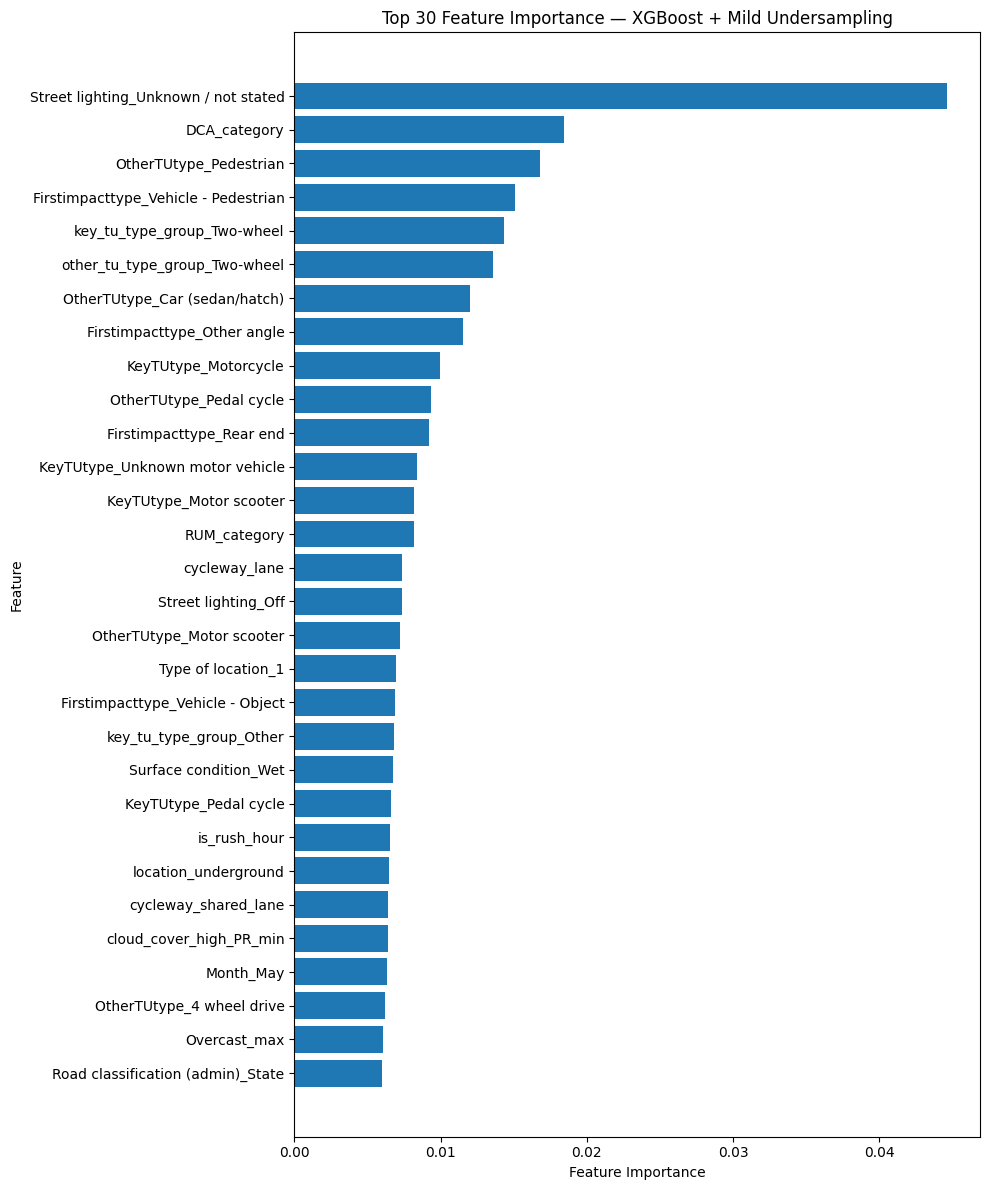

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FEATURE IMPORTANCE — BEST XGBOOST (MILD UNDERSAMPLING)
# ============================================================

# ------------------------------------------------------------
# 1. استخراج Feature Importance
# ------------------------------------------------------------

importance = best_model.feature_importances_

feature_names = X_train_clean.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# مرتب‌سازی
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# رتبه
feature_importance_df.insert(
    0,
    "rank",
    range(1, len(feature_importance_df) + 1)
)

# ------------------------------------------------------------
# 2. نمایش Top 30
# ------------------------------------------------------------

print("=" * 100)
print("FEATURE IMPORTANCE — BEST XGBOOST (MILD UNDERSAMPLING)")
print("=" * 100)

print(
    feature_importance_df.head(30).to_string(index=False)
)

# ------------------------------------------------------------
# 3. خلاصه
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 100)

print(f"Total features        : {len(feature_importance_df)}")
print(
    f"Non-zero importance    : "
    f"{(feature_importance_df['importance'] > 0).sum()}"
)
print(
    f"Zero importance        : "
    f"{(feature_importance_df['importance'] == 0).sum()}"
)

# ------------------------------------------------------------
# 4. ذخیره تمام Feature Importance ها
# ------------------------------------------------------------

feature_importance_df.to_csv(
    "Best_XGBoost_Mild_Undersampling_Feature_Importance.csv",
    index=False
)

print("\nFile saved:")
print("Best_XGBoost_Mild_Undersampling_Feature_Importance.csv")

# ------------------------------------------------------------
# 5. رسم Top 30
# ------------------------------------------------------------

top_n = 30

plot_df = feature_importance_df.head(top_n).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 12))

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 30 Feature Importance — "
    "XGBoost + Mild Undersampling"
)

plt.tight_layout()
plt.show()

SHAP ANALYSIS — BEST XGBOOST (MILD UNDERSAMPLING)
SHAP dataset shape: (1196, 263)

SHAP calculation completed.

SHAP output type: <class 'numpy.ndarray'>
SHAP shape: (1196, 263, 3)

GLOBAL SHAP IMPORTANCE
 rank                              feature  mean_abs_shap
    1 Street lighting_Unknown / not stated       0.562842
    2 Firstimpacttype_Vehicle - Pedestrian       0.170094
    3          key_tu_type_group_Two-wheel       0.136856
    4                             Latitude       0.128219
    5        other_tu_type_group_Two-wheel       0.126258
    6                         DCA_category       0.097281
    7              cloud_cover_low_PR_mean       0.094244
    8         relative_humidity_2m_PR_mean       0.090392
    9             cloud_cover_high_PR_mean       0.089131
   10              wind_speed_100m_kmh_max       0.087849
   11          Firstimpacttype_Other angle       0.086169
   12               wind_speed_10m_kmh_max       0.083930
   13              wind_gusts_10m_kmh_mea

<Figure size 640x480 with 0 Axes>

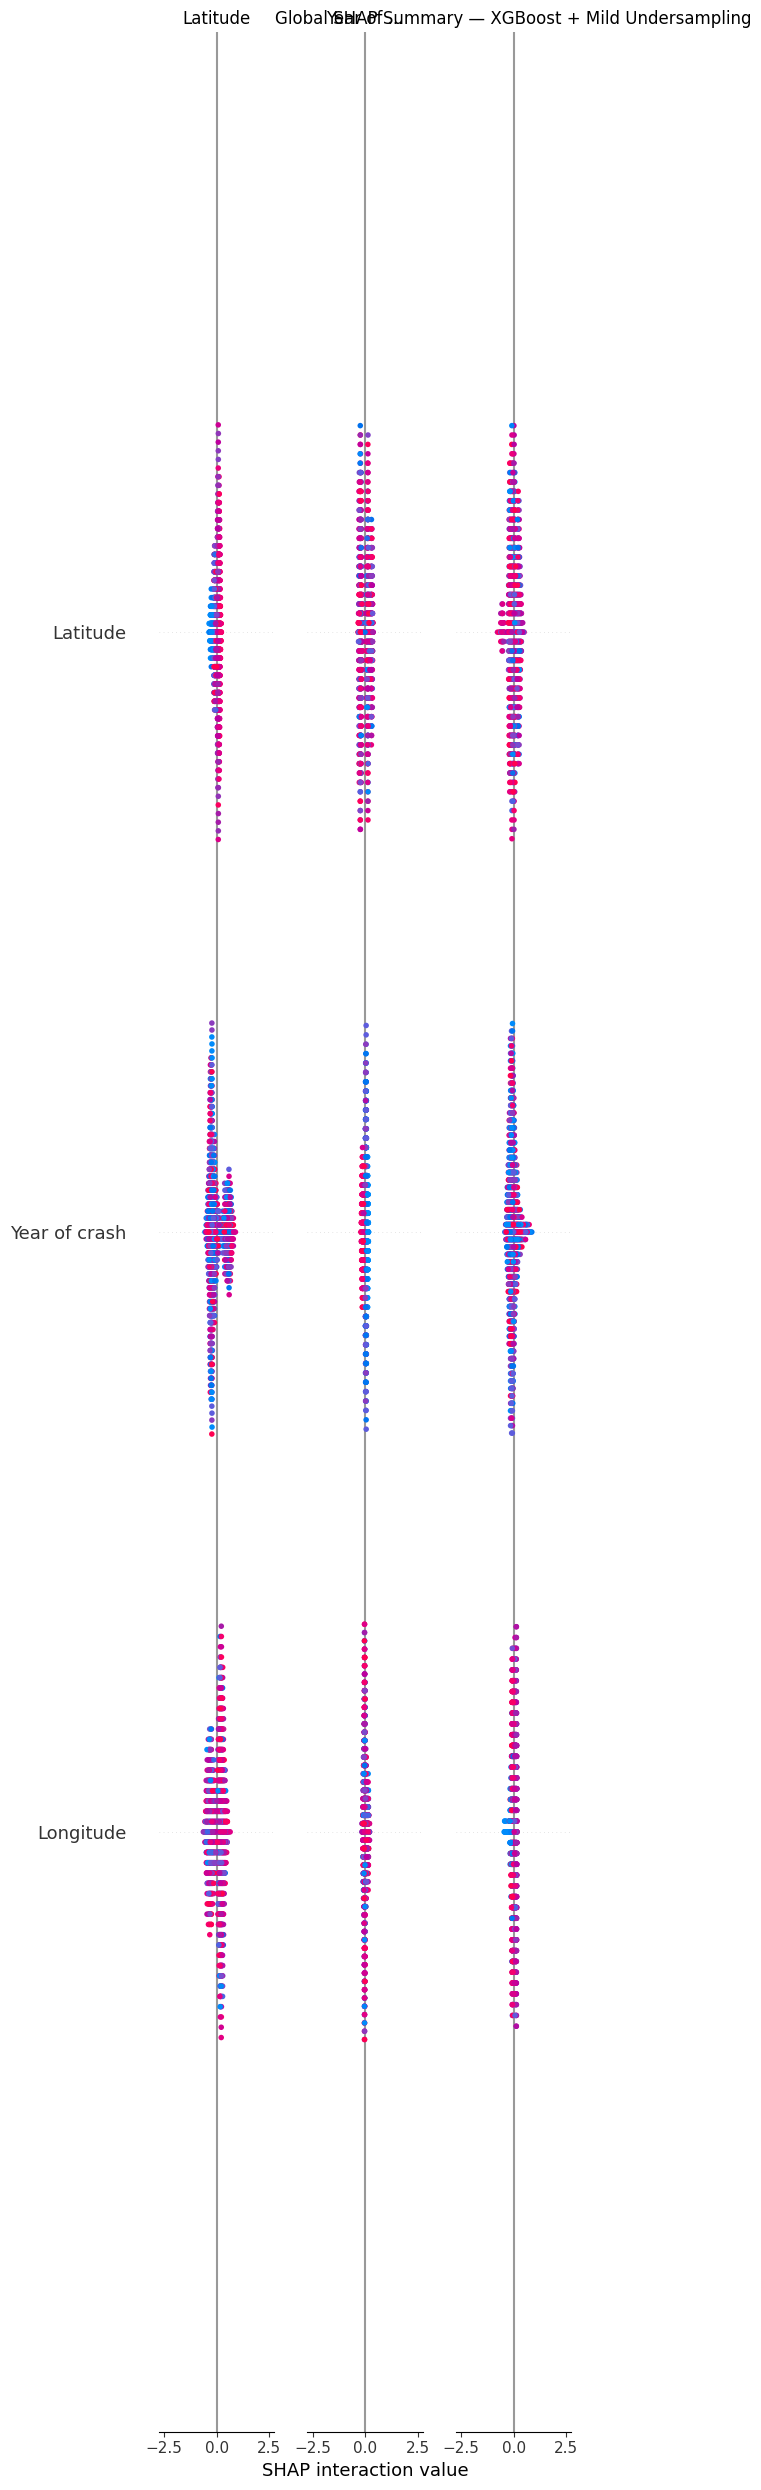

In [116]:
# ============================================================
# SHAP ANALYSIS — BEST XGBOOST + MILD UNDERSAMPLING
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 100)
print("SHAP ANALYSIS — BEST XGBOOST (MILD UNDERSAMPLING)")
print("=" * 100)

# ============================================================
# 1. انتخاب داده برای SHAP
# ============================================================

# برای جلوگیری از سنگین شدن محاسبات، از Test استفاده می‌کنیم.
# اگر خواستی کل Test را استفاده کنی:
X_shap = X_test_clean.copy()

print("SHAP dataset shape:", X_shap.shape)

# ============================================================
# 2. ساخت SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_shap)

print("\nSHAP calculation completed.")

# ============================================================
# 3. بررسی ساختار خروجی SHAP
# ============================================================

print("\nSHAP output type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(f"Class {i} SHAP shape:", sv.shape)

else:
    print("SHAP shape:", shap_values.shape)

# ============================================================
# 4. SHAP SUMMARY — همه کلاس‌ها
# ============================================================

print("\n" + "=" * 100)
print("GLOBAL SHAP IMPORTANCE")
print("=" * 100)

# برای نسخه‌های مختلف SHAP
if isinstance(shap_values, list):

    mean_abs_shap = np.mean(
        np.abs(np.stack(shap_values)),
        axis=(0, 1)
    )

else:

    # اگر شکل خروجی:
    # samples × features × classes

    if shap_values.ndim == 3:

        mean_abs_shap = np.mean(
            np.abs(shap_values),
            axis=(0, 2)
        )

    else:

        mean_abs_shap = np.mean(
            np.abs(shap_values),
            axis=0
        )

global_shap_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap
})

global_shap_df = global_shap_df.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

global_shap_df.insert(
    0,
    "rank",
    range(1, len(global_shap_df) + 1)
)

print(global_shap_df.head(30).to_string(index=False))

# ============================================================
# 5. ذخیره Global SHAP Importance
# ============================================================

global_shap_df.to_csv(
    "Best_XGBoost_Mild_Global_SHAP_Importance.csv",
    index=False
)

print(
    "\nSaved: "
    "Best_XGBoost_Mild_Global_SHAP_Importance.csv"
)

# ============================================================
# 6. SHAP Summary Plot — Global
# ============================================================

plt.figure()

if isinstance(shap_values, list):

    shap.summary_plot(
        shap_values,
        X_shap,
        max_display=30,
        show=False
    )

else:

    # برای خروجی چندکلاسه جدید
    if shap_values.ndim == 3:

        shap.summary_plot(
            shap_values,
            X_shap,
            max_display=30,
            show=False
        )

    else:

        shap.summary_plot(
            shap_values,
            X_shap,
            max_display=30,
            show=False
        )

plt.title(
    "Global SHAP Summary — "
    "XGBoost + Mild Undersampling"
)

plt.tight_layout()
plt.show()


SHAP ANALYSIS — CLASS 2 (SEVERE)
Severe SHAP shape: (1196, 263)
 rank                              feature  mean_abs_shap
    1 Street lighting_Unknown / not stated       1.171403
    2        OtherTUtype_Car (sedan/hatch)       0.161529
    3                             Latitude       0.156417
    4          key_tu_type_group_Two-wheel       0.132266
    5             cloud_cover_high_PR_mean       0.117561
    6              wind_gusts_10m_kmh_mean       0.111800
    7              cloud_cover_low_PR_mean       0.106630
    8         relative_humidity_2m_PR_mean       0.094037
    9                  cloud_cover_PR_mean       0.090755
   10                          amenity_sus       0.085299
   11               OtherTUtype_Pedestrian       0.083187
   12               wind_gusts_10m_kmh_max       0.080771
   13                                 dist       0.079876
   14              wind_speed_10m_kmh_mean       0.078442
   15                temperature_2m_C_mean       0.077306
   16  

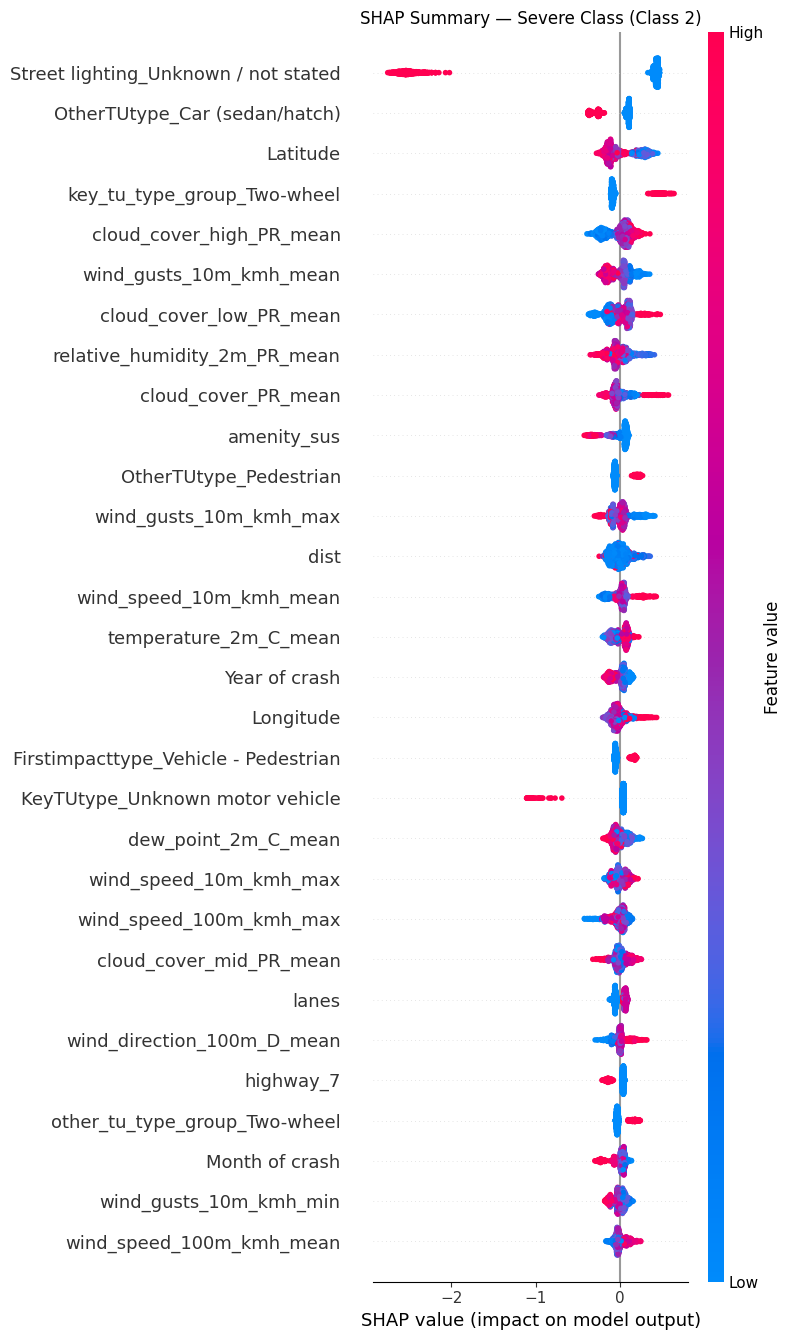

In [117]:
# ============================================================
# 7. SHAP — CLASS 2 (SEVERE)
# ============================================================

print("\n" + "=" * 100)
print("SHAP ANALYSIS — CLASS 2 (SEVERE)")
print("=" * 100)

# ------------------------------------------------------------
# استخراج SHAP مربوط به Class 2
# ------------------------------------------------------------

if isinstance(shap_values, list):

    shap_severe = shap_values[2]

else:

    # خروجی جدید SHAP:
    # samples × features × classes

    if shap_values.ndim == 3:
        shap_severe = shap_values[:, :, 2]
    else:
        raise ValueError(
            "Unexpected SHAP output format."
        )

print("Severe SHAP shape:", shap_severe.shape)

# ============================================================
# 8. Mean Absolute SHAP — Severe
# ============================================================

severe_importance = np.mean(
    np.abs(shap_severe),
    axis=0
)

severe_shap_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": severe_importance
})

severe_shap_df = severe_shap_df.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

severe_shap_df.insert(
    0,
    "rank",
    range(1, len(severe_shap_df) + 1)
)

print(
    severe_shap_df.head(30).to_string(index=False)
)

# ============================================================
# 9. ذخیره Severe SHAP
# ============================================================

severe_shap_df.to_csv(
    "Best_XGBoost_Mild_SHAP_Severe_Class.csv",
    index=False
)

print(
    "\nSaved: "
    "Best_XGBoost_Mild_SHAP_Severe_Class.csv"
)

# ============================================================
# 10. SHAP Summary Plot — Severe
# ============================================================

plt.figure()

shap.summary_plot(
    shap_severe,
    X_shap,
    max_display=30,
    show=False
)

plt.title(
    "SHAP Summary — Severe Class (Class 2)"
)

plt.tight_layout()
plt.show()

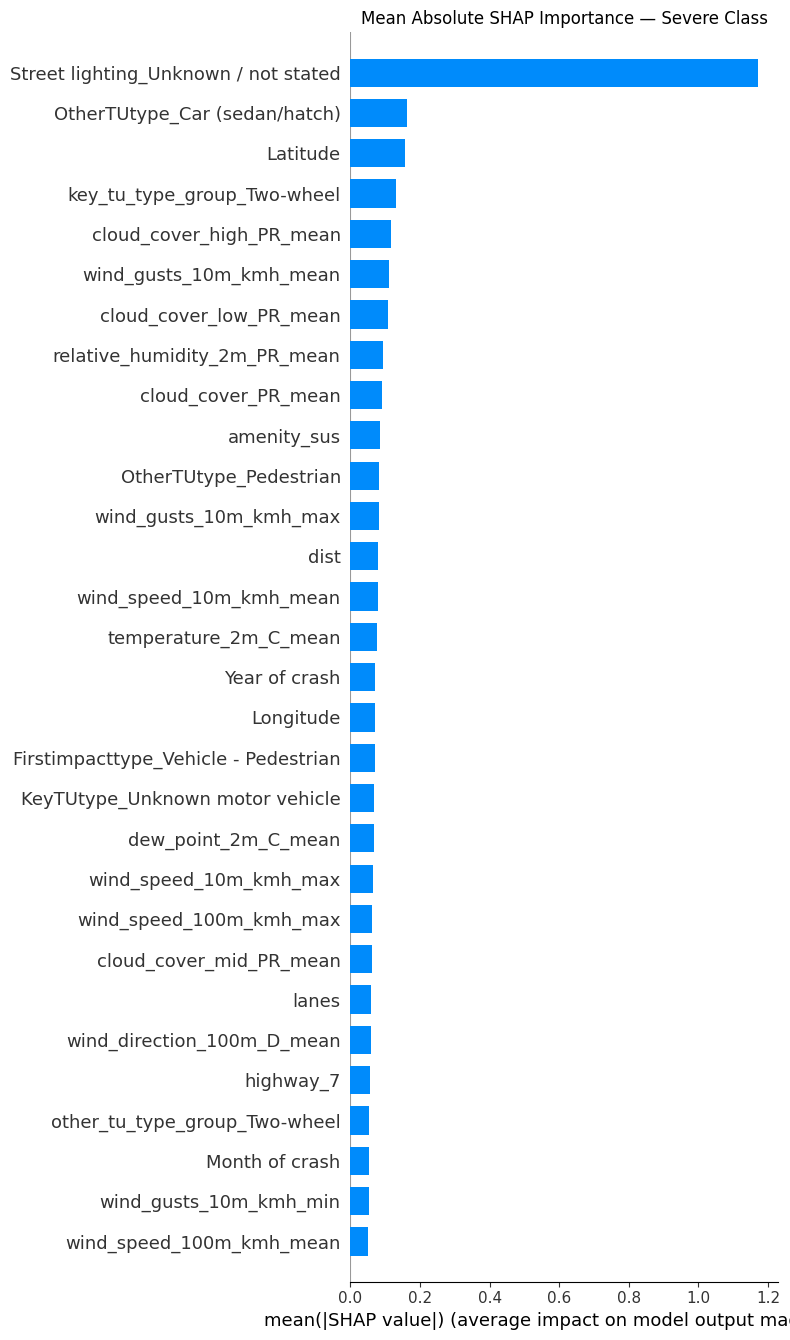

In [118]:
# ============================================================
# 11. SHAP BAR PLOT — SEVERE
# ============================================================

shap.summary_plot(
    shap_severe,
    X_shap,
    plot_type="bar",
    max_display=30,
    show=False
)

plt.title(
    "Mean Absolute SHAP Importance — Severe Class"
)

plt.tight_layout()
plt.show()

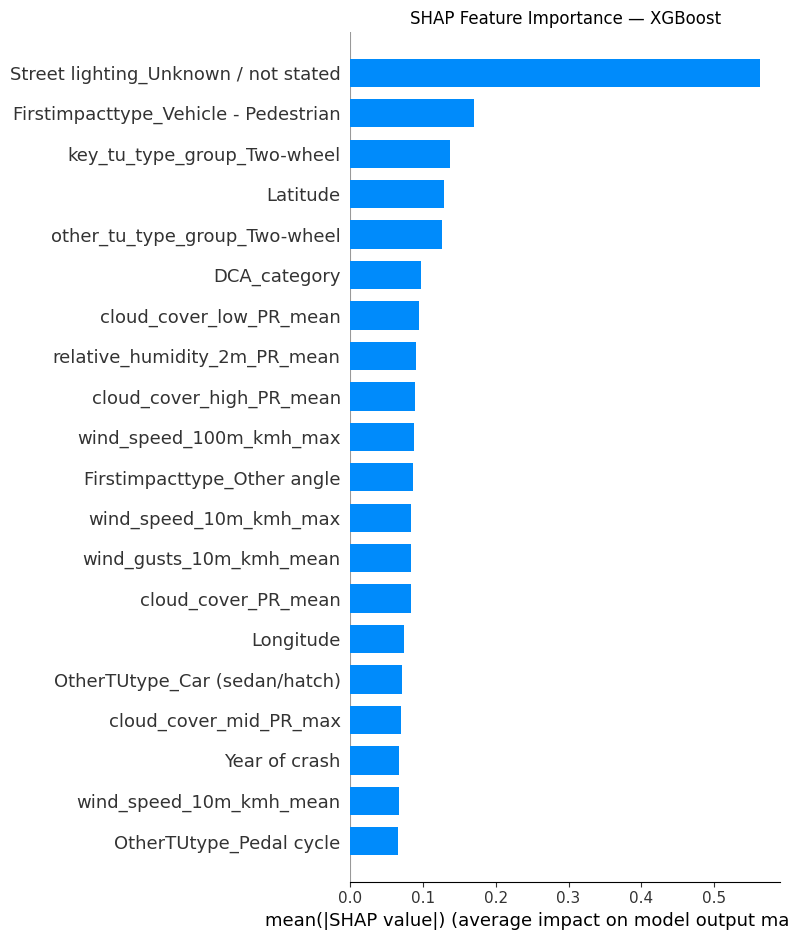

In [119]:
import shap
import matplotlib.pyplot as plt

# ==========================================================
# SHAP VALUES
# ==========================================================

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

# ==========================================================
# MULTICLASS SHAP
# ==========================================================

if isinstance(shap_values, list):
    shap_values_mean = sum(
        abs(shap_values[i]) for i in range(len(shap_values))
    ) / len(shap_values)
else:
    # shape: samples × features × classes
    shap_values_mean = abs(shap_values).mean(axis=2)

# ==========================================================
# SUMMARY BAR
# ==========================================================

shap.summary_plot(
    shap_values_mean,
    X_test_clean,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

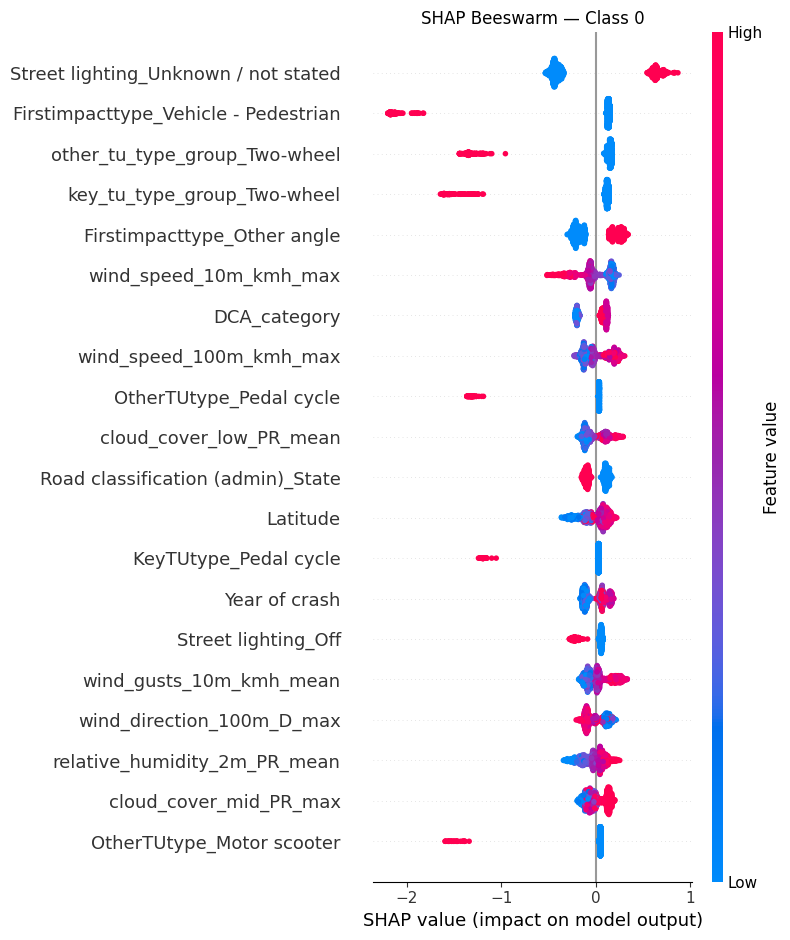

In [120]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

# کلاس 0
if isinstance(shap_values, list):
    values = shap_values[0]
else:
    values = shap_values[:, :, 0]

shap.summary_plot(
    values,
    X_test_clean,
    max_display=20,
    show=False
)

plt.title("SHAP Beeswarm — Class 0")
plt.tight_layout()
plt.show()

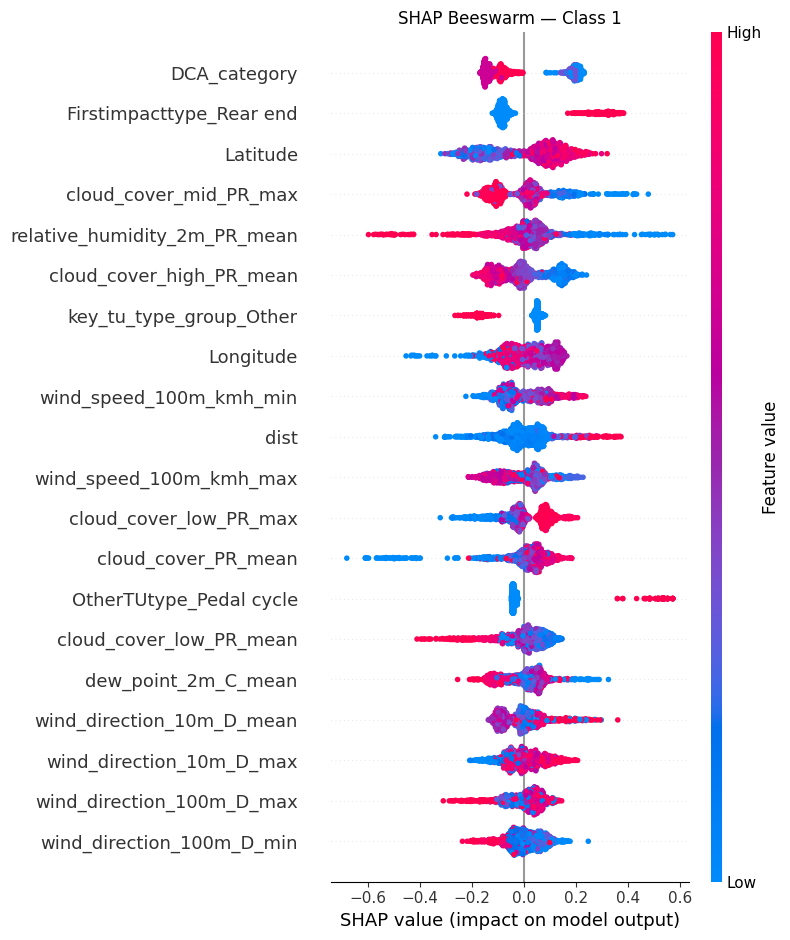

In [121]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

if isinstance(shap_values, list):
    values = shap_values[1]
else:
    values = shap_values[:, :, 1]

shap.summary_plot(
    values,
    X_test_clean,
    max_display=20,
    show=False
)

plt.title("SHAP Beeswarm — Class 1")
plt.tight_layout()
plt.show()

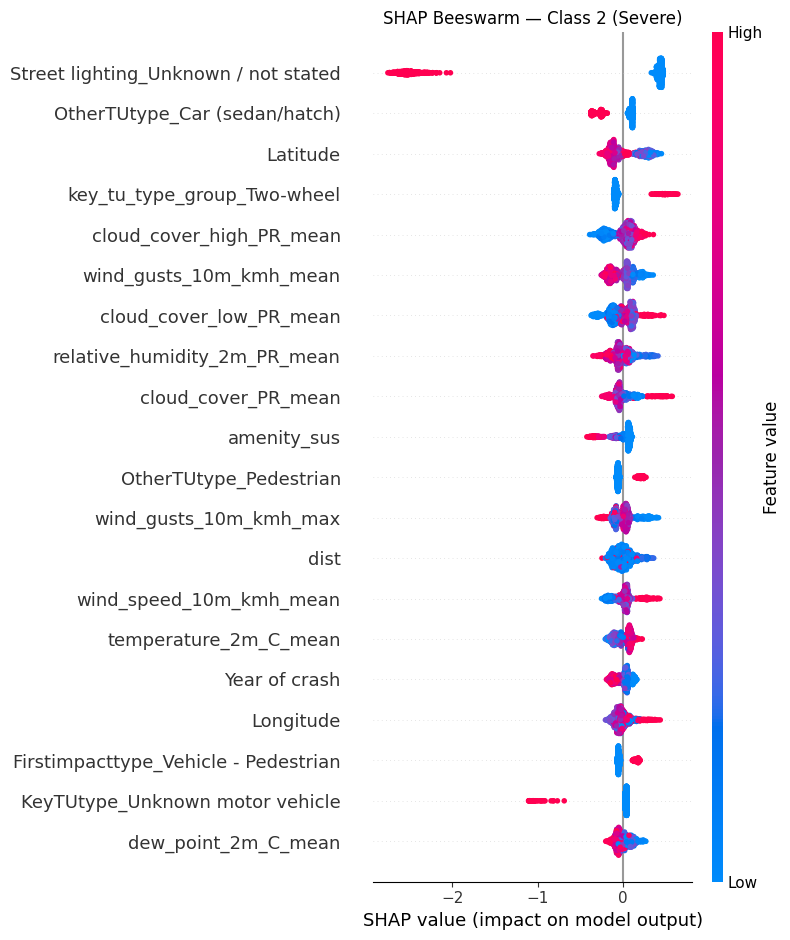

In [122]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

if isinstance(shap_values, list):
    values = shap_values[2]
else:
    values = shap_values[:, :, 2]

shap.summary_plot(
    values,
    X_test_clean,
    max_display=20,
    show=False
)

plt.title("SHAP Beeswarm — Class 2 (Severe)")
plt.tight_layout()
plt.show()

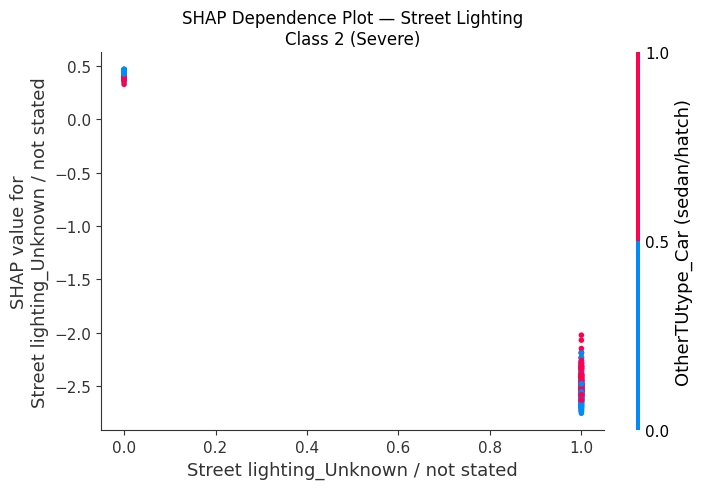

In [123]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

if isinstance(shap_values, list):
    values = shap_values[2]   # Class 2 Severe
else:
    values = shap_values[:, :, 2]

feature_name = "Street lighting_Unknown / not stated"

shap.dependence_plot(
    feature_name,
    values,
    X_test_clean,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependence Plot — Street Lighting\nClass 2 (Severe)"
)

plt.tight_layout()
plt.show()

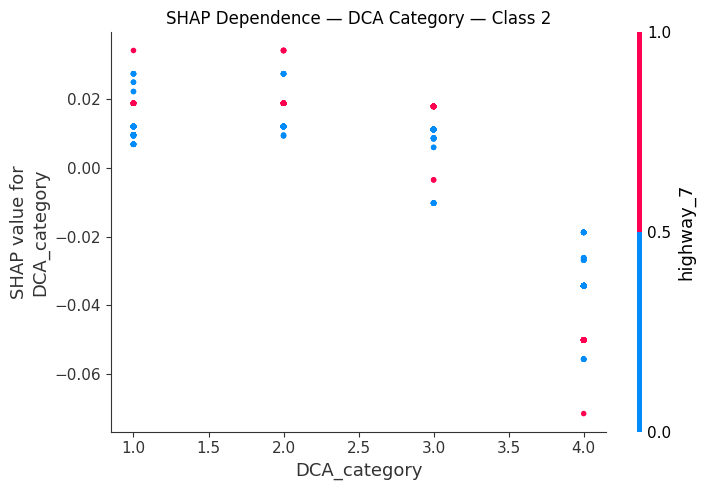

In [124]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

if isinstance(shap_values, list):
    values = shap_values[2]
else:
    values = shap_values[:, :, 2]

shap.dependence_plot(
    "DCA_category",
    values,
    X_test_clean,
    interaction_index="auto",
    show=False
)

plt.title("SHAP Dependence — DCA Category — Class 2")

plt.tight_layout()
plt.show()

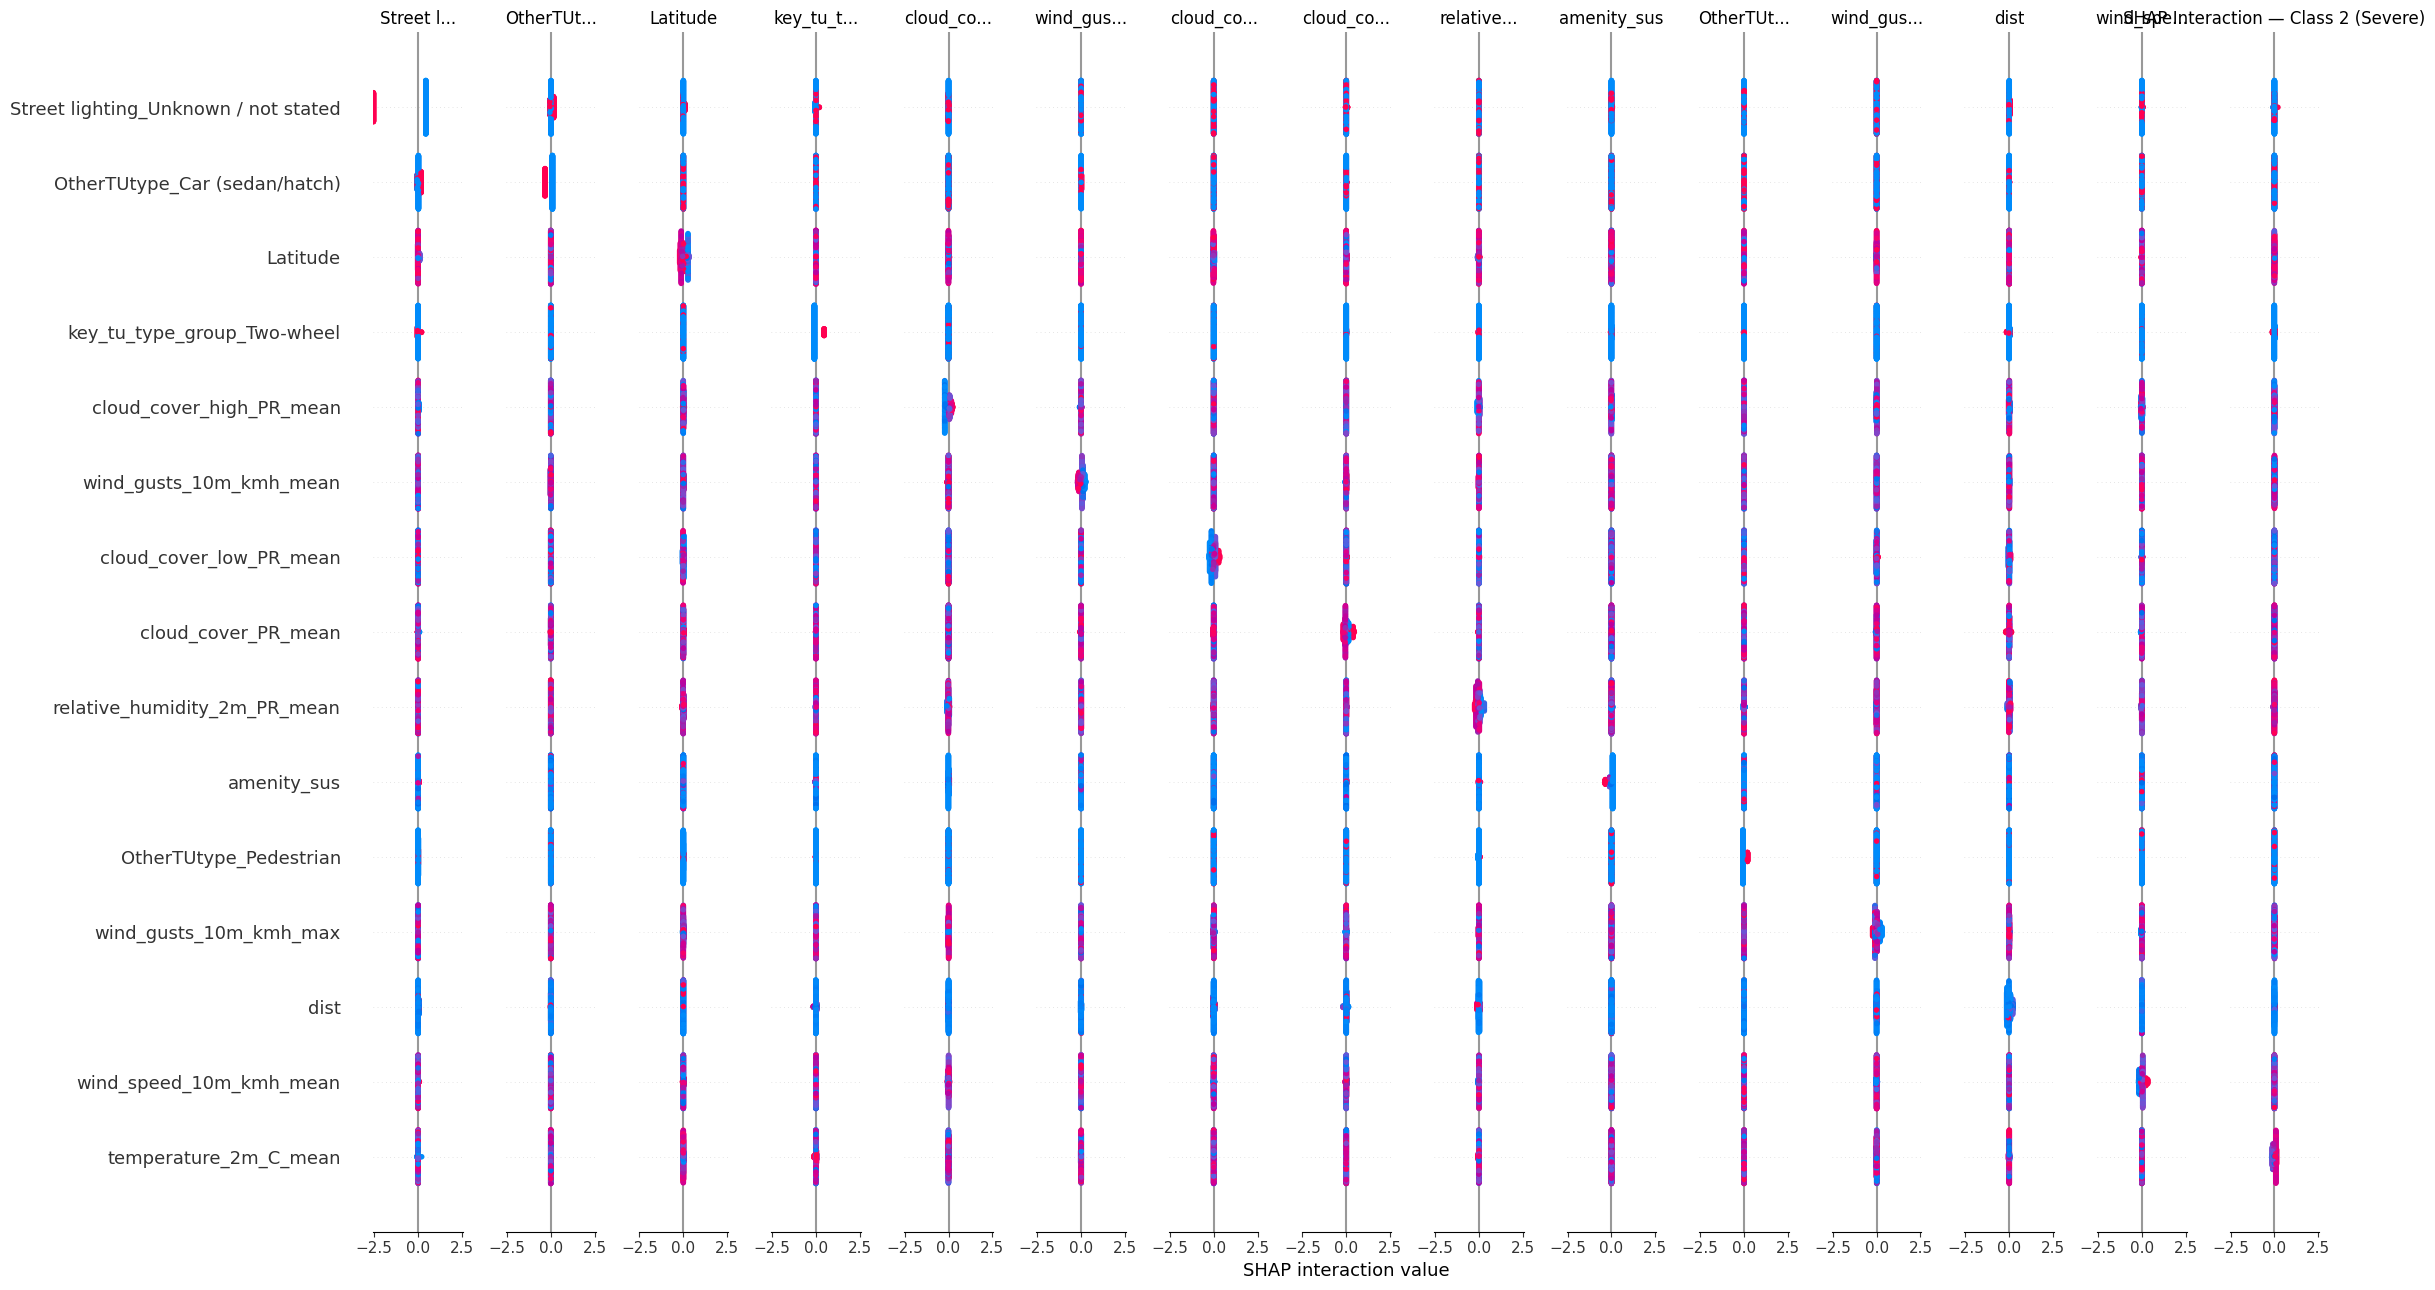

In [125]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)

# برای جلوگیری از مصرف حافظه زیاد
X_sample = X_test_clean.sample(
    min(500, len(X_test_clean)),
    random_state=42
)

interaction_values = explainer.shap_interaction_values(X_sample)

# Class 2
if isinstance(interaction_values, list):
    interaction_class2 = interaction_values[2]
else:
    interaction_class2 = interaction_values[:, :, :, 2]

shap.summary_plot(
    interaction_class2,
    X_sample,
    max_display=15,
    show=False
)

plt.title("SHAP Interaction — Class 2 (Severe)")
plt.tight_layout()
plt.show()

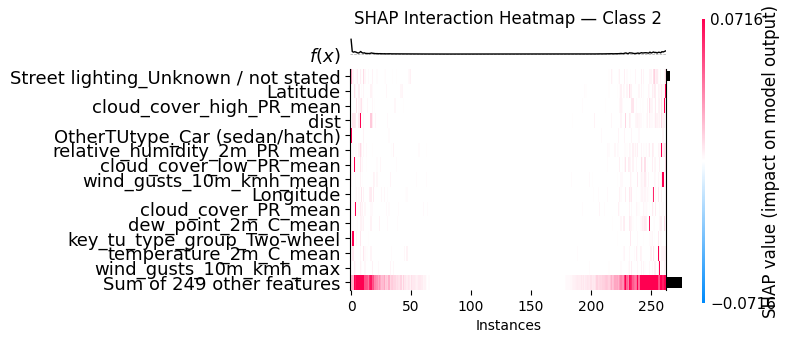

In [126]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)

X_sample = X_test_clean.sample(
    min(500, len(X_test_clean)),
    random_state=42
)

interaction_values = explainer.shap_interaction_values(X_sample)

if isinstance(interaction_values, list):
    interaction_class2 = interaction_values[2]
else:
    interaction_class2 = interaction_values[:, :, :, 2]

# میانگین قدرمطلق تعاملات
interaction_mean = abs(interaction_class2).mean(axis=0)

# ساخت Explanation برای heatmap
interaction_exp = shap.Explanation(
    values=interaction_mean,
    feature_names=X_sample.columns
)

shap.plots.heatmap(
    interaction_exp,
    max_display=15,
    show=False
)

plt.title("SHAP Interaction Heatmap — Class 2")
plt.tight_layout()
plt.show()

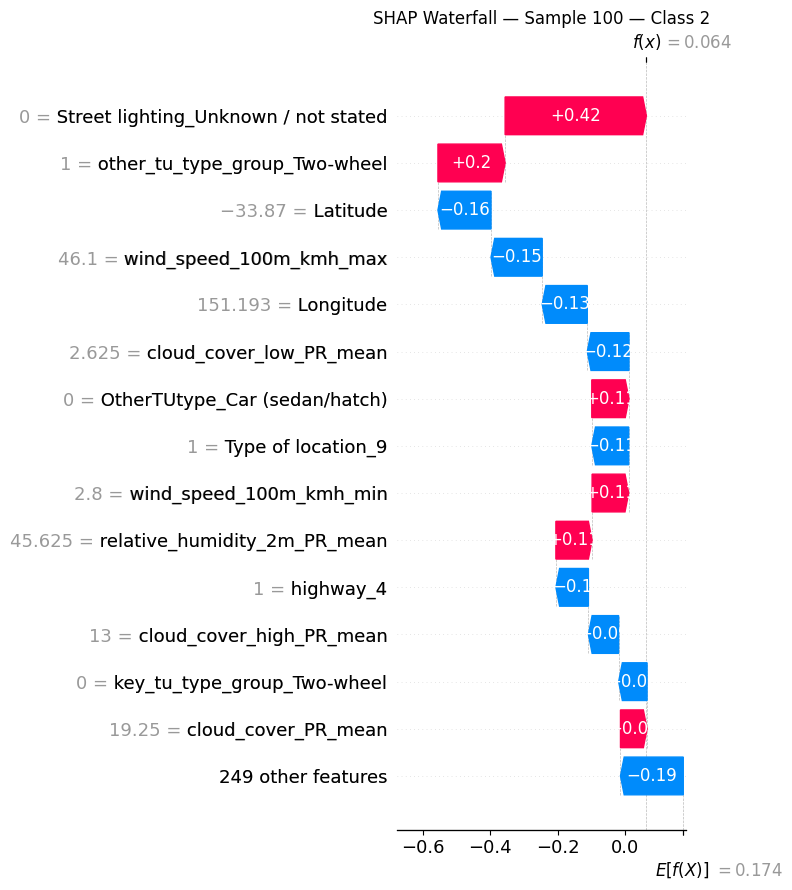

In [127]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)

X_sample = X_test_clean.iloc[[100]]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    values = shap_values[2][0]
    base_value = explainer.expected_value[2]
else:
    values = shap_values[0, :, 2]
    base_value = explainer.expected_value[2]

explanation = shap.Explanation(
    values=values,
    base_values=base_value,
    data=X_sample.iloc[0].values,
    feature_names=X_sample.columns
)

shap.plots.waterfall(
    explanation,
    max_display=15,
    show=False
)

plt.title("SHAP Waterfall — Sample 100 — Class 2")
plt.tight_layout()
plt.show()

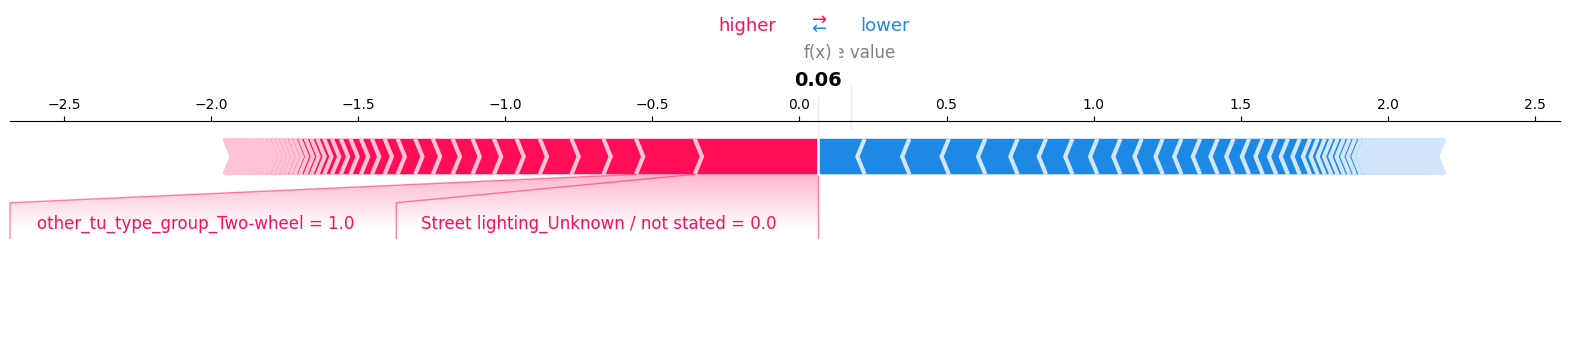

In [128]:
import shap

explainer = shap.TreeExplainer(best_model)

X_sample = X_test_clean.iloc[[100]]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap.initjs()

    shap.force_plot(
        explainer.expected_value[2],
        shap_values[2][0],
        X_sample.iloc[0],
        matplotlib=True
    )

else:
    shap.initjs()

    shap.force_plot(
        explainer.expected_value[2],
        shap_values[0, :, 2],
        X_sample.iloc[0],
        matplotlib=True
    )

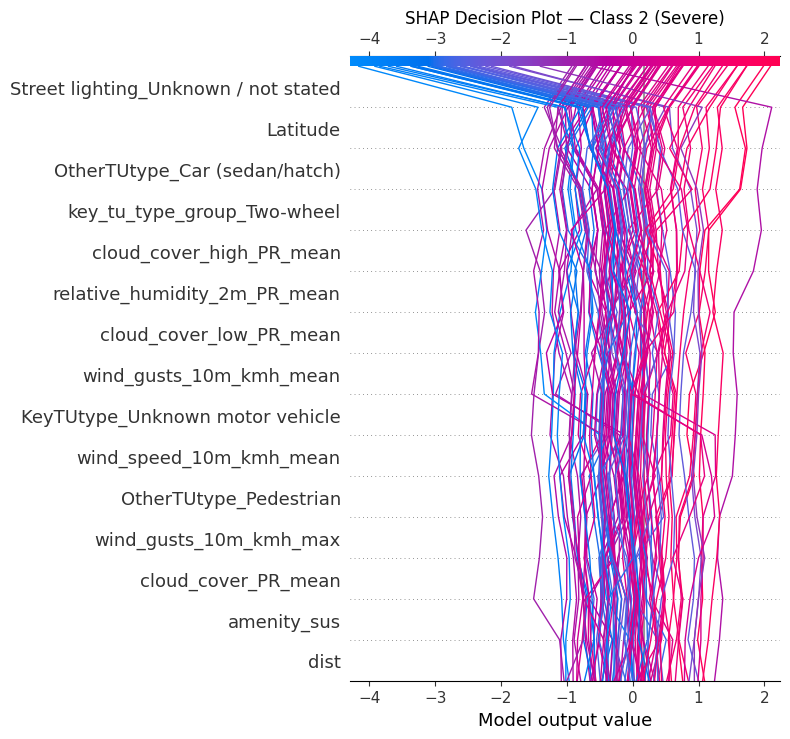

In [129]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)

X_sample = X_test_clean.iloc[:100]

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    values = shap_values[2]
    base_value = explainer.expected_value[2]
else:
    values = shap_values[:, :, 2]
    base_value = explainer.expected_value[2]

shap.decision_plot(
    base_value,
    values,
    X_sample,
    feature_display_range=slice(None, -16, -1),
    show=False
)

plt.title("SHAP Decision Plot — Class 2 (Severe)")
plt.tight_layout()
plt.show()

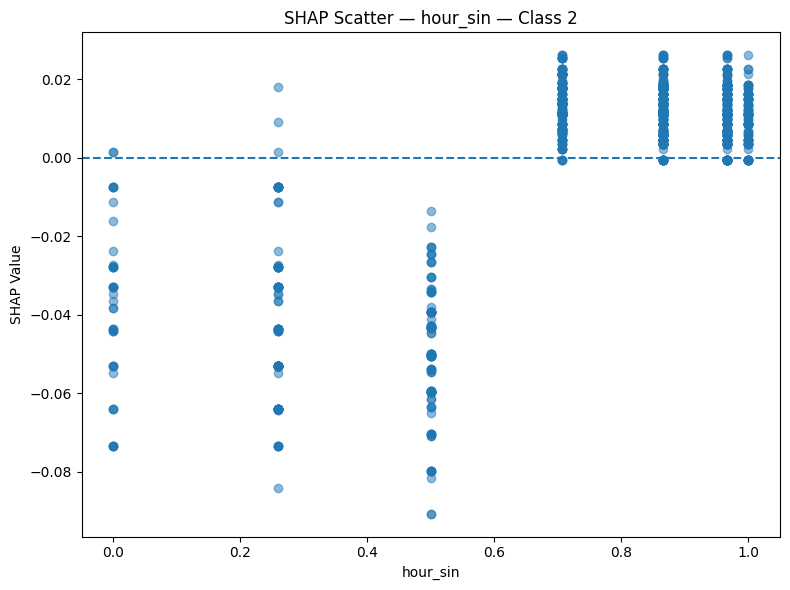

In [130]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_clean)

if isinstance(shap_values, list):
    values = shap_values[2]
else:
    values = shap_values[:, :, 2]

feature_name = "hour_sin"

feature_idx = X_test_clean.columns.get_loc(feature_name)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_clean[feature_name],
    values[:, feature_idx],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(feature_name)
plt.ylabel("SHAP Value")
plt.title(
    f"SHAP Scatter — {feature_name} — Class 2"
)

plt.tight_layout()
plt.show()

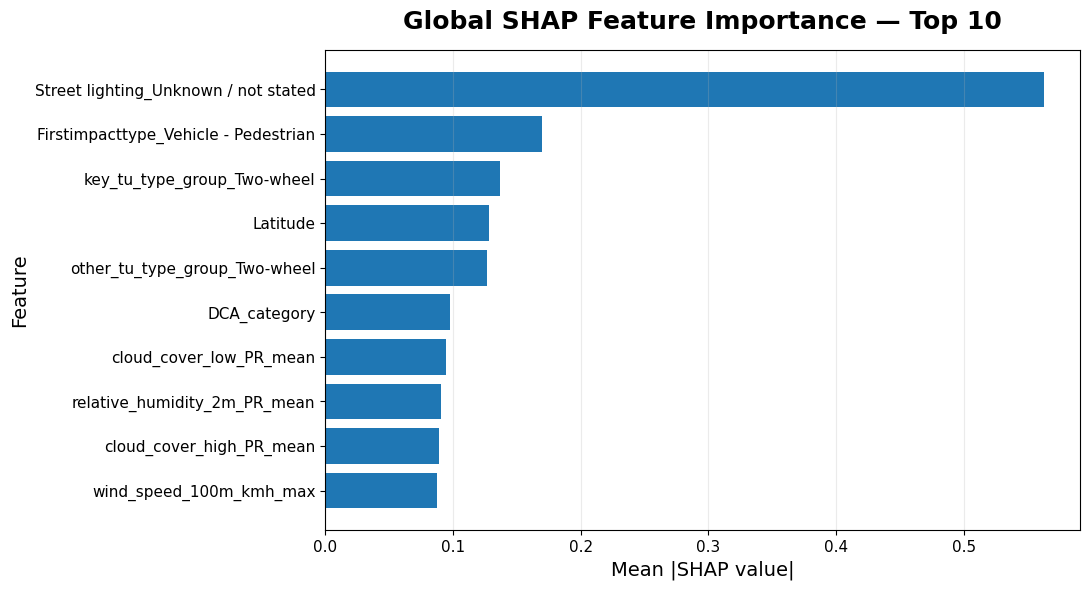

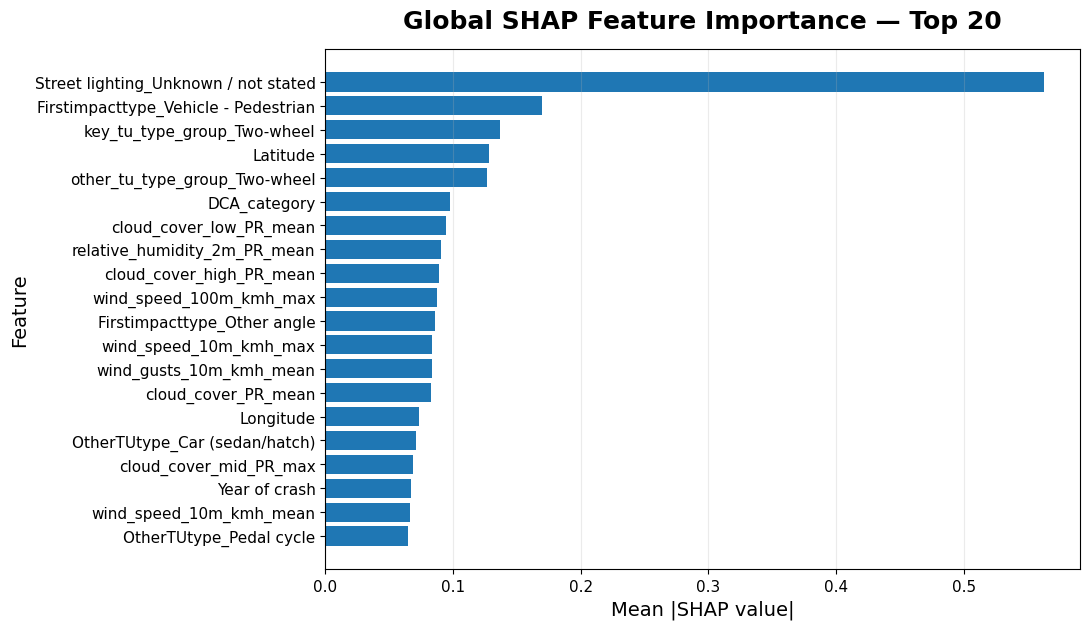

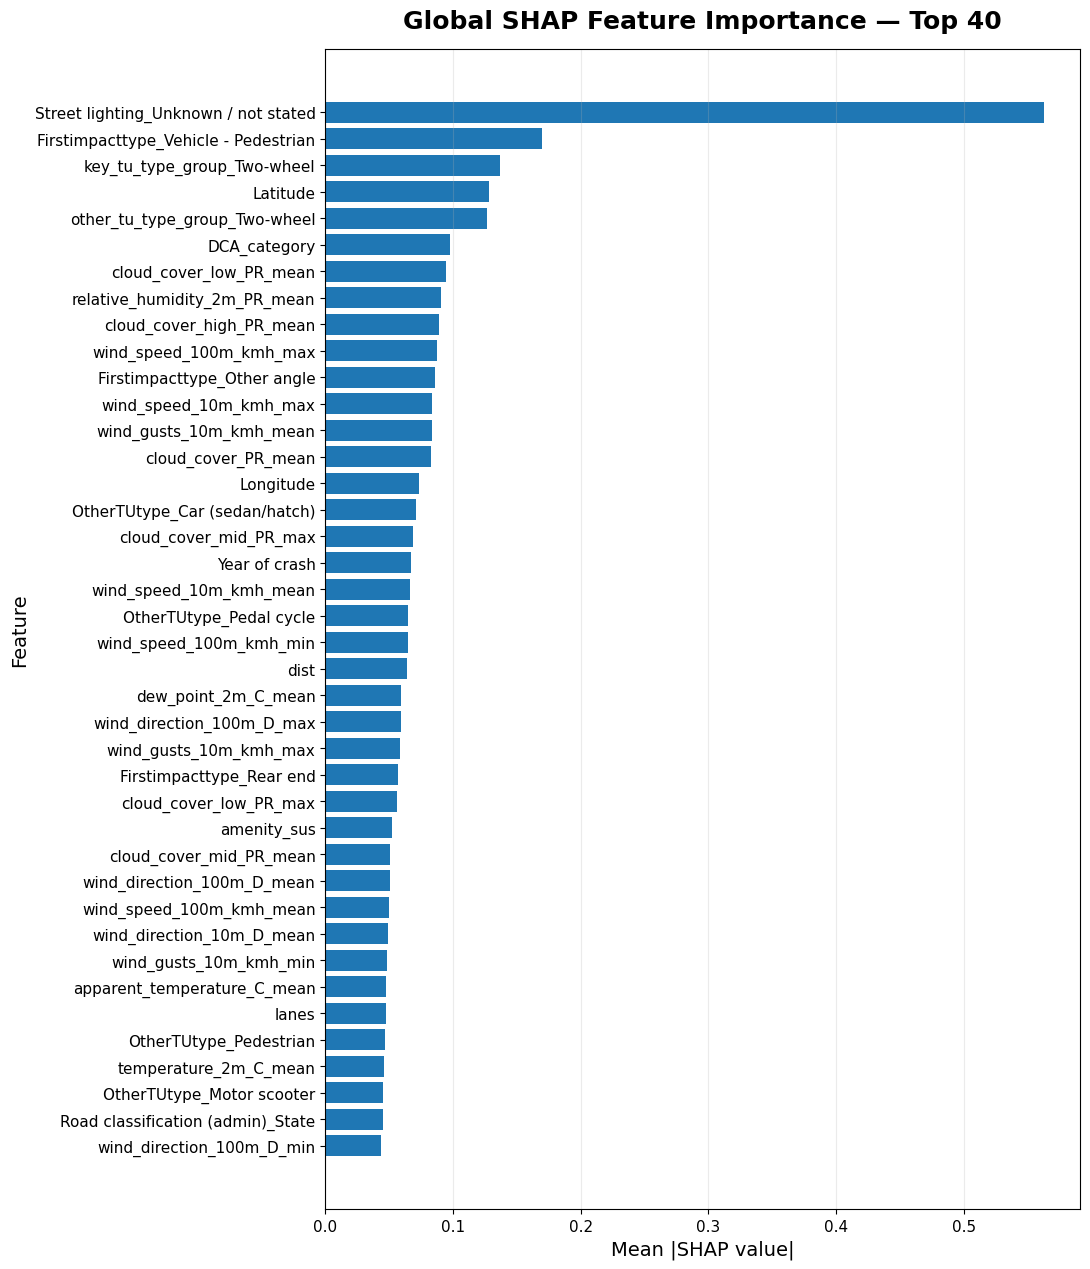

In [131]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# SHAP VALUES
# ============================================================

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

# ============================================================
# تبدیل به فرمت مناسب
# ============================================================

# برای مدل چندکلاسه:
# shape = (samples, features, classes)

if len(shap_values.values.shape) == 3:
    mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

feature_names = X_test_clean.columns

importance_df = (
    __import__("pandas").DataFrame({
        "Feature": feature_names,
        "Mean_Abs_SHAP": mean_abs_shap
    })
    .sort_values("Mean_Abs_SHAP", ascending=False)
)

# ============================================================
# سه خروجی
# ============================================================

for top_n in [10, 20, 40]:

    df_plot = importance_df.head(top_n).sort_values(
        "Mean_Abs_SHAP", ascending=True
    )

    plt.figure(figsize=(11, max(6, top_n * 0.32)))

    plt.barh(
        df_plot["Feature"],
        df_plot["Mean_Abs_SHAP"]
    )

    plt.xlabel("Mean |SHAP value|", fontsize=14)
    plt.ylabel("Feature", fontsize=14)
    plt.title(
        f"Global SHAP Feature Importance — Top {top_n}",
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/01_Global_SHAP_Top_{top_n}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

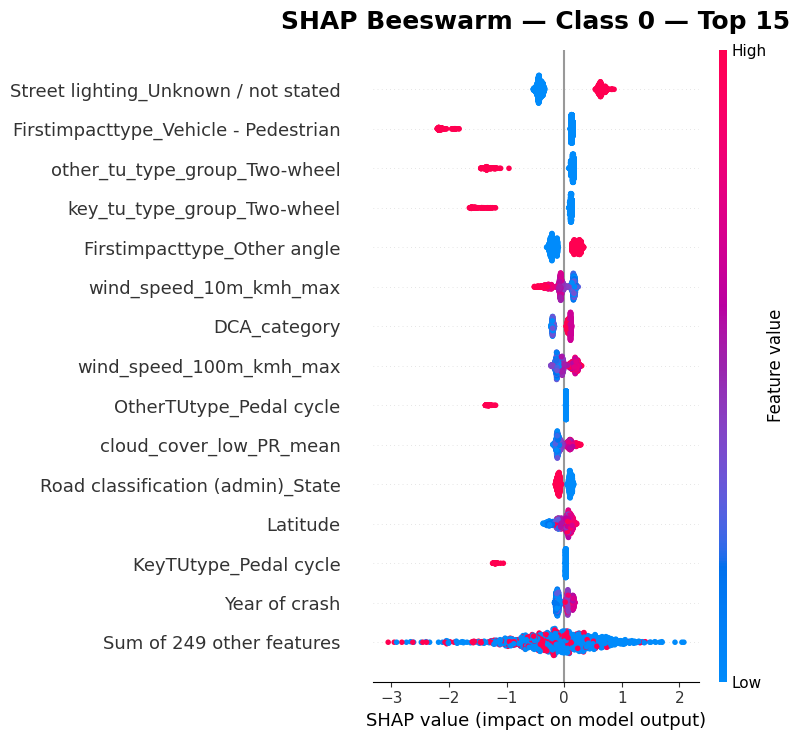

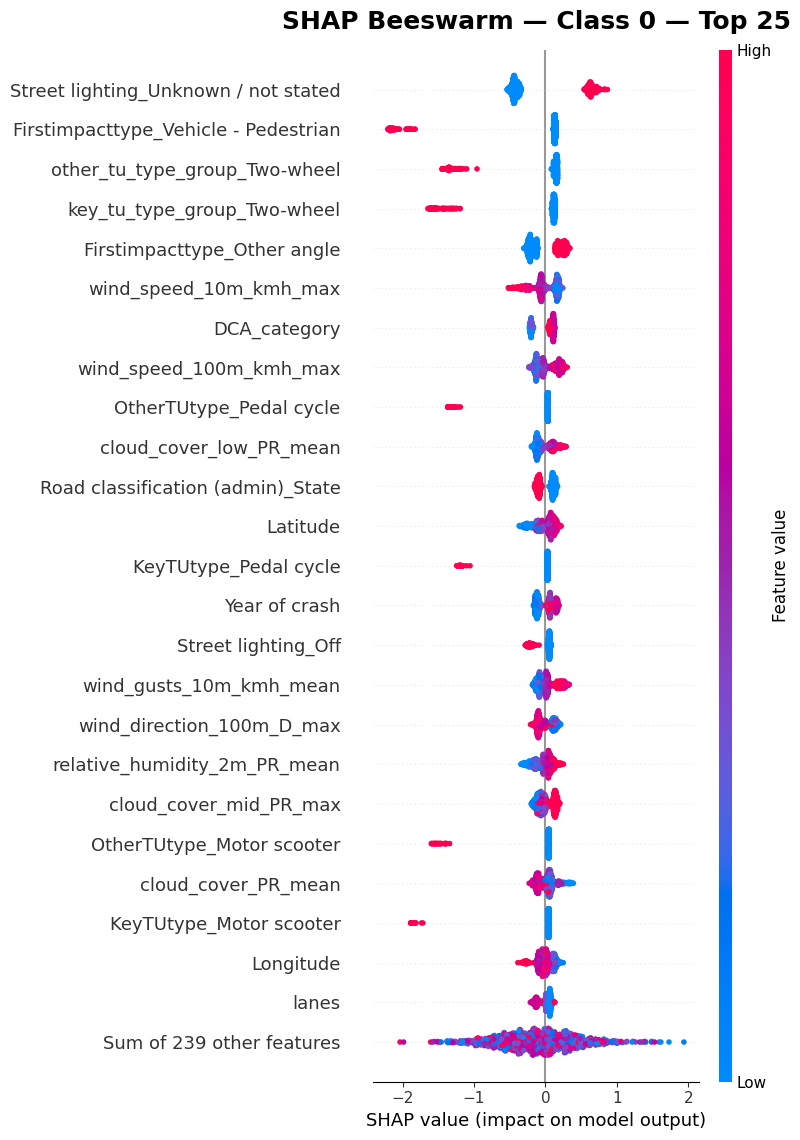

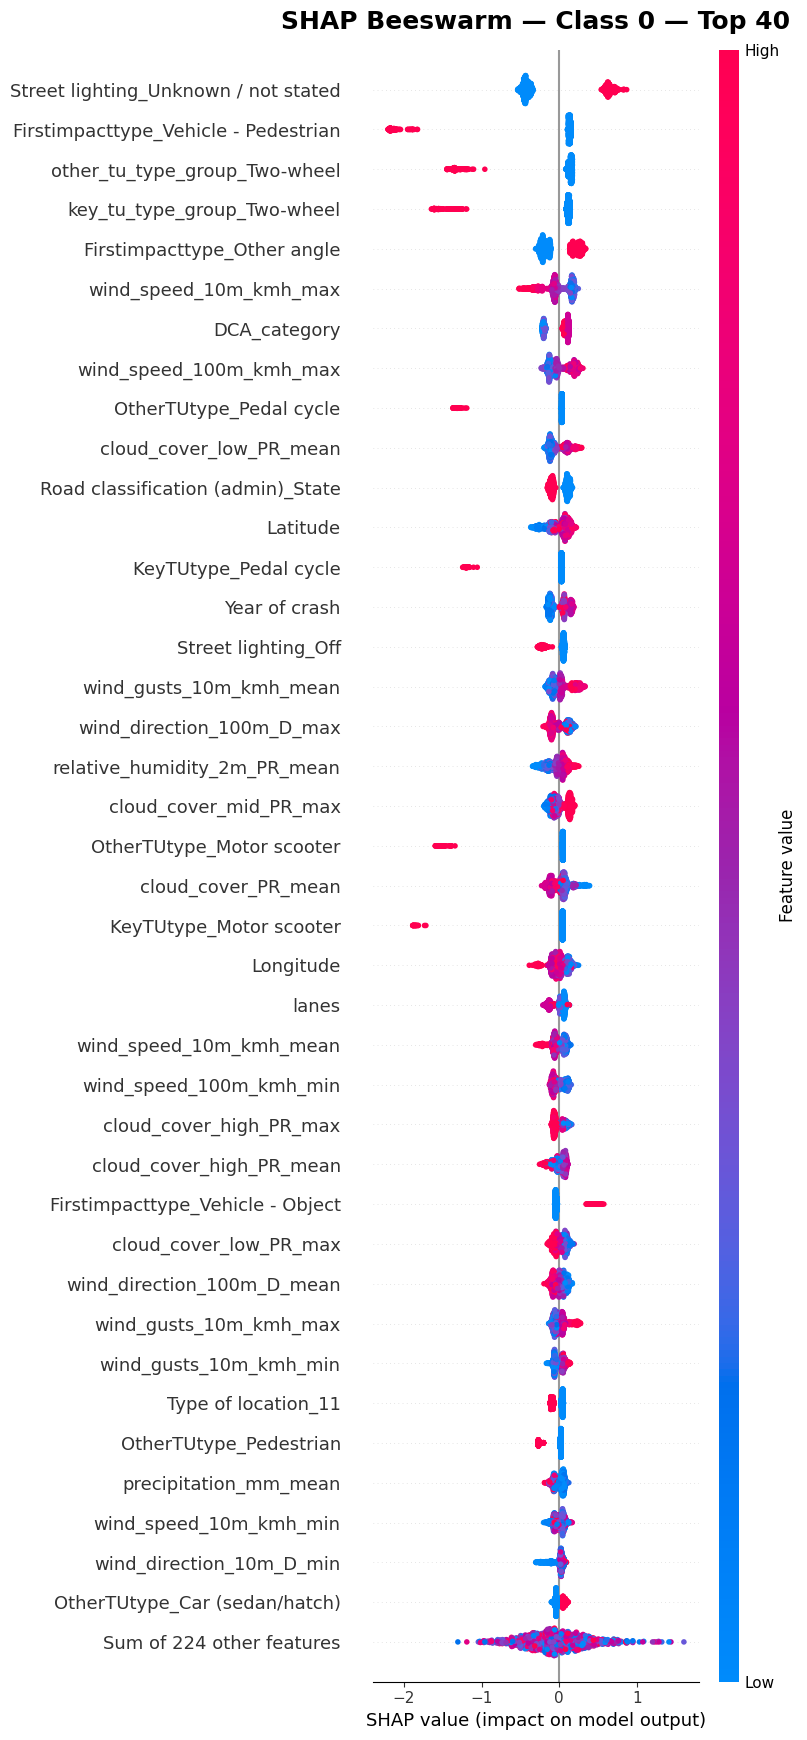

In [132]:
import shap
import matplotlib.pyplot as plt
import os

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

class_id = 0

for top_n in [15, 25, 40]:

    plt.figure(figsize=(12, max(7, top_n * 0.30)))

    shap.plots.beeswarm(
        shap_values[:, :, class_id],
        max_display=top_n,
        show=False
    )

    plt.title(
        f"SHAP Beeswarm — Class {class_id} — Top {top_n}",
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/02_Beeswarm_Class0_Top_{top_n}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

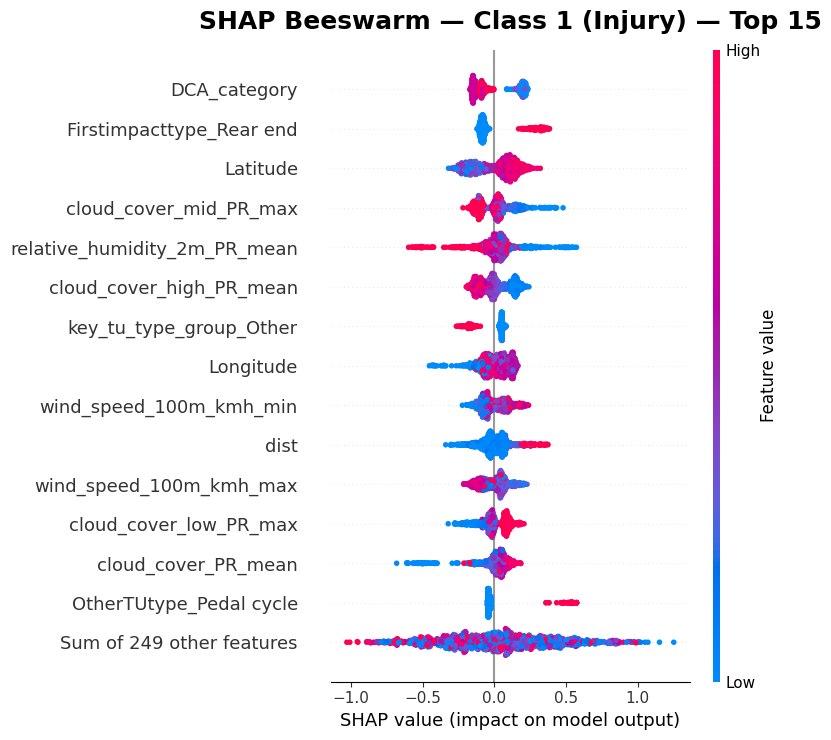

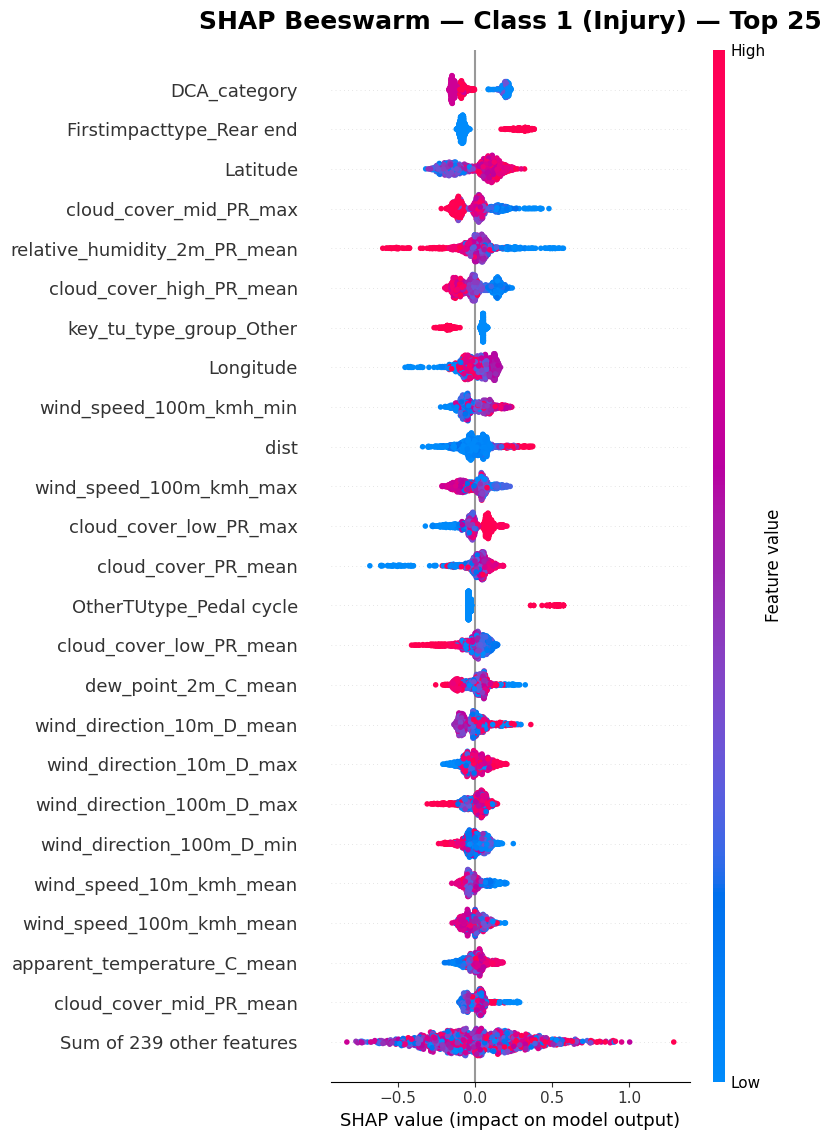

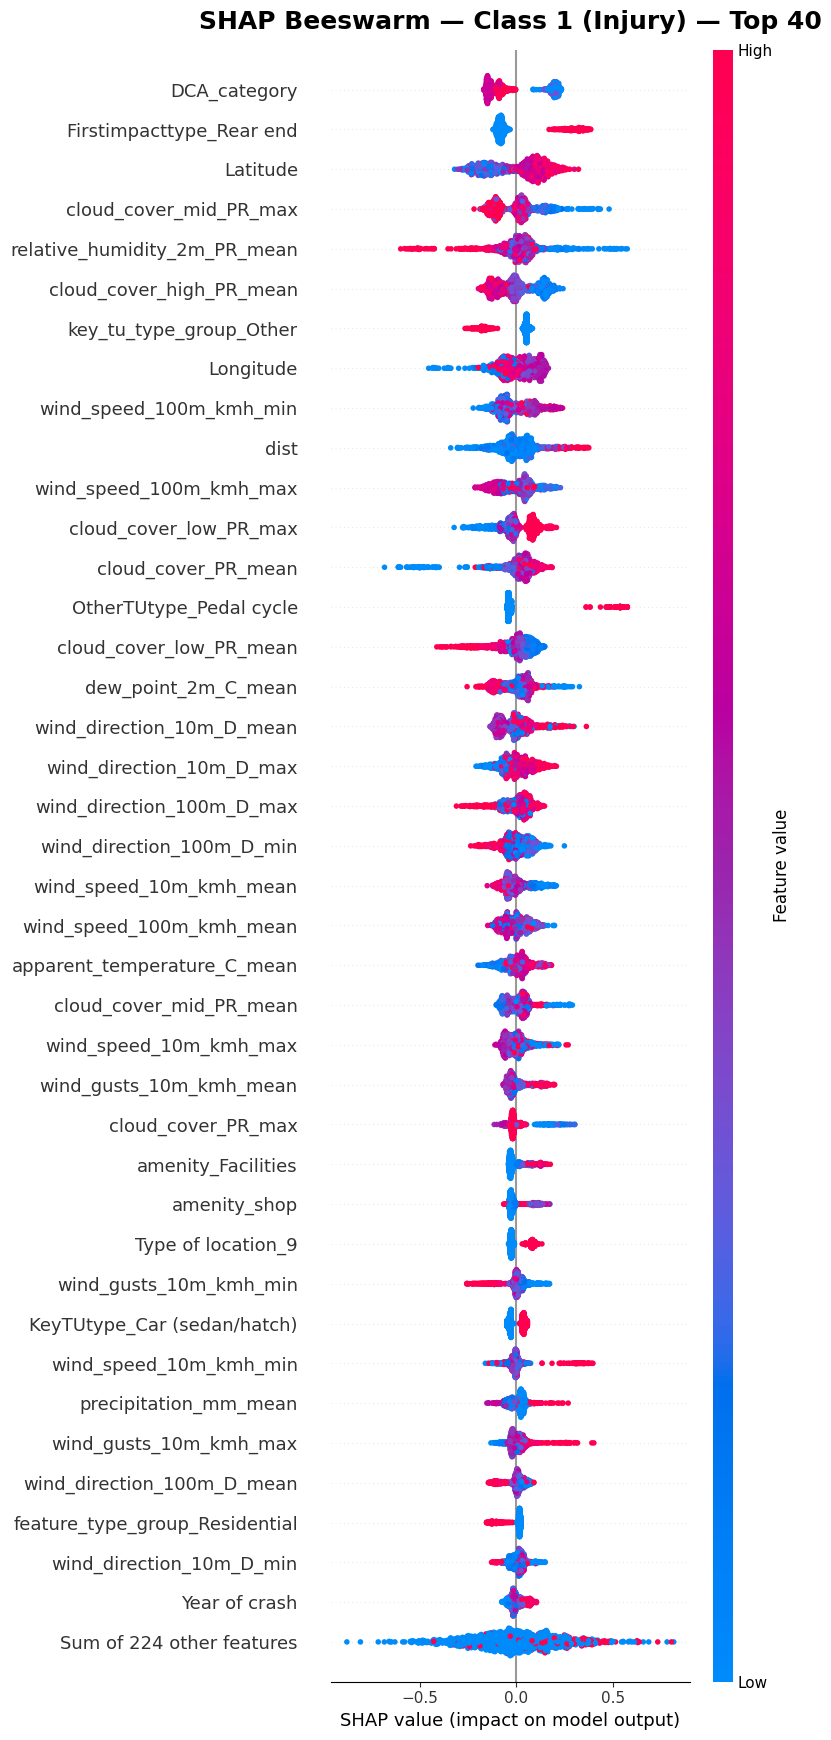

In [133]:
import shap
import matplotlib.pyplot as plt
import os

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

class_id = 1

for top_n in [15, 25, 40]:

    plt.figure(figsize=(12, max(7, top_n * 0.30)))

    shap.plots.beeswarm(
        shap_values[:, :, class_id],
        max_display=top_n,
        show=False
    )

    plt.title(
        f"SHAP Beeswarm — Class {class_id} (Injury) — Top {top_n}",
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/03_Beeswarm_Class1_Injury_Top_{top_n}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

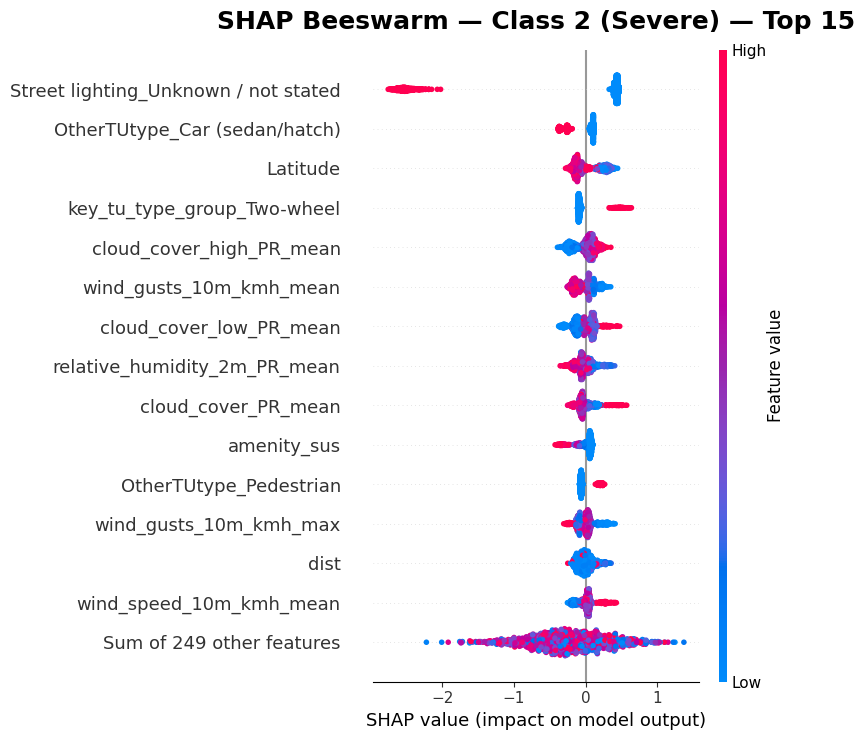

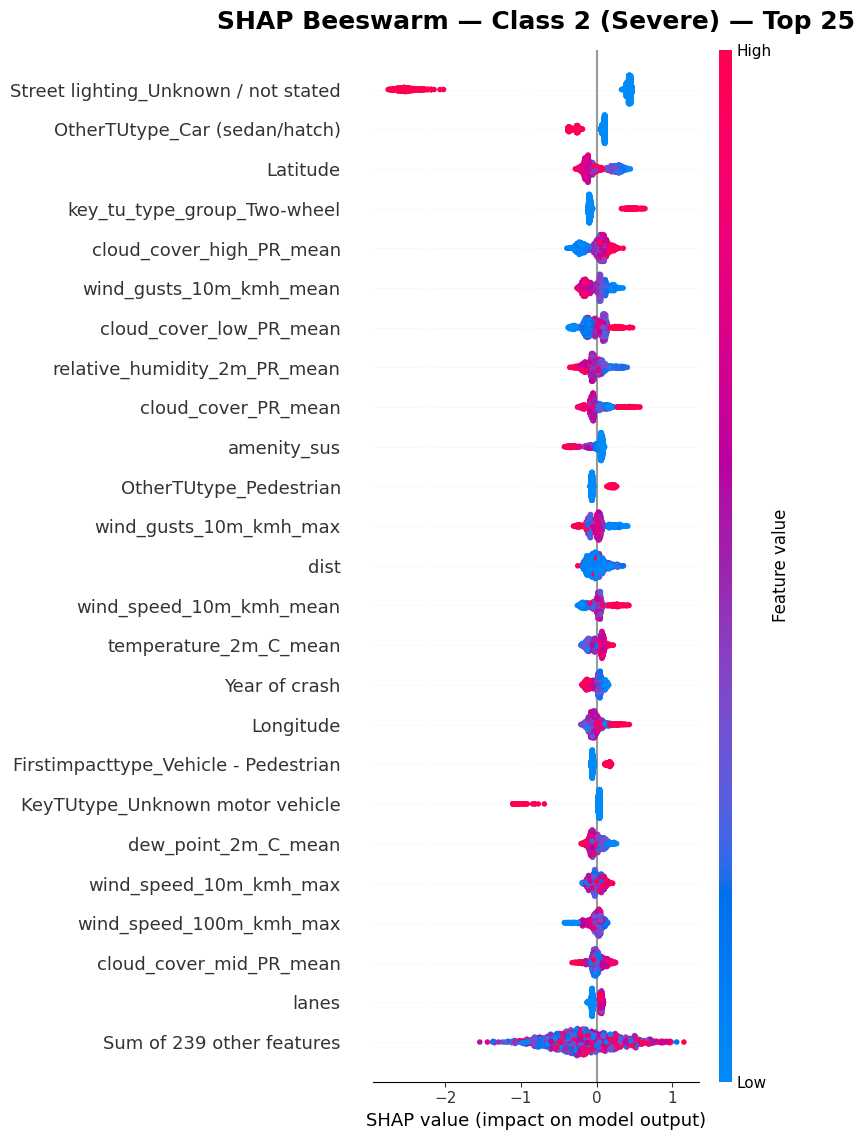

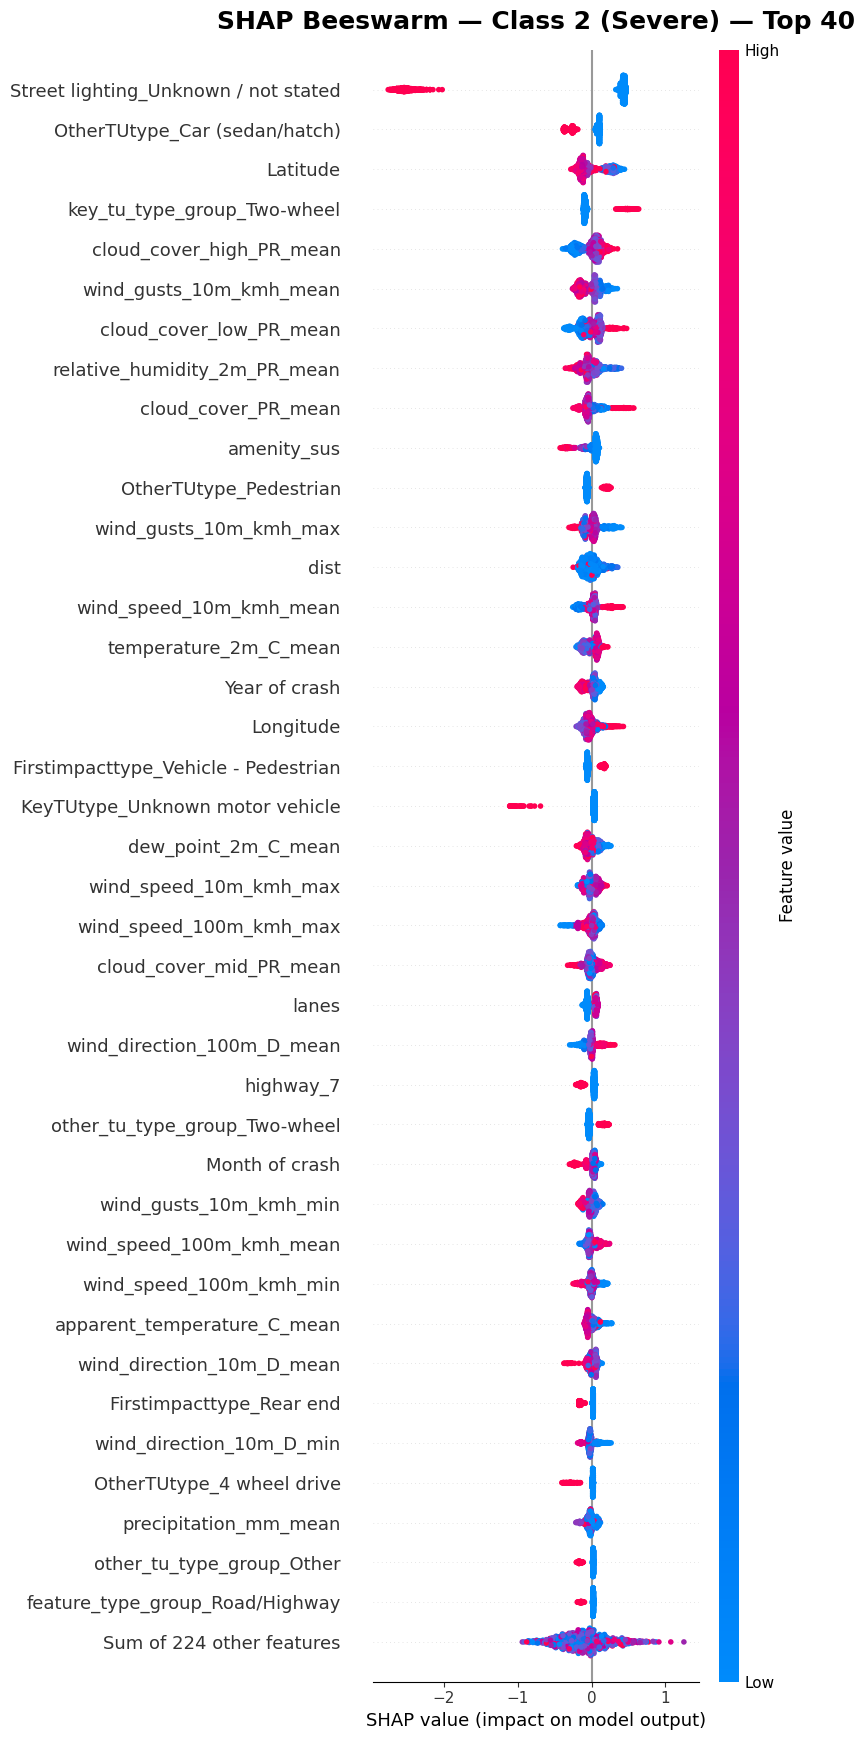

In [134]:
import shap
import matplotlib.pyplot as plt
import os

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

class_id = 2

for top_n in [15, 25, 40]:

    plt.figure(figsize=(12, max(7, top_n * 0.30)))

    shap.plots.beeswarm(
        shap_values[:, :, class_id],
        max_display=top_n,
        show=False
    )

    plt.title(
        f"SHAP Beeswarm — Class 2 (Severe) — Top {top_n}",
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/04_Beeswarm_Class2_Severe_Top_{top_n}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

<Figure size 1100x700 with 0 Axes>

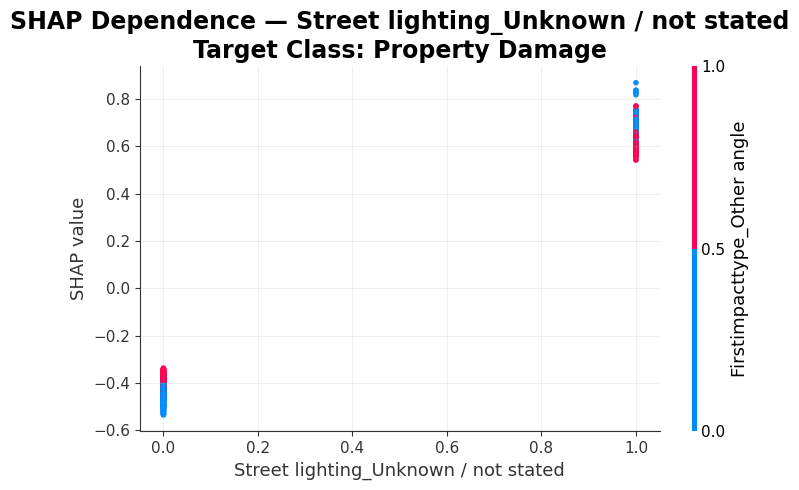

<Figure size 1100x700 with 0 Axes>

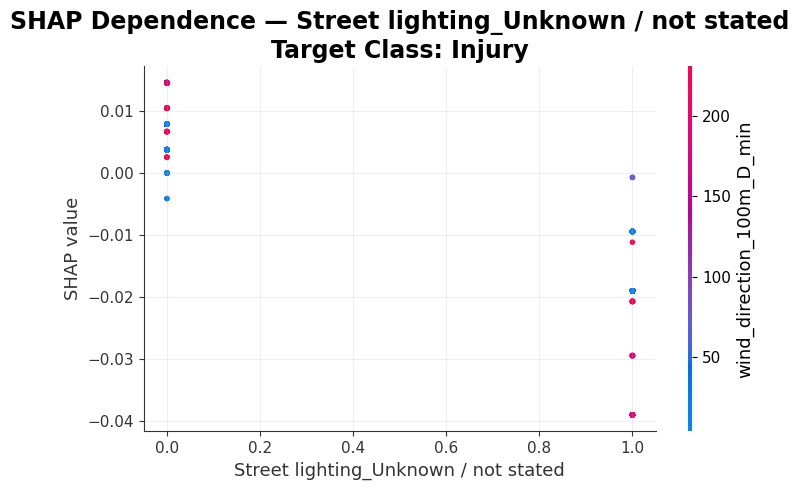

<Figure size 1100x700 with 0 Axes>

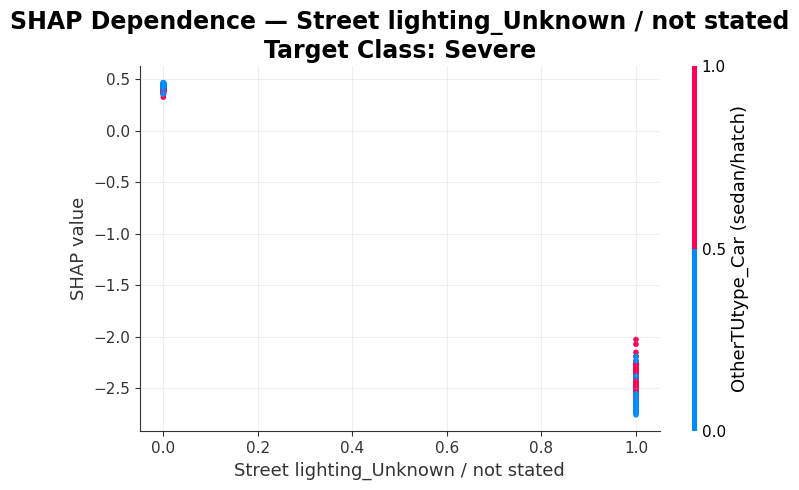

In [135]:
import shap
import matplotlib.pyplot as plt
import os

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

feature = "Street lighting_Unknown / not stated"

if feature not in X_test_clean.columns:
    raise ValueError(f"Feature not found: {feature}")

feature_idx = X_test_clean.columns.get_loc(feature)

class_names = {
    0: "Property Damage",
    1: "Injury",
    2: "Severe"
}

for class_id in [0, 1, 2]:

    plt.figure(figsize=(11, 7))

    shap.dependence_plot(
        feature_idx,
        shap_values.values[:, :, class_id],
        X_test_clean,
        feature_names=X_test_clean.columns,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence — {feature}\n"
        f"Target Class: {class_names[class_id]}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel(feature, fontsize=13)
    plt.ylabel("SHAP value", fontsize=13)

    plt.grid(alpha=0.20)
    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/05_Dependence_StreetLighting_Class{class_id}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

<Figure size 1100x700 with 0 Axes>

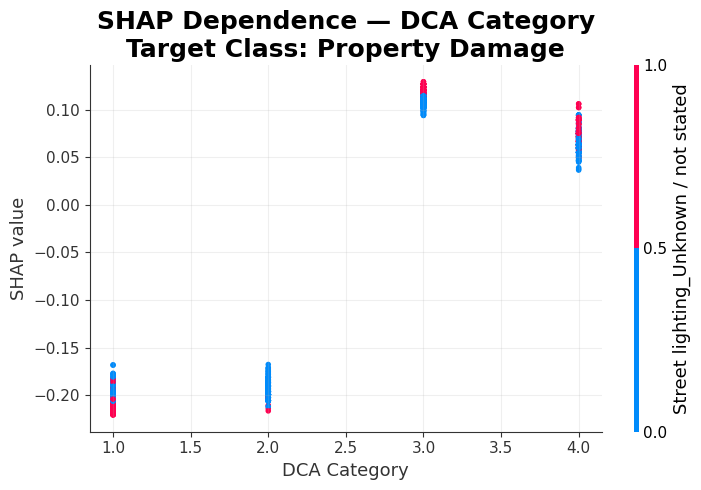

<Figure size 1100x700 with 0 Axes>

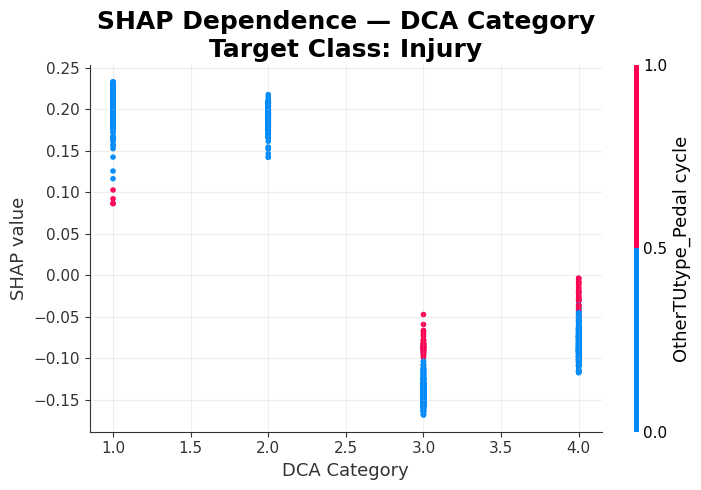

<Figure size 1100x700 with 0 Axes>

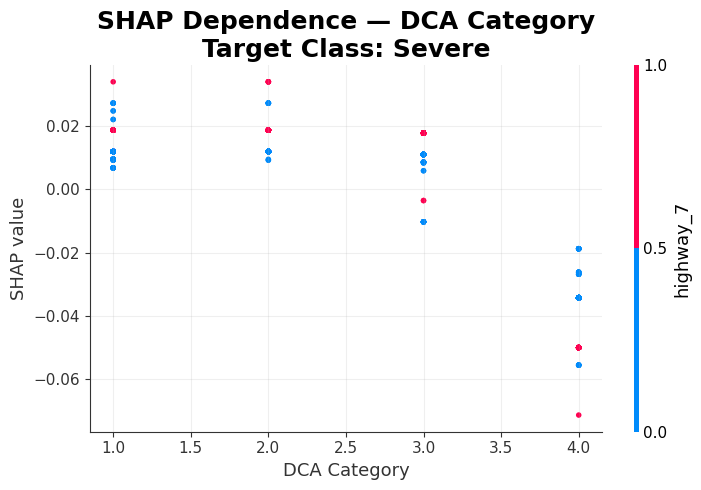

In [136]:
import shap
import matplotlib.pyplot as plt
import os

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

feature = "DCA_category"

if feature not in X_test_clean.columns:
    raise ValueError(f"Feature not found: {feature}")

feature_idx = X_test_clean.columns.get_loc(feature)

class_names = {
    0: "Property Damage",
    1: "Injury",
    2: "Severe"
}

for class_id in [0, 1, 2]:

    plt.figure(figsize=(11, 7))

    shap.dependence_plot(
        feature_idx,
        shap_values.values[:, :, class_id],
        X_test_clean,
        feature_names=X_test_clean.columns,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence — DCA Category\n"
        f"Target Class: {class_names[class_id]}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("DCA Category", fontsize=13)
    plt.ylabel("SHAP value", fontsize=13)

    plt.grid(alpha=0.20)
    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/06_Dependence_DCA_Class{class_id}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

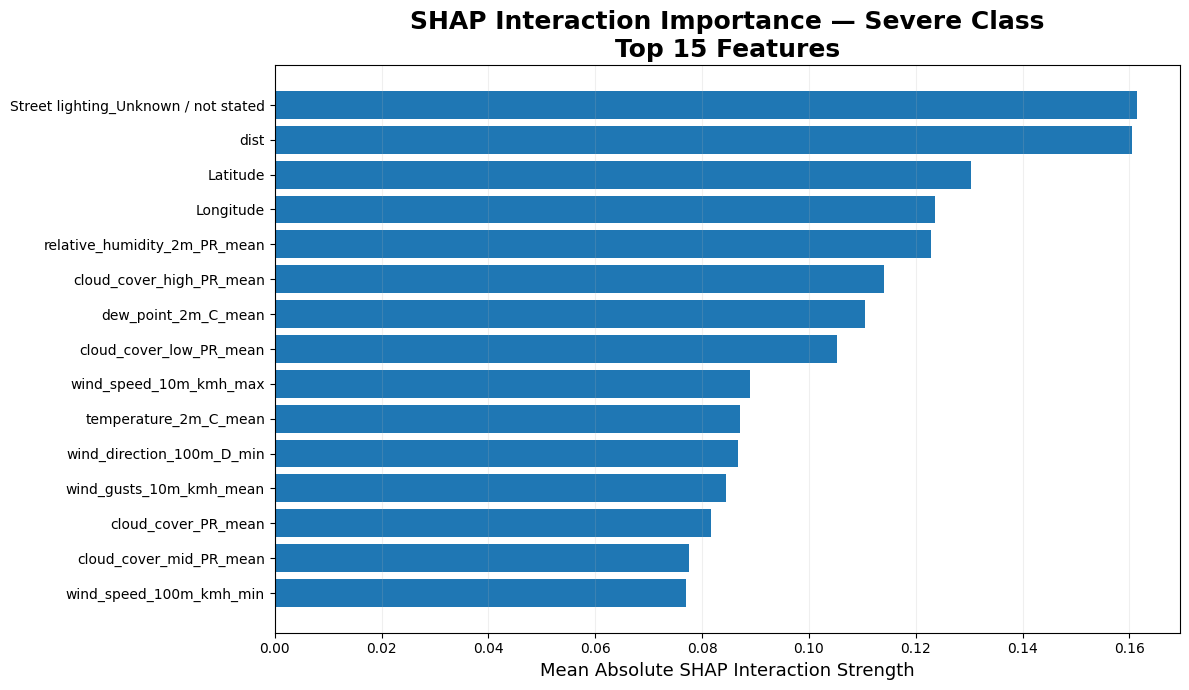

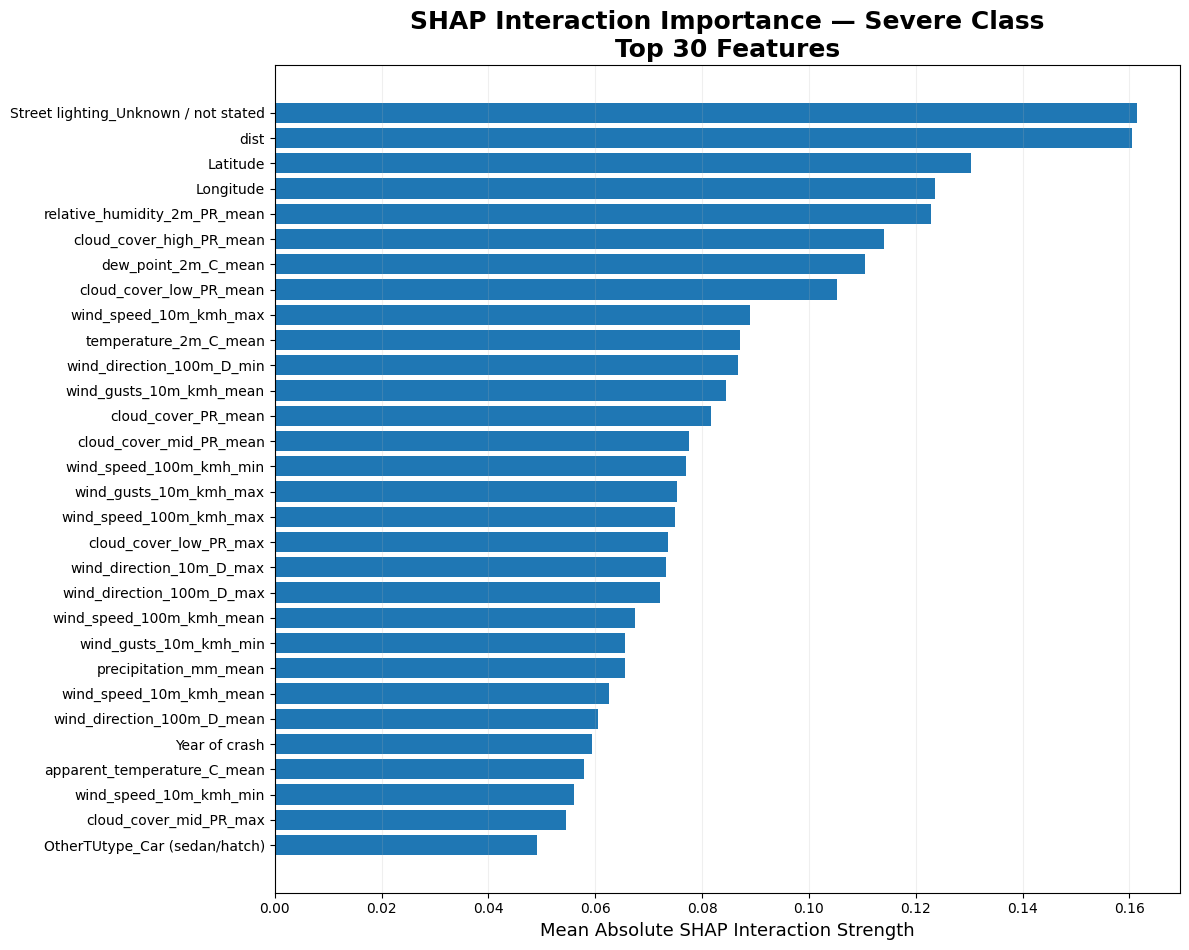

In [137]:
import shap
import matplotlib.pyplot as plt
import os
import numpy as np

explainer = shap.TreeExplainer(best_model)

# برای interaction بهتر است خود داده را به explainer بدهیم
shap_interaction_values = explainer.shap_interaction_values(
    X_test_clean
)

os.makedirs("SHAP_Figures", exist_ok=True)

class_id = 2

# ============================================================
# مدیریت خروجی چندکلاسه
# ============================================================

if isinstance(shap_interaction_values, list):

    interaction_class = shap_interaction_values[class_id]

else:

    # معمولاً:
    # samples × features × features × classes

    if len(shap_interaction_values.shape) == 4:
        interaction_class = shap_interaction_values[:, :, :, class_id]
    else:
        interaction_class = shap_interaction_values

# ============================================================
# Interaction importance
# ============================================================

interaction_importance = np.abs(
    interaction_class
).mean(axis=0)

# حذف diagonal
np.fill_diagonal(interaction_importance, 0)

feature_names = X_test_clean.columns

feature_score = interaction_importance.sum(axis=1)

top_features = np.argsort(feature_score)[::-1]

# ============================================================
# Plot
# ============================================================

for top_n in [15, 30]:

    idx = top_features[:top_n]

    values = feature_score[idx]

    order = np.argsort(values)

    plt.figure(
        figsize=(12, max(7, top_n * 0.32))
    )

    plt.barh(
        range(len(idx)),
        values[order]
    )

    plt.yticks(
        range(len(idx)),
        feature_names[idx][order],
        fontsize=10
    )

    plt.xlabel(
        "Mean Absolute SHAP Interaction Strength",
        fontsize=13
    )

    plt.title(
        f"SHAP Interaction Importance — Severe Class\n"
        f"Top {top_n} Features",
        fontsize=18,
        fontweight="bold"
    )

    plt.grid(axis="x", alpha=0.20)
    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/07_Interaction_Summary_Severe_Top_{top_n}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

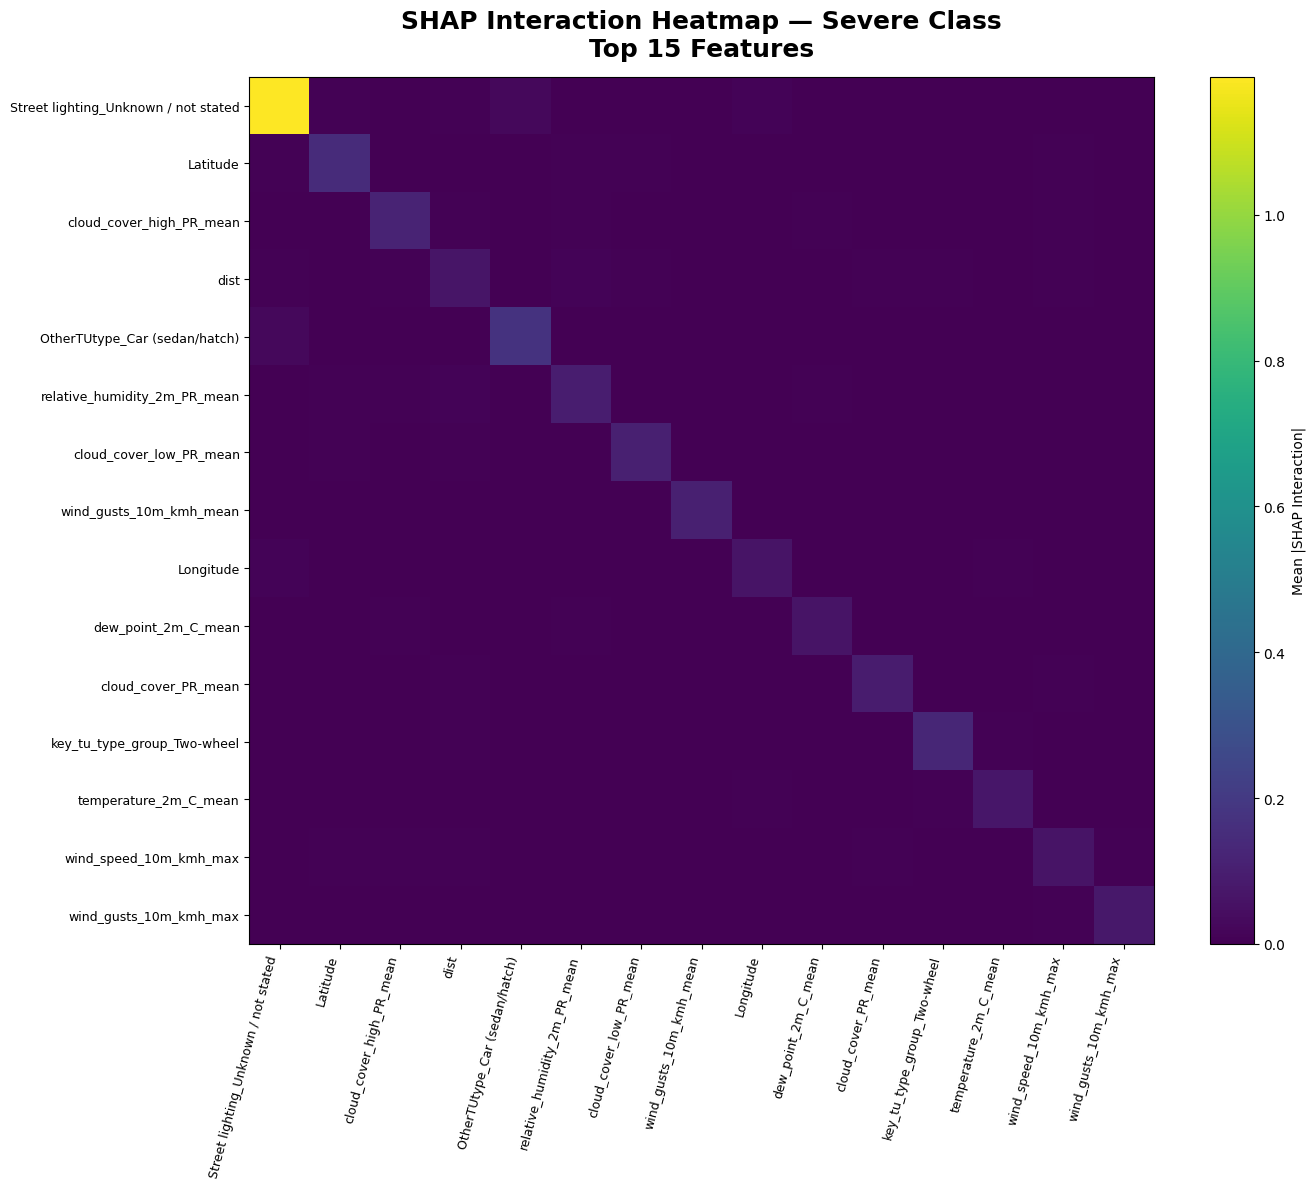

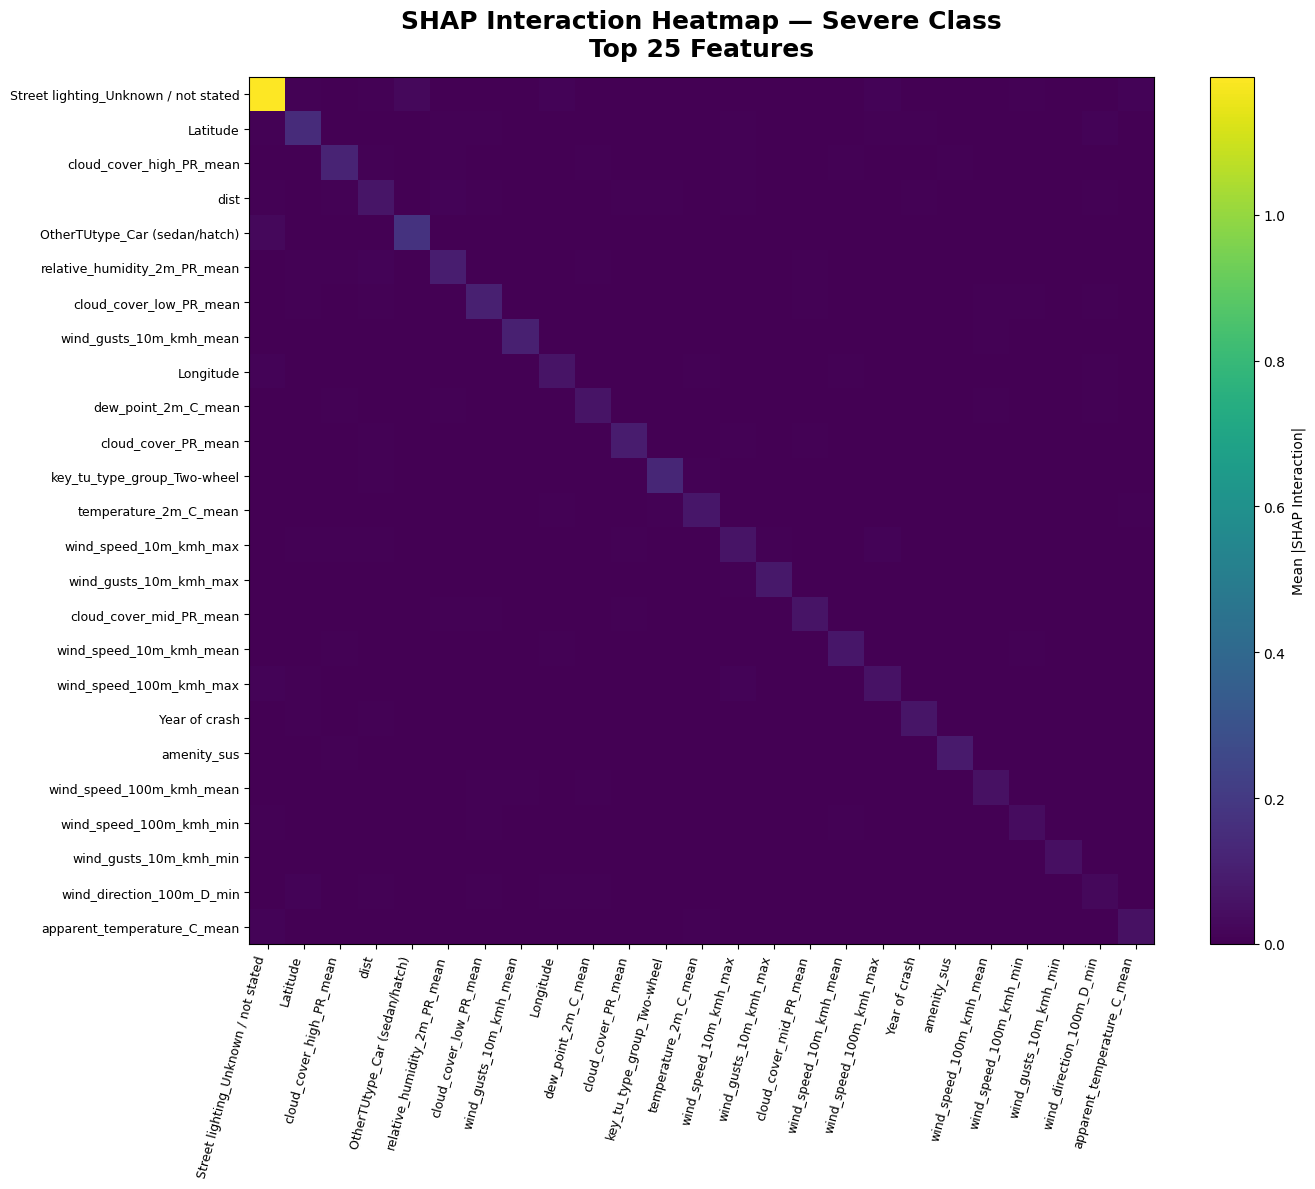

In [138]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import os

explainer = shap.TreeExplainer(best_model)

interaction_values = explainer.shap_interaction_values(
    X_test_clean
)

os.makedirs("SHAP_Figures", exist_ok=True)

class_id = 2

if isinstance(interaction_values, list):

    interaction_class = interaction_values[class_id]

else:

    if len(interaction_values.shape) == 4:
        interaction_class = interaction_values[:, :, :, class_id]
    else:
        interaction_class = interaction_values

# ============================================================
# Mean interaction matrix
# ============================================================

mean_interaction = np.abs(
    interaction_class
).mean(axis=0)

feature_score = mean_interaction.sum(axis=1)

ranking = np.argsort(feature_score)[::-1]

feature_names = X_test_clean.columns

# ============================================================
# Heatmaps
# ============================================================

for top_n in [15, 25]:

    selected = ranking[:top_n]

    matrix = mean_interaction[
        np.ix_(selected, selected)
    ]

    labels = feature_names[selected]

    plt.figure(
        figsize=(14, 12)
    )

    plt.imshow(
        matrix,
        aspect="auto"
    )

    plt.colorbar(
        label="Mean |SHAP Interaction|"
    )

    plt.xticks(
        range(top_n),
        labels,
        rotation=75,
        ha="right",
        fontsize=9
    )

    plt.yticks(
        range(top_n),
        labels,
        fontsize=9
    )

    plt.title(
        f"SHAP Interaction Heatmap — Severe Class\n"
        f"Top {top_n} Features",
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/08_Interaction_Heatmap_Severe_Top_{top_n}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

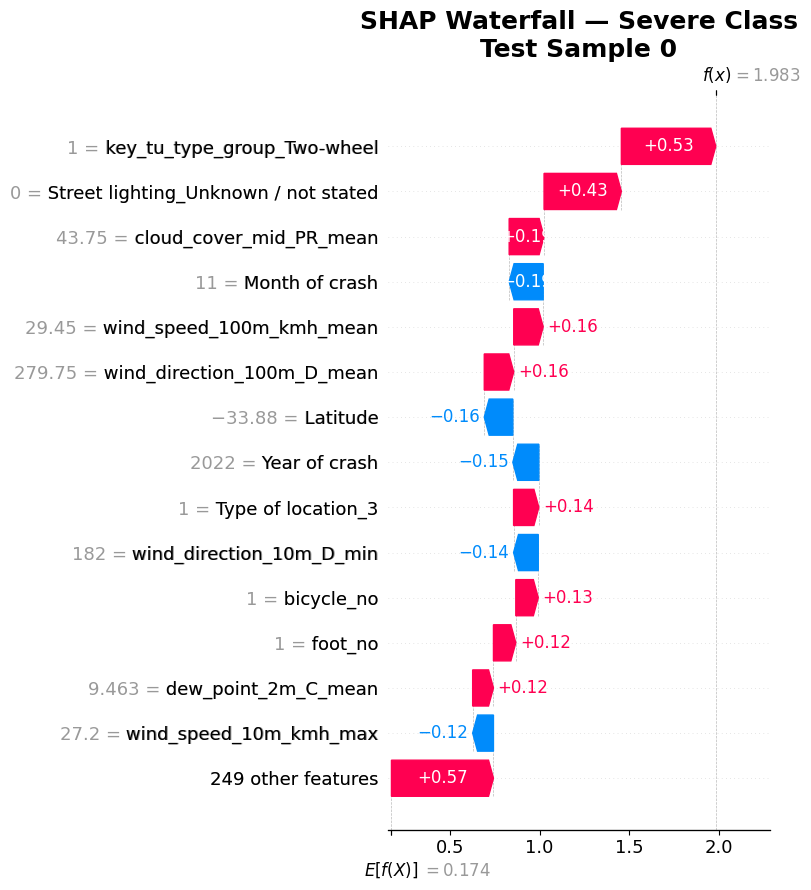

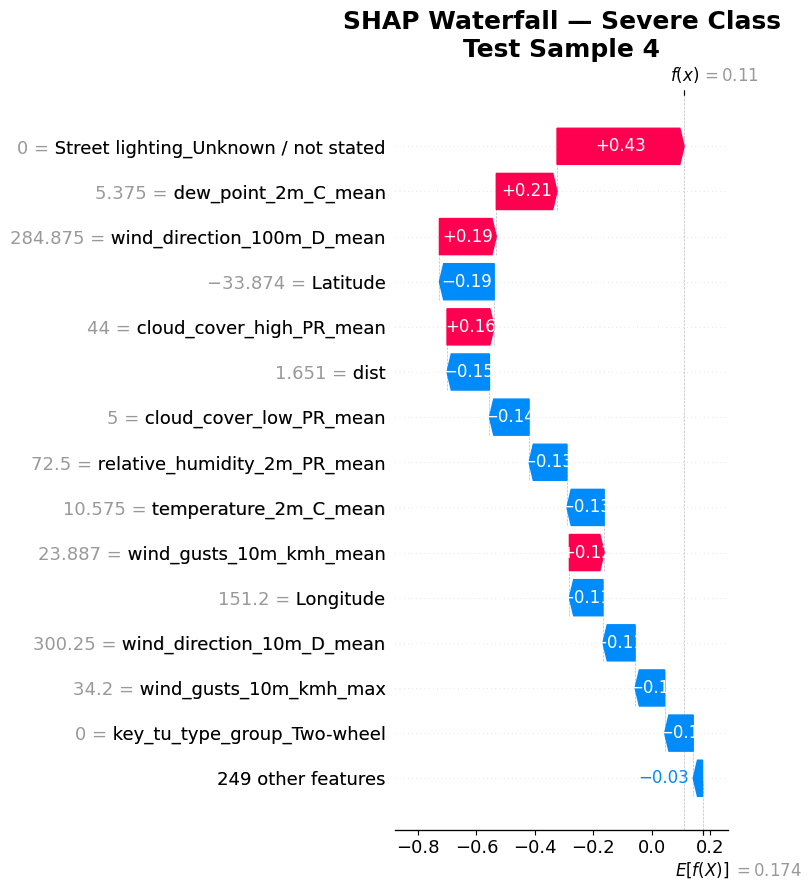

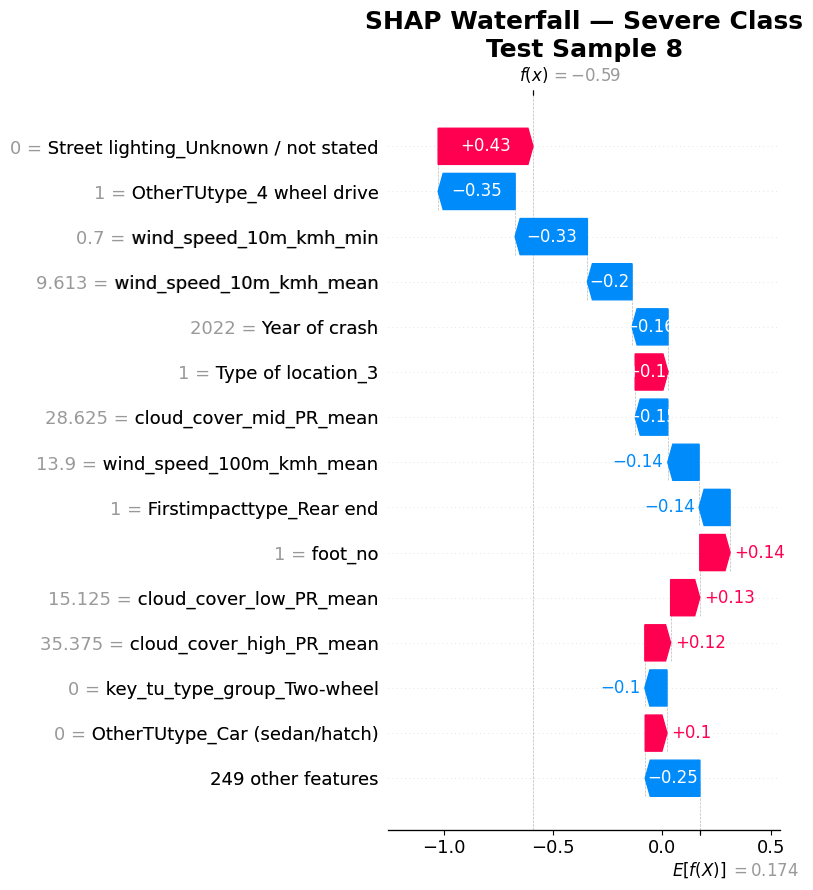

In [139]:
import shap
import matplotlib.pyplot as plt
import os
import numpy as np

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures", exist_ok=True)

class_id = 2

# ============================================================
# اگر y_test موجود است
# ============================================================

# اگر نام تارگت شما y_test است، همین خط را نگه دار
severe_indices = np.where(y_test.values == 2)[0]

# سه نمونه Severe
selected_indices = severe_indices[:3]

for i, sample_idx in enumerate(selected_indices):

    plt.figure(
        figsize=(13, 8)
    )

    shap.plots.waterfall(
        shap_values[sample_idx, :, class_id],
        max_display=15,
        show=False
    )

    plt.title(
        f"SHAP Waterfall — Severe Class\n"
        f"Test Sample {sample_idx}",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"SHAP_Figures/09_Waterfall_Severe_Sample_{sample_idx}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [140]:
import shap
import os
import numpy as np

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_clean)

os.makedirs("SHAP_Figures/Force_Plots", exist_ok=True)

class_id = 2

# ============================================================
# Severe samples
# ============================================================

severe_indices = np.where(y_test.values == 2)[0]

selected_indices = severe_indices[:3]

# ============================================================
# Generate HTML force plots
# ============================================================

for sample_idx in selected_indices:

    force_plot = shap.force_plot(
        shap_values.base_values[sample_idx, class_id],
        shap_values.values[sample_idx, :, class_id],
        X_test_clean.iloc[sample_idx],
        matplotlib=False
    )

    output_file = (
        f"SHAP_Figures/Force_Plots/"
        f"10_ForcePlot_Severe_Sample_{sample_idx}.html"
    )

    shap.save_html(
        output_file,
        force_plot
    )

    print(f"Saved: {output_file}")

Saved: SHAP_Figures/Force_Plots/10_ForcePlot_Severe_Sample_0.html
Saved: SHAP_Figures/Force_Plots/10_ForcePlot_Severe_Sample_4.html
Saved: SHAP_Figures/Force_Plots/10_ForcePlot_Severe_Sample_8.html


TEST DATA CHECK
X_test_clean shape: (1196, 263)
y_test shape      : (1196,)

SEVERE OBSERVATIONS
Total Severe observations in Test: 228

Selected observations: 20
All selected classes: [2]

Selected X_test_clean indices:
01. index = 5150
02. index = 3918
03. index = 5024
04. index = 5509
05. index = 2017
06. index = 3778
07. index = 3658
08. index = 3208
09. index = 1428
10. index = 2562
11. index = 3473
12. index = 4139
13. index = 2180
14. index = 1534
15. index = 706
16. index = 1587
17. index = 2453
18. index = 4340
19. index = 3112
20. index = 1751

FEATURE CHECK
Model features: 263
Selected features: 263
Feature alignment: OK

MODEL PREDICTIONS
 Test_Index  Actual_Class  Predicted_Class  P(Class 0)  P(Class 1)  P(Class 2 Severe)
       5150             2                2    0.019285    0.094860           0.885854
       3918             2                0    0.565893    0.303255           0.130852
       5024             2                1    0.103675    0.793199           0.1031

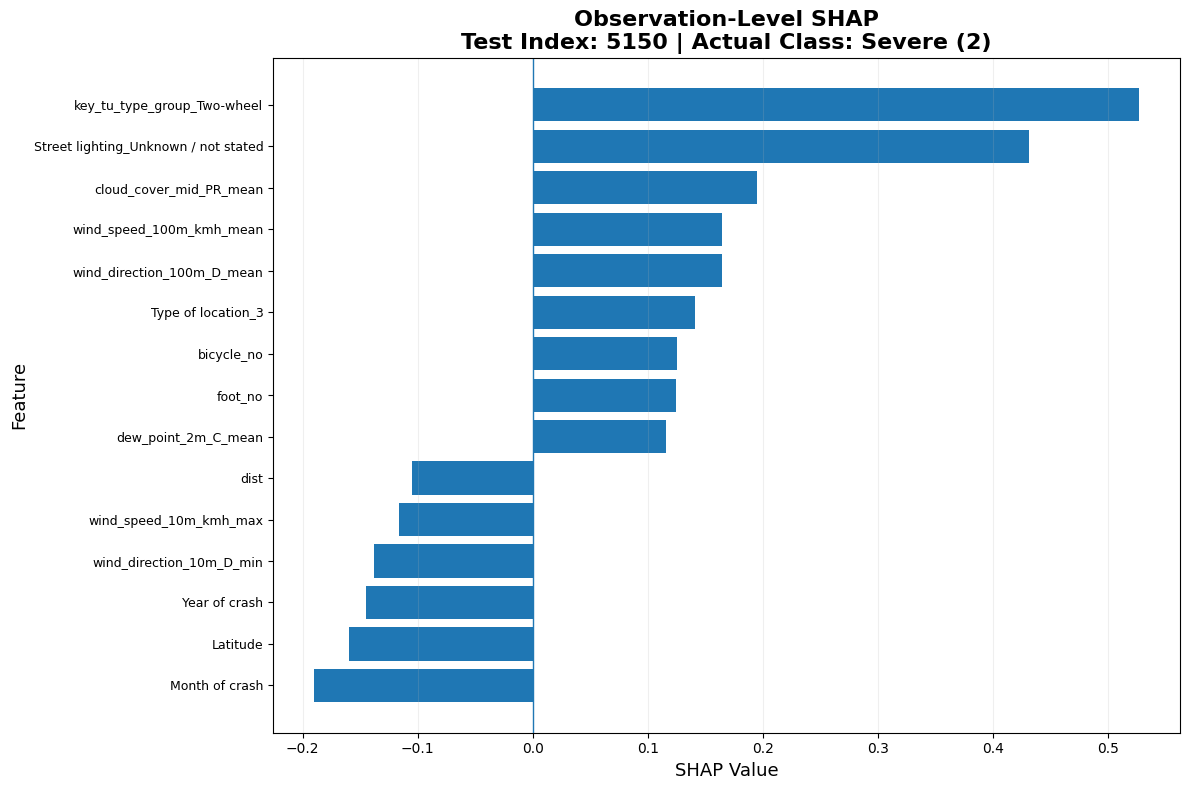

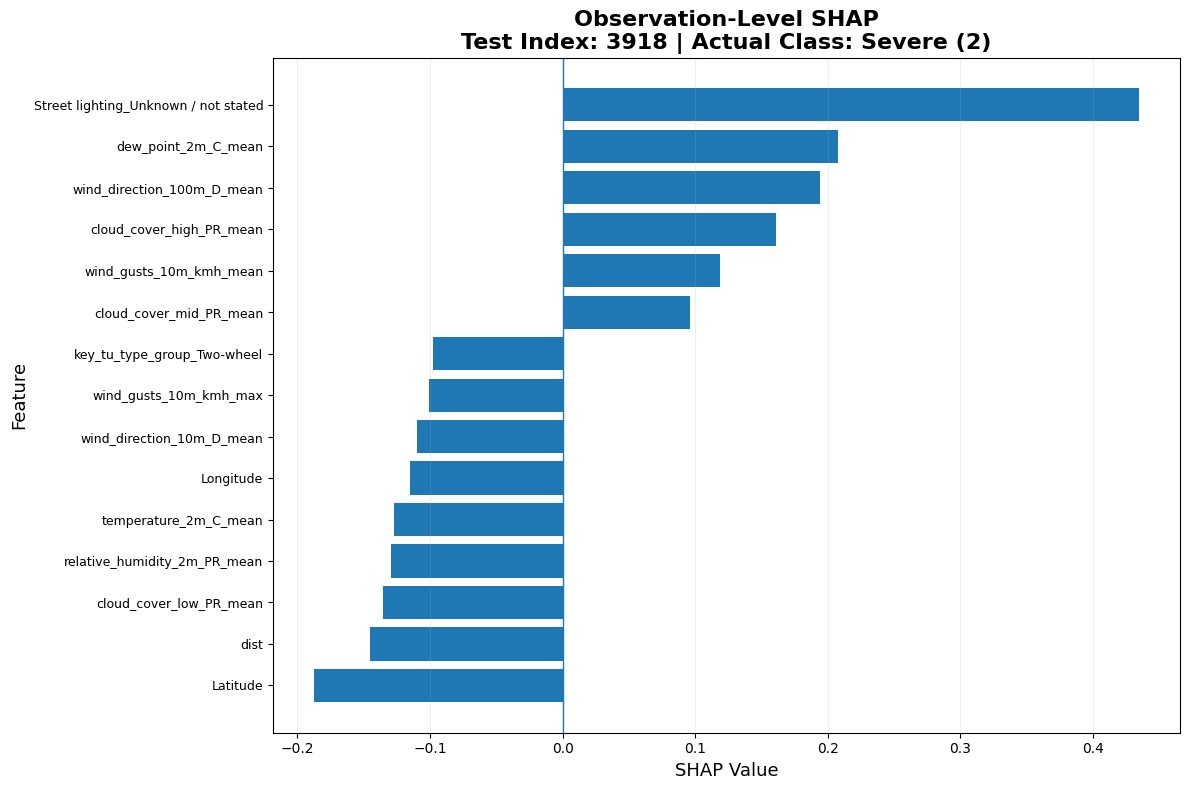

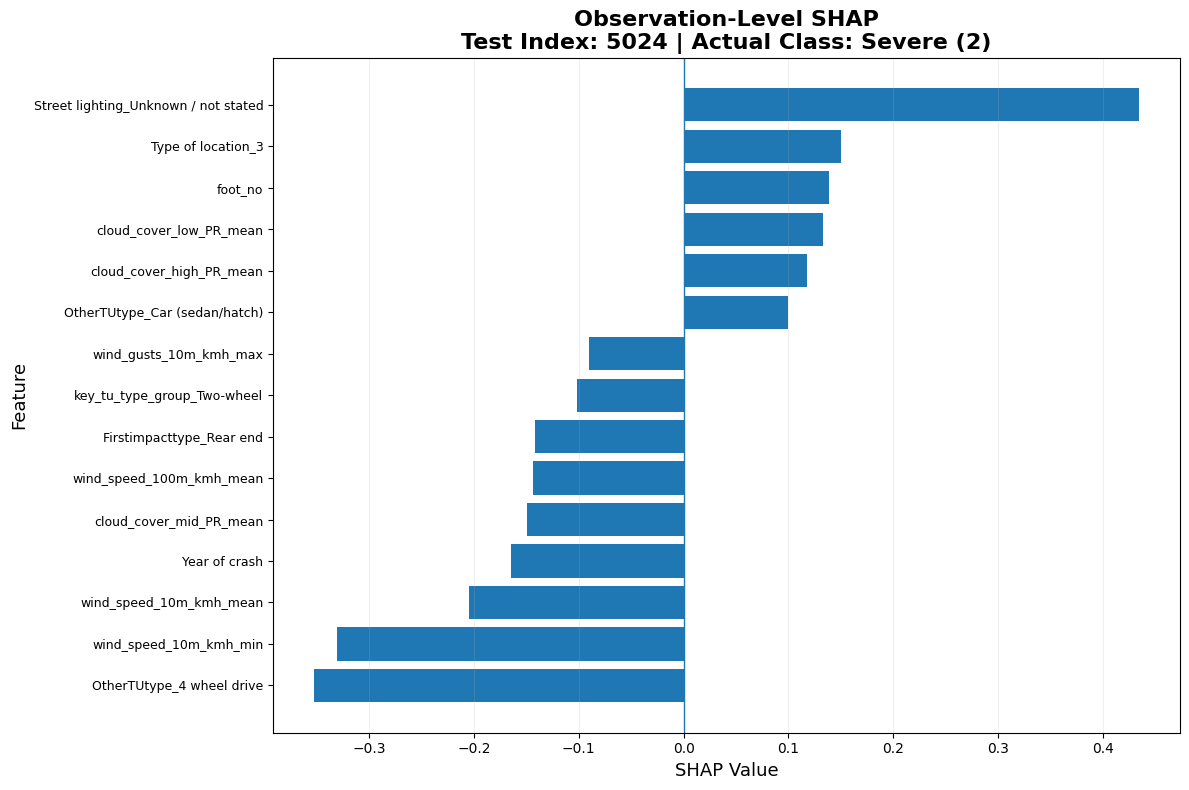

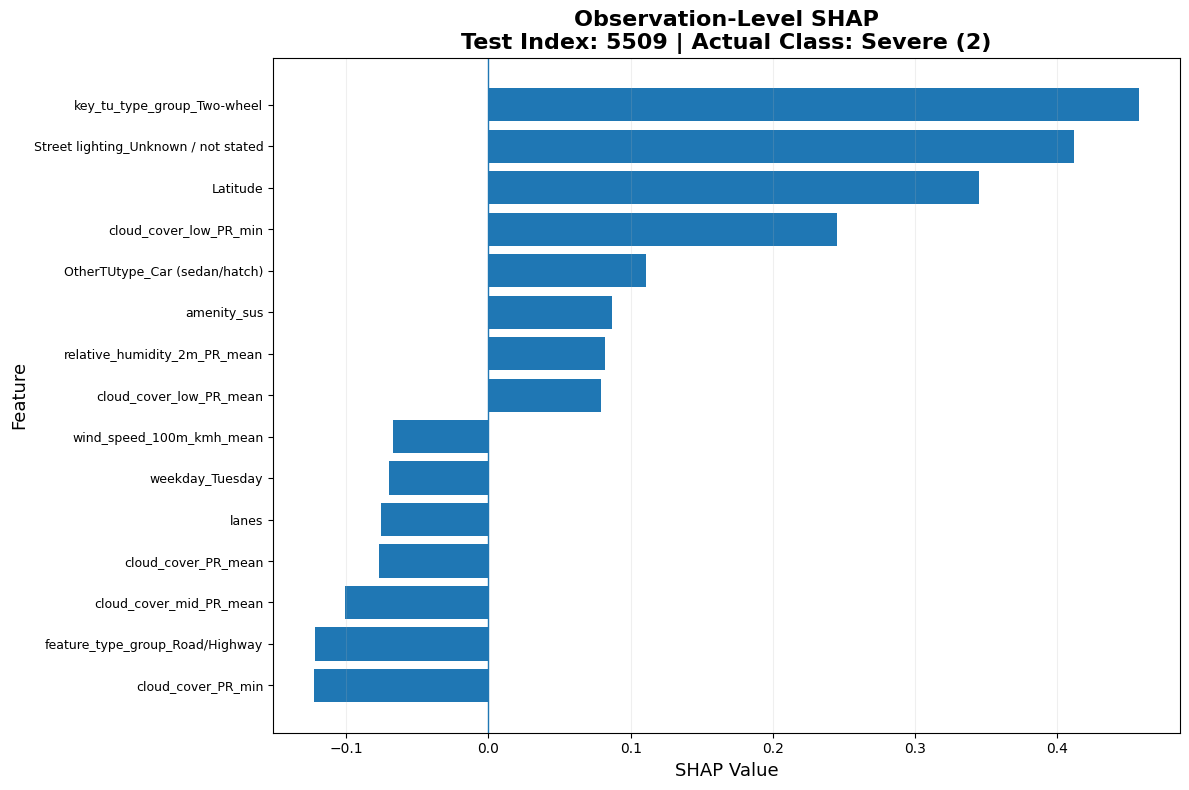

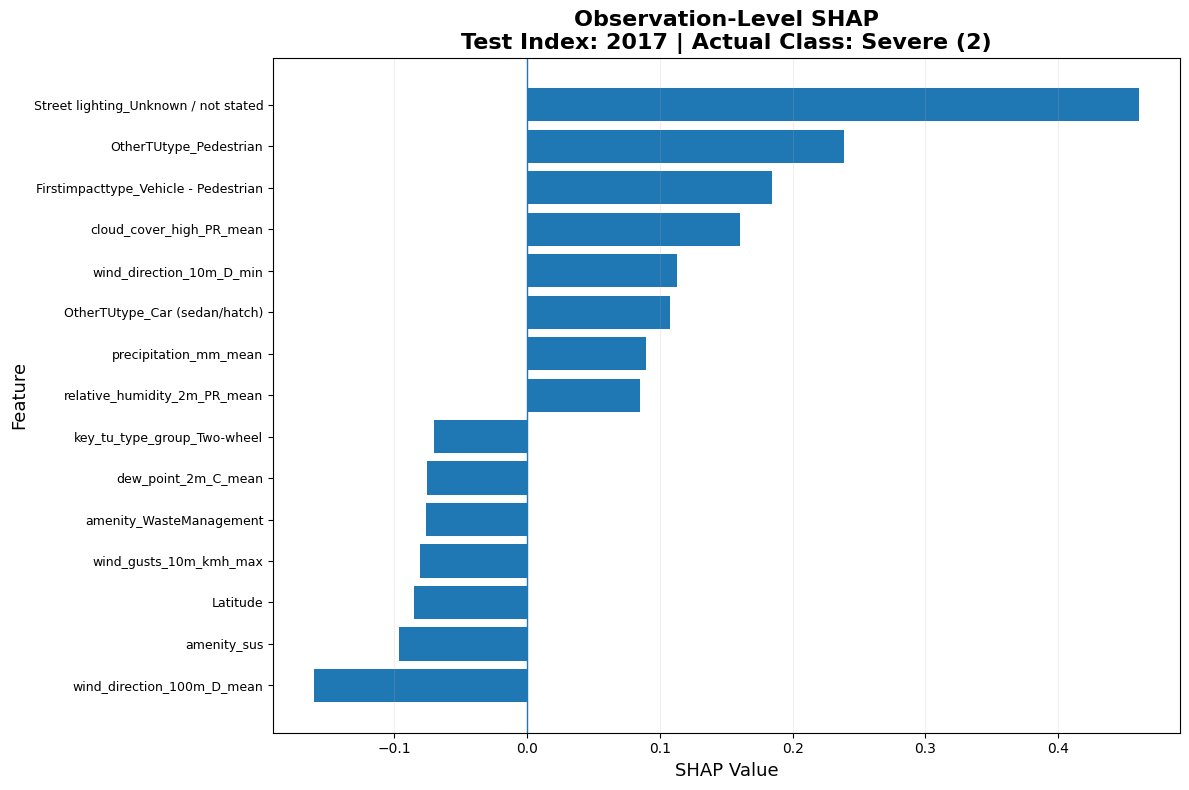

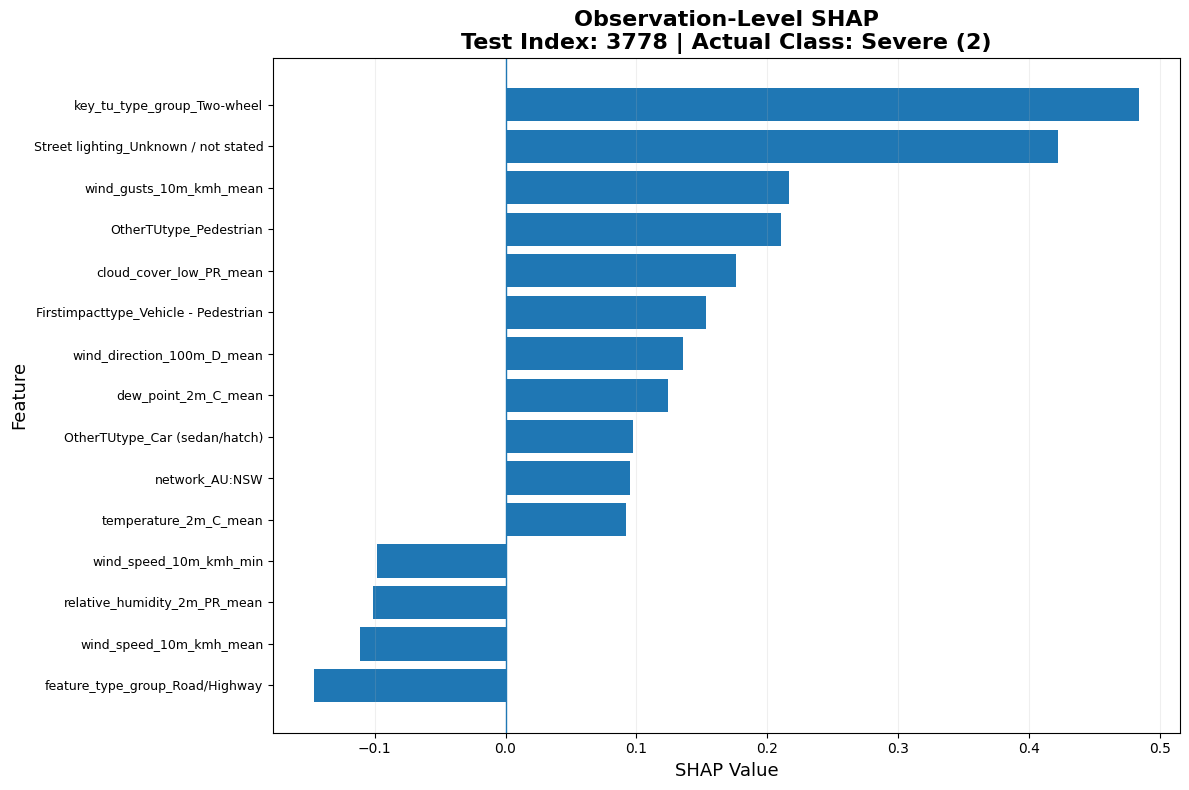

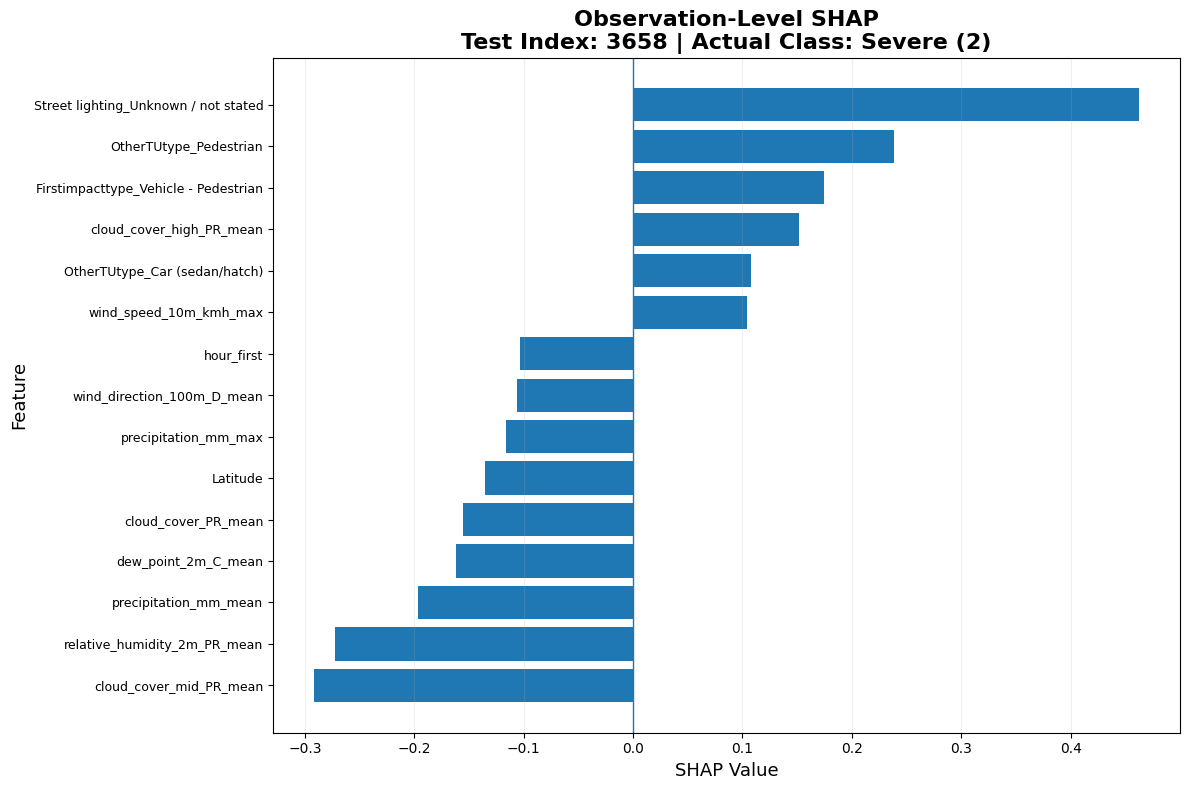

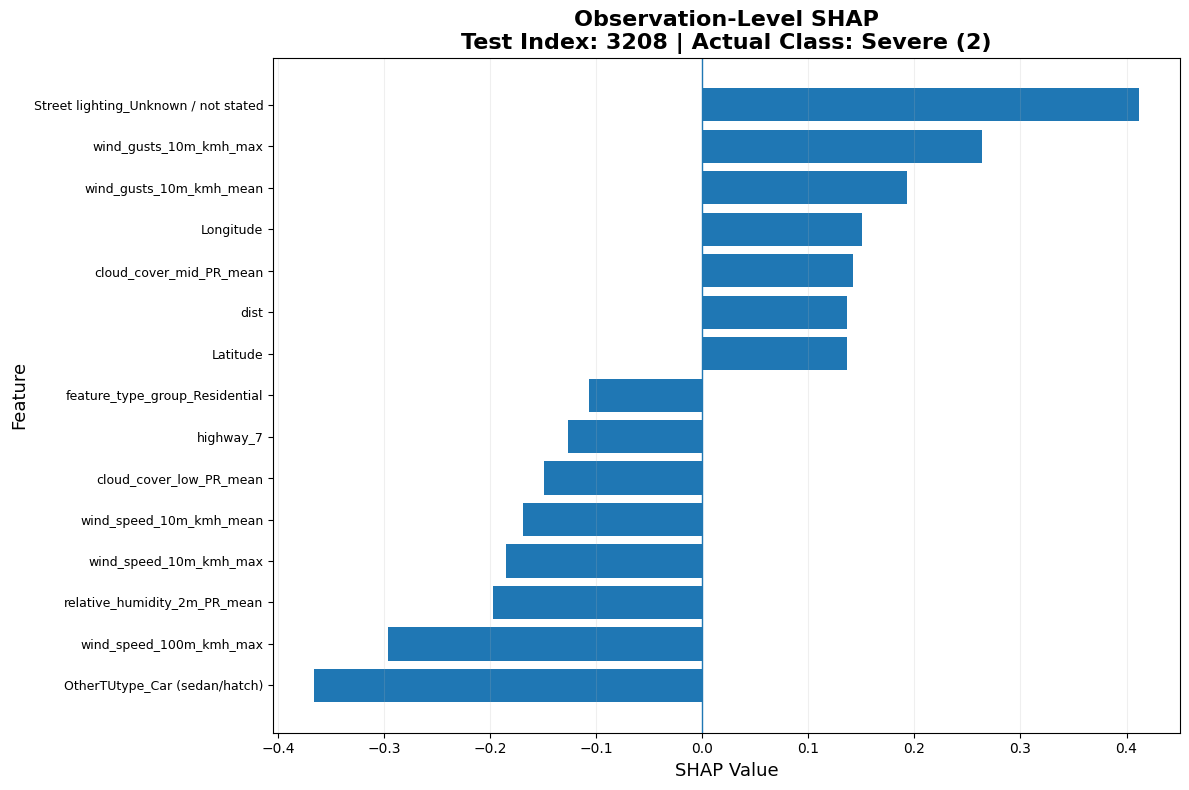

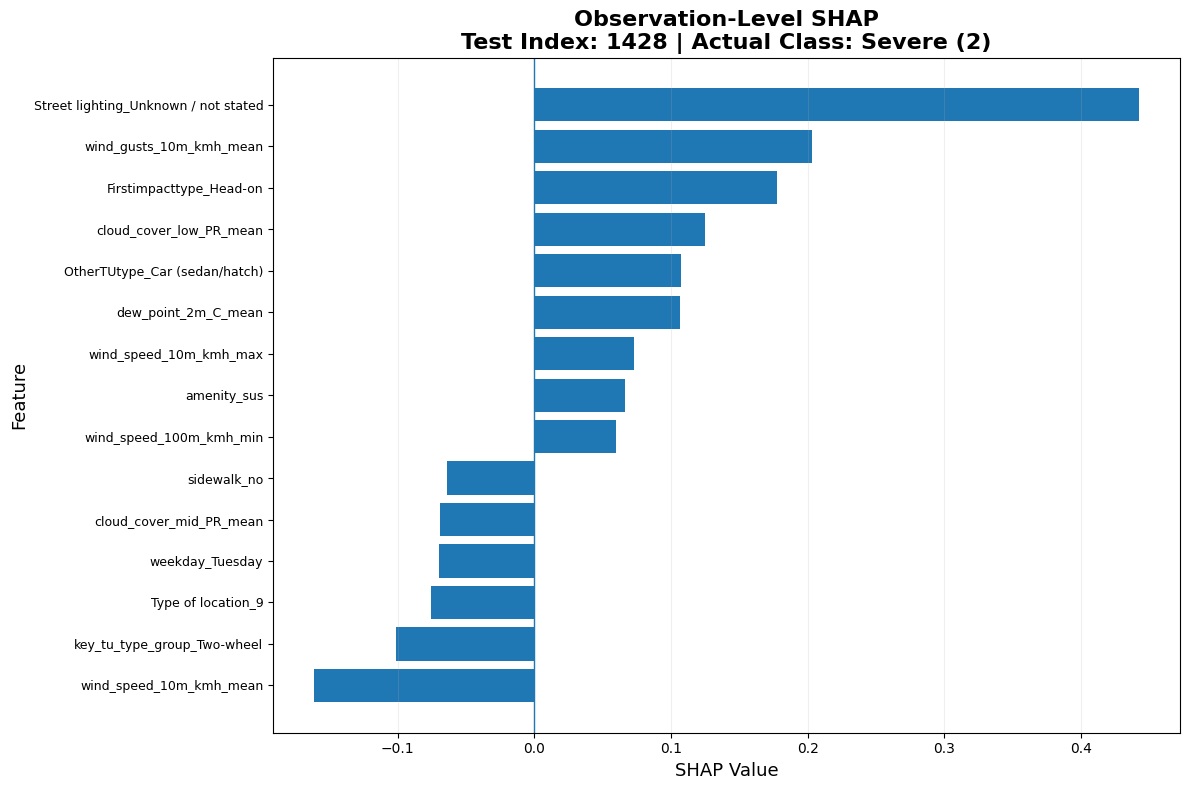

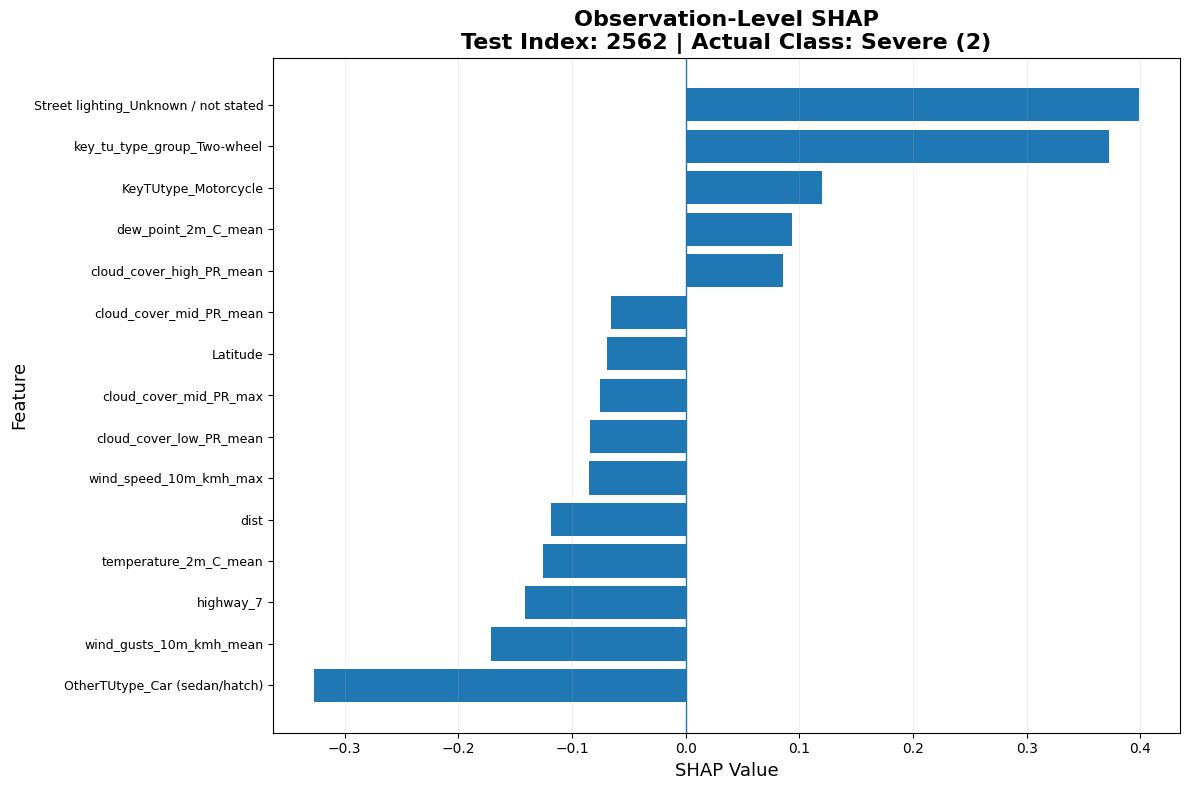

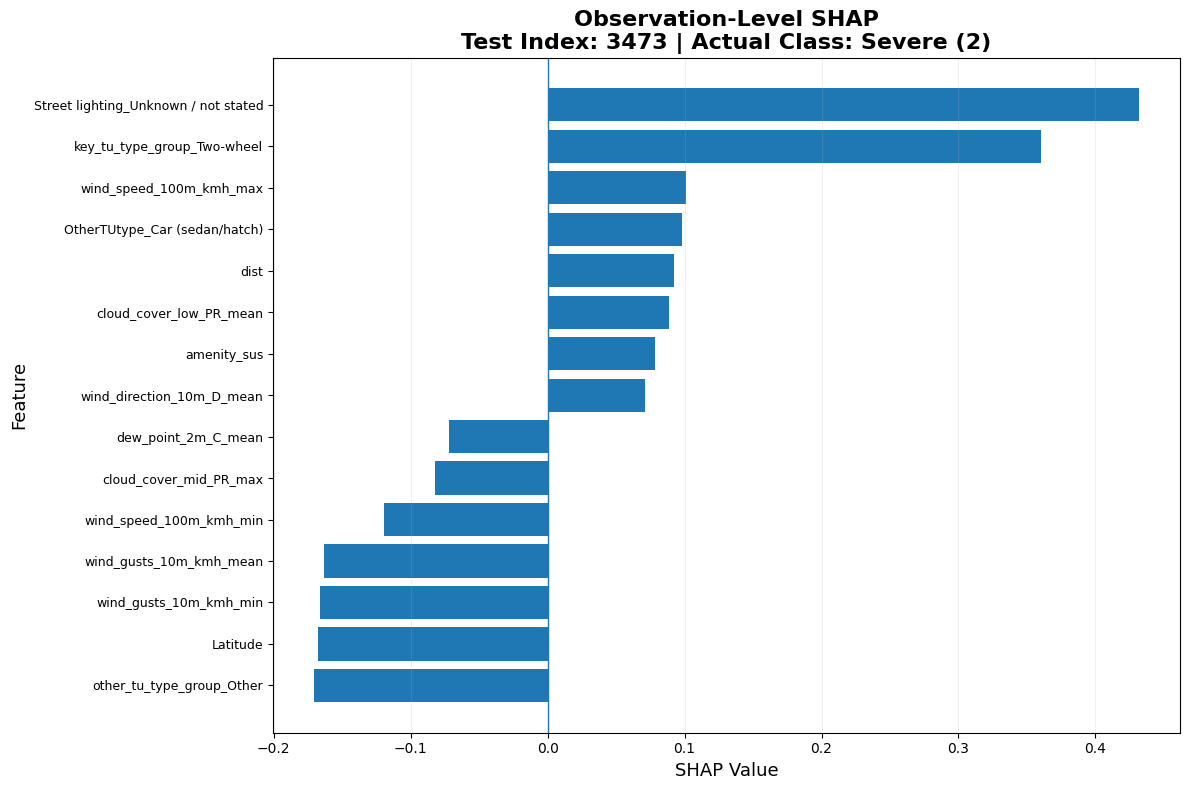

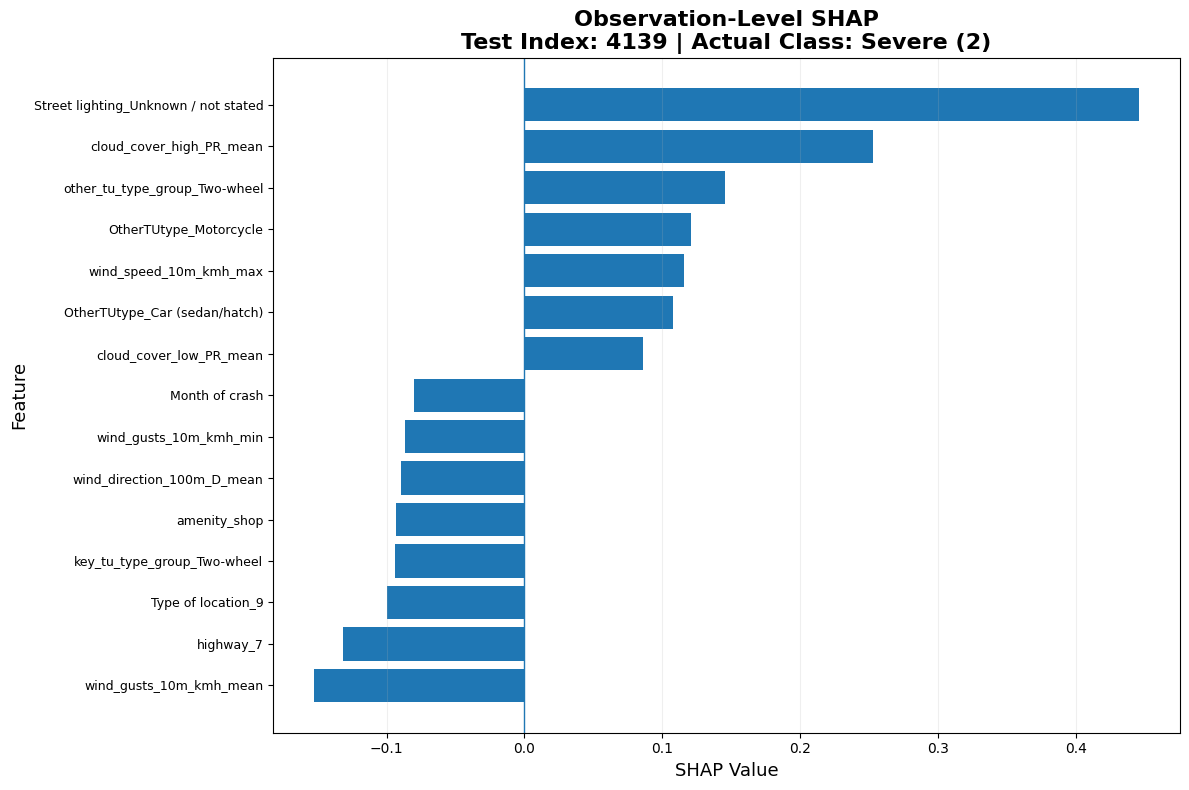

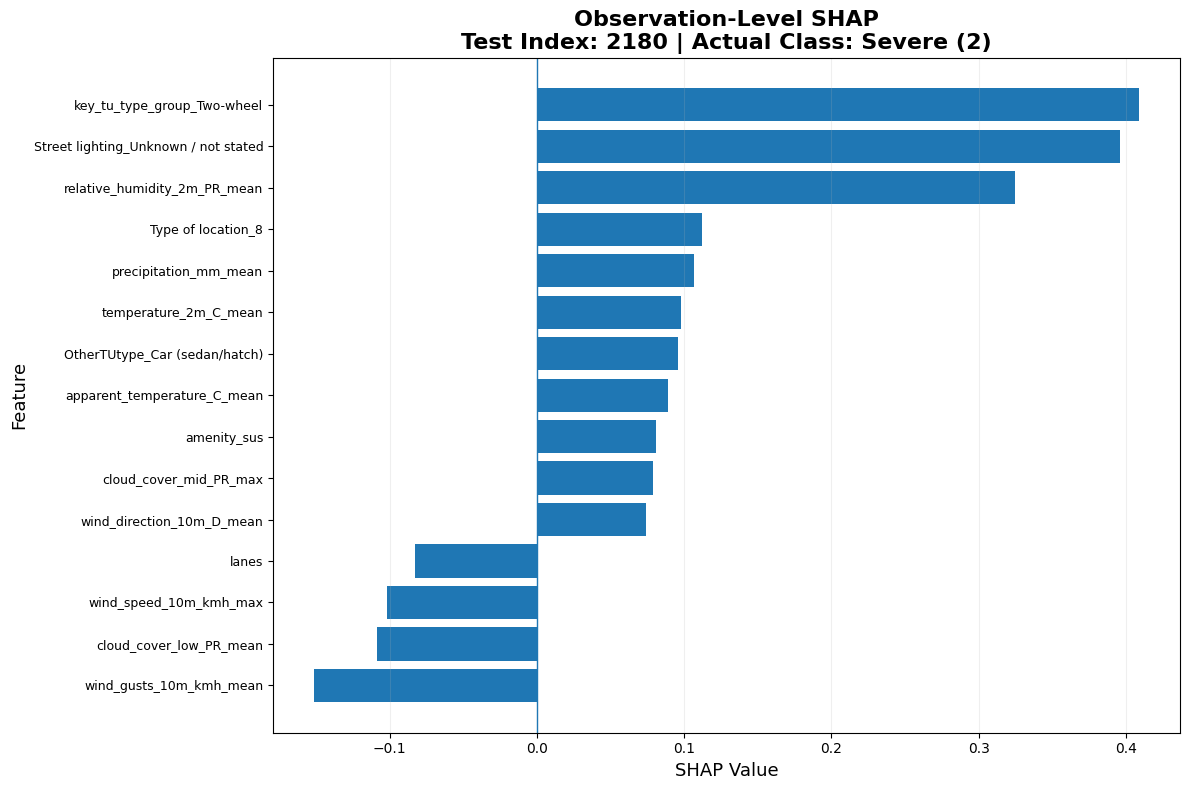

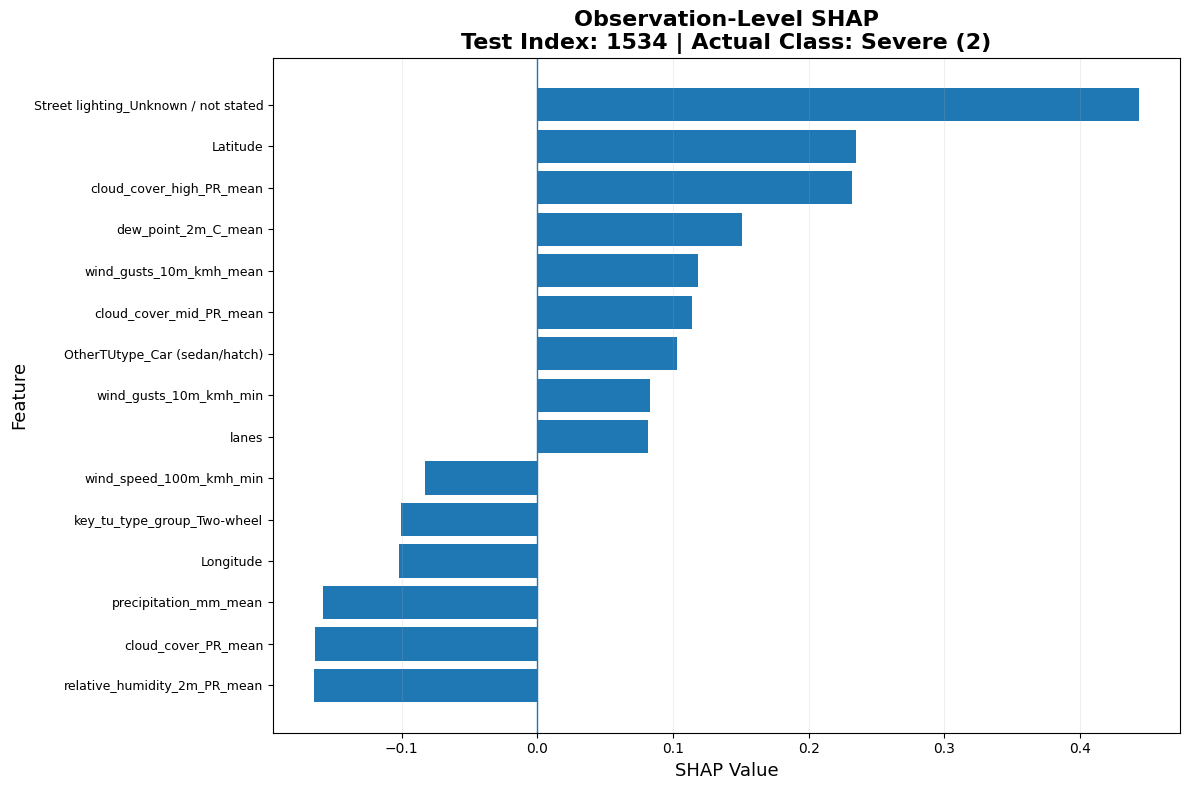

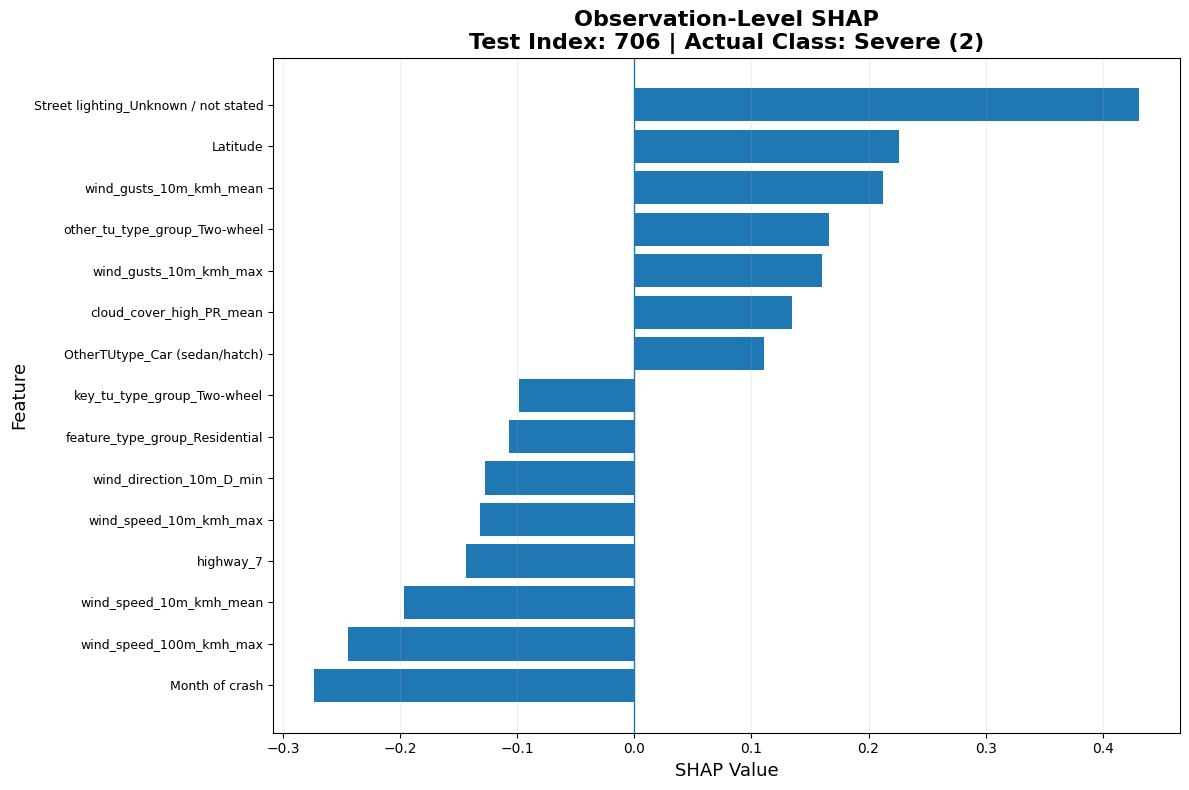

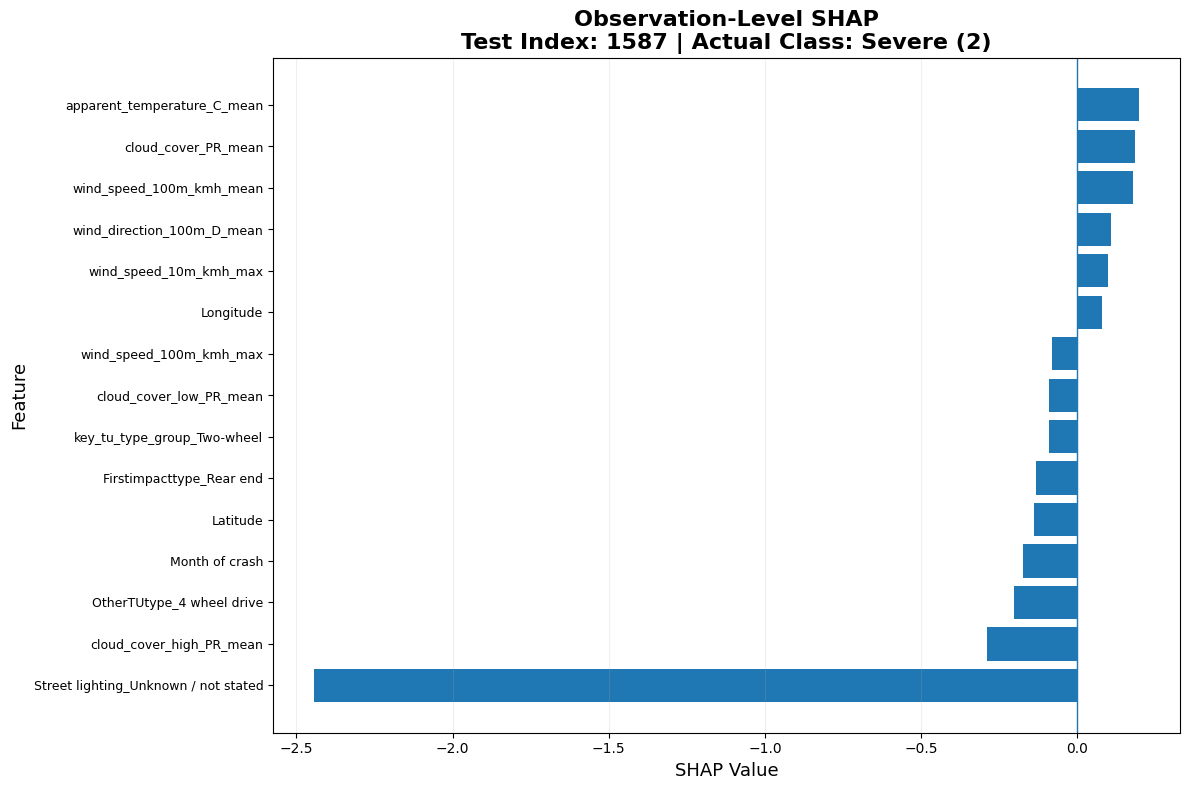

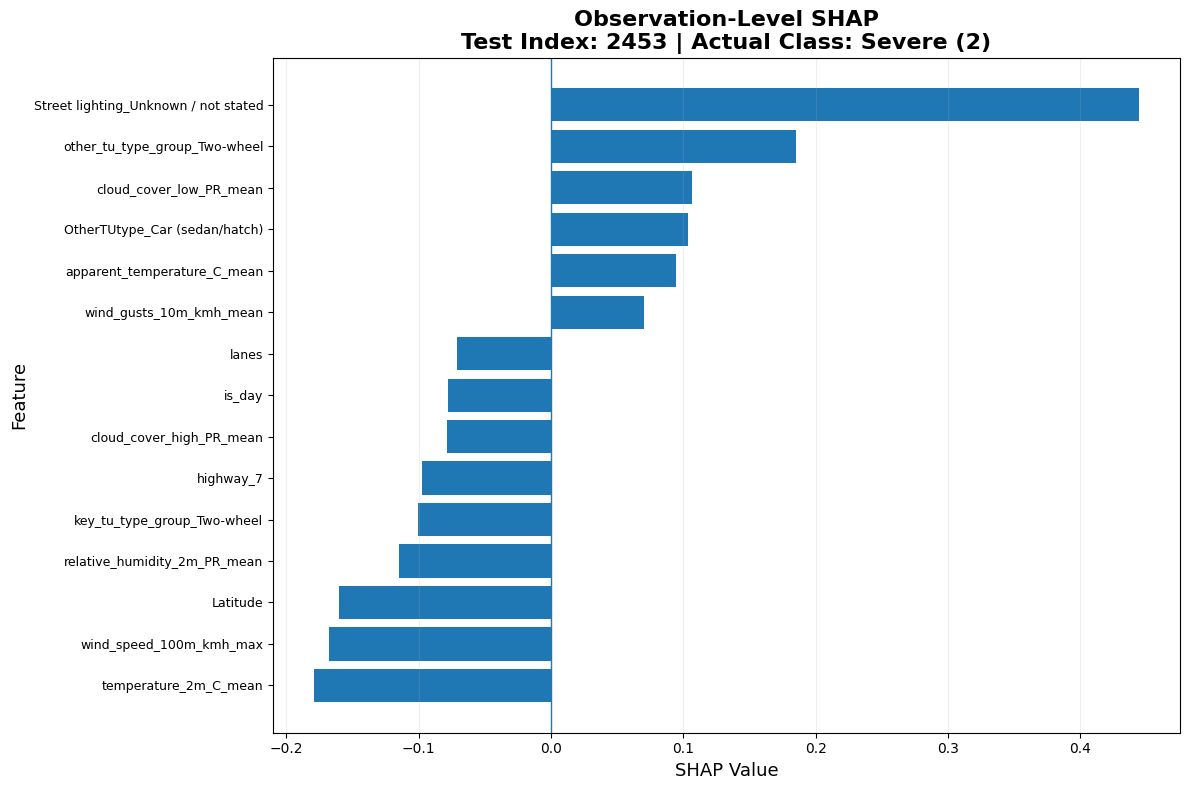

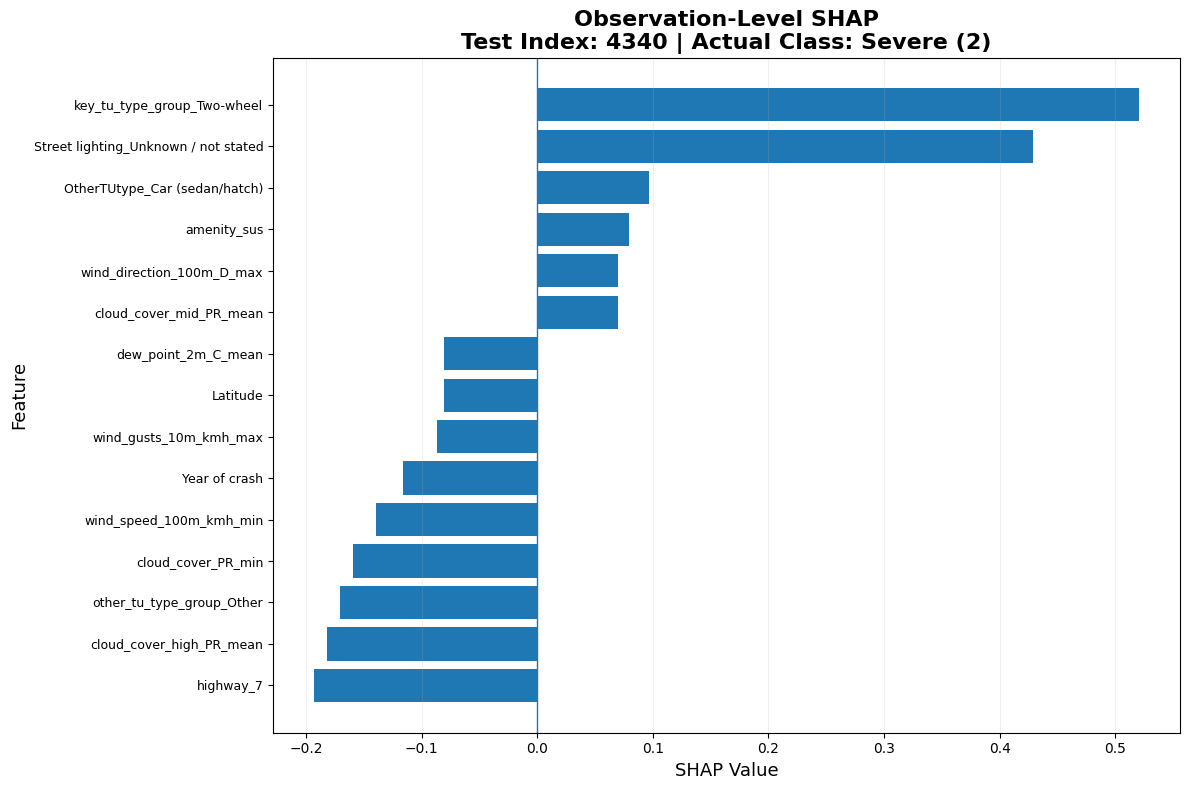

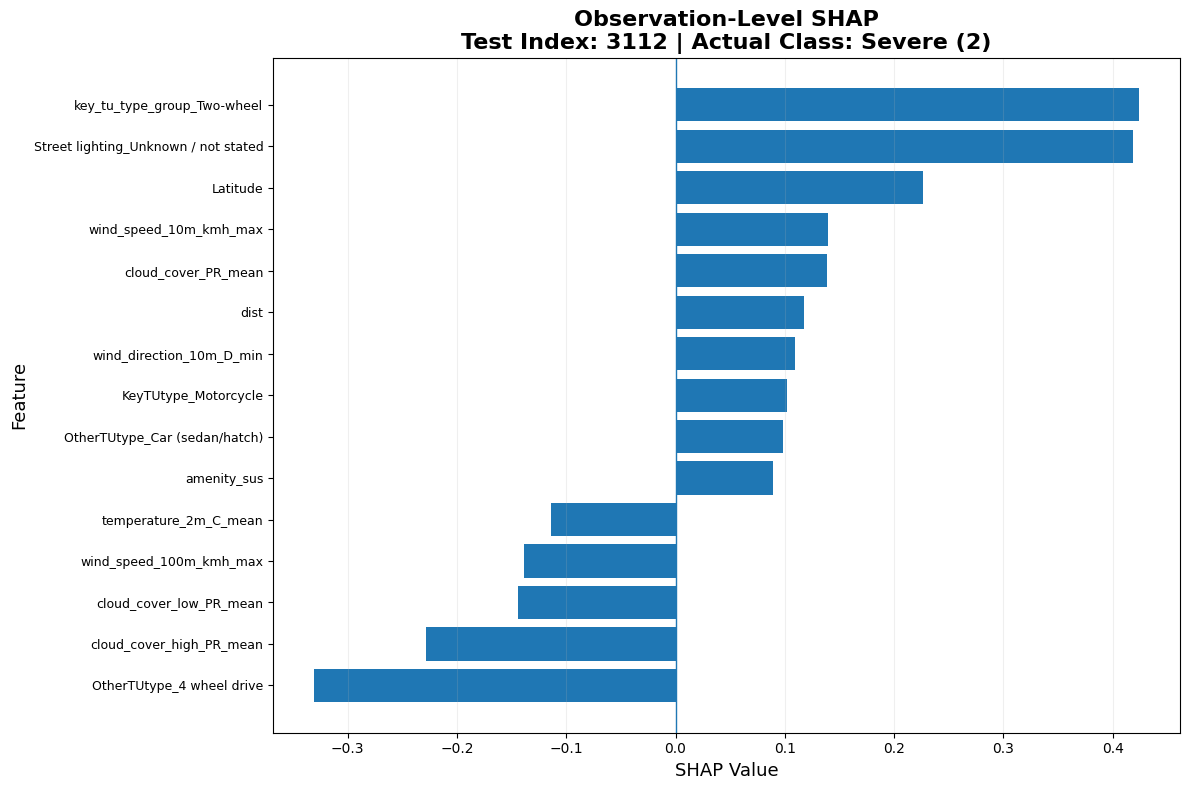

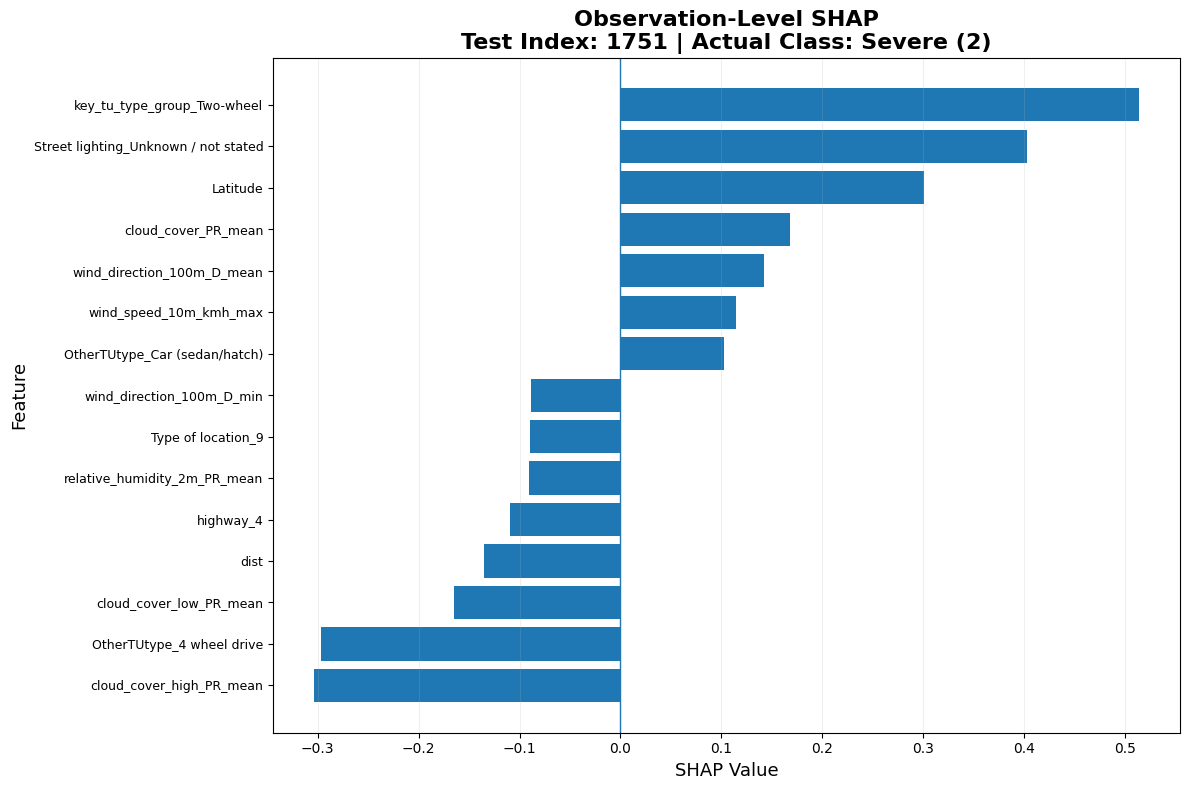


SHAP ANALYSIS COMPLETED

Number of Severe observations analyzed: 20

Output folder:
SHAP_First20_Severe_Observations

Files:
1. First20_Severe_Predictions.csv
2. First20_Severe_SHAP_Values.csv
3. First20_Severe_SHAP_Details.csv
4. First20_Severe_Top10_SHAP.csv
5. First20_Severe_SHAP_Summary.csv
6. Individual SHAP plots for each observation


In [155]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# OBSERVATION-LEVEL SHAP
# First 20 Severe (Class = 2) Test Observations
# Best XGBoost + Mild Undersampling
# ============================================================

# ------------------------------------------------------------
# 1. CHECK TEST DATA
# ------------------------------------------------------------

print("=" * 100)
print("TEST DATA CHECK")
print("=" * 100)

print("X_test_clean shape:", X_test_clean.shape)
print("y_test shape      :", y_test.shape)

# ------------------------------------------------------------
# 2. MAKE SURE INDEXES ARE ALIGNED
# ------------------------------------------------------------

if len(X_test_clean) != len(y_test):

    raise ValueError(
        "تعداد X_test_clean و y_test برابر نیست."
    )

# ------------------------------------------------------------
# 3. FIND SEVERE OBSERVATIONS
# ------------------------------------------------------------

severe_mask = (
    np.asarray(y_test) == 2
)

severe_positions = np.where(
    severe_mask
)[0]

print("\n" + "=" * 100)
print("SEVERE OBSERVATIONS")
print("=" * 100)

print(
    "Total Severe observations in Test:",
    len(severe_positions)
)

# ------------------------------------------------------------
# 4. SELECT FIRST 20 SEVERE OBSERVATIONS
# ------------------------------------------------------------

n_observations = min(
    20,
    len(severe_positions)
)

selected_positions = severe_positions[
    :n_observations
]

# با iloc انتخاب می‌کنیم تا مستقل از index باشد
X_selected = X_test_clean.iloc[
    selected_positions
].copy()

y_selected = np.asarray(
    y_test
)[selected_positions]

print(
    "\nSelected observations:",
    len(X_selected)
)

print(
    "All selected classes:",
    np.unique(y_selected)
)

# ------------------------------------------------------------
# 5. SHOW ORIGINAL INDEX
# ------------------------------------------------------------

selected_indices = X_selected.index.tolist()

print("\nSelected X_test_clean indices:")

for i, idx in enumerate(
    selected_indices,
    start=1
):

    print(
        f"{i:02d}. index = {idx}"
    )

# ============================================================
# 6. VERIFY FEATURES
# ============================================================

model_features = X_train_clean.columns.tolist()

if list(X_selected.columns) != model_features:

    # اگر ترتیب متفاوت باشد
    missing = [
        f for f in model_features
        if f not in X_selected.columns
    ]

    extra = [
        f for f in X_selected.columns
        if f not in model_features
    ]

    if missing:

        raise ValueError(
            "Missing model features:\n"
            + "\n".join(missing)
        )

    # اصلاح ترتیب
    X_selected = X_selected[
        model_features
    ]

print("\n" + "=" * 100)
print("FEATURE CHECK")
print("=" * 100)

print(
    "Model features:",
    len(model_features)
)

print(
    "Selected features:",
    X_selected.shape[1]
)

print("Feature alignment: OK")

# ============================================================
# 7. MODEL PREDICTION
# ============================================================

predicted_class = best_model.predict(
    X_selected
)

predicted_probability = best_model.predict_proba(
    X_selected
)

print("\n" + "=" * 100)
print("MODEL PREDICTIONS")
print("=" * 100)

prediction_df = pd.DataFrame({

    "Test_Index":
        selected_indices,

    "Actual_Class":
        y_selected,

    "Predicted_Class":
        predicted_class,

    "P(Class 0)":
        predicted_probability[:, 0],

    "P(Class 1)":
        predicted_probability[:, 1],

    "P(Class 2 Severe)":
        predicted_probability[:, 2]
})

print(
    prediction_df.to_string(
        index=False
    )
)

# ============================================================
# 8. SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_selected
)

# ============================================================
# 9. MULTICLASS SHAP
# ============================================================

class_id = 2

if isinstance(shap_values, list):

    shap_class = shap_values[
        class_id
    ]

else:

    if len(shap_values.shape) == 3:

        shap_class = shap_values[
            :, :,
            class_id
        ]

    else:

        shap_class = shap_values

# ============================================================
# 10. SHAP DATAFRAME
# ============================================================

shap_df = pd.DataFrame(
    shap_class,
    columns=X_selected.columns,
    index=X_selected.index
)

shap_df.insert(
    0,
    "Test_Index",
    selected_indices
)

# ============================================================
# 11. OUTPUT DIRECTORY
# ============================================================

output_dir = (
    "SHAP_First20_Severe_Observations"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

# ============================================================
# 12. SAVE PREDICTIONS
# ============================================================

prediction_df.to_csv(
    os.path.join(
        output_dir,
        "First20_Severe_Predictions.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 13. SAVE SHAP VALUES
# ============================================================

shap_df.to_csv(
    os.path.join(
        output_dir,
        "First20_Severe_SHAP_Values.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 14. DETAILED SHAP TABLE
# ============================================================

details = []

for i, test_index in enumerate(
    selected_indices
):

    values = shap_class[i]

    order = np.argsort(
        np.abs(values)
    )[::-1]

    for rank, feature_idx in enumerate(
        order,
        start=1
    ):

        shap_value = values[
            feature_idx
        ]

        details.append({

            "Test_Index":
                test_index,

            "Rank":
                rank,

            "Feature":
                model_features[
                    feature_idx
                ],

            "Feature_Value":
                X_selected.iloc[
                    i,
                    feature_idx
                ],

            "SHAP_Value":
                shap_value,

            "Absolute_SHAP":
                abs(shap_value),

            "Direction":
                "Positive → Severe"
                if shap_value > 0
                else "Negative → Severe"

        })

details_df = pd.DataFrame(
    details
)

details_df.to_csv(
    os.path.join(
        output_dir,
        "First20_Severe_SHAP_Details.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 15. TOP 10 FEATURES FOR EACH OBSERVATION
# ============================================================

top10_details = (
    details_df[
        details_df["Rank"] <= 10
    ]
    .copy()
)

top10_details.to_csv(
    os.path.join(
        output_dir,
        "First20_Severe_Top10_SHAP.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 16. PLOT EACH OBSERVATION
# ============================================================

for i, test_index in enumerate(
    selected_indices
):

    values = shap_class[i]

    # Top 15 based on absolute SHAP
    top_indices = np.argsort(
        np.abs(values)
    )[-15:]

    # Sort from negative → positive
    order = np.argsort(
        values[top_indices]
    )

    features = np.array(
        model_features
    )[top_indices][order]

    plot_values = values[
        top_indices
    ][order]

    plt.figure(
        figsize=(12, 8)
    )

    plt.barh(
        range(len(features)),
        plot_values
    )

    plt.yticks(
        range(len(features)),
        features,
        fontsize=9
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "SHAP Value",
        fontsize=13
    )

    plt.ylabel(
        "Feature",
        fontsize=13
    )

    plt.title(
        f"Observation-Level SHAP\n"
        f"Test Index: {test_index} | "
        f"Actual Class: Severe (2)",
        fontsize=16,
        fontweight="bold"
    )

    plt.grid(
        axis="x",
        alpha=0.20
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_dir,
            f"Observation_{test_index}_SHAP.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

# ============================================================
# 17. GLOBAL SUMMARY FOR THESE 20 OBSERVATIONS
# ============================================================

mean_abs_shap = np.abs(
    shap_class
).mean(axis=0)

summary_df = pd.DataFrame({

    "Feature":
        model_features,

    "Mean_Absolute_SHAP":
        mean_abs_shap

})

summary_df = summary_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(
    drop=True
)

summary_df.insert(
    0,
    "Rank",
    range(
        1,
        len(summary_df) + 1
    )
)

summary_df.to_csv(
    os.path.join(
        output_dir,
        "First20_Severe_SHAP_Summary.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 18. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("SHAP ANALYSIS COMPLETED")
print("=" * 100)

print(
    f"\nNumber of Severe observations analyzed: "
    f"{len(X_selected)}"
)

print(
    "\nOutput folder:"
)

print(output_dir)

print("\nFiles:")

print(
    "1. First20_Severe_Predictions.csv"
)

print(
    "2. First20_Severe_SHAP_Values.csv"
)

print(
    "3. First20_Severe_SHAP_Details.csv"
)

print(
    "4. First20_Severe_Top10_SHAP.csv"
)

print(
    "5. First20_Severe_SHAP_Summary.csv"
)

print(
    "6. Individual SHAP plots for each observation"
)

In [156]:
# ============================================================
# PREDICTION TABLE — FIRST 20 ACTUAL SEVERE OBSERVATIONS
# ============================================================

prediction_df = pd.DataFrame({

    "Test_Index": X_selected.index,

    "Actual_Class": y_selected,

    "Predicted_Class": best_model.predict(
        X_selected
    ),

    "Probability_Class_0": best_model.predict_proba(
        X_selected
    )[:, 0],

    "Probability_Class_1": best_model.predict_proba(
        X_selected
    )[:, 1],

    "Probability_Severe_Class_2": best_model.predict_proba(
        X_selected
    )[:, 2]
})

print(
    prediction_df.to_string(index=False)
)

 Test_Index  Actual_Class  Predicted_Class  Probability_Class_0  Probability_Class_1  Probability_Severe_Class_2
       5150             2                2             0.019285             0.094860                    0.885854
       3918             2                0             0.565893             0.303255                    0.130852
       5024             2                1             0.103675             0.793199                    0.103125
       5509             2                2             0.003207             0.212561                    0.784232
       2017             2                1             0.003351             0.502672                    0.493976
       3778             2                2             0.000108             0.349357                    0.650535
       3658             2                1             0.006843             0.881742                    0.111415
       3208             2                0             0.622363             0.244767            

In [157]:
# ============================================================
# SHAP + PREDICTION FOR SELECTED TEST INDEXES
# Severe Class = 2
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Test indexes requested by user
# ------------------------------------------------------------

selected_test_indexes = [
    9, 11, 15, 20, 35,
    36, 41, 43, 44, 47,
    50, 59, 71, 72, 77,
    84, 88, 91, 92, 97
]

# ------------------------------------------------------------
# 2. Check indexes
# ------------------------------------------------------------

missing_indexes = [
    idx for idx in selected_test_indexes
    if idx not in X_test_clean.index
]

if missing_indexes:

    raise ValueError(
        f"These Test Indexes do not exist in X_test_clean: "
        f"{missing_indexes}"
    )

# ------------------------------------------------------------
# 3. Select observations
# ------------------------------------------------------------

X_selected = X_test_clean.loc[
    selected_test_indexes
].copy()

# y_test را با همان indexها هماهنگ می‌کنیم
if isinstance(y_test, pd.Series):

    y_selected = y_test.loc[
        selected_test_indexes
    ].values

else:

    # اگر y_test آرایه باشد، فرض می‌کنیم
    # ترتیب آن دقیقاً با X_test_clean یکی است
    positions = [
        X_test_clean.index.get_loc(idx)
        for idx in selected_test_indexes
    ]

    y_selected = np.asarray(
        y_test
    )[positions]

# ------------------------------------------------------------
# 4. Make sure feature order matches model
# ------------------------------------------------------------

model_features = X_train_clean.columns.tolist()

X_selected = X_selected[
    model_features
]

# ------------------------------------------------------------
# 5. MODEL PREDICTION
# ------------------------------------------------------------

predicted_class = best_model.predict(
    X_selected
)

predicted_probability = best_model.predict_proba(
    X_selected
)

# ------------------------------------------------------------
# 6. Prediction table
# ------------------------------------------------------------

prediction_df = pd.DataFrame({

    "Test_Index":
        selected_test_indexes,

    "Actual_Class":
        y_selected,

    "Predicted_Class":
        predicted_class,

    "P_Class_0":
        predicted_probability[:, 0],

    "P_Class_1":
        predicted_probability[:, 1],

    "P_Severe_Class_2":
        predicted_probability[:, 2],

})

prediction_df["Correct"] = (
    prediction_df["Actual_Class"]
    ==
    prediction_df["Predicted_Class"]
)

print("=" * 120)
print("MODEL PREDICTIONS — SELECTED TEST OBSERVATIONS")
print("=" * 120)

print(
    prediction_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 7. Accuracy on these 20 observations
# ------------------------------------------------------------

accuracy_selected = (
    prediction_df["Correct"].mean()
)

print("\n" + "=" * 120)
print("SELECTED OBSERVATIONS SUMMARY")
print("=" * 120)

print(
    f"Number of observations : "
    f"{len(prediction_df)}"
)

print(
    f"Correct predictions    : "
    f"{prediction_df['Correct'].sum()}"
)

print(
    f"Incorrect predictions  : "
    f"{(~prediction_df['Correct']).sum()}"
)

print(
    f"Accuracy               : "
    f"{accuracy_selected:.4f}"
)

# ============================================================
# 8. SHAP
# ============================================================

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_selected
)

# ------------------------------------------------------------
# 9. Extract Severe Class = 2
# ------------------------------------------------------------

class_id = 2

if isinstance(shap_values, list):

    shap_class = shap_values[
        class_id
    ]

else:

    if len(shap_values.shape) == 3:

        shap_class = shap_values[
            :, :,
            class_id
        ]

    else:

        shap_class = shap_values

# ------------------------------------------------------------
# 10. SHAP DataFrame
# ------------------------------------------------------------

shap_df = pd.DataFrame(
    shap_class,
    columns=model_features,
    index=selected_test_indexes
)

# ============================================================
# 11. CREATE OUTPUT DIRECTORY
# ============================================================

output_dir = (
    "SHAP_Selected_Test_Indexes"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

# ============================================================
# 12. SAVE PREDICTIONS
# ============================================================

prediction_df.to_csv(
    os.path.join(
        output_dir,
        "Selected_Test_Indexes_Predictions.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 13. SAVE RAW SHAP VALUES
# ============================================================

shap_df.to_csv(
    os.path.join(
        output_dir,
        "Selected_Test_Indexes_SHAP.csv"
    ),
    index=True,
    encoding="utf-8-sig"
)

# ============================================================
# 14. TOP SHAP FEATURES FOR EACH OBSERVATION
# ============================================================

top_features_records = []

for i, test_idx in enumerate(
    selected_test_indexes
):

    values = shap_class[i]

    # Top 15
    top_indices = np.argsort(
        np.abs(values)
    )[::-1][:15]

    for rank, feature_idx in enumerate(
        top_indices,
        start=1
    ):

        value = values[
            feature_idx
        ]

        top_features_records.append({

            "Test_Index":
                test_idx,

            "Actual_Class":
                y_selected[i],

            "Predicted_Class":
                predicted_class[i],

            "P_Severe_Class_2":
                predicted_probability[i, 2],

            "Rank":
                rank,

            "Feature":
                model_features[
                    feature_idx
                ],

            "Feature_Value":
                X_selected.iloc[
                    i,
                    feature_idx
                ],

            "SHAP_Value":
                value,

            "Absolute_SHAP":
                abs(value),

            "Direction":
                "Increases Severe probability"
                if value > 0
                else
                "Decreases Severe probability"

        })

top_shap_df = pd.DataFrame(
    top_features_records
)

top_shap_df.to_csv(
    os.path.join(
        output_dir,
        "Selected_Test_Indexes_Top15_SHAP.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# 15. PRINT TOP 10 FOR EACH OBSERVATION
# ============================================================

print("\n" + "=" * 120)
print("TOP SHAP FEATURES FOR EACH OBSERVATION")
print("=" * 120)

for test_idx in selected_test_indexes:

    temp = top_shap_df[
        top_shap_df["Test_Index"]
        == test_idx
    ].head(10)

    print("\n")
    print("-" * 120)

    row = prediction_df[
        prediction_df["Test_Index"]
        == test_idx
    ].iloc[0]

    print(
        f"Test Index       : {test_idx}"
    )

    print(
        f"Actual Class     : "
        f"{row['Actual_Class']}"
    )

    print(
        f"Predicted Class  : "
        f"{row['Predicted_Class']}"
    )

    print(
        f"P(Severe = 2)    : "
        f"{row['P_Severe_Class_2']:.4f}"
    )

    print(
        "\nTop 10 SHAP Features:"
    )

    print(
        temp[
            [
                "Rank",
                "Feature",
                "Feature_Value",
                "SHAP_Value",
                "Direction"
            ]
        ].to_string(
            index=False
        )
    )

# ============================================================
# 16. INDIVIDUAL SHAP PLOTS
# ============================================================

for i, test_idx in enumerate(
    selected_test_indexes
):

    values = shap_class[i]

    top_indices = np.argsort(
        np.abs(values)
    )[-15:]

    order = np.argsort(
        values[top_indices]
    )

    features = np.array(
        model_features
    )[top_indices][order]

    plot_values = values[
        top_indices
    ][order]

    row = prediction_df[
        prediction_df["Test_Index"]
        == test_idx
    ].iloc[0]

    plt.figure(
        figsize=(12, 8)
    )

    plt.barh(
        range(len(features)),
        plot_values
    )

    plt.yticks(
        range(len(features)),
        features,
        fontsize=9
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "SHAP Value",
        fontsize=13
    )

    plt.ylabel(
        "Feature",
        fontsize=13
    )

    plt.title(
        f"Observation-Level SHAP — "
        f"Test Index {test_idx}\n"
        f"Actual: {row['Actual_Class']} | "
        f"Predicted: {row['Predicted_Class']} | "
        f"P(Severe): {row['P_Severe_Class_2']:.3f}",
        fontsize=15,
        fontweight="bold"
    )

    plt.grid(
        axis="x",
        alpha=0.20
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_dir,
            f"SHAP_Test_Index_{test_idx}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

print("\n" + "=" * 120)
print("DONE")
print("=" * 120)

print(
    f"\nResults saved in: {output_dir}"
)

ValueError: These Test Indexes do not exist in X_test_clean: [11, 15, 20, 35, 36, 41, 44, 47, 59, 71, 84, 88, 91, 92, 97]